In [2]:
#1-1 Load CSV and Inspect Basic Schema
from pathlib import Path
import pandas as pd

CsvPath = Path("../logs/260307.csv")

if not CsvPath.exists():
    raise FileNotFoundError(
        f"Expected file not found: {CsvPath}\n"
        f"Current working directory: {Path.cwd()}\n"
        "Please make sure ../logs/260304.csv exists before continuing."
    )

Df = pd.read_csv(CsvPath)

print(f"Loaded file: {CsvPath}")
print(f"Shape: {Df.shape}\n")

print("Columns:")
print(Df.columns.tolist())
print()

print("Dtypes:")
print(Df.dtypes)
print()

print("First rows:")
display(Df.head())


Loaded file: ..\logs\260307.csv
Shape: (232537, 9)

Columns:
['id', 'symbol', 'timestamp', 'bid', 'ask', 'kal', 'mid', 'spread', 'k2']

Dtypes:
id             int64
symbol           str
timestamp        str
bid          float64
ask          float64
kal          float64
mid          float64
spread       float64
k2           float64
dtype: object

First rows:


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
0,36137185,XAUUSD,2026-03-06 10:01:06.437+11,5083.76,5085.76,5081.79,5084.76,2.00,5081.60
1,36137186,XAUUSD,2026-03-06 10:01:06.769+11,5083.88,5085.88,5082.08,5084.88,2.00,5081.63
2,36137187,XAUUSD,2026-03-06 10:01:07.04+11,5083.93,5085.93,5082.35,5084.93,2.00,5081.66
3,36137188,XAUUSD,2026-03-06 10:01:08+11,5084.24,5086.00,5082.62,5085.12,1.76,5081.70
4,36137189,XAUUSD,2026-03-06 10:02:50.776+11,5087.11,5088.61,5083.12,5087.86,1.50,5081.76


In [3]:
#1-2 Validate Core Fields and Parse Timestamp

import pandas as pd
import numpy as np

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run cell #1-1 first.")

RequiredColumns = ["id", "symbol", "timestamp", "bid", "ask", "kal", "mid", "spread", "k2"]
MissingColumns = [Col for Col in RequiredColumns if Col not in Df.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns: {MissingColumns}")

WorkDf = Df.copy()

WorkDf["timestamp_dt"] = pd.to_datetime(WorkDf["timestamp"], errors="coerce")

QualitySummary = pd.DataFrame({
    "NullCount": WorkDf[RequiredColumns + ["timestamp_dt"]].isna().sum(),
    "NullPct": (WorkDf[RequiredColumns + ["timestamp_dt"]].isna().mean() * 100).round(4)
})

print("Unique symbols:", WorkDf["symbol"].dropna().unique().tolist())
print()
print("ID monotonic increasing:", bool(WorkDf["id"].is_monotonic_increasing))
print("Timestamp monotonic increasing:", bool(WorkDf["timestamp_dt"].is_monotonic_increasing))
print()
print("Duplicate id rows:", int(WorkDf["id"].duplicated().sum()))
print("Duplicate timestamp rows:", int(WorkDf["timestamp_dt"].duplicated().sum()))
print()
print("Timestamp parse failures:", int(WorkDf["timestamp_dt"].isna().sum()))
print("Time range:", WorkDf["timestamp_dt"].min(), "→", WorkDf["timestamp_dt"].max())
print()

display(QualitySummary)

PriceSummary = WorkDf[["bid", "ask", "kal", "mid", "spread", "k2"]].describe().T.round(4)
display(PriceSummary)

Unique symbols: ['XAUUSD']

ID monotonic increasing: True
Timestamp monotonic increasing: False

Duplicate id rows: 0
Duplicate timestamp rows: 7379

Timestamp parse failures: 7380
Time range: 2026-03-06 10:01:06.437000+11:00 → 2026-03-07 08:54:59.916000+11:00



,NullCount,NullPct
id,0,0.0000
symbol,0,0.0000
timestamp,0,0.0000
bid,0,0.0000
ask,0,0.0000
kal,0,0.0000
mid,0,0.0000
spread,0,0.0000
k2,0,0.0000
timestamp_dt,7380,3.1737


,count,mean,std,min,25%,50%,75%,max
bid,232537.0,5120.0839,27.8419,5062.44,5091.88,5120.44,5143.03,5174.61
ask,232537.0,5120.3520,27.8311,5063.06,5092.14,5120.76,5143.27,5174.85
kal,232537.0,5120.2143,27.8315,5063.76,5091.97,5120.57,5143.16,5174.37
mid,232537.0,5120.2180,27.8365,5062.75,5092.01,5120.60,5143.15,5174.73
spread,232537.0,0.2681,0.0630,0.10,0.23,0.25,0.30,2.00
k2,232537.0,5120.2058,27.8231,5064.68,5091.87,5120.53,5143.18,5173.97


In [4]:
#1-3 Inspect Timestamp Parse Failures

import pandas as pd

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run cell #1-1 first.")

InspectDf = Df.copy()

if "timestamp_dt" not in InspectDf.columns:
    InspectDf["timestamp_dt"] = pd.to_datetime(InspectDf["timestamp"], errors="coerce")

FailedTsDf = InspectDf.loc[InspectDf["timestamp_dt"].isna(), ["id", "timestamp"]].copy()
FailedTsDf["StrLen"] = FailedTsDf["timestamp"].astype(str).str.len()
FailedTsDf["Last6"] = FailedTsDf["timestamp"].astype(str).str[-6:]
FailedTsDf["Last10"] = FailedTsDf["timestamp"].astype(str).str[-10:]

print(f"Failed timestamp rows: {len(FailedTsDf):,}")
print()

print("Top string lengths among failed rows:")
display(FailedTsDf["StrLen"].value_counts().sort_index().rename("Count").to_frame())

print("Top last-6-character patterns among failed rows:")
display(FailedTsDf["Last6"].value_counts().head(20).rename("Count").to_frame())

print("Top last-10-character patterns among failed rows:")
display(FailedTsDf["Last10"].value_counts().head(20).rename("Count").to_frame())

print("First 20 failed timestamp rows:")
display(FailedTsDf.head(20))

Failed timestamp rows: 7,380

Top string lengths among failed rows:


,Count
StrLen,
22,7380


Top last-6-character patterns among failed rows:


,Count
Last6,
:32+11,145
:37+11,143
:50+11,142
:24+11,141
:55+11,140
:21+11,140
:42+11,138
:48+11,138
:01+11,138


Top last-10-character patterns among failed rows:


,Count
Last10,
1:00:15+11,3
1:24:33+11,3
2:04:25+11,3
3:10:19+11,3
3:11:37+11,3
3:22:32+11,3
3:37:02+11,3
0:03:37+11,2
0:04:17+11,2


First 20 failed timestamp rows:


,id,timestamp,StrLen,Last6,Last10
3,36137188,2026-03-06 10:01:08+11,22,:08+11,0:01:08+11
9,36137194,2026-03-06 10:03:27+11,22,:27+11,0:03:27+11
11,36137196,2026-03-06 10:03:28+11,22,:28+11,0:03:28+11
38,36137223,2026-03-06 10:03:37+11,22,:37+11,0:03:37+11
79,36137264,2026-03-06 10:04:17+11,22,:17+11,0:04:17+11
103,36137288,2026-03-06 10:04:25+11,22,:25+11,0:04:25+11
220,36137405,2026-03-06 10:05:03+11,22,:03+11,0:05:03+11
225,36137410,2026-03-06 10:05:05+11,22,:05+11,0:05:05+11
246,36137431,2026-03-06 10:05:12+11,22,:12+11,0:05:12+11
261,36137446,2026-03-06 10:05:20+11,22,:20+11,0:05:20+11


In [5]:
#1-4 Normalize and Rebuild Timestamp Field

import pandas as pd
import numpy as np

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run cell #1-1 first.")

WorkDf = Df.copy()

# Normalize timezone suffix like +11 or -10 to +1100 / -1000
TsRaw = WorkDf["timestamp"].astype(str).str.strip()
TsNorm = TsRaw.str.replace(r"([+-]\d{2})$", r"\100", regex=True)

# Parse two explicit formats:
# 1) with fractional seconds
# 2) without fractional seconds
TsA = pd.to_datetime(
    TsNorm,
    format="%Y-%m-%d %H:%M:%S.%f%z",
    errors="coerce"
)

TsB = pd.to_datetime(
    TsNorm,
    format="%Y-%m-%d %H:%M:%S%z",
    errors="coerce"
)

WorkDf["timestamp_dt"] = TsA.fillna(TsB)

print("Rows:", len(WorkDf))
print("Parsed timestamps:", int(WorkDf["timestamp_dt"].notna().sum()))
print("Parse failures:", int(WorkDf["timestamp_dt"].isna().sum()))
print()
print("ID monotonic increasing:", bool(WorkDf["id"].is_monotonic_increasing))
print("Timestamp monotonic increasing:", bool(WorkDf["timestamp_dt"].is_monotonic_increasing))
print("Duplicate timestamps:", int(WorkDf["timestamp_dt"].duplicated().sum()))
print()
print("Time range:", WorkDf["timestamp_dt"].min(), "→", WorkDf["timestamp_dt"].max())
print()

display(
    WorkDf.loc[:, ["id", "timestamp", "timestamp_dt"]].head(10)
)

display(
    WorkDf.loc[WorkDf["timestamp_dt"].isna(), ["id", "timestamp"]].head(20)
)

Df = WorkDf

Rows: 232537
Parsed timestamps: 0
Parse failures: 232537

ID monotonic increasing: True
Timestamp monotonic increasing: False
Duplicate timestamps: 232536

Time range: NaT → NaT



,id,timestamp,timestamp_dt
0,36137185,2026-03-06 10:01:06.437+11,NaT
1,36137186,2026-03-06 10:01:06.769+11,NaT
2,36137187,2026-03-06 10:01:07.04+11,NaT
3,36137188,2026-03-06 10:01:08+11,NaT
4,36137189,2026-03-06 10:02:50.776+11,NaT
5,36137190,2026-03-06 10:03:23.431+11,NaT
6,36137191,2026-03-06 10:03:23.89+11,NaT
7,36137192,2026-03-06 10:03:24.111+11,NaT
8,36137193,2026-03-06 10:03:26.791+11,NaT
9,36137194,2026-03-06 10:03:27+11,NaT


,id,timestamp
0,36137185,2026-03-06 10:01:06.437+11
1,36137186,2026-03-06 10:01:06.769+11
2,36137187,2026-03-06 10:01:07.04+11
3,36137188,2026-03-06 10:01:08+11
4,36137189,2026-03-06 10:02:50.776+11
5,36137190,2026-03-06 10:03:23.431+11
6,36137191,2026-03-06 10:03:23.89+11
7,36137192,2026-03-06 10:03:24.111+11
8,36137193,2026-03-06 10:03:26.791+11
9,36137194,2026-03-06 10:03:27+11


In [6]:
#1-5 Rebuild Timestamp Parsing Safely

import pandas as pd

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run cell #1-1 first.")

WorkDf = Df.copy()

TsRaw = WorkDf["timestamp"].astype(str).str.strip()

# Safer timezone normalization: +11 -> +1100
TsNorm = TsRaw.str.replace(
    r"([+-]\d{2})$",
    lambda Match: Match.group(1) + "00",
    regex=True
)

WorkDf["timestamp_dt"] = pd.to_datetime(
    TsNorm,
    errors="coerce"
)

print("Sample raw -> normalized -> parsed:")
display(pd.DataFrame({
    "timestamp_raw": TsRaw.head(12),
    "timestamp_norm": TsNorm.head(12),
    "timestamp_dt": WorkDf["timestamp_dt"].head(12)
}))

print("Parsed timestamps:", int(WorkDf["timestamp_dt"].notna().sum()))
print("Parse failures:", int(WorkDf["timestamp_dt"].isna().sum()))
print()
print("Timestamp monotonic increasing:", bool(WorkDf["timestamp_dt"].is_monotonic_increasing))
print("Duplicate timestamps:", int(WorkDf["timestamp_dt"].duplicated().sum()))
print()
print("Time range:", WorkDf["timestamp_dt"].min(), "→", WorkDf["timestamp_dt"].max())

Df = WorkDf

Sample raw -> normalized -> parsed:


,timestamp_raw,timestamp_norm,timestamp_dt
0,2026-03-06 10:01:06.437+11,2026-03-06 10:01:06.437+1100,2026-03-06 10:01:06.437000+11:00
1,2026-03-06 10:01:06.769+11,2026-03-06 10:01:06.769+1100,2026-03-06 10:01:06.769000+11:00
2,2026-03-06 10:01:07.04+11,2026-03-06 10:01:07.04+1100,2026-03-06 10:01:07.040000+11:00
3,2026-03-06 10:01:08+11,2026-03-06 10:01:08+1100,NaT
4,2026-03-06 10:02:50.776+11,2026-03-06 10:02:50.776+1100,2026-03-06 10:02:50.776000+11:00
5,2026-03-06 10:03:23.431+11,2026-03-06 10:03:23.431+1100,2026-03-06 10:03:23.431000+11:00
6,2026-03-06 10:03:23.89+11,2026-03-06 10:03:23.89+1100,2026-03-06 10:03:23.890000+11:00
7,2026-03-06 10:03:24.111+11,2026-03-06 10:03:24.111+1100,2026-03-06 10:03:24.111000+11:00
8,2026-03-06 10:03:26.791+11,2026-03-06 10:03:26.791+1100,2026-03-06 10:03:26.791000+11:00
9,2026-03-06 10:03:27+11,2026-03-06 10:03:27+1100,NaT


Parsed timestamps: 225157
Parse failures: 7380

Timestamp monotonic increasing: False
Duplicate timestamps: 7379

Time range: 2026-03-06 10:01:06.437000+11:00 → 2026-03-07 08:54:59.916000+11:00


In [7]:
#1-6 Complete Mixed-Format Timestamp Parsing

import pandas as pd

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run cell #1-1 first.")

WorkDf = Df.copy()

TsRaw = WorkDf["timestamp"].astype(str).str.strip()
TsNorm = TsRaw.str.replace(
    r"([+-]\d{2})$",
    lambda Match: Match.group(1) + "00",
    regex=True
)

TsWithFrac = pd.to_datetime(
    TsNorm,
    format="%Y-%m-%d %H:%M:%S.%f%z",
    errors="coerce"
)

TsNoFrac = pd.to_datetime(
    TsNorm,
    format="%Y-%m-%d %H:%M:%S%z",
    errors="coerce"
)

WorkDf["timestamp_dt"] = TsWithFrac.fillna(TsNoFrac)

print("Rows:", len(WorkDf))
print("Parsed timestamps:", int(WorkDf["timestamp_dt"].notna().sum()))
print("Parse failures:", int(WorkDf["timestamp_dt"].isna().sum()))
print()
print("Timestamp monotonic increasing:", bool(WorkDf["timestamp_dt"].is_monotonic_increasing))
print("Duplicate timestamps:", int(WorkDf["timestamp_dt"].duplicated().sum()))
print()
print("Time range:", WorkDf["timestamp_dt"].min(), "→", WorkDf["timestamp_dt"].max())
print()

print("Previously problematic rows now parsed:")
display(
    pd.DataFrame({
        "timestamp_raw": TsRaw.head(12),
        "timestamp_norm": TsNorm.head(12),
        "timestamp_dt": WorkDf["timestamp_dt"].head(12)
    })
)

print("Remaining parse failures:")
display(WorkDf.loc[WorkDf["timestamp_dt"].isna(), ["id", "timestamp"]].head(20))

Df = WorkDf

Rows: 232537
Parsed timestamps: 232537
Parse failures: 0

Timestamp monotonic increasing: True
Duplicate timestamps: 0

Time range: 2026-03-06 10:01:06.437000+11:00 → 2026-03-07 08:55:01+11:00

Previously problematic rows now parsed:


,timestamp_raw,timestamp_norm,timestamp_dt
0,2026-03-06 10:01:06.437+11,2026-03-06 10:01:06.437+1100,2026-03-06 10:01:06.437000+11:00
1,2026-03-06 10:01:06.769+11,2026-03-06 10:01:06.769+1100,2026-03-06 10:01:06.769000+11:00
2,2026-03-06 10:01:07.04+11,2026-03-06 10:01:07.04+1100,2026-03-06 10:01:07.040000+11:00
3,2026-03-06 10:01:08+11,2026-03-06 10:01:08+1100,2026-03-06 10:01:08+11:00
4,2026-03-06 10:02:50.776+11,2026-03-06 10:02:50.776+1100,2026-03-06 10:02:50.776000+11:00
5,2026-03-06 10:03:23.431+11,2026-03-06 10:03:23.431+1100,2026-03-06 10:03:23.431000+11:00
6,2026-03-06 10:03:23.89+11,2026-03-06 10:03:23.89+1100,2026-03-06 10:03:23.890000+11:00
7,2026-03-06 10:03:24.111+11,2026-03-06 10:03:24.111+1100,2026-03-06 10:03:24.111000+11:00
8,2026-03-06 10:03:26.791+11,2026-03-06 10:03:26.791+1100,2026-03-06 10:03:26.791000+11:00
9,2026-03-06 10:03:27+11,2026-03-06 10:03:27+1100,2026-03-06 10:03:27+11:00


Remaining parse failures:


,id,timestamp


In [8]:
#1-7 Inspect Tick-Step and Time-Gap Distribution

import pandas as pd
import numpy as np

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

if "timestamp_dt" not in Df.columns:
    raise RuntimeError("timestamp_dt is missing. Please run the timestamp parsing cell first.")

if Df["timestamp_dt"].isna().any():
    raise ValueError("timestamp_dt still contains NaT values. Fix timestamps before continuing.")

RequiredPriceColumns = ["bid", "ask", "mid", "kal", "k2", "spread"]
MissingPriceColumns = [Col for Col in RequiredPriceColumns if Col not in Df.columns]
if MissingPriceColumns:
    raise ValueError(f"Missing required price columns: {MissingPriceColumns}")

WorkDf = (
    Df.sort_values(["timestamp_dt", "id"])
      .reset_index(drop=True)
      .copy()
)

WorkDf["DeltaSec"] = WorkDf["timestamp_dt"].diff().dt.total_seconds()

for Col in ["bid", "ask", "mid", "kal", "k2", "spread"]:
    WorkDf[f"Delta_{Col}"] = WorkDf[Col].diff()
    WorkDf[f"AbsDelta_{Col}"] = WorkDf[f"Delta_{Col}"].abs()

TimeSummary = WorkDf["DeltaSec"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("DeltaSec").round(6)

MoveSummaryRows = []
for Col in ["bid", "ask", "mid", "kal", "k2"]:
    AbsCol = f"AbsDelta_{Col}"
    DeltaCol = f"Delta_{Col}"
    NonNullMask = WorkDf[DeltaCol].notna()
    ZeroMask = WorkDf[AbsCol].fillna(0).eq(0)

    MoveSummaryRows.append({
        "Field": Col,
        "RowsChecked": int(NonNullMask.sum()),
        "ZeroMoveCount": int((NonNullMask & ZeroMask).sum()),
        "ZeroMovePct": round(((NonNullMask & ZeroMask).sum() / NonNullMask.sum()) * 100, 4),
        "NonZeroMoveCount": int((NonNullMask & ~ZeroMask).sum()),
        "NonZeroMovePct": round(((NonNullMask & ~ZeroMask).sum() / NonNullMask.sum()) * 100, 4),
        "MeanAbsMove": round(WorkDf.loc[NonNullMask, AbsCol].mean(), 6),
        "MedianAbsMove": round(WorkDf.loc[NonNullMask, AbsCol].median(), 6),
        "P95AbsMove": round(WorkDf.loc[NonNullMask, AbsCol].quantile(0.95), 6),
        "P99AbsMove": round(WorkDf.loc[NonNullMask, AbsCol].quantile(0.99), 6),
        "MaxAbsMove": round(WorkDf.loc[NonNullMask, AbsCol].max(), 6),
    })

MoveSummary = pd.DataFrame(MoveSummaryRows)

MidAbsStepCounts = (
    WorkDf.loc[WorkDf["AbsDelta_mid"].gt(0), "AbsDelta_mid"]
    .round(6)
    .value_counts()
    .head(20)
    .rename_axis("AbsDelta_mid")
    .reset_index(name="Count")
)

KalAbsStepCounts = (
    WorkDf.loc[WorkDf["AbsDelta_kal"].gt(0), "AbsDelta_kal"]
    .round(6)
    .value_counts()
    .head(20)
    .rename_axis("AbsDelta_kal")
    .reset_index(name="Count")
)

GapBuckets = pd.Series({
    "GapEq0Sec": int((WorkDf["DeltaSec"] == 0).sum()),
    "GapLe0_01Sec": int((WorkDf["DeltaSec"] <= 0.01).sum()),
    "GapLe0_10Sec": int((WorkDf["DeltaSec"] <= 0.10).sum()),
    "GapLe1Sec": int((WorkDf["DeltaSec"] <= 1).sum()),
    "GapGt1Sec": int((WorkDf["DeltaSec"] > 1).sum()),
    "GapGt10Sec": int((WorkDf["DeltaSec"] > 10).sum()),
    "GapGt60Sec": int((WorkDf["DeltaSec"] > 60).sum()),
}).to_frame("Count")

print("Tick rows:", len(WorkDf))
print("Time span:", WorkDf["timestamp_dt"].min(), "→", WorkDf["timestamp_dt"].max())
print()

print("Inter-tick time-gap summary:")
display(TimeSummary)

print("Gap bucket counts:")
display(GapBuckets)

print("Per-tick movement summary:")
display(MoveSummary)

print("Most common non-zero absolute step sizes in MID:")
display(MidAbsStepCounts)

print("Most common non-zero absolute step sizes in KAL:")
display(KalAbsStepCounts)

Df = WorkDf

Tick rows: 232537
Time span: 2026-03-06 10:01:06.437000+11:00 → 2026-03-07 08:55:01+11:00

Inter-tick time-gap summary:


,DeltaSec
count,232536.000000
mean,0.354502
std,0.379849
min,0.200000
1%,0.205000
5%,0.216000
25%,0.224000
50%,0.230000
75%,0.358000
95%,0.892000


Gap bucket counts:


,Count
GapEq0Sec,0
GapLe0_01Sec,0
GapLe0_10Sec,0
GapLe1Sec,224149
GapGt1Sec,8387
GapGt10Sec,4
GapGt60Sec,1


Per-tick movement summary:


,Field,RowsChecked,ZeroMoveCount,ZeroMovePct,NonZeroMoveCount,NonZeroMovePct,MeanAbsMove,MedianAbsMove,P95AbsMove,P99AbsMove,MaxAbsMove
0,bid,232536,5449,2.3433,227087,97.6567,0.123449,0.06,0.41,0.78,7.45
1,ask,232536,5225,2.2470,227311,97.7530,0.123397,0.06,0.41,0.78,8.83
2,mid,232536,10720,4.6100,221816,95.3900,0.123047,0.06,0.41,0.78,8.14
3,kal,232536,27817,11.9624,204719,88.0376,0.032984,0.02,0.10,0.16,1.09
4,k2,232536,46831,20.1392,185705,79.8608,0.018640,0.01,0.05,0.09,0.53


Most common non-zero absolute step sizes in MID:


,AbsDelta_mid,Count
0,0.01,38733
1,0.02,22337
2,0.03,16132
3,0.04,13996
4,0.05,10654
5,0.24,10047
6,0.06,8618
7,0.07,7335
8,0.08,7201
9,0.09,5676


Most common non-zero absolute step sizes in KAL:


,AbsDelta_kal,Count
0,0.01,52857
1,0.02,42261
2,0.03,31493
3,0.04,21983
4,0.05,15283
5,0.06,10768
6,0.07,7846
7,0.08,5681
8,0.09,4209
9,0.10,3110


In [9]:
#1-8 Measure Multi-Horizon Movement Scale

import pandas as pd
import numpy as np

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

RequiredColumns = ["id", "timestamp_dt", "mid", "kal"]
MissingColumns = [Col for Col in RequiredColumns if Col not in Df.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns: {MissingColumns}")

WorkDf = (
    Df.sort_values(["timestamp_dt", "id"])
      .reset_index(drop=True)
      .copy()
)

if WorkDf["timestamp_dt"].isna().any():
    raise ValueError("timestamp_dt contains NaT values. Fix timestamps before continuing.")

Horizons = [5, 10, 25, 50, 100, 250, 500]
Fields = ["mid", "kal"]

SummaryRows = []

for Horizon in Horizons:
    HorizonSec = (
        WorkDf["timestamp_dt"].shift(-Horizon) - WorkDf["timestamp_dt"]
    ).dt.total_seconds()

    for Field in Fields:
        Delta = WorkDf[Field].shift(-Horizon) - WorkDf[Field]
        AbsDelta = Delta.abs()

        ValidMask = AbsDelta.notna() & HorizonSec.notna()
        if ValidMask.sum() == 0:
            continue

        SummaryRows.append({
            "Field": Field,
            "HorizonTicks": Horizon,
            "RowsUsed": int(ValidMask.sum()),
            "MedianElapsedSec": round(HorizonSec[ValidMask].median(), 3),
            "P25AbsMove": round(AbsDelta[ValidMask].quantile(0.25), 4),
            "P50AbsMove": round(AbsDelta[ValidMask].quantile(0.50), 4),
            "P75AbsMove": round(AbsDelta[ValidMask].quantile(0.75), 4),
            "P90AbsMove": round(AbsDelta[ValidMask].quantile(0.90), 4),
            "P95AbsMove": round(AbsDelta[ValidMask].quantile(0.95), 4),
            "P99AbsMove": round(AbsDelta[ValidMask].quantile(0.99), 4),
            "MeanAbsMove": round(AbsDelta[ValidMask].mean(), 4),
            "MaxAbsMove": round(AbsDelta[ValidMask].max(), 4),
        })

HorizonSummary = pd.DataFrame(SummaryRows)

print("Multi-horizon movement scale summary:")
display(HorizonSummary)

print("MID only:")
display(HorizonSummary.loc[HorizonSummary["Field"] == "mid"].reset_index(drop=True))

print("KAL only:")
display(HorizonSummary.loc[HorizonSummary["Field"] == "kal"].reset_index(drop=True))

Df = WorkDf

Multi-horizon movement scale summary:


,Field,HorizonTicks,RowsUsed,MedianElapsedSec,P25AbsMove,P50AbsMove,P75AbsMove,P90AbsMove,P95AbsMove,P99AbsMove,MeanAbsMove,MaxAbsMove
0,mid,5,232532,1.495,0.09,0.23,0.42,0.73,0.98,1.6300,0.3225,14.28
1,kal,5,232532,1.495,0.05,0.11,0.20,0.34,0.45,0.7400,0.1531,5.12
2,mid,10,232527,3.107,0.15,0.33,0.63,1.04,1.38,2.2600,0.4694,18.33
3,kal,10,232527,3.107,0.09,0.20,0.38,0.63,0.83,1.3600,0.2854,9.78
4,mid,25,232512,8.043,0.25,0.55,1.02,1.65,2.16,3.4100,0.7547,25.69
5,kal,25,232512,8.043,0.19,0.43,0.80,1.31,1.73,2.7300,0.5982,20.52
6,mid,50,232487,16.337,0.36,0.79,1.44,2.33,3.05,4.8400,1.0743,29.20
7,kal,50,232487,16.337,0.32,0.70,1.27,2.08,2.73,4.3900,0.9568,26.55
8,mid,100,232437,33.223,0.51,1.12,2.01,3.17,4.12,7.0164,1.4982,39.02
9,kal,100,232437,33.223,0.49,1.05,1.89,2.98,3.90,6.7000,1.4135,36.03


MID only:


,Field,HorizonTicks,RowsUsed,MedianElapsedSec,P25AbsMove,P50AbsMove,P75AbsMove,P90AbsMove,P95AbsMove,P99AbsMove,MeanAbsMove,MaxAbsMove
0,mid,5,232532,1.495,0.09,0.23,0.42,0.73,0.98,1.6300,0.3225,14.28
1,mid,10,232527,3.107,0.15,0.33,0.63,1.04,1.38,2.2600,0.4694,18.33
2,mid,25,232512,8.043,0.25,0.55,1.02,1.65,2.16,3.4100,0.7547,25.69
3,mid,50,232487,16.337,0.36,0.79,1.44,2.33,3.05,4.8400,1.0743,29.20
4,mid,100,232437,33.223,0.51,1.12,2.01,3.17,4.12,7.0164,1.4982,39.02
5,mid,250,232287,84.604,0.81,1.74,3.08,4.68,6.03,10.3000,2.2802,39.97
6,mid,500,232037,171.069,1.12,2.40,4.22,6.58,8.33,13.5800,3.1403,41.90


KAL only:


,Field,HorizonTicks,RowsUsed,MedianElapsedSec,P25AbsMove,P50AbsMove,P75AbsMove,P90AbsMove,P95AbsMove,P99AbsMove,MeanAbsMove,MaxAbsMove
0,kal,5,232532,1.495,0.05,0.11,0.20,0.34,0.45,0.74,0.1531,5.12
1,kal,10,232527,3.107,0.09,0.20,0.38,0.63,0.83,1.36,0.2854,9.78
2,kal,25,232512,8.043,0.19,0.43,0.80,1.31,1.73,2.73,0.5982,20.52
3,kal,50,232487,16.337,0.32,0.70,1.27,2.08,2.73,4.39,0.9568,26.55
4,kal,100,232437,33.223,0.49,1.05,1.89,2.98,3.90,6.70,1.4135,36.03
5,kal,250,232287,84.604,0.79,1.71,2.99,4.55,5.87,10.05,2.2254,37.05
6,kal,500,232037,171.069,1.11,2.37,4.16,6.50,8.20,13.57,3.1007,39.21


In [10]:
#1-9 First Fixed-Threshold DC Structuralization On KAL

import pandas as pd
import numpy as np

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

RequiredColumns = ["id", "timestamp_dt", "kal"]
MissingColumns = [Col for Col in RequiredColumns if Col not in Df.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns: {MissingColumns}")

WorkDf = (
    Df.sort_values(["timestamp_dt", "id"])
      .reset_index(drop=True)
      .copy()
)

if WorkDf["timestamp_dt"].isna().any():
    raise ValueError("timestamp_dt contains NaT values. Fix timestamps before continuing.")

PriceCol = "kal"
Theta = 0.50

def BuildDirectionalChangeSegments(Frame: pd.DataFrame, PriceColumn: str, Threshold: float) -> pd.DataFrame:
    Prices = Frame[PriceColumn].to_numpy(dtype=float)
    Ids = Frame["id"].to_numpy()
    Times = Frame["timestamp_dt"].to_numpy()

    if len(Frame) < 2:
        raise ValueError("Need at least 2 rows to build DC segments.")

    Segments = []

    InitialHighIdx = 0
    InitialLowIdx = 0
    InitialHighPrice = Prices[0]
    InitialLowPrice = Prices[0]

    CurrentDirection = None   # +1 up, -1 down
    PivotIdx = None
    PivotPrice = None
    ExtremeIdx = None
    ExtremePrice = None

    for i in range(1, len(Prices)):
        PriceNow = Prices[i]

        if CurrentDirection is None:
            if PriceNow > InitialHighPrice:
                InitialHighPrice = PriceNow
                InitialHighIdx = i

            if PriceNow < InitialLowPrice:
                InitialLowPrice = PriceNow
                InitialLowIdx = i

            if PriceNow - InitialLowPrice >= Threshold:
                CurrentDirection = 1
                PivotIdx = InitialLowIdx
                PivotPrice = Prices[PivotIdx]
                ExtremeIdx = i
                ExtremePrice = PriceNow
                continue

            if InitialHighPrice - PriceNow >= Threshold:
                CurrentDirection = -1
                PivotIdx = InitialHighIdx
                PivotPrice = Prices[PivotIdx]
                ExtremeIdx = i
                ExtremePrice = PriceNow
                continue

        elif CurrentDirection == 1:
            if PriceNow >= ExtremePrice:
                ExtremePrice = PriceNow
                ExtremeIdx = i
            elif ExtremePrice - PriceNow >= Threshold:
                Segments.append({
                    "SegmentId": len(Segments) + 1,
                    "Direction": "up",
                    "Theta": Threshold,
                    "PriceColumn": PriceColumn,
                    "StartRow": int(PivotIdx),
                    "EndRow": int(ExtremeIdx),
                    "ConfirmRow": int(i),
                    "StartId": int(Ids[PivotIdx]),
                    "EndId": int(Ids[ExtremeIdx]),
                    "ConfirmId": int(Ids[i]),
                    "StartTime": Times[PivotIdx],
                    "EndTime": Times[ExtremeIdx],
                    "ConfirmTime": Times[i],
                    "StartPrice": float(PivotPrice),
                    "EndPrice": float(ExtremePrice),
                    "ConfirmPrice": float(PriceNow),
                    "Move": float(ExtremePrice - PivotPrice),
                    "AbsMove": float(abs(ExtremePrice - PivotPrice)),
                    "DurationTicks": int(ExtremeIdx - PivotIdx),
                    "ConfirmLagTicks": int(i - ExtremeIdx),
                    "TotalTicksToConfirm": int(i - PivotIdx),
                    "DurationSec": float((Times[ExtremeIdx] - Times[PivotIdx]) / np.timedelta64(1, "s")),
                    "ConfirmLagSec": float((Times[i] - Times[ExtremeIdx]) / np.timedelta64(1, "s")),
                    "TotalSecToConfirm": float((Times[i] - Times[PivotIdx]) / np.timedelta64(1, "s")),
                })

                PivotIdx = ExtremeIdx
                PivotPrice = ExtremePrice
                CurrentDirection = -1
                ExtremeIdx = i
                ExtremePrice = PriceNow

        elif CurrentDirection == -1:
            if PriceNow <= ExtremePrice:
                ExtremePrice = PriceNow
                ExtremeIdx = i
            elif PriceNow - ExtremePrice >= Threshold:
                Segments.append({
                    "SegmentId": len(Segments) + 1,
                    "Direction": "down",
                    "Theta": Threshold,
                    "PriceColumn": PriceColumn,
                    "StartRow": int(PivotIdx),
                    "EndRow": int(ExtremeIdx),
                    "ConfirmRow": int(i),
                    "StartId": int(Ids[PivotIdx]),
                    "EndId": int(Ids[ExtremeIdx]),
                    "ConfirmId": int(Ids[i]),
                    "StartTime": Times[PivotIdx],
                    "EndTime": Times[ExtremeIdx],
                    "ConfirmTime": Times[i],
                    "StartPrice": float(PivotPrice),
                    "EndPrice": float(ExtremePrice),
                    "ConfirmPrice": float(PriceNow),
                    "Move": float(ExtremePrice - PivotPrice),
                    "AbsMove": float(abs(ExtremePrice - PivotPrice)),
                    "DurationTicks": int(ExtremeIdx - PivotIdx),
                    "ConfirmLagTicks": int(i - ExtremeIdx),
                    "TotalTicksToConfirm": int(i - PivotIdx),
                    "DurationSec": float((Times[ExtremeIdx] - Times[PivotIdx]) / np.timedelta64(1, "s")),
                    "ConfirmLagSec": float((Times[i] - Times[ExtremeIdx]) / np.timedelta64(1, "s")),
                    "TotalSecToConfirm": float((Times[i] - Times[PivotIdx]) / np.timedelta64(1, "s")),
                })

                PivotIdx = ExtremeIdx
                PivotPrice = ExtremePrice
                CurrentDirection = 1
                ExtremeIdx = i
                ExtremePrice = PriceNow

    SegmentDf = pd.DataFrame(Segments)

    OpenState = {
        "CurrentDirection": CurrentDirection,
        "PivotRow": PivotIdx,
        "PivotPrice": PivotPrice,
        "ExtremeRow": ExtremeIdx,
        "ExtremePrice": ExtremePrice,
    }

    return SegmentDf, OpenState

DcSegmentsDf, DcOpenState = BuildDirectionalChangeSegments(
    Frame=WorkDf,
    PriceColumn=PriceCol,
    Threshold=Theta
)

if DcSegmentsDf.empty:
    raise RuntimeError("No DC segments were produced. Threshold may be too large for this sample.")

SummaryDf = pd.DataFrame([{
    "Rows": len(WorkDf),
    "PriceColumn": PriceCol,
    "Theta": Theta,
    "SegmentCount": int(len(DcSegmentsDf)),
    "UpSegments": int((DcSegmentsDf["Direction"] == "up").sum()),
    "DownSegments": int((DcSegmentsDf["Direction"] == "down").sum()),
    "MedianAbsMove": round(DcSegmentsDf["AbsMove"].median(), 4),
    "P75AbsMove": round(DcSegmentsDf["AbsMove"].quantile(0.75), 4),
    "P90AbsMove": round(DcSegmentsDf["AbsMove"].quantile(0.90), 4),
    "MedianDurationTicks": int(DcSegmentsDf["DurationTicks"].median()),
    "MedianDurationSec": round(DcSegmentsDf["DurationSec"].median(), 3),
    "MedianConfirmLagTicks": int(DcSegmentsDf["ConfirmLagTicks"].median()),
    "MedianConfirmLagSec": round(DcSegmentsDf["ConfirmLagSec"].median(), 3),
    "MaxAbsMove": round(DcSegmentsDf["AbsMove"].max(), 4),
}])

ByDirectionDf = (
    DcSegmentsDf.groupby("Direction")
    .agg(
        SegmentCount=("SegmentId", "count"),
        MedianAbsMove=("AbsMove", "median"),
        P90AbsMove=("AbsMove", lambda S: S.quantile(0.90)),
        MedianDurationTicks=("DurationTicks", "median"),
        MedianDurationSec=("DurationSec", "median"),
        MedianConfirmLagTicks=("ConfirmLagTicks", "median"),
        MedianConfirmLagSec=("ConfirmLagSec", "median"),
        MaxAbsMove=("AbsMove", "max"),
    )
    .round(4)
    .reset_index()
)

print("First fixed-threshold DC summary:")
display(SummaryDf)

print("By direction:")
display(ByDirectionDf)

print("First 15 DC segments:")
display(
    DcSegmentsDf[
        [
            "SegmentId", "Direction", "StartTime", "EndTime", "ConfirmTime",
            "StartPrice", "EndPrice", "ConfirmPrice",
            "AbsMove", "DurationTicks", "DurationSec",
            "ConfirmLagTicks", "ConfirmLagSec"
        ]
    ].head(15)
)

print("Open/incomplete segment state at end of file:")
display(pd.DataFrame([DcOpenState]))

Df = WorkDf

First fixed-threshold DC summary:


,Rows,PriceColumn,Theta,SegmentCount,UpSegments,DownSegments,MedianAbsMove,P75AbsMove,P90AbsMove,MedianDurationTicks,MedianDurationSec,MedianConfirmLagTicks,MedianConfirmLagSec,MaxAbsMove
0,232537,kal,0.5,2841,1421,1420,1.64,2.8,4.39,61,20.055,16,5.193,26.88


By direction:


,Direction,SegmentCount,MedianAbsMove,P90AbsMove,MedianDurationTicks,MedianDurationSec,MedianConfirmLagTicks,MedianConfirmLagSec,MaxAbsMove
0,down,1420,1.64,4.421,59.0,19.3405,16.0,5.195,16.88
1,up,1421,1.65,4.350,64.0,20.9190,16.0,5.184,26.88


First 15 DC segments:


,SegmentId,Direction,StartTime,EndTime,ConfirmTime,StartPrice,EndPrice,ConfirmPrice,AbsMove,DurationTicks,DurationSec,ConfirmLagTicks,ConfirmLagSec
0,1,up,2026-03-06 10:01:06.437000+11:00,2026-03-06 10:04:19.566000+11:00,2026-03-06 10:04:23.310000+11:00,5081.79,5090.55,5090.01,8.76,89,193.129,11,3.744
1,2,down,2026-03-06 10:04:19.566000+11:00,2026-03-06 10:04:33.904000+11:00,2026-03-06 10:04:36.592000+11:00,5090.55,5088.54,5089.05,2.01,36,14.338,11,2.688
2,3,up,2026-03-06 10:04:33.904000+11:00,2026-03-06 10:05:05.250000+11:00,2026-03-06 10:05:12.452000+11:00,5088.54,5090.87,5090.34,2.33,101,31.346,21,7.202
3,4,down,2026-03-06 10:05:05.250000+11:00,2026-03-06 10:05:26.390000+11:00,2026-03-06 10:05:51.641000+11:00,5090.87,5089.82,5090.32,1.05,47,21.140,41,25.251
4,5,up,2026-03-06 10:05:26.390000+11:00,2026-03-06 10:05:59.291000+11:00,2026-03-06 10:05:59.991000+11:00,5089.82,5090.96,5090.33,1.14,61,32.901,3,0.700
5,6,down,2026-03-06 10:05:59.291000+11:00,2026-03-06 10:06:26.400000+11:00,2026-03-06 10:06:27.902000+11:00,5090.96,5084.89,5085.39,6.07,63,27.109,5,1.502
6,7,up,2026-03-06 10:06:26.400000+11:00,2026-03-06 10:06:29.249000+11:00,2026-03-06 10:06:30.900000+11:00,5084.89,5085.56,5085.06,0.67,9,2.849,5,1.651
7,8,down,2026-03-06 10:06:29.249000+11:00,2026-03-06 10:06:37.697000+11:00,2026-03-06 10:06:40.671000+11:00,5085.56,5083.46,5084.00,2.10,24,8.448,10,2.974
8,9,up,2026-03-06 10:06:37.697000+11:00,2026-03-06 10:06:43.168000+11:00,2026-03-06 10:06:46.182000+11:00,5083.46,5084.16,5083.61,0.70,18,5.471,12,3.014
9,10,down,2026-03-06 10:06:43.168000+11:00,2026-03-06 10:06:56.254000+11:00,2026-03-06 10:06:57.383000+11:00,5084.16,5082.92,5083.47,1.24,46,13.086,4,1.129


Open/incomplete segment state at end of file:


,CurrentDirection,PivotRow,PivotPrice,ExtremeRow,ExtremePrice
0,-1,232440,5172.25,232536,5171.64


Window rows: 0 → 2,999
Ticks in plot window: 3,000
DC segments fully visible in this window: 45
Theta used: 0.5



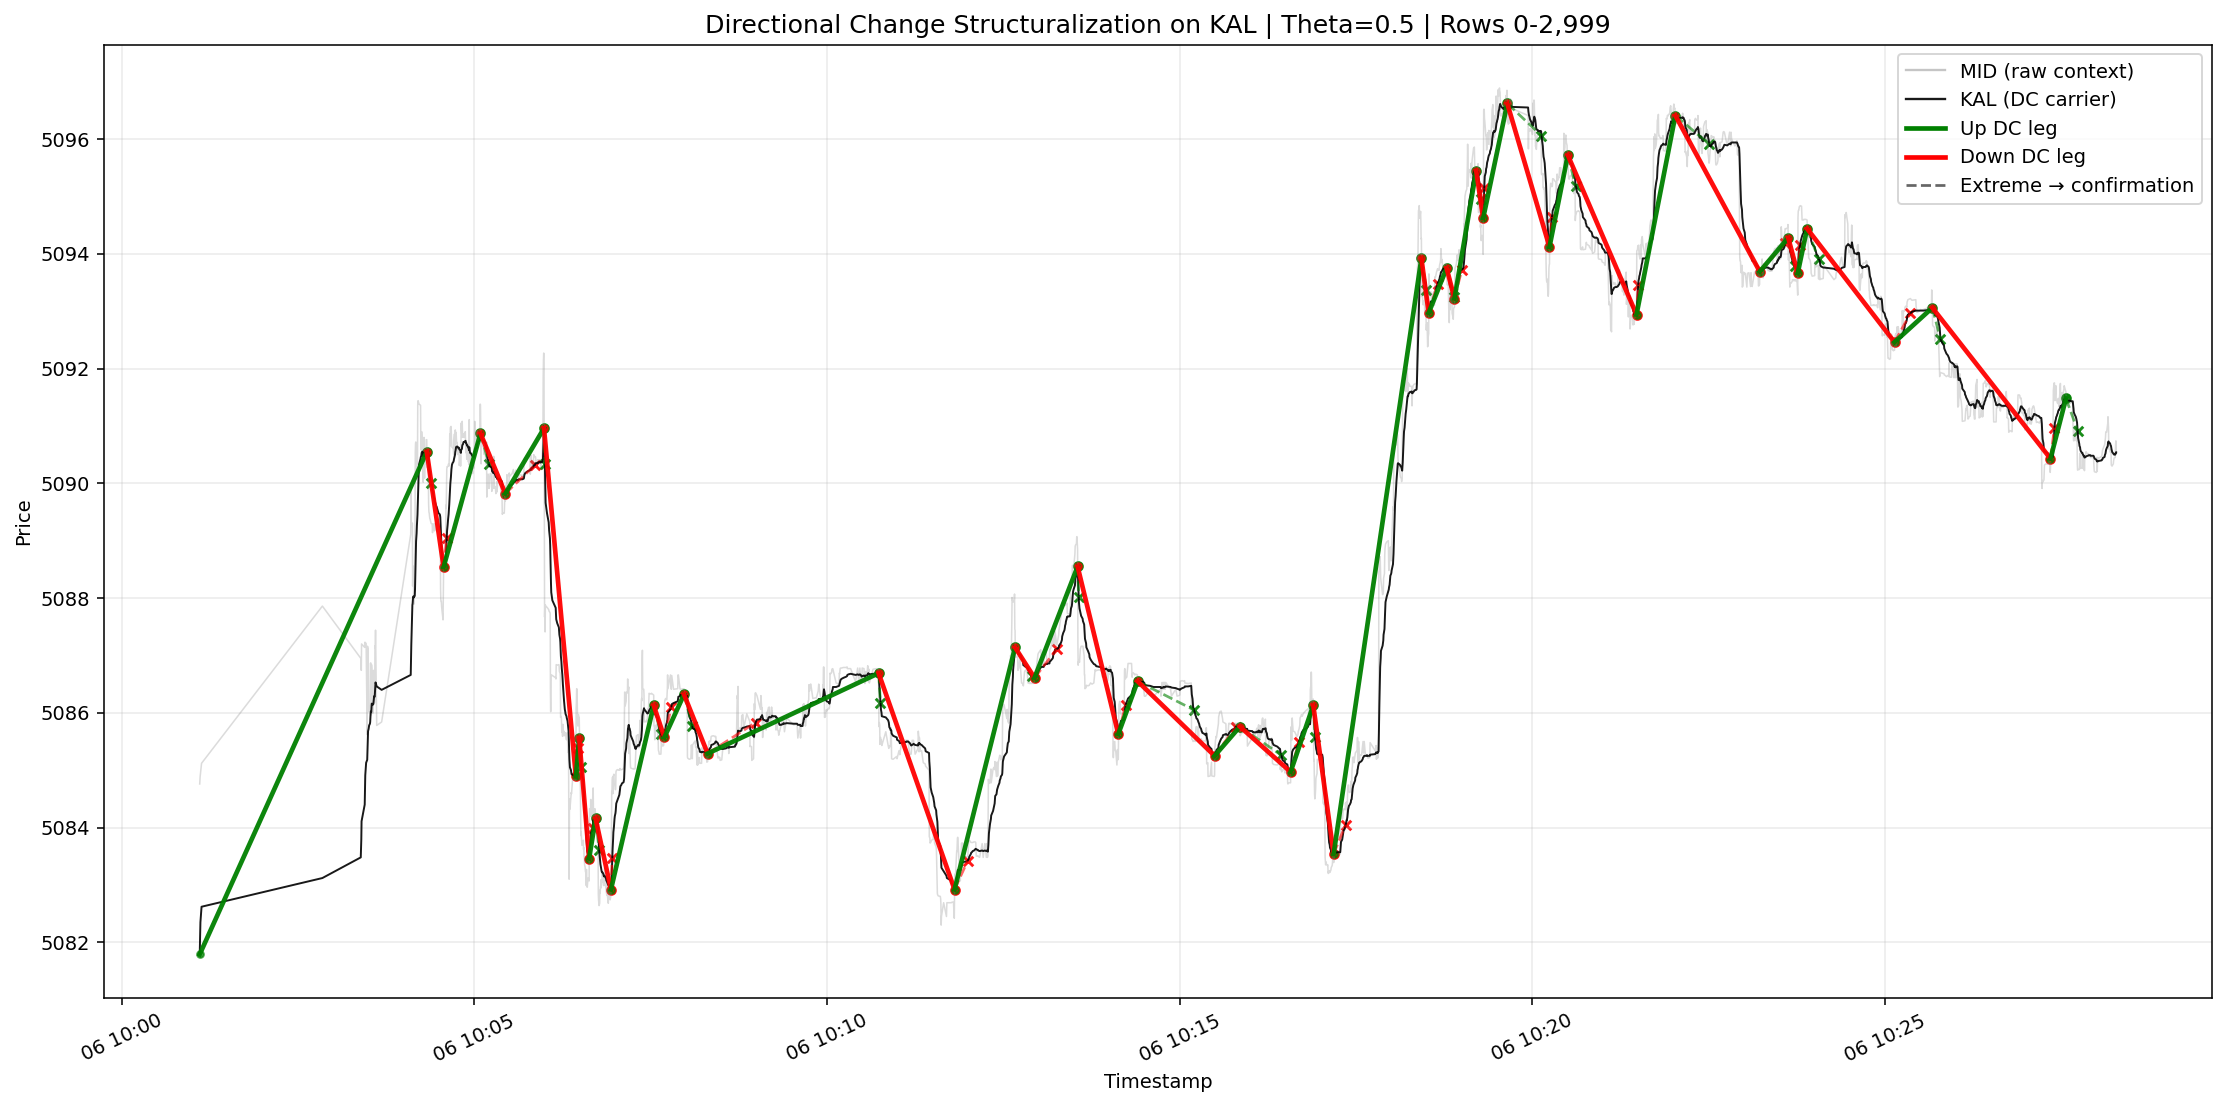

,SegmentId,Direction,StartTime,EndTime,ConfirmTime,StartPrice,EndPrice,ConfirmPrice,AbsMove,DurationTicks,DurationSec,ConfirmLagTicks,ConfirmLagSec
0,1,up,2026-03-06 10:01:06.437000+11:00,2026-03-06 10:04:19.566000+11:00,2026-03-06 10:04:23.310000+11:00,5081.79,5090.55,5090.01,8.76,89,193.129,11,3.744
1,2,down,2026-03-06 10:04:19.566000+11:00,2026-03-06 10:04:33.904000+11:00,2026-03-06 10:04:36.592000+11:00,5090.55,5088.54,5089.05,2.01,36,14.338,11,2.688
2,3,up,2026-03-06 10:04:33.904000+11:00,2026-03-06 10:05:05.250000+11:00,2026-03-06 10:05:12.452000+11:00,5088.54,5090.87,5090.34,2.33,101,31.346,21,7.202
3,4,down,2026-03-06 10:05:05.250000+11:00,2026-03-06 10:05:26.390000+11:00,2026-03-06 10:05:51.641000+11:00,5090.87,5089.82,5090.32,1.05,47,21.140,41,25.251
4,5,up,2026-03-06 10:05:26.390000+11:00,2026-03-06 10:05:59.291000+11:00,2026-03-06 10:05:59.991000+11:00,5089.82,5090.96,5090.33,1.14,61,32.901,3,0.700
5,6,down,2026-03-06 10:05:59.291000+11:00,2026-03-06 10:06:26.400000+11:00,2026-03-06 10:06:27.902000+11:00,5090.96,5084.89,5085.39,6.07,63,27.109,5,1.502
6,7,up,2026-03-06 10:06:26.400000+11:00,2026-03-06 10:06:29.249000+11:00,2026-03-06 10:06:30.900000+11:00,5084.89,5085.56,5085.06,0.67,9,2.849,5,1.651
7,8,down,2026-03-06 10:06:29.249000+11:00,2026-03-06 10:06:37.697000+11:00,2026-03-06 10:06:40.671000+11:00,5085.56,5083.46,5084.00,2.10,24,8.448,10,2.974
8,9,up,2026-03-06 10:06:37.697000+11:00,2026-03-06 10:06:43.168000+11:00,2026-03-06 10:06:46.182000+11:00,5083.46,5084.16,5083.61,0.70,18,5.471,12,3.014
9,10,down,2026-03-06 10:06:43.168000+11:00,2026-03-06 10:06:56.254000+11:00,2026-03-06 10:06:57.383000+11:00,5084.16,5082.92,5083.47,1.24,46,13.086,4,1.129


In [11]:
#1-10 Visualize First DC Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

if "DcSegmentsDf" not in globals():
    raise RuntimeError("DcSegmentsDf is not defined. Please run cell #1-9 first.")

RequiredColumns = ["id", "timestamp_dt", "mid", "kal"]
MissingColumns = [Col for Col in RequiredColumns if Col not in Df.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in Df: {MissingColumns}")

RequiredSegColumns = [
    "SegmentId", "Direction", "Theta", "StartRow", "EndRow", "ConfirmRow",
    "StartTime", "EndTime", "ConfirmTime",
    "StartPrice", "EndPrice", "ConfirmPrice",
    "AbsMove", "DurationTicks", "DurationSec", "ConfirmLagTicks", "ConfirmLagSec"
]
MissingSegColumns = [Col for Col in RequiredSegColumns if Col not in DcSegmentsDf.columns]
if MissingSegColumns:
    raise ValueError(f"Missing required columns in DcSegmentsDf: {MissingSegColumns}")

WindowStartRow = 0
WindowRowCount = 3000
WindowEndRow = min(WindowStartRow + WindowRowCount, len(Df))

PlotDf = Df.iloc[WindowStartRow:WindowEndRow].copy()

# Only segments fully visible in this window
PlotSegDf = DcSegmentsDf.loc[
    (DcSegmentsDf["StartRow"] >= WindowStartRow) &
    (DcSegmentsDf["ConfirmRow"] < WindowEndRow)
].copy()

ThetaValue = float(PlotSegDf["Theta"].iloc[0]) if len(PlotSegDf) > 0 else float(DcSegmentsDf["Theta"].iloc[0])

print(f"Window rows: {WindowStartRow:,} → {WindowEndRow - 1:,}")
print(f"Ticks in plot window: {len(PlotDf):,}")
print(f"DC segments fully visible in this window: {len(PlotSegDf):,}")
print(f"Theta used: {ThetaValue}")
print()

plt.figure(figsize=(16, 8), dpi=140)

# Raw context
plt.plot(
    PlotDf["timestamp_dt"],
    PlotDf["mid"],
    linewidth=0.8,
    alpha=0.28,
    color="gray"
)

# DC carrier
plt.plot(
    PlotDf["timestamp_dt"],
    PlotDf["kal"],
    linewidth=1.0,
    alpha=0.9,
    color="black"
)

# DC segments
for _, Seg in PlotSegDf.iterrows():
    Color = "green" if Seg["Direction"] == "up" else "red"

    # Structural leg: pivot -> extreme
    plt.plot(
        [Seg["StartTime"], Seg["EndTime"]],
        [Seg["StartPrice"], Seg["EndPrice"]],
        color=Color,
        linewidth=2.4,
        alpha=0.95
    )

    # Confirmation lag: extreme -> confirmation point
    plt.plot(
        [Seg["EndTime"], Seg["ConfirmTime"]],
        [Seg["EndPrice"], Seg["ConfirmPrice"]],
        color=Color,
        linewidth=1.4,
        linestyle="--",
        alpha=0.6
    )

    # Markers
    plt.scatter(Seg["StartTime"], Seg["StartPrice"], color=Color, s=12, alpha=0.7)
    plt.scatter(Seg["EndTime"], Seg["EndPrice"], color=Color, s=20, alpha=0.95)
    plt.scatter(Seg["ConfirmTime"], Seg["ConfirmPrice"], color=Color, s=24, marker="x", alpha=0.9)

LegendHandles = [
    Line2D([0], [0], color="gray", lw=1.2, alpha=0.45, label="MID (raw context)"),
    Line2D([0], [0], color="black", lw=1.2, alpha=0.9, label="KAL (DC carrier)"),
    Line2D([0], [0], color="green", lw=2.4, label="Up DC leg"),
    Line2D([0], [0], color="red", lw=2.4, label="Down DC leg"),
    Line2D([0], [0], color="black", lw=1.4, linestyle="--", alpha=0.6, label="Extreme → confirmation")
]

plt.legend(handles=LegendHandles, loc="best")
plt.title(
    f"Directional Change Structuralization on KAL | Theta={ThetaValue} | Rows {WindowStartRow:,}-{WindowEndRow - 1:,}",
    fontsize=13
)
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.grid(alpha=0.25)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

display(
    PlotSegDf[
        [
            "SegmentId", "Direction",
            "StartTime", "EndTime", "ConfirmTime",
            "StartPrice", "EndPrice", "ConfirmPrice",
            "AbsMove", "DurationTicks", "DurationSec",
            "ConfirmLagTicks", "ConfirmLagSec"
        ]
    ].head(20)
)

In [12]:
#1-11 Quantify Structural Objects Produced By Theta 0.5

import pandas as pd
import numpy as np

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

if "DcSegmentsDf" not in globals():
    raise RuntimeError("DcSegmentsDf is not defined. Please run cell #1-9 first.")

RequiredSegColumns = [
    "SegmentId", "Direction", "Theta", "AbsMove",
    "DurationTicks", "DurationSec",
    "ConfirmLagTicks", "ConfirmLagSec",
    "TotalTicksToConfirm", "TotalSecToConfirm"
]
MissingSegColumns = [Col for Col in RequiredSegColumns if Col not in DcSegmentsDf.columns]
if MissingSegColumns:
    raise ValueError(f"Missing required columns in DcSegmentsDf: {MissingSegColumns}")

SegDf = DcSegmentsDf.copy()

ThetaValue = float(SegDf["Theta"].iloc[0])

SegDf["ExcessMove"] = (SegDf["AbsMove"] - ThetaValue).clip(lower=0)
SegDf["MoveToThetaRatio"] = SegDf["AbsMove"] / ThetaValue
SegDf["MovePerSec"] = SegDf["AbsMove"] / SegDf["DurationSec"].replace(0, np.nan)
SegDf["MovePer100Ticks"] = SegDf["AbsMove"] / SegDf["DurationTicks"].replace(0, np.nan) * 100
SegDf["ConfirmLagPctOfTotalTicks"] = SegDf["ConfirmLagTicks"] / SegDf["TotalTicksToConfirm"].replace(0, np.nan) * 100
SegDf["ConfirmLagPctOfTotalSec"] = SegDf["ConfirmLagSec"] / SegDf["TotalSecToConfirm"].replace(0, np.nan) * 100

GlobalSummary = pd.DataFrame([{
    "Theta": ThetaValue,
    "SegmentCount": int(len(SegDf)),
    "OriginalTickRows": int(len(Df)),
    "MedianDurationTicks": round(SegDf["DurationTicks"].median(), 2),
    "MedianDurationSec": round(SegDf["DurationSec"].median(), 3),
    "MedianAbsMove": round(SegDf["AbsMove"].median(), 4),
    "MedianExcessMove": round(SegDf["ExcessMove"].median(), 4),
    "MedianMoveToThetaRatio": round(SegDf["MoveToThetaRatio"].median(), 4),
    "P75MoveToThetaRatio": round(SegDf["MoveToThetaRatio"].quantile(0.75), 4),
    "P90MoveToThetaRatio": round(SegDf["MoveToThetaRatio"].quantile(0.90), 4),
    "MedianConfirmLagTicks": round(SegDf["ConfirmLagTicks"].median(), 2),
    "MedianConfirmLagSec": round(SegDf["ConfirmLagSec"].median(), 3),
    "MedianConfirmLagPctOfTotalTicks": round(SegDf["ConfirmLagPctOfTotalTicks"].median(), 2),
    "MedianConfirmLagPctOfTotalSec": round(SegDf["ConfirmLagPctOfTotalSec"].median(), 2),
    "MeanTicksPerSegment": round(len(Df) / len(SegDf), 2)
}])

DistributionSummary = pd.DataFrame({
    "Metric": [
        "AbsMove",
        "ExcessMove",
        "MoveToThetaRatio",
        "DurationTicks",
        "DurationSec",
        "ConfirmLagTicks",
        "ConfirmLagSec",
        "ConfirmLagPctOfTotalTicks",
        "ConfirmLagPctOfTotalSec",
        "MovePerSec",
        "MovePer100Ticks"
    ],
    "P10": [
        SegDf["AbsMove"].quantile(0.10),
        SegDf["ExcessMove"].quantile(0.10),
        SegDf["MoveToThetaRatio"].quantile(0.10),
        SegDf["DurationTicks"].quantile(0.10),
        SegDf["DurationSec"].quantile(0.10),
        SegDf["ConfirmLagTicks"].quantile(0.10),
        SegDf["ConfirmLagSec"].quantile(0.10),
        SegDf["ConfirmLagPctOfTotalTicks"].quantile(0.10),
        SegDf["ConfirmLagPctOfTotalSec"].quantile(0.10),
        SegDf["MovePerSec"].quantile(0.10),
        SegDf["MovePer100Ticks"].quantile(0.10),
    ],
    "P25": [
        SegDf["AbsMove"].quantile(0.25),
        SegDf["ExcessMove"].quantile(0.25),
        SegDf["MoveToThetaRatio"].quantile(0.25),
        SegDf["DurationTicks"].quantile(0.25),
        SegDf["DurationSec"].quantile(0.25),
        SegDf["ConfirmLagTicks"].quantile(0.25),
        SegDf["ConfirmLagSec"].quantile(0.25),
        SegDf["ConfirmLagPctOfTotalTicks"].quantile(0.25),
        SegDf["ConfirmLagPctOfTotalSec"].quantile(0.25),
        SegDf["MovePerSec"].quantile(0.25),
        SegDf["MovePer100Ticks"].quantile(0.25),
    ],
    "P50": [
        SegDf["AbsMove"].quantile(0.50),
        SegDf["ExcessMove"].quantile(0.50),
        SegDf["MoveToThetaRatio"].quantile(0.50),
        SegDf["DurationTicks"].quantile(0.50),
        SegDf["DurationSec"].quantile(0.50),
        SegDf["ConfirmLagTicks"].quantile(0.50),
        SegDf["ConfirmLagSec"].quantile(0.50),
        SegDf["ConfirmLagPctOfTotalTicks"].quantile(0.50),
        SegDf["ConfirmLagPctOfTotalSec"].quantile(0.50),
        SegDf["MovePerSec"].quantile(0.50),
        SegDf["MovePer100Ticks"].quantile(0.50),
    ],
    "P75": [
        SegDf["AbsMove"].quantile(0.75),
        SegDf["ExcessMove"].quantile(0.75),
        SegDf["MoveToThetaRatio"].quantile(0.75),
        SegDf["DurationTicks"].quantile(0.75),
        SegDf["DurationSec"].quantile(0.75),
        SegDf["ConfirmLagTicks"].quantile(0.75),
        SegDf["ConfirmLagSec"].quantile(0.75),
        SegDf["ConfirmLagPctOfTotalTicks"].quantile(0.75),
        SegDf["ConfirmLagPctOfTotalSec"].quantile(0.75),
        SegDf["MovePerSec"].quantile(0.75),
        SegDf["MovePer100Ticks"].quantile(0.75),
    ],
    "P90": [
        SegDf["AbsMove"].quantile(0.90),
        SegDf["ExcessMove"].quantile(0.90),
        SegDf["MoveToThetaRatio"].quantile(0.90),
        SegDf["DurationTicks"].quantile(0.90),
        SegDf["DurationSec"].quantile(0.90),
        SegDf["ConfirmLagTicks"].quantile(0.90),
        SegDf["ConfirmLagSec"].quantile(0.90),
        SegDf["ConfirmLagPctOfTotalTicks"].quantile(0.90),
        SegDf["ConfirmLagPctOfTotalSec"].quantile(0.90),
        SegDf["MovePerSec"].quantile(0.90),
        SegDf["MovePer100Ticks"].quantile(0.90),
    ]
}).round(4)

ByDirection = (
    SegDf.groupby("Direction")
    .agg(
        SegmentCount=("SegmentId", "count"),
        MedianAbsMove=("AbsMove", "median"),
        MedianExcessMove=("ExcessMove", "median"),
        MedianMoveToThetaRatio=("MoveToThetaRatio", "median"),
        P90MoveToThetaRatio=("MoveToThetaRatio", lambda S: S.quantile(0.90)),
        MedianDurationTicks=("DurationTicks", "median"),
        MedianDurationSec=("DurationSec", "median"),
        MedianConfirmLagTicks=("ConfirmLagTicks", "median"),
        MedianConfirmLagSec=("ConfirmLagSec", "median"),
        MedianConfirmLagPctOfTotalTicks=("ConfirmLagPctOfTotalTicks", "median"),
        MedianMovePerSec=("MovePerSec", "median"),
    )
    .round(4)
    .reset_index()
)

LargestSegments = (
    SegDf.sort_values(["AbsMove", "DurationSec"], ascending=[False, False])
    .loc[:, [
        "SegmentId", "Direction", "StartTime", "EndTime", "ConfirmTime",
        "AbsMove", "ExcessMove", "MoveToThetaRatio",
        "DurationTicks", "DurationSec",
        "ConfirmLagTicks", "ConfirmLagSec"
    ]]
    .head(15)
)

print("Global structural summary:")
display(GlobalSummary)

print("Distribution summary:")
display(DistributionSummary)

print("By direction:")
display(ByDirection)

print("Largest structural objects under theta=0.5:")
display(LargestSegments)

Global structural summary:


,Theta,SegmentCount,OriginalTickRows,MedianDurationTicks,MedianDurationSec,MedianAbsMove,MedianExcessMove,MedianMoveToThetaRatio,P75MoveToThetaRatio,P90MoveToThetaRatio,MedianConfirmLagTicks,MedianConfirmLagSec,MedianConfirmLagPctOfTotalTicks,MedianConfirmLagPctOfTotalSec,MeanTicksPerSegment
0,0.5,2841,232537,61.0,20.055,1.64,1.14,3.28,5.6,8.78,16.0,5.193,21.37,21.18,81.85


Distribution summary:


,Metric,P10,P25,P50,P75,P90
0,AbsMove,0.6500,0.9800,1.6400,2.8000,4.3900
1,ExcessMove,0.1500,0.4800,1.1400,2.3000,3.8900
2,MoveToThetaRatio,1.3000,1.9600,3.2800,5.6000,8.7800
3,DurationTicks,23.0000,36.0000,61.0000,106.0000,168.0000
4,DurationSec,6.5610,11.1120,20.0550,36.7490,61.8400
5,ConfirmLagTicks,7.0000,10.0000,16.0000,26.0000,40.0000
6,ConfirmLagSec,1.8300,2.8560,5.1930,9.2770,15.6510
7,ConfirmLagPctOfTotalTicks,7.3298,12.2807,21.3675,34.5238,48.5149
8,ConfirmLagPctOfTotalSec,6.5683,11.7195,21.1806,34.7686,49.5130
9,MovePerSec,0.0322,0.0493,0.0842,0.1465,0.2306


By direction:


,Direction,SegmentCount,MedianAbsMove,MedianExcessMove,MedianMoveToThetaRatio,P90MoveToThetaRatio,MedianDurationTicks,MedianDurationSec,MedianConfirmLagTicks,MedianConfirmLagSec,MedianConfirmLagPctOfTotalTicks,MedianMovePerSec
0,down,1420,1.64,1.14,3.28,8.842,59.0,19.3405,16.0,5.195,21.2445,0.0844
1,up,1421,1.65,1.15,3.30,8.700,64.0,20.9190,16.0,5.184,21.4286,0.0840


Largest structural objects under theta=0.5:


,SegmentId,Direction,StartTime,EndTime,ConfirmTime,AbsMove,ExcessMove,MoveToThetaRatio,DurationTicks,DurationSec,ConfirmLagTicks,ConfirmLagSec
1544,1545,up,2026-03-07 00:29:58.373000+11:00,2026-03-07 00:30:14.068000+11:00,2026-03-07 00:30:15.495000+11:00,26.88,26.38,53.76,64,15.695,6,1.427
1908,1909,up,2026-03-07 02:01:27.717000+11:00,2026-03-07 02:02:38.174000+11:00,2026-03-07 02:02:40.162000+11:00,23.99,23.49,47.98,285,70.457,8,1.988
209,210,down,2026-03-06 11:59:42.873000+11:00,2026-03-06 12:00:47.190000+11:00,2026-03-06 12:00:48.702000+11:00,16.88,16.38,33.76,240,64.317,6,1.512
1900,1901,up,2026-03-07 01:59:13.809000+11:00,2026-03-07 02:00:25.496000+11:00,2026-03-07 02:00:26.937000+11:00,16.53,16.03,33.06,283,71.687,6,1.441
1317,1318,down,2026-03-06 22:55:25.069000+11:00,2026-03-06 22:56:25.667000+11:00,2026-03-06 22:56:29.592000+11:00,15.76,15.26,31.52,210,60.598,17,3.925
1657,1658,down,2026-03-07 00:55:26.965000+11:00,2026-03-07 00:56:18.695000+11:00,2026-03-07 00:56:19.461000+11:00,13.68,13.18,27.36,203,51.730,3,0.766
1766,1767,up,2026-03-07 01:30:58.716000+11:00,2026-03-07 01:31:34.155000+11:00,2026-03-07 01:31:34.848000+11:00,13.66,13.16,27.32,148,35.439,3,0.693
1911,1912,down,2026-03-07 02:03:07.652000+11:00,2026-03-07 02:03:53.320000+11:00,2026-03-07 02:03:57.535000+11:00,13.04,12.54,26.08,188,45.668,18,4.215
2546,2547,up,2026-03-07 05:41:54+11:00,2026-03-07 05:45:30.248000+11:00,2026-03-07 05:45:34.850000+11:00,12.50,12.00,25.00,710,216.248,17,4.602
1061,1062,down,2026-03-06 20:35:33.818000+11:00,2026-03-06 20:36:25.706000+11:00,2026-03-06 20:36:32.924000+11:00,12.49,11.99,24.98,163,51.888,27,7.218


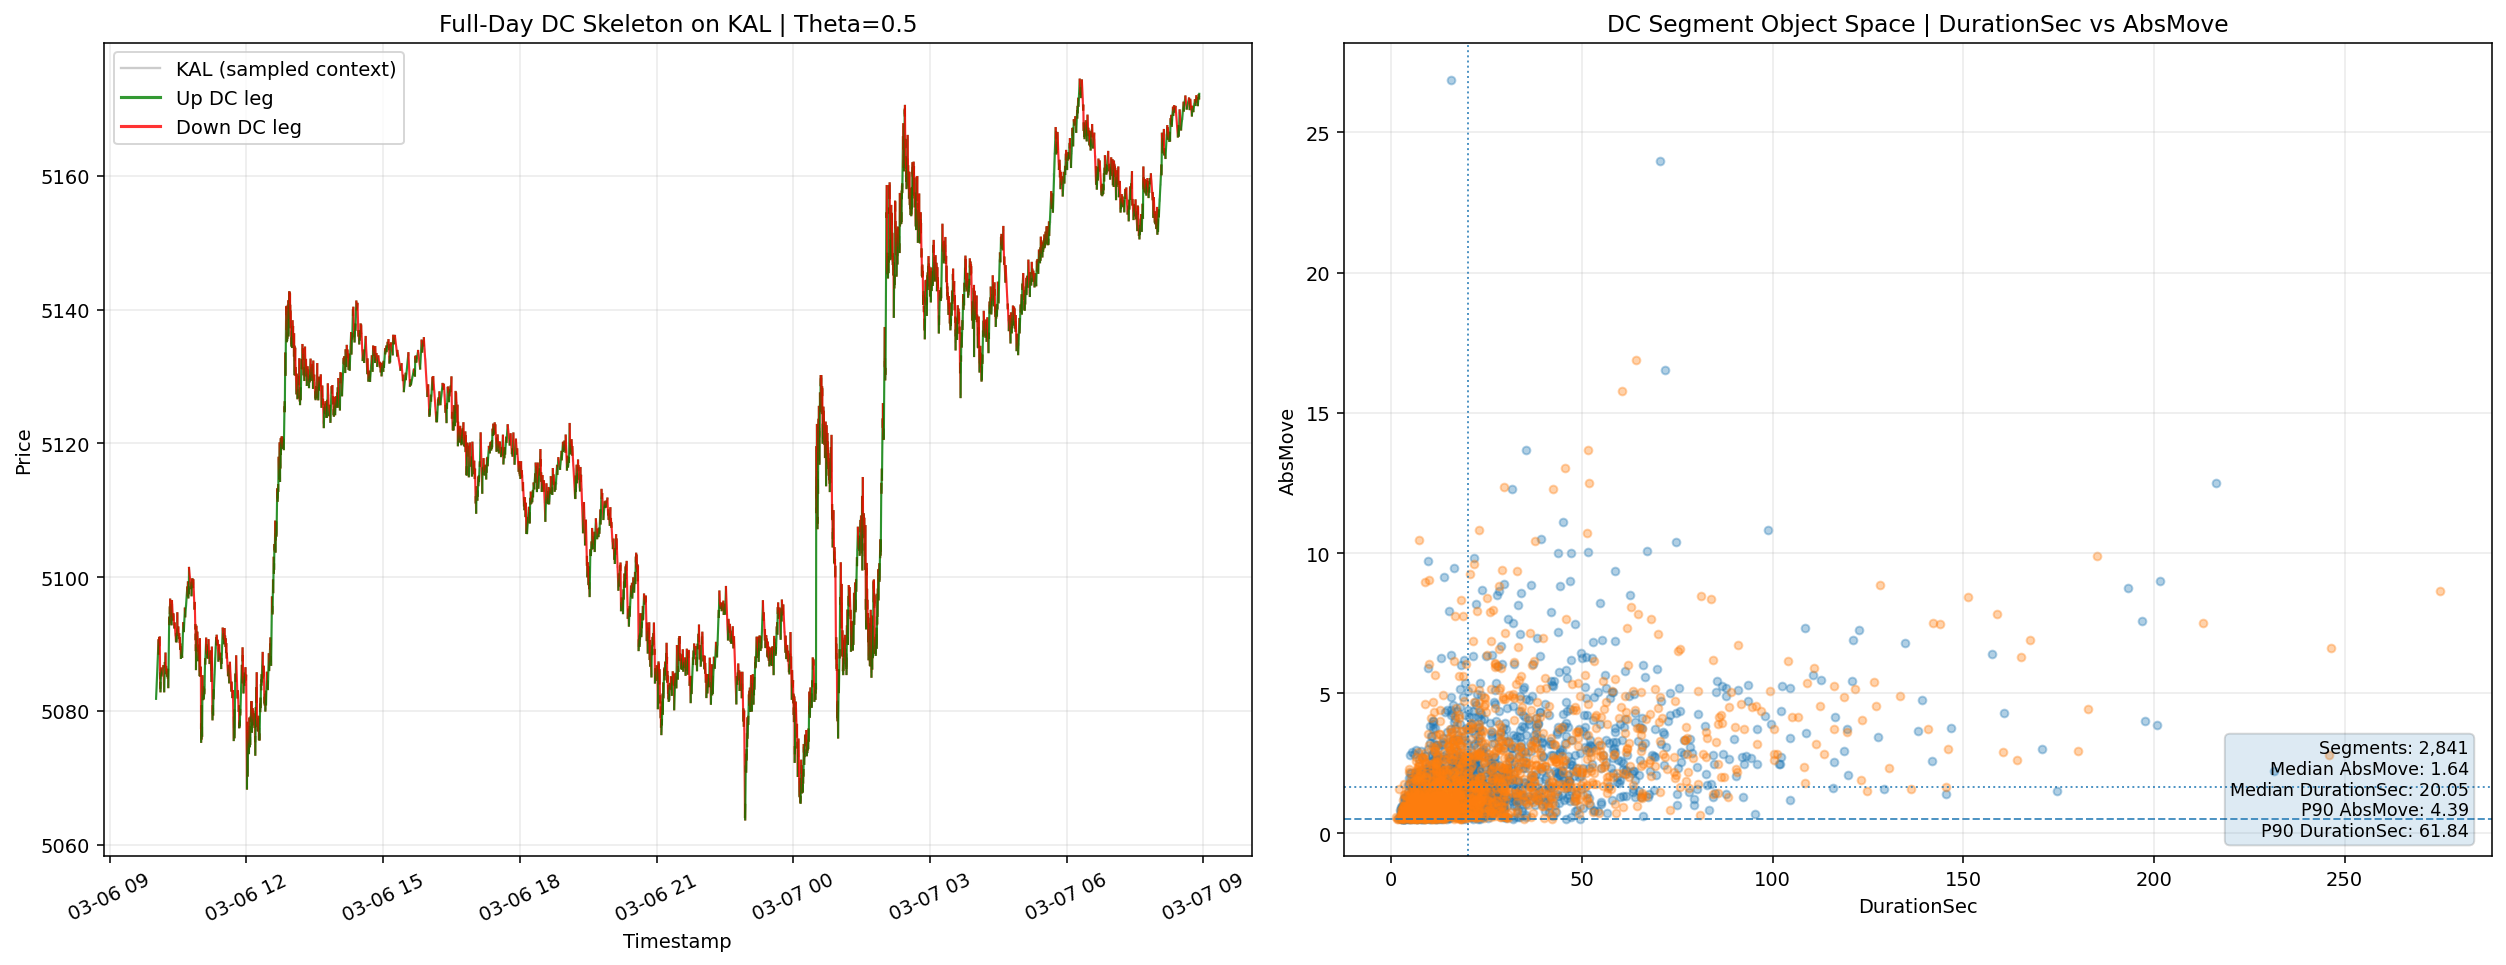

In [13]:
#1-12 Visualize Full-Day DC Skeleton and Segment Object Space

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

if "DcSegmentsDf" not in globals():
    raise RuntimeError("DcSegmentsDf is not defined. Please run cell #1-9 first.")

RequiredDfColumns = ["timestamp_dt", "kal"]
MissingDfColumns = [Col for Col in RequiredDfColumns if Col not in Df.columns]
if MissingDfColumns:
    raise ValueError(f"Missing required columns in Df: {MissingDfColumns}")

RequiredSegColumns = [
    "SegmentId", "Direction", "Theta",
    "StartTime", "EndTime", "StartPrice", "EndPrice",
    "AbsMove", "DurationSec", "ConfirmLagSec"
]
MissingSegColumns = [Col for Col in RequiredSegColumns if Col not in DcSegmentsDf.columns]
if MissingSegColumns:
    raise ValueError(f"Missing required columns in DcSegmentsDf: {MissingSegColumns}")

PlotDf = Df.sort_values("timestamp_dt").reset_index(drop=True).copy()
SegDf = DcSegmentsDf.sort_values("SegmentId").reset_index(drop=True).copy()

ThetaValue = float(SegDf["Theta"].iloc[0])

# Downsample raw carrier for readability on full-day plot
RawSampleStep = 20
RawPlotDf = PlotDf.iloc[::RawSampleStep].copy()

MedianAbsMove = float(SegDf["AbsMove"].median())
MedianDurationSec = float(SegDf["DurationSec"].median())
P90AbsMove = float(SegDf["AbsMove"].quantile(0.90))
P90DurationSec = float(SegDf["DurationSec"].quantile(0.90))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=140)

# ------------------------------------------------------------------
# Left panel: full-day structural skeleton
# ------------------------------------------------------------------
axes[0].plot(
    RawPlotDf["timestamp_dt"],
    RawPlotDf["kal"],
    linewidth=0.8,
    alpha=0.30,
    color="gray"
)

for _, Seg in SegDf.iterrows():
    Color = "green" if Seg["Direction"] == "up" else "red"
    axes[0].plot(
        [Seg["StartTime"], Seg["EndTime"]],
        [Seg["StartPrice"], Seg["EndPrice"]],
        color=Color,
        linewidth=1.1,
        alpha=0.80
    )

axes[0].set_title(f"Full-Day DC Skeleton on KAL | Theta={ThetaValue}")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Price")
axes[0].grid(alpha=0.25)
axes[0].tick_params(axis="x", rotation=25)

LegendHandles = [
    Line2D([0], [0], color="gray", lw=1.2, alpha=0.4, label="KAL (sampled context)"),
    Line2D([0], [0], color="green", lw=1.6, alpha=0.8, label="Up DC leg"),
    Line2D([0], [0], color="red", lw=1.6, alpha=0.8, label="Down DC leg"),
]
axes[0].legend(handles=LegendHandles, loc="best")

# ------------------------------------------------------------------
# Right panel: structural object space
# ------------------------------------------------------------------
UpMask = SegDf["Direction"].eq("up")
DnMask = SegDf["Direction"].eq("down")

axes[1].scatter(
    SegDf.loc[UpMask, "DurationSec"],
    SegDf.loc[UpMask, "AbsMove"],
    s=16,
    alpha=0.35
)

axes[1].scatter(
    SegDf.loc[DnMask, "DurationSec"],
    SegDf.loc[DnMask, "AbsMove"],
    s=16,
    alpha=0.35
)

axes[1].axhline(ThetaValue, linestyle="--", linewidth=1.0, alpha=0.8)
axes[1].axhline(MedianAbsMove, linestyle=":", linewidth=1.0, alpha=0.8)
axes[1].axvline(MedianDurationSec, linestyle=":", linewidth=1.0, alpha=0.8)

axes[1].set_title("DC Segment Object Space | DurationSec vs AbsMove")
axes[1].set_xlabel("DurationSec")
axes[1].set_ylabel("AbsMove")
axes[1].grid(alpha=0.25)

SummaryText = (
    f"Segments: {len(SegDf):,}\n"
    f"Median AbsMove: {MedianAbsMove:.2f}\n"
    f"Median DurationSec: {MedianDurationSec:.2f}\n"
    f"P90 AbsMove: {P90AbsMove:.2f}\n"
    f"P90 DurationSec: {P90DurationSec:.2f}"
)
axes[1].text(
    0.98, 0.02, SummaryText,
    transform=axes[1].transAxes,
    ha="right", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()
plt.show()

In [14]:
#1-13 Build First DC Object Table and Coarse Structural Families

import pandas as pd
import numpy as np

if "DcSegmentsDf" not in globals():
    raise RuntimeError("DcSegmentsDf is not defined. Please run cell #1-9 first.")

SegDf = DcSegmentsDf.copy()

RequiredColumns = [
    "SegmentId", "Direction", "Theta",
    "StartTime", "EndTime", "ConfirmTime",
    "StartPrice", "EndPrice", "ConfirmPrice",
    "AbsMove", "DurationTicks", "DurationSec",
    "ConfirmLagTicks", "ConfirmLagSec", "TotalTicksToConfirm", "TotalSecToConfirm"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in SegDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcSegmentsDf: {MissingColumns}")

ThetaValue = float(SegDf["Theta"].iloc[0])

DcObjectsDf = SegDf.copy()

# Core derived features
DcObjectsDf["SignedMove"] = np.where(
    DcObjectsDf["Direction"].eq("up"),
    DcObjectsDf["AbsMove"],
    -DcObjectsDf["AbsMove"]
)

DcObjectsDf["OvershootMove"] = (DcObjectsDf["AbsMove"] - ThetaValue).clip(lower=0)
DcObjectsDf["MoveToThetaRatio"] = DcObjectsDf["AbsMove"] / ThetaValue
DcObjectsDf["OvershootToThetaRatio"] = DcObjectsDf["OvershootMove"] / ThetaValue
DcObjectsDf["MovePerSec"] = DcObjectsDf["AbsMove"] / DcObjectsDf["DurationSec"].replace(0, np.nan)
DcObjectsDf["MovePerTick"] = DcObjectsDf["AbsMove"] / DcObjectsDf["DurationTicks"].replace(0, np.nan)
DcObjectsDf["ConfirmLagPctSec"] = (
    DcObjectsDf["ConfirmLagSec"] / DcObjectsDf["TotalSecToConfirm"].replace(0, np.nan) * 100
)
DcObjectsDf["ConfirmLagPctTicks"] = (
    DcObjectsDf["ConfirmLagTicks"] / DcObjectsDf["TotalTicksToConfirm"].replace(0, np.nan) * 100
)

# Time-of-day style fields
DcObjectsDf["StartHour"] = pd.to_datetime(DcObjectsDf["StartTime"]).dt.hour
DcObjectsDf["EndHour"] = pd.to_datetime(DcObjectsDf["EndTime"]).dt.hour

# Coarse family labels from current population percentiles
DurationP33 = DcObjectsDf["DurationSec"].quantile(0.33)
DurationP66 = DcObjectsDf["DurationSec"].quantile(0.66)

MoveP33 = DcObjectsDf["AbsMove"].quantile(0.33)
MoveP66 = DcObjectsDf["AbsMove"].quantile(0.66)

def DurationFamily(Value: float) -> str:
    if Value <= DurationP33:
        return "short"
    if Value <= DurationP66:
        return "medium"
    return "long"

def MoveFamily(Value: float) -> str:
    if Value <= MoveP33:
        return "small"
    if Value <= MoveP66:
        return "medium"
    return "large"

DcObjectsDf["DurationFamily"] = DcObjectsDf["DurationSec"].apply(DurationFamily)
DcObjectsDf["MoveFamily"] = DcObjectsDf["AbsMove"].apply(MoveFamily)
DcObjectsDf["StructuralFamily"] = DcObjectsDf["MoveFamily"] + "_" + DcObjectsDf["DurationFamily"]

GlobalObjectSummary = pd.DataFrame([{
    "Theta": ThetaValue,
    "ObjectCount": int(len(DcObjectsDf)),
    "MedianAbsMove": round(DcObjectsDf["AbsMove"].median(), 4),
    "MedianOvershootMove": round(DcObjectsDf["OvershootMove"].median(), 4),
    "MedianMoveToThetaRatio": round(DcObjectsDf["MoveToThetaRatio"].median(), 4),
    "MedianDurationSec": round(DcObjectsDf["DurationSec"].median(), 4),
    "MedianMovePerSec": round(DcObjectsDf["MovePerSec"].median(), 4),
    "MedianConfirmLagPctSec": round(DcObjectsDf["ConfirmLagPctSec"].median(), 2),
    "DurationP33": round(DurationP33, 4),
    "DurationP66": round(DurationP66, 4),
    "MoveP33": round(MoveP33, 4),
    "MoveP66": round(MoveP66, 4),
}])

StructuralFamilySummary = (
    DcObjectsDf.groupby(["StructuralFamily", "Direction"])
    .agg(
        Count=("SegmentId", "count"),
        MedianAbsMove=("AbsMove", "median"),
        MedianOvershootMove=("OvershootMove", "median"),
        MedianDurationSec=("DurationSec", "median"),
        MedianMovePerSec=("MovePerSec", "median"),
        MedianConfirmLagPctSec=("ConfirmLagPctSec", "median"),
    )
    .round(4)
    .reset_index()
    .sort_values(["Count", "StructuralFamily", "Direction"], ascending=[False, True, True])
    .reset_index(drop=True)
)

StructuralFamilyCounts = (
    DcObjectsDf["StructuralFamily"]
    .value_counts()
    .rename_axis("StructuralFamily")
    .reset_index(name="Count")
)

PreviewColumns = [
    "SegmentId", "Direction",
    "StartTime", "EndTime",
    "AbsMove", "OvershootMove", "MoveToThetaRatio",
    "DurationSec", "MovePerSec", "ConfirmLagPctSec",
    "MoveFamily", "DurationFamily", "StructuralFamily"
]

print("Global DC object summary:")
display(GlobalObjectSummary)

print("Structural family counts:")
display(StructuralFamilyCounts)

print("Structural family summary by direction:")
display(StructuralFamilySummary)

print("First 20 DC objects:")
display(DcObjectsDf[PreviewColumns].head(20))

Global DC object summary:


,Theta,ObjectCount,MedianAbsMove,MedianOvershootMove,MedianMoveToThetaRatio,MedianDurationSec,MedianMovePerSec,MedianConfirmLagPctSec,DurationP33,DurationP66,MoveP33,MoveP66
0,0.5,2841,1.64,1.14,3.28,20.055,0.0842,21.18,13.4962,28.6368,1.16,2.31


Structural family counts:


,StructuralFamily,Count
0,large_long,570
1,small_short,542
2,medium_medium,337
3,small_medium,303
4,medium_short,303
5,large_medium,297
6,medium_long,296
7,small_long,100
8,large_short,93


Structural family summary by direction:


,StructuralFamily,Direction,Count,MedianAbsMove,MedianOvershootMove,MedianDurationSec,MedianMovePerSec,MedianConfirmLagPctSec
0,large_long,up,295,3.770,3.270,51.7100,0.0717,9.0113
1,small_short,down,280,0.750,0.250,7.6235,0.1050,41.1490
2,large_long,down,275,3.730,3.230,53.6800,0.0689,9.3346
3,small_short,up,262,0.735,0.235,7.4660,0.1023,38.8566
4,medium_medium,down,171,1.650,1.150,18.9880,0.0846,22.2315
5,medium_medium,up,166,1.660,1.160,21.0435,0.0828,22.6754
6,small_medium,down,153,0.820,0.320,18.9030,0.0429,29.9705
7,medium_short,down,152,1.535,1.035,9.3950,0.1714,27.7347
8,medium_short,up,151,1.550,1.050,9.0190,0.1748,31.1801
9,medium_long,up,150,1.710,1.210,43.7370,0.0385,14.5465


First 20 DC objects:


,SegmentId,Direction,StartTime,EndTime,AbsMove,OvershootMove,MoveToThetaRatio,DurationSec,MovePerSec,ConfirmLagPctSec,MoveFamily,DurationFamily,StructuralFamily
0,1,up,2026-03-06 10:01:06.437000+11:00,2026-03-06 10:04:19.566000+11:00,8.76,8.26,17.52,193.129,0.045358,1.901734,large,long,large_long
1,2,down,2026-03-06 10:04:19.566000+11:00,2026-03-06 10:04:33.904000+11:00,2.01,1.51,4.02,14.338,0.140187,15.787619,medium,medium,medium_medium
2,3,up,2026-03-06 10:04:33.904000+11:00,2026-03-06 10:05:05.250000+11:00,2.33,1.83,4.66,31.346,0.074332,18.683200,large,long,large_long
3,4,down,2026-03-06 10:05:05.250000+11:00,2026-03-06 10:05:26.390000+11:00,1.05,0.55,2.10,21.140,0.049669,54.430816,small,medium,small_medium
4,5,up,2026-03-06 10:05:26.390000+11:00,2026-03-06 10:05:59.291000+11:00,1.14,0.64,2.28,32.901,0.034649,2.083271,small,long,small_long
5,6,down,2026-03-06 10:05:59.291000+11:00,2026-03-06 10:06:26.400000+11:00,6.07,5.57,12.14,27.109,0.223911,5.249729,large,medium,large_medium
6,7,up,2026-03-06 10:06:26.400000+11:00,2026-03-06 10:06:29.249000+11:00,0.67,0.17,1.34,2.849,0.235170,36.688889,small,short,small_short
7,8,down,2026-03-06 10:06:29.249000+11:00,2026-03-06 10:06:37.697000+11:00,2.10,1.60,4.20,8.448,0.248580,26.037472,medium,short,medium_short
8,9,up,2026-03-06 10:06:37.697000+11:00,2026-03-06 10:06:43.168000+11:00,0.70,0.20,1.40,5.471,0.127947,35.521509,small,short,small_short
9,10,down,2026-03-06 10:06:43.168000+11:00,2026-03-06 10:06:56.254000+11:00,1.24,0.74,2.48,13.086,0.094758,7.942314,medium,short,medium_short


In [15]:
#1-14 Build First Adjacent-Transition Table For DC Objects

import pandas as pd
import numpy as np

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-13 first.")

ObjDf = DcObjectsDf.sort_values("SegmentId").reset_index(drop=True).copy()

RequiredColumns = [
    "SegmentId", "Direction", "StructuralFamily",
    "AbsMove", "DurationSec", "MovePerSec", "ConfirmLagPctSec"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in ObjDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

TransitionDf = ObjDf.copy()

TransitionDf["NextSegmentId"] = TransitionDf["SegmentId"].shift(-1)
TransitionDf["NextDirection"] = TransitionDf["Direction"].shift(-1)
TransitionDf["NextStructuralFamily"] = TransitionDf["StructuralFamily"].shift(-1)
TransitionDf["NextAbsMove"] = TransitionDf["AbsMove"].shift(-1)
TransitionDf["NextDurationSec"] = TransitionDf["DurationSec"].shift(-1)
TransitionDf["NextMovePerSec"] = TransitionDf["MovePerSec"].shift(-1)
TransitionDf["NextConfirmLagPctSec"] = TransitionDf["ConfirmLagPctSec"].shift(-1)

TransitionDf = TransitionDf.iloc[:-1].copy()

TransitionDf["TransitionLabel"] = (
    TransitionDf["Direction"] + ":" + TransitionDf["StructuralFamily"]
    + "  ->  " +
    TransitionDf["NextDirection"] + ":" + TransitionDf["NextStructuralFamily"]
)

TransitionDf["NextMoveVsCurrentMove"] = (
    TransitionDf["NextAbsMove"] / TransitionDf["AbsMove"].replace(0, np.nan)
)
TransitionDf["NextDurationVsCurrentDuration"] = (
    TransitionDf["NextDurationSec"] / TransitionDf["DurationSec"].replace(0, np.nan)
)

TopTransitions = (
    TransitionDf.groupby(
        ["Direction", "StructuralFamily", "NextDirection", "NextStructuralFamily", "TransitionLabel"],
        dropna=False
    )
    .agg(
        Count=("SegmentId", "count"),
        MedianCurrentAbsMove=("AbsMove", "median"),
        MedianNextAbsMove=("NextAbsMove", "median"),
        MedianCurrentDurationSec=("DurationSec", "median"),
        MedianNextDurationSec=("NextDurationSec", "median"),
        MedianNextMoveVsCurrentMove=("NextMoveVsCurrentMove", "median"),
        MedianNextDurationVsCurrentDuration=("NextDurationVsCurrentDuration", "median"),
        MedianNextMovePerSec=("NextMovePerSec", "median"),
        MedianNextConfirmLagPctSec=("NextConfirmLagPctSec", "median"),
    )
    .round(4)
    .reset_index()
    .sort_values(["Count", "TransitionLabel"], ascending=[False, True])
    .reset_index(drop=True)
)

TopTransitions["PctOfAllTransitions"] = (
    TopTransitions["Count"] / len(TransitionDf) * 100
).round(2)

ConditionalTransitions = (
    TransitionDf.groupby(["StructuralFamily", "NextStructuralFamily"])
    .size()
    .rename("Count")
    .reset_index()
)

ConditionalTransitions["RowTotal"] = ConditionalTransitions.groupby("StructuralFamily")["Count"].transform("sum")
ConditionalTransitions["PctWithinCurrentFamily"] = (
    ConditionalTransitions["Count"] / ConditionalTransitions["RowTotal"] * 100
).round(2)

ConditionalPivot = (
    ConditionalTransitions.pivot(
        index="StructuralFamily",
        columns="NextStructuralFamily",
        values="PctWithinCurrentFamily"
    )
    .fillna(0)
    .round(2)
)

DirectionTransitionCounts = (
    TransitionDf.groupby(["Direction", "NextDirection"])
    .size()
    .rename("Count")
    .reset_index()
)

print(f"Adjacent transitions studied: {len(TransitionDf):,}")
print()

print("Direction-to-direction transition counts:")
display(DirectionTransitionCounts)

print("Top 20 exact transitions:")
display(
    TopTransitions[
        [
            "TransitionLabel", "Count", "PctOfAllTransitions",
            "MedianCurrentAbsMove", "MedianNextAbsMove",
            "MedianCurrentDurationSec", "MedianNextDurationSec",
            "MedianNextMoveVsCurrentMove", "MedianNextDurationVsCurrentDuration",
            "MedianNextMovePerSec", "MedianNextConfirmLagPctSec"
        ]
    ].head(20)
)

print("Conditional next-family probabilities (% within current family):")
display(ConditionalPivot)

print("First 20 adjacent object transitions:")
display(
    TransitionDf[
        [
            "SegmentId", "Direction", "StructuralFamily", "AbsMove", "DurationSec",
            "NextSegmentId", "NextDirection", "NextStructuralFamily", "NextAbsMove", "NextDurationSec",
            "NextMoveVsCurrentMove", "NextDurationVsCurrentDuration"
        ]
    ].head(20)
)

Adjacent transitions studied: 2,840

Direction-to-direction transition counts:


,Direction,NextDirection,Count
0,down,up,1420
1,up,down,1420


Top 20 exact transitions:


,TransitionLabel,Count,PctOfAllTransitions,MedianCurrentAbsMove,MedianNextAbsMove,MedianCurrentDurationSec,MedianNextDurationSec,MedianNextMoveVsCurrentMove,MedianNextDurationVsCurrentDuration,MedianNextMovePerSec,MedianNextConfirmLagPctSec
0,up:small_short -> down:small_short,71,2.50,0.840,0.760,7.9630,7.0220,0.9595,0.9002,0.1186,40.0610
1,up:large_long -> down:large_long,63,2.22,3.880,4.140,56.4140,58.6040,0.9882,1.1895,0.0639,9.5377
2,down:large_long -> up:large_long,61,2.15,3.400,3.760,55.8050,52.2520,1.1015,0.9944,0.0643,12.2020
3,up:large_long -> down:small_short,56,1.97,4.125,0.760,50.6445,7.7160,0.1828,0.1456,0.1016,47.2246
4,down:small_short -> up:small_short,52,1.83,0.820,0.780,7.3330,5.7895,0.9669,0.7906,0.1303,36.6302
5,down:small_short -> up:large_long,50,1.76,0.835,4.050,8.3320,45.6300,5.3312,6.8482,0.0855,8.7587
6,down:large_long -> up:small_short,45,1.58,3.730,0.750,44.8610,8.8260,0.2130,0.1671,0.0855,38.8983
7,up:large_long -> down:medium_medium,45,1.58,3.450,1.660,51.0460,20.1540,0.4518,0.3551,0.0846,25.4742
8,down:small_short -> up:large_medium,43,1.51,0.720,3.750,6.2430,19.8490,5.1029,3.0644,0.1758,13.1602
9,down:small_short -> up:medium_medium,42,1.48,0.805,1.700,7.9260,20.8315,2.0396,2.5880,0.0842,22.8218


Conditional next-family probabilities (% within current family):


NextStructuralFamily,large_long,large_medium,large_short,medium_long,medium_medium,medium_short,small_long,small_medium,small_short
StructuralFamily,,,,,,,,,
large_long,21.75,8.07,3.16,12.11,13.51,8.95,3.68,11.05,17.72
large_medium,21.21,14.81,5.72,3.03,8.75,18.18,0.00,5.72,22.56
large_short,17.20,15.05,11.83,0.00,4.30,19.35,0.00,0.00,32.26
medium_long,25.00,2.70,0.34,16.89,10.81,5.07,8.11,14.86,16.22
medium_medium,22.55,8.01,1.19,11.87,15.73,8.90,3.86,11.28,16.62
medium_short,14.19,18.15,4.95,4.62,12.87,16.17,1.98,6.27,20.79
small_long,26.00,2.00,0.00,24.00,7.00,7.00,10.00,17.00,7.00
small_medium,23.76,7.26,1.32,14.19,9.90,4.29,5.28,18.48,15.51
small_short,13.86,14.60,4.25,8.69,12.75,12.20,1.85,9.06,22.74


First 20 adjacent object transitions:


,SegmentId,Direction,StructuralFamily,AbsMove,DurationSec,NextSegmentId,NextDirection,NextStructuralFamily,NextAbsMove,NextDurationSec,NextMoveVsCurrentMove,NextDurationVsCurrentDuration
0,1,up,large_long,8.76,193.129,2.0,down,medium_medium,2.01,14.338,0.229452,0.074241
1,2,down,medium_medium,2.01,14.338,3.0,up,large_long,2.33,31.346,1.159204,2.186218
2,3,up,large_long,2.33,31.346,4.0,down,small_medium,1.05,21.140,0.450644,0.674408
3,4,down,small_medium,1.05,21.140,5.0,up,small_long,1.14,32.901,1.085714,1.556339
4,5,up,small_long,1.14,32.901,6.0,down,large_medium,6.07,27.109,5.324561,0.823957
5,6,down,large_medium,6.07,27.109,7.0,up,small_short,0.67,2.849,0.110379,0.105094
6,7,up,small_short,0.67,2.849,8.0,down,medium_short,2.10,8.448,3.134328,2.965251
7,8,down,medium_short,2.10,8.448,9.0,up,small_short,0.70,5.471,0.333333,0.647609
8,9,up,small_short,0.70,5.471,10.0,down,medium_short,1.24,13.086,1.771429,2.391884
9,10,down,medium_short,1.24,13.086,11.0,up,large_long,3.21,36.357,2.588710,2.778313


Total transitions: 2,840

Baseline probability of each next-family:


,BaselineNextPct
NextStructuralFamily,
small_short,19.08
small_medium,10.67
small_long,3.52
medium_short,10.67
medium_medium,11.87
medium_long,10.42
large_short,3.27
large_medium,10.46
large_long,20.04


Top preferred next-family transitions vs baseline:


,StructuralFamily,NextStructuralFamily,LiftVsBaseline,ObservedCount,ConditionalPct,AbsLiftFrom1
0,medium_long,small_long,2.302703,24.0,8.11,1.302703
1,small_long,medium_long,2.302703,24.0,24.00,1.302703
2,large_short,medium_short,1.814117,18.0,19.35,0.814117
3,large_medium,large_short,1.747945,17.0,5.72,0.747945
4,medium_short,large_medium,1.735729,55.0,18.15,0.735729
5,small_medium,small_medium,1.732292,56.0,18.48,0.732292
6,large_medium,medium_short,1.704170,54.0,18.18,0.704170
7,large_short,small_short,1.690275,30.0,32.26,0.690275
8,medium_long,medium_long,1.620709,50.0,16.89,0.620709
9,small_long,small_medium,1.593399,17.0,17.00,0.593399


Top underrepresented next-family transitions vs baseline:


,StructuralFamily,NextStructuralFamily,LiftVsBaseline,ObservedCount,ConditionalPct,AbsLiftFrom1
0,medium_long,medium_short,0.474980,15.0,5.07,0.525020
1,large_medium,small_medium,0.536498,17.0,5.72,0.463502
2,medium_short,small_medium,0.587742,19.0,6.27,0.412258
3,small_short,large_long,0.691943,75.0,13.86,0.308057
4,small_medium,large_medium,0.694292,22.0,7.26,0.305708
5,medium_short,large_long,0.708324,43.0,14.19,0.291676
6,large_medium,medium_medium,0.737743,26.0,8.75,0.262257
7,medium_medium,large_medium,0.766118,27.0,8.01,0.233882
8,large_long,large_medium,0.771694,46.0,8.07,0.228306
9,small_medium,small_short,0.812782,47.0,15.51,0.187218


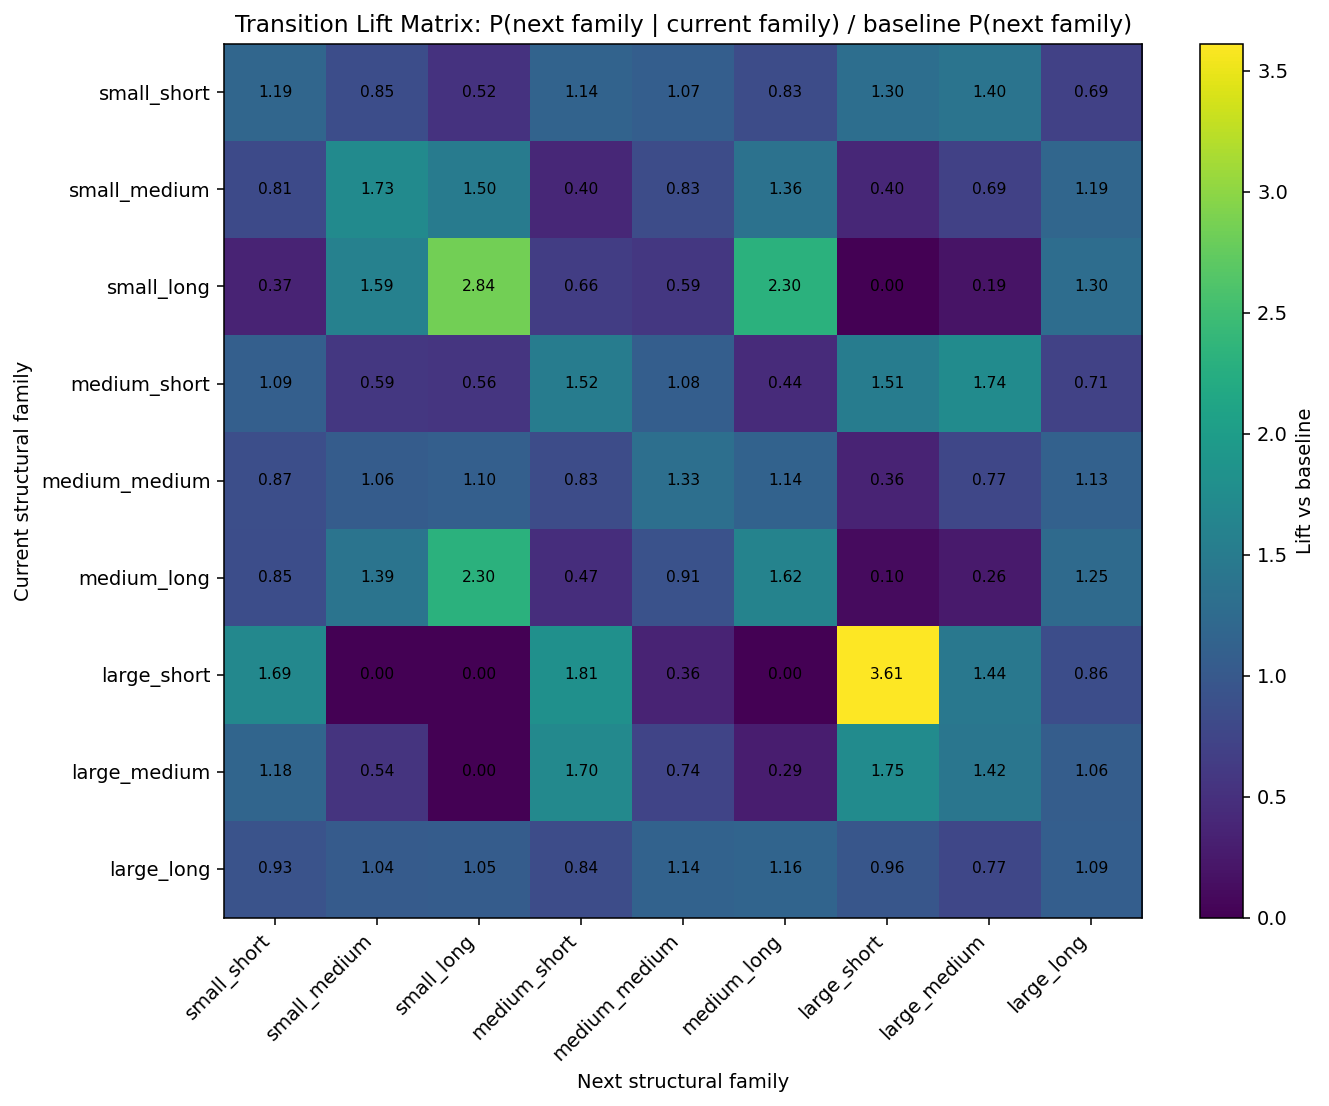

In [18]:
#1-15 Measure Transition Lift Over Baseline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "TransitionDf" not in globals():
    raise RuntimeError("TransitionDf is not defined. Please run cell #1-14 first.")

WorkDf = TransitionDf.copy()

RequiredColumns = ["StructuralFamily", "NextStructuralFamily"]
MissingColumns = [Col for Col in RequiredColumns if Col not in WorkDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in TransitionDf: {MissingColumns}")

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

ObservedCounts = (
    WorkDf.groupby(["StructuralFamily", "NextStructuralFamily"])
    .size()
    .rename("ObservedCount")
    .reset_index()
)

ObservedPivot = (
    ObservedCounts.pivot(
        index="StructuralFamily",
        columns="NextStructuralFamily",
        values="ObservedCount"
    )
    .reindex(index=FamilyOrder, columns=FamilyOrder)
    .fillna(0)
)

RowTotals = ObservedPivot.sum(axis=1)
TotalTransitions = int(ObservedPivot.values.sum())

BaselineNextProb = (
    WorkDf["NextStructuralFamily"]
    .value_counts(normalize=True)
    .reindex(FamilyOrder)
    .fillna(0)
)

ExpectedPivot = pd.DataFrame(
    index=FamilyOrder,
    columns=FamilyOrder,
    data=0.0
)

for CurrentFamily in FamilyOrder:
    ExpectedPivot.loc[CurrentFamily, :] = RowTotals.get(CurrentFamily, 0) * BaselineNextProb.values

LiftPivot = ObservedPivot / ExpectedPivot.replace(0, np.nan)
LiftPivot = LiftPivot.replace([np.inf, -np.inf], np.nan)

ConditionalProbPivot = ObservedPivot.div(RowTotals.replace(0, np.nan), axis=0) * 100
ConditionalProbPivot = ConditionalProbPivot.round(2)

BaselineNextProbPct = (BaselineNextProb * 100).round(2).rename("BaselineNextPct").to_frame()

LiftLong = (
    LiftPivot.reset_index()
    .melt(id_vars="StructuralFamily", var_name="NextStructuralFamily", value_name="LiftVsBaseline")
)

ObservedLong = (
    ObservedPivot.reset_index()
    .melt(id_vars="StructuralFamily", var_name="NextStructuralFamily", value_name="ObservedCount")
)

CondProbLong = (
    ConditionalProbPivot.reset_index()
    .melt(id_vars="StructuralFamily", var_name="NextStructuralFamily", value_name="ConditionalPct")
)

SummaryLong = (
    LiftLong.merge(ObservedLong, on=["StructuralFamily", "NextStructuralFamily"], how="left")
            .merge(CondProbLong, on=["StructuralFamily", "NextStructuralFamily"], how="left")
)

SummaryLong["AbsLiftFrom1"] = (SummaryLong["LiftVsBaseline"] - 1).abs()

TopPreferred = (
    SummaryLong.loc[SummaryLong["ObservedCount"] >= 15]
    .sort_values(["LiftVsBaseline", "ObservedCount"], ascending=[False, False])
    .head(15)
    .reset_index(drop=True)
)

TopAvoided = (
    SummaryLong.loc[SummaryLong["ObservedCount"] >= 15]
    .sort_values(["LiftVsBaseline", "ObservedCount"], ascending=[True, False])
    .head(15)
    .reset_index(drop=True)
)

print(f"Total transitions: {TotalTransitions:,}")
print()

print("Baseline probability of each next-family:")
display(BaselineNextProbPct)

print("Top preferred next-family transitions vs baseline:")
display(TopPreferred)

print("Top underrepresented next-family transitions vs baseline:")
display(TopAvoided)

fig, ax = plt.subplots(figsize=(10, 8), dpi=140)

HeatData = LiftPivot.reindex(index=FamilyOrder, columns=FamilyOrder).astype(float)

Image = ax.imshow(
    HeatData,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks(range(len(FamilyOrder)))
ax.set_xticklabels(FamilyOrder, rotation=45, ha="right")
ax.set_yticks(range(len(FamilyOrder)))
ax.set_yticklabels(FamilyOrder)

ax.set_title("Transition Lift Matrix: P(next family | current family) / baseline P(next family)")
ax.set_xlabel("Next structural family")
ax.set_ylabel("Current structural family")

for i in range(len(FamilyOrder)):
    for j in range(len(FamilyOrder)):
        Value = HeatData.iloc[i, j]
        if pd.notna(Value):
            ax.text(j, i, f"{Value:.2f}", ha="center", va="center", fontsize=8)

ColorBar = plt.colorbar(Image, ax=ax)
ColorBar.set_label("Lift vs baseline")

plt.tight_layout()
plt.show()

Minimum support threshold: 25

Top supported preferred transitions:


,StructuralFamily,NextStructuralFamily,LiftVsBaseline,ObservedCount
0,medium_short,large_medium,1.735729,55.0
1,small_medium,small_medium,1.732292,56.0
2,large_medium,medium_short,1.704170,54.0
3,large_short,small_short,1.690275,30.0
4,medium_long,medium_long,1.620709,50.0
5,medium_short,medium_short,1.515756,49.0
6,large_medium,large_medium,1.416635,44.0
7,small_short,large_medium,1.396342,79.0
8,medium_long,small_medium,1.393274,44.0
9,small_medium,medium_long,1.361609,43.0


Top supported underrepresented transitions:


,StructuralFamily,NextStructuralFamily,LiftVsBaseline,ObservedCount
0,small_short,large_long,0.691943,75.0
1,medium_short,large_long,0.708324,43.0
2,large_medium,medium_medium,0.737743,26.0
3,medium_medium,large_medium,0.766118,27.0
4,large_long,large_medium,0.771694,46.0
5,small_medium,small_short,0.812782,47.0
6,small_short,medium_long,0.833541,47.0
7,medium_medium,medium_short,0.834386,30.0
8,small_medium,medium_medium,0.834386,30.0
9,large_long,medium_short,0.838631,51.0


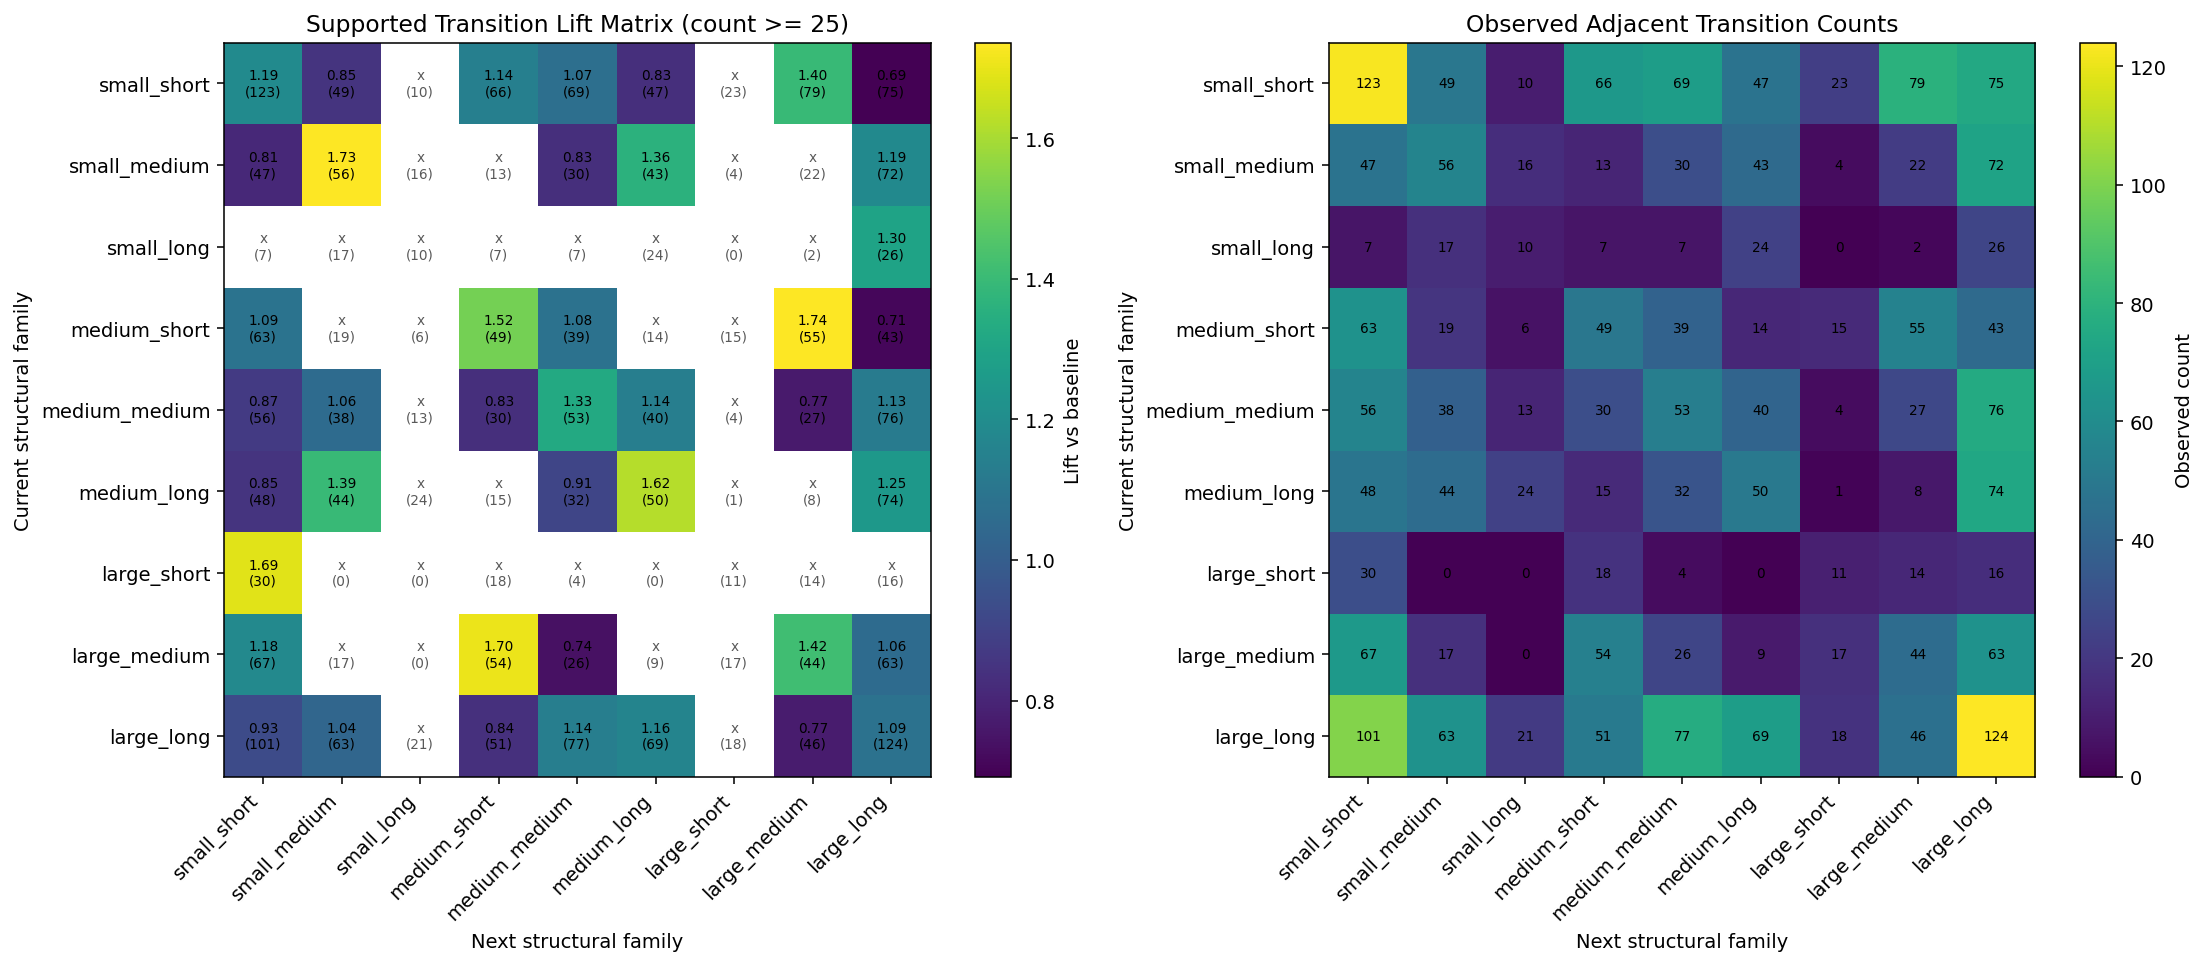

In [19]:
#1-16 Build Support-Aware Transition Lift Map

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "TransitionDf" not in globals():
    raise RuntimeError("TransitionDf is not defined. Please run cell #1-14 first.")

WorkDf = TransitionDf.copy()

RequiredColumns = ["StructuralFamily", "NextStructuralFamily"]
MissingColumns = [Col for Col in RequiredColumns if Col not in WorkDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in TransitionDf: {MissingColumns}")

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

MinSupport = 25

ObservedCounts = (
    WorkDf.groupby(["StructuralFamily", "NextStructuralFamily"])
    .size()
    .rename("ObservedCount")
    .reset_index()
)

ObservedPivot = (
    ObservedCounts.pivot(
        index="StructuralFamily",
        columns="NextStructuralFamily",
        values="ObservedCount"
    )
    .reindex(index=FamilyOrder, columns=FamilyOrder)
    .fillna(0)
)

RowTotals = ObservedPivot.sum(axis=1)

BaselineNextProb = (
    WorkDf["NextStructuralFamily"]
    .value_counts(normalize=True)
    .reindex(FamilyOrder)
    .fillna(0)
)

ExpectedPivot = pd.DataFrame(
    index=FamilyOrder,
    columns=FamilyOrder,
    data=0.0
)

for CurrentFamily in FamilyOrder:
    ExpectedPivot.loc[CurrentFamily, :] = RowTotals.get(CurrentFamily, 0) * BaselineNextProb.values

LiftPivot = ObservedPivot / ExpectedPivot.replace(0, np.nan)
LiftPivot = LiftPivot.replace([np.inf, -np.inf], np.nan)

SupportedMask = ObservedPivot >= MinSupport
LiftSupported = LiftPivot.where(SupportedMask)

LiftLong = (
    LiftSupported.reset_index()
    .melt(id_vars="StructuralFamily", var_name="NextStructuralFamily", value_name="LiftVsBaseline")
)

CountLong = (
    ObservedPivot.reset_index()
    .melt(id_vars="StructuralFamily", var_name="NextStructuralFamily", value_name="ObservedCount")
)

SummaryLong = LiftLong.merge(
    CountLong,
    on=["StructuralFamily", "NextStructuralFamily"],
    how="left"
)

TopSupportedPreferred = (
    SummaryLong.loc[SummaryLong["ObservedCount"] >= MinSupport]
    .sort_values(["LiftVsBaseline", "ObservedCount"], ascending=[False, False])
    .head(15)
    .reset_index(drop=True)
)

TopSupportedAvoided = (
    SummaryLong.loc[SummaryLong["ObservedCount"] >= MinSupport]
    .sort_values(["LiftVsBaseline", "ObservedCount"], ascending=[True, False])
    .head(15)
    .reset_index(drop=True)
)

print(f"Minimum support threshold: {MinSupport}")
print()

print("Top supported preferred transitions:")
display(TopSupportedPreferred)

print("Top supported underrepresented transitions:")
display(TopSupportedAvoided)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=140)

# Left: supported lift heatmap
HeatLift = LiftSupported.reindex(index=FamilyOrder, columns=FamilyOrder).astype(float)
Im0 = axes[0].imshow(HeatLift, aspect="auto", interpolation="nearest")

axes[0].set_title(f"Supported Transition Lift Matrix (count >= {MinSupport})")
axes[0].set_xlabel("Next structural family")
axes[0].set_ylabel("Current structural family")
axes[0].set_xticks(range(len(FamilyOrder)))
axes[0].set_xticklabels(FamilyOrder, rotation=45, ha="right")
axes[0].set_yticks(range(len(FamilyOrder)))
axes[0].set_yticklabels(FamilyOrder)

for i in range(len(FamilyOrder)):
    for j in range(len(FamilyOrder)):
        CountValue = int(ObservedPivot.iloc[i, j])
        LiftValue = HeatLift.iloc[i, j]
        if pd.notna(LiftValue):
            axes[0].text(j, i, f"{LiftValue:.2f}\n({CountValue})", ha="center", va="center", fontsize=7)
        else:
            axes[0].text(j, i, f"x\n({CountValue})", ha="center", va="center", fontsize=7, alpha=0.65)

Cbar0 = plt.colorbar(Im0, ax=axes[0])
Cbar0.set_label("Lift vs baseline")

# Right: raw observed counts
HeatCount = ObservedPivot.reindex(index=FamilyOrder, columns=FamilyOrder).astype(float)
Im1 = axes[1].imshow(HeatCount, aspect="auto", interpolation="nearest")

axes[1].set_title("Observed Adjacent Transition Counts")
axes[1].set_xlabel("Next structural family")
axes[1].set_ylabel("Current structural family")
axes[1].set_xticks(range(len(FamilyOrder)))
axes[1].set_xticklabels(FamilyOrder, rotation=45, ha="right")
axes[1].set_yticks(range(len(FamilyOrder)))
axes[1].set_yticklabels(FamilyOrder)

for i in range(len(FamilyOrder)):
    for j in range(len(FamilyOrder)):
        CountValue = int(HeatCount.iloc[i, j])
        axes[1].text(j, i, f"{CountValue}", ha="center", va="center", fontsize=7)

Cbar1 = plt.colorbar(Im1, ax=axes[1])
Cbar1.set_label("Observed count")

plt.tight_layout()
plt.show()

In [20]:
#1-17 Build Next-Object Behavior Profile By Current Family

import pandas as pd
import numpy as np

if "TransitionDf" not in globals():
    raise RuntimeError("TransitionDf is not defined. Please run cell #1-14 first.")

WorkDf = TransitionDf.copy()

RequiredColumns = [
    "StructuralFamily", "AbsMove", "DurationSec", "MovePerSec",
    "NextStructuralFamily", "NextAbsMove", "NextDurationSec", "NextMovePerSec"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in WorkDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in TransitionDf: {MissingColumns}")

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

ProfileDf = WorkDf.copy()

ProfileDf["NextMoveVsCurrent"] = ProfileDf["NextAbsMove"] / ProfileDf["AbsMove"].replace(0, np.nan)
ProfileDf["NextDurationVsCurrent"] = ProfileDf["NextDurationSec"] / ProfileDf["DurationSec"].replace(0, np.nan)
ProfileDf["NextSpeedVsCurrent"] = ProfileDf["NextMovePerSec"] / ProfileDf["MovePerSec"].replace(0, np.nan)

ProfileDf["NextIsLarger"] = ProfileDf["NextAbsMove"] > ProfileDf["AbsMove"]
ProfileDf["NextIsShorter"] = ProfileDf["NextDurationSec"] < ProfileDf["DurationSec"]
ProfileDf["NextIsFaster"] = ProfileDf["NextMovePerSec"] > ProfileDf["MovePerSec"]

ExpansionFamilies = {"large_short", "large_medium", "large_long"}
ContractionFamilies = {"small_short", "small_medium", "small_long"}
LongFamilies = {"small_long", "medium_long", "large_long"}
ShortFamilies = {"small_short", "medium_short", "large_short"}

ProfileDf["NextIsExpansionFamily"] = ProfileDf["NextStructuralFamily"].isin(ExpansionFamilies)
ProfileDf["NextIsContractionFamily"] = ProfileDf["NextStructuralFamily"].isin(ContractionFamilies)
ProfileDf["NextIsLongFamily"] = ProfileDf["NextStructuralFamily"].isin(LongFamilies)
ProfileDf["NextIsShortFamily"] = ProfileDf["NextStructuralFamily"].isin(ShortFamilies)

FamilyProfile = (
    ProfileDf.groupby("StructuralFamily")
    .agg(
        TransitionCount=("StructuralFamily", "count"),
        MedianCurrentAbsMove=("AbsMove", "median"),
        MedianCurrentDurationSec=("DurationSec", "median"),
        MedianCurrentMovePerSec=("MovePerSec", "median"),
        MedianNextAbsMove=("NextAbsMove", "median"),
        MedianNextDurationSec=("NextDurationSec", "median"),
        MedianNextMovePerSec=("NextMovePerSec", "median"),
        MedianNextMoveVsCurrent=("NextMoveVsCurrent", "median"),
        MedianNextDurationVsCurrent=("NextDurationVsCurrent", "median"),
        MedianNextSpeedVsCurrent=("NextSpeedVsCurrent", "median"),
        PctNextIsLarger=("NextIsLarger", "mean"),
        PctNextIsShorter=("NextIsShorter", "mean"),
        PctNextIsFaster=("NextIsFaster", "mean"),
        PctNextIsExpansionFamily=("NextIsExpansionFamily", "mean"),
        PctNextIsContractionFamily=("NextIsContractionFamily", "mean"),
        PctNextIsLongFamily=("NextIsLongFamily", "mean"),
        PctNextIsShortFamily=("NextIsShortFamily", "mean"),
    )
    .reindex(FamilyOrder)
)

PctColumns = [
    "PctNextIsLarger",
    "PctNextIsShorter",
    "PctNextIsFaster",
    "PctNextIsExpansionFamily",
    "PctNextIsContractionFamily",
    "PctNextIsLongFamily",
    "PctNextIsShortFamily",
]

FamilyProfile[PctColumns] = (FamilyProfile[PctColumns] * 100).round(2)
FamilyProfile = FamilyProfile.round(4).reset_index()

print("Next-object behavior profile by current family:")
display(FamilyProfile)

print("Most expansion-prone current families:")
display(
    FamilyProfile.sort_values(
        ["PctNextIsExpansionFamily", "TransitionCount"],
        ascending=[False, False]
    ).head(10)
)

print("Most contraction-prone current families:")
display(
    FamilyProfile.sort_values(
        ["PctNextIsContractionFamily", "TransitionCount"],
        ascending=[False, False]
    ).head(10)
)

Next-object behavior profile by current family:


,StructuralFamily,TransitionCount,MedianCurrentAbsMove,MedianCurrentDurationSec,MedianCurrentMovePerSec,MedianNextAbsMove,MedianNextDurationSec,MedianNextMovePerSec,MedianNextMoveVsCurrent,MedianNextDurationVsCurrent,MedianNextSpeedVsCurrent,PctNextIsLarger,PctNextIsShorter,PctNextIsFaster,PctNextIsExpansionFamily,PctNextIsContractionFamily,PctNextIsLongFamily,PctNextIsShortFamily
0,small_short,541,0.74,7.5380,0.1043,1.640,17.131,0.1029,2.2361,2.4830,0.9537,84.84,16.64,47.69,32.72,33.64,24.40,39.19
1,small_medium,303,0.84,18.5340,0.0436,1.430,24.406,0.0581,1.7961,1.3034,1.2982,79.54,37.62,70.96,32.34,39.27,43.23,21.12
2,small_long,100,0.84,39.7065,0.0201,1.495,38.397,0.0408,1.7884,0.9209,2.1357,84.00,56.00,90.00,28.00,34.00,60.00,14.00
3,medium_short,303,1.55,9.3140,0.1719,1.820,16.494,0.1279,1.1118,1.7830,0.6549,55.12,26.40,27.06,37.29,29.04,20.79,41.91
4,medium_medium,337,1.65,20.3090,0.0834,1.620,23.024,0.0768,1.0069,1.1623,0.9275,50.45,42.73,43.92,31.75,31.75,38.28,26.71
5,medium_long,296,1.70,44.1090,0.0377,1.445,28.639,0.0557,0.8275,0.5862,1.4645,39.19,71.96,75.34,28.04,39.19,50.00,21.62
6,large_short,93,2.87,10.9950,0.2943,1.770,10.513,0.1689,0.6005,1.0777,0.5256,32.26,43.01,10.75,44.09,32.26,17.20,63.44
7,large_medium,297,3.34,20.8930,0.1732,2.020,14.328,0.1413,0.5639,0.6984,0.8192,25.25,62.96,34.01,41.75,28.28,24.24,46.46
8,large_long,570,3.75,52.4610,0.0696,1.630,21.426,0.0756,0.4071,0.3820,1.0586,13.16,83.33,53.51,32.98,32.46,37.54,29.82


Most expansion-prone current families:


,StructuralFamily,TransitionCount,MedianCurrentAbsMove,MedianCurrentDurationSec,MedianCurrentMovePerSec,MedianNextAbsMove,MedianNextDurationSec,MedianNextMovePerSec,MedianNextMoveVsCurrent,MedianNextDurationVsCurrent,MedianNextSpeedVsCurrent,PctNextIsLarger,PctNextIsShorter,PctNextIsFaster,PctNextIsExpansionFamily,PctNextIsContractionFamily,PctNextIsLongFamily,PctNextIsShortFamily
6,large_short,93,2.87,10.9950,0.2943,1.770,10.513,0.1689,0.6005,1.0777,0.5256,32.26,43.01,10.75,44.09,32.26,17.20,63.44
7,large_medium,297,3.34,20.8930,0.1732,2.020,14.328,0.1413,0.5639,0.6984,0.8192,25.25,62.96,34.01,41.75,28.28,24.24,46.46
3,medium_short,303,1.55,9.3140,0.1719,1.820,16.494,0.1279,1.1118,1.7830,0.6549,55.12,26.40,27.06,37.29,29.04,20.79,41.91
8,large_long,570,3.75,52.4610,0.0696,1.630,21.426,0.0756,0.4071,0.3820,1.0586,13.16,83.33,53.51,32.98,32.46,37.54,29.82
0,small_short,541,0.74,7.5380,0.1043,1.640,17.131,0.1029,2.2361,2.4830,0.9537,84.84,16.64,47.69,32.72,33.64,24.40,39.19
1,small_medium,303,0.84,18.5340,0.0436,1.430,24.406,0.0581,1.7961,1.3034,1.2982,79.54,37.62,70.96,32.34,39.27,43.23,21.12
4,medium_medium,337,1.65,20.3090,0.0834,1.620,23.024,0.0768,1.0069,1.1623,0.9275,50.45,42.73,43.92,31.75,31.75,38.28,26.71
5,medium_long,296,1.70,44.1090,0.0377,1.445,28.639,0.0557,0.8275,0.5862,1.4645,39.19,71.96,75.34,28.04,39.19,50.00,21.62
2,small_long,100,0.84,39.7065,0.0201,1.495,38.397,0.0408,1.7884,0.9209,2.1357,84.00,56.00,90.00,28.00,34.00,60.00,14.00


Most contraction-prone current families:


,StructuralFamily,TransitionCount,MedianCurrentAbsMove,MedianCurrentDurationSec,MedianCurrentMovePerSec,MedianNextAbsMove,MedianNextDurationSec,MedianNextMovePerSec,MedianNextMoveVsCurrent,MedianNextDurationVsCurrent,MedianNextSpeedVsCurrent,PctNextIsLarger,PctNextIsShorter,PctNextIsFaster,PctNextIsExpansionFamily,PctNextIsContractionFamily,PctNextIsLongFamily,PctNextIsShortFamily
1,small_medium,303,0.84,18.5340,0.0436,1.430,24.406,0.0581,1.7961,1.3034,1.2982,79.54,37.62,70.96,32.34,39.27,43.23,21.12
5,medium_long,296,1.70,44.1090,0.0377,1.445,28.639,0.0557,0.8275,0.5862,1.4645,39.19,71.96,75.34,28.04,39.19,50.00,21.62
2,small_long,100,0.84,39.7065,0.0201,1.495,38.397,0.0408,1.7884,0.9209,2.1357,84.00,56.00,90.00,28.00,34.00,60.00,14.00
0,small_short,541,0.74,7.5380,0.1043,1.640,17.131,0.1029,2.2361,2.4830,0.9537,84.84,16.64,47.69,32.72,33.64,24.40,39.19
8,large_long,570,3.75,52.4610,0.0696,1.630,21.426,0.0756,0.4071,0.3820,1.0586,13.16,83.33,53.51,32.98,32.46,37.54,29.82
6,large_short,93,2.87,10.9950,0.2943,1.770,10.513,0.1689,0.6005,1.0777,0.5256,32.26,43.01,10.75,44.09,32.26,17.20,63.44
4,medium_medium,337,1.65,20.3090,0.0834,1.620,23.024,0.0768,1.0069,1.1623,0.9275,50.45,42.73,43.92,31.75,31.75,38.28,26.71
3,medium_short,303,1.55,9.3140,0.1719,1.820,16.494,0.1279,1.1118,1.7830,0.6549,55.12,26.40,27.06,37.29,29.04,20.79,41.91
7,large_medium,297,3.34,20.8930,0.1732,2.020,14.328,0.1413,0.5639,0.6984,0.8192,25.25,62.96,34.01,41.75,28.28,24.24,46.46


Hourly DC object summary:


,StartHour,ObjectCount,MedianAbsMove,MedianDurationSec,MedianMovePerSec,MedianConfirmLagPctSec
0,0,224,1.890,11.9930,0.1654,19.6587
1,1,225,1.930,11.5980,0.1864,18.4331
2,2,249,1.720,11.1390,0.1702,21.0953
3,3,187,1.570,15.5600,0.1048,22.4140
4,4,126,1.890,20.1035,0.0863,20.9395
5,5,111,1.530,22.8270,0.0637,22.2281
6,6,106,1.310,22.3735,0.0519,26.1643
7,7,108,1.535,27.9690,0.0559,21.8147
8,8,53,1.390,43.4020,0.0351,25.2064
9,10,103,1.450,25.2550,0.0619,21.4314


Hourly structural-family composition (% within each hour):


StartHour,0,1,2,3,4,5,6,7,8,10,...,14,15,16,17,18,19,20,21,22,23
StructuralFamily,,,,,,,,,,,,,,,,,,,,,
small_short,24.55,25.33,30.12,29.41,21.43,13.51,24.53,13.89,9.43,16.50,...,10.53,7.69,15.79,13.79,5.56,11.11,17.21,13.56,9.38,19.01
small_medium,4.46,0.44,1.20,8.56,6.35,16.22,20.75,13.89,13.21,16.50,...,11.84,21.15,16.84,18.39,23.33,12.35,13.11,13.56,13.54,15.70
small_long,0.00,0.00,0.00,0.00,0.79,1.80,1.89,4.63,11.32,7.77,...,7.89,23.08,4.21,9.20,6.67,11.11,3.28,4.24,6.25,0.83
medium_short,20.98,24.89,22.09,13.37,9.52,4.50,1.89,3.70,0.00,8.74,...,2.63,0.00,4.21,1.15,2.22,1.23,9.84,5.08,7.29,7.44
medium_medium,9.38,7.11,6.83,12.83,15.87,20.72,13.21,13.89,11.32,7.77,...,6.58,1.92,10.53,10.34,14.44,11.11,15.57,15.25,7.29,14.88
medium_long,0.89,0.89,0.80,2.67,7.14,17.12,16.04,24.07,30.19,12.62,...,28.95,17.31,15.79,21.84,21.11,13.58,13.93,12.71,13.54,9.92
large_short,10.71,8.00,7.63,3.74,2.38,0.00,0.00,0.93,0.00,1.94,...,1.32,0.00,1.05,0.00,0.00,0.00,0.00,0.85,1.04,0.00
large_medium,17.41,21.33,21.69,12.83,7.94,4.50,4.72,4.63,1.89,5.83,...,2.63,3.85,8.42,0.00,3.33,6.17,6.56,7.63,10.42,9.09
large_long,11.61,12.00,9.64,16.58,28.57,21.62,16.98,20.37,22.64,22.33,...,27.63,25.00,23.16,25.29,23.33,33.33,20.49,27.12,31.25,23.14


Hourly median AbsMove by family:


StartHour,0,1,2,3,4,5,6,7,8,10,...,14,15,16,17,18,19,20,21,22,23
StructuralFamily,,,,,,,,,,,,,,,,,,,,,
small_short,0.810,0.820,0.780,0.780,0.730,0.780,0.665,0.64,0.820,0.670,...,0.665,0.64,0.610,0.665,0.760,0.72,0.670,0.825,0.620,0.720
small_medium,0.835,0.810,1.110,0.910,0.925,0.785,0.840,0.94,0.810,0.920,...,0.960,0.74,0.870,0.865,0.860,0.69,0.900,0.835,0.730,0.810
small_long,NaN,NaN,NaN,NaN,0.860,1.020,0.820,0.99,0.675,0.785,...,0.955,0.75,0.660,0.885,0.785,0.80,1.115,0.600,0.970,1.040
medium_short,1.740,1.545,1.490,1.650,1.605,1.330,1.335,1.41,NaN,1.850,...,1.490,NaN,2.205,1.230,1.260,1.42,1.370,1.305,1.640,1.460
medium_medium,1.720,1.615,1.650,1.675,1.735,1.540,1.715,1.48,1.445,1.600,...,1.790,1.33,1.655,1.450,1.420,1.67,1.660,1.645,1.710,1.685
medium_long,2.095,1.765,1.785,1.550,1.870,1.660,1.900,1.88,1.510,1.570,...,1.680,1.58,1.670,1.660,2.080,1.61,1.800,1.830,1.700,1.625
large_short,2.880,3.050,2.820,2.530,2.640,NaN,NaN,3.14,NaN,3.380,...,2.740,NaN,2.350,NaN,NaN,NaN,NaN,3.550,4.330,NaN
large_medium,3.850,4.235,3.660,3.055,2.695,2.650,2.500,3.64,3.640,3.655,...,3.150,2.68,2.695,NaN,3.090,2.89,2.815,2.860,2.545,2.970
large_long,5.385,6.020,4.810,3.810,3.470,3.205,3.150,3.35,3.485,3.770,...,4.130,2.81,3.745,3.045,3.330,3.63,3.610,3.610,3.290,3.930


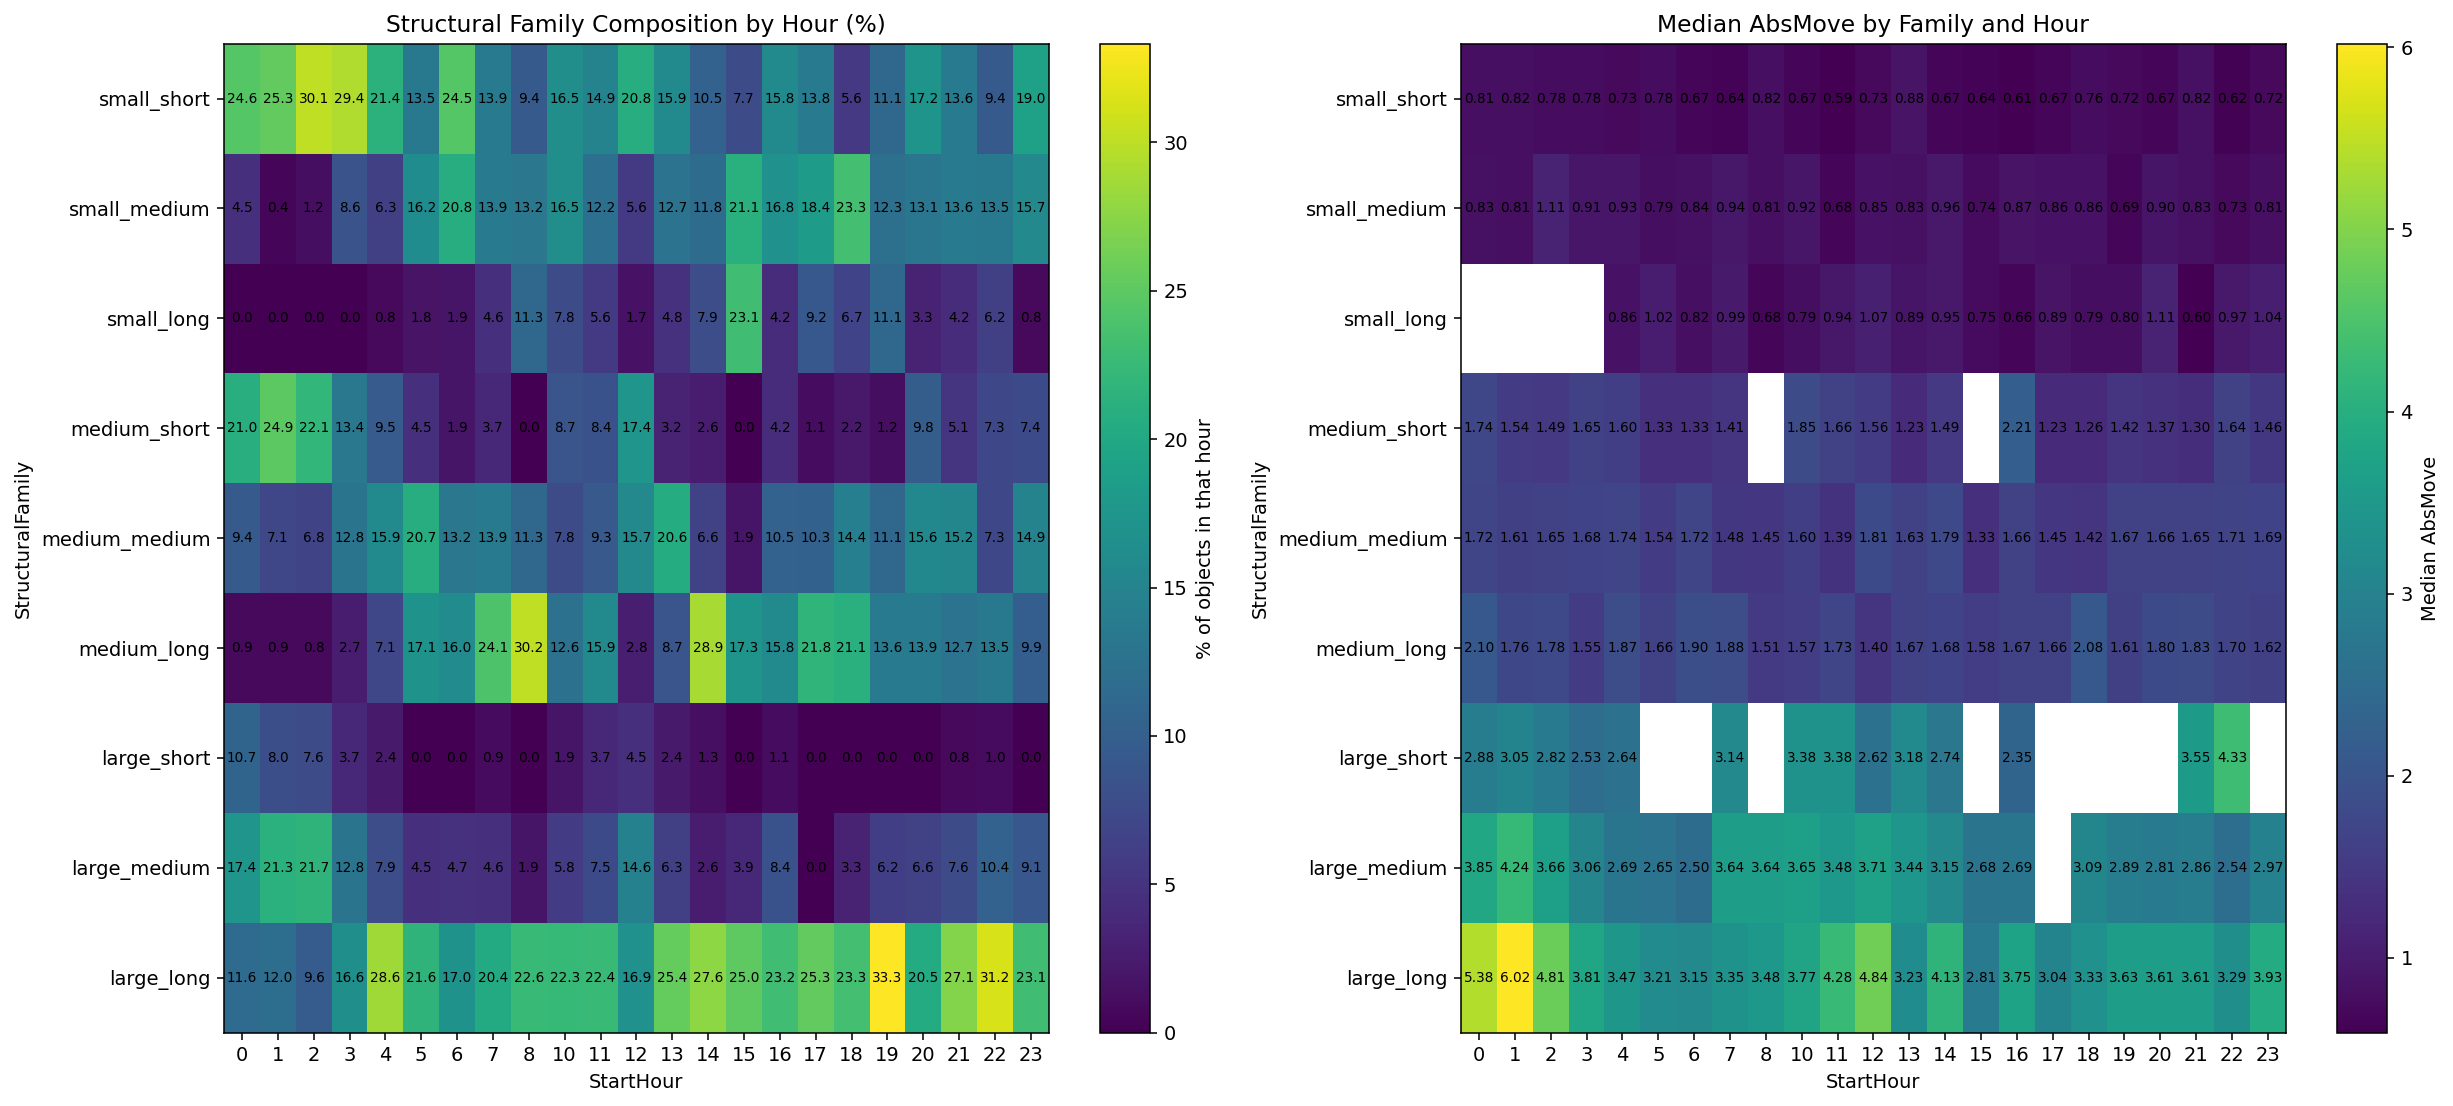

In [21]:
#1-18 Profile DC Structural Families By Hour Of Day

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-13 first.")

ObjDf = DcObjectsDf.copy()

RequiredColumns = [
    "StructuralFamily", "StartTime", "AbsMove", "DurationSec", "MovePerSec", "ConfirmLagPctSec"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in ObjDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

ObjDf["StartTimeDt"] = pd.to_datetime(ObjDf["StartTime"], errors="coerce")
if ObjDf["StartTimeDt"].isna().any():
    raise ValueError("Some StartTime values could not be parsed.")

ObjDf["StartHour"] = ObjDf["StartTimeDt"].dt.hour

HourFamilyCount = (
    ObjDf.groupby(["StartHour", "StructuralFamily"])
    .size()
    .rename("Count")
    .reset_index()
)

HourFamilyCountPivot = (
    HourFamilyCount.pivot(index="StructuralFamily", columns="StartHour", values="Count")
    .reindex(index=FamilyOrder)
    .fillna(0)
)

HourFamilyPctPivot = (
    HourFamilyCountPivot.div(HourFamilyCountPivot.sum(axis=0).replace(0, np.nan), axis=1) * 100
).round(2)

HourMedianMovePivot = (
    ObjDf.groupby(["StructuralFamily", "StartHour"])["AbsMove"]
    .median()
    .unstack("StartHour")
    .reindex(index=FamilyOrder)
    .round(3)
)

HourMedianSpeedPivot = (
    ObjDf.groupby(["StructuralFamily", "StartHour"])["MovePerSec"]
    .median()
    .unstack("StartHour")
    .reindex(index=FamilyOrder)
    .round(4)
)

HourSummary = (
    ObjDf.groupby("StartHour")
    .agg(
        ObjectCount=("StructuralFamily", "count"),
        MedianAbsMove=("AbsMove", "median"),
        MedianDurationSec=("DurationSec", "median"),
        MedianMovePerSec=("MovePerSec", "median"),
        MedianConfirmLagPctSec=("ConfirmLagPctSec", "median"),
    )
    .round(4)
    .reset_index()
)

print("Hourly DC object summary:")
display(HourSummary)

print("Hourly structural-family composition (% within each hour):")
display(HourFamilyPctPivot)

print("Hourly median AbsMove by family:")
display(HourMedianMovePivot)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=140)

Im0 = axes[0].imshow(HourFamilyPctPivot.astype(float), aspect="auto", interpolation="nearest")
axes[0].set_title("Structural Family Composition by Hour (%)")
axes[0].set_xlabel("StartHour")
axes[0].set_ylabel("StructuralFamily")
axes[0].set_xticks(range(len(HourFamilyPctPivot.columns)))
axes[0].set_xticklabels(HourFamilyPctPivot.columns.tolist(), rotation=0)
axes[0].set_yticks(range(len(HourFamilyPctPivot.index)))
axes[0].set_yticklabels(HourFamilyPctPivot.index.tolist())

for i in range(len(HourFamilyPctPivot.index)):
    for j in range(len(HourFamilyPctPivot.columns)):
        Value = HourFamilyPctPivot.iloc[i, j]
        if pd.notna(Value):
            axes[0].text(j, i, f"{Value:.1f}", ha="center", va="center", fontsize=7)

Cbar0 = plt.colorbar(Im0, ax=axes[0])
Cbar0.set_label("% of objects in that hour")

Im1 = axes[1].imshow(HourMedianMovePivot.astype(float), aspect="auto", interpolation="nearest")
axes[1].set_title("Median AbsMove by Family and Hour")
axes[1].set_xlabel("StartHour")
axes[1].set_ylabel("StructuralFamily")
axes[1].set_xticks(range(len(HourMedianMovePivot.columns)))
axes[1].set_xticklabels(HourMedianMovePivot.columns.tolist(), rotation=0)
axes[1].set_yticks(range(len(HourMedianMovePivot.index)))
axes[1].set_yticklabels(HourMedianMovePivot.index.tolist())

for i in range(len(HourMedianMovePivot.index)):
    for j in range(len(HourMedianMovePivot.columns)):
        Value = HourMedianMovePivot.iloc[i, j]
        if pd.notna(Value):
            axes[1].text(j, i, f"{Value:.2f}", ha="center", va="center", fontsize=7)

Cbar1 = plt.colorbar(Im1, ax=axes[1])
Cbar1.set_label("Median AbsMove")

plt.tight_layout()
plt.show()

Fixed-theta sweep summary:


,Theta,SegmentCount,MeanTicksPerSegment,MedianAbsMove,MedianMoveToThetaRatio,MedianDurationSec,MedianConfirmLagPctSec,UpPct,DownPct
0,0.25,4367,53.25,1.090,4.3600,13.4020,18.30,50.01,49.99
1,0.50,2841,81.85,1.640,3.2800,20.0550,21.18,50.02,49.98
2,0.75,2114,110.00,2.145,2.8600,26.0235,22.78,50.00,50.00
3,1.00,1686,137.92,2.550,2.5500,32.2655,23.95,50.00,50.00
4,1.50,1142,203.62,3.400,2.2667,45.8040,25.41,50.00,50.00
5,2.00,830,280.17,4.200,2.1000,63.4465,26.24,50.00,50.00
6,3.00,484,480.45,5.720,1.9067,109.0665,26.78,50.00,50.00


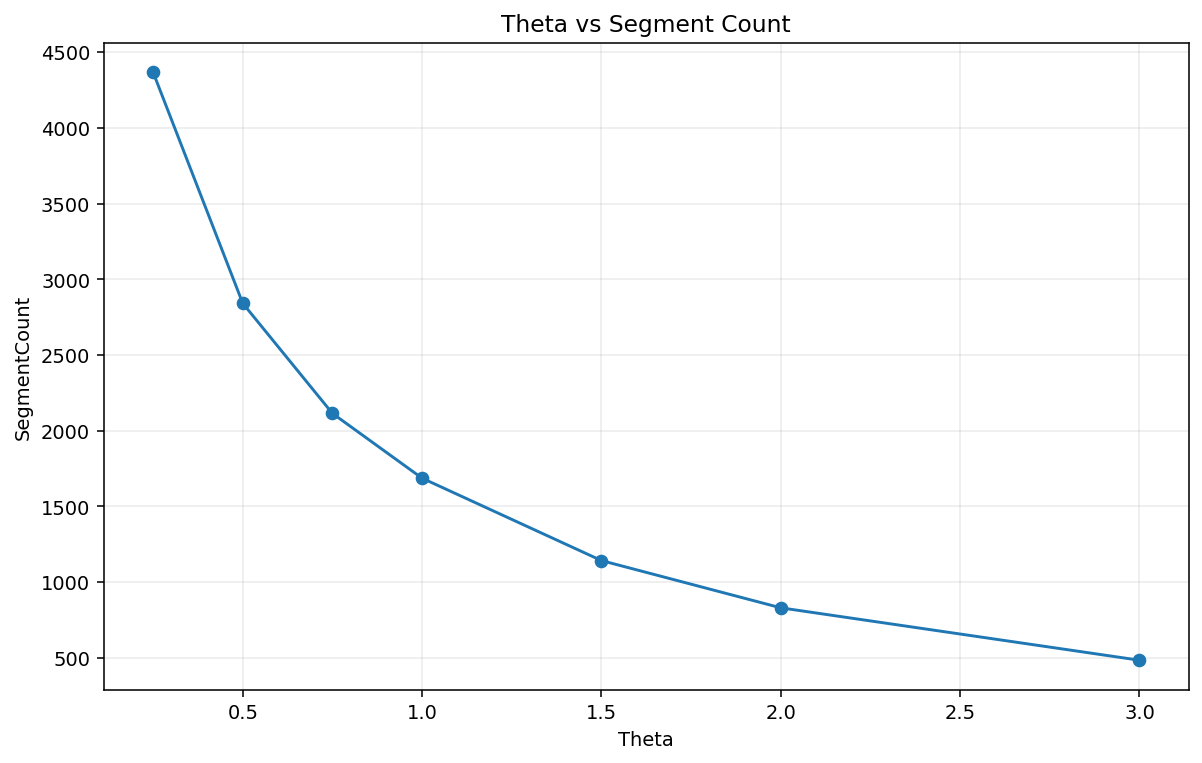

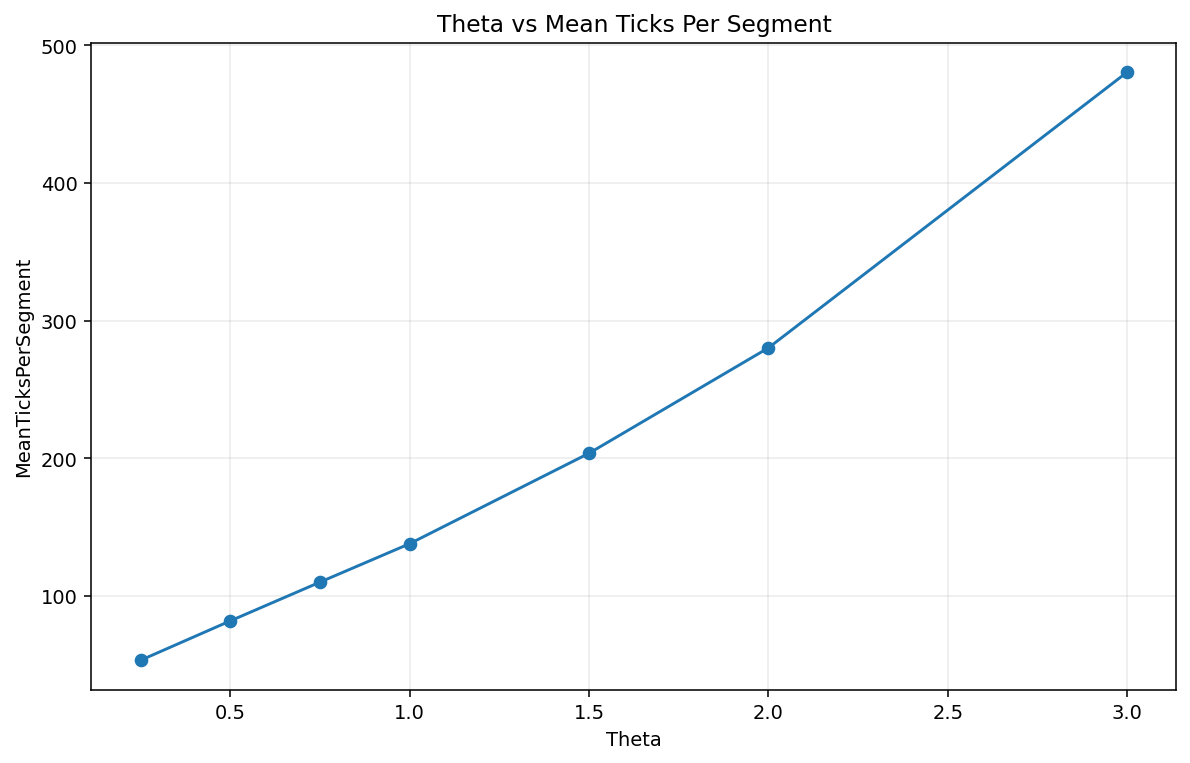

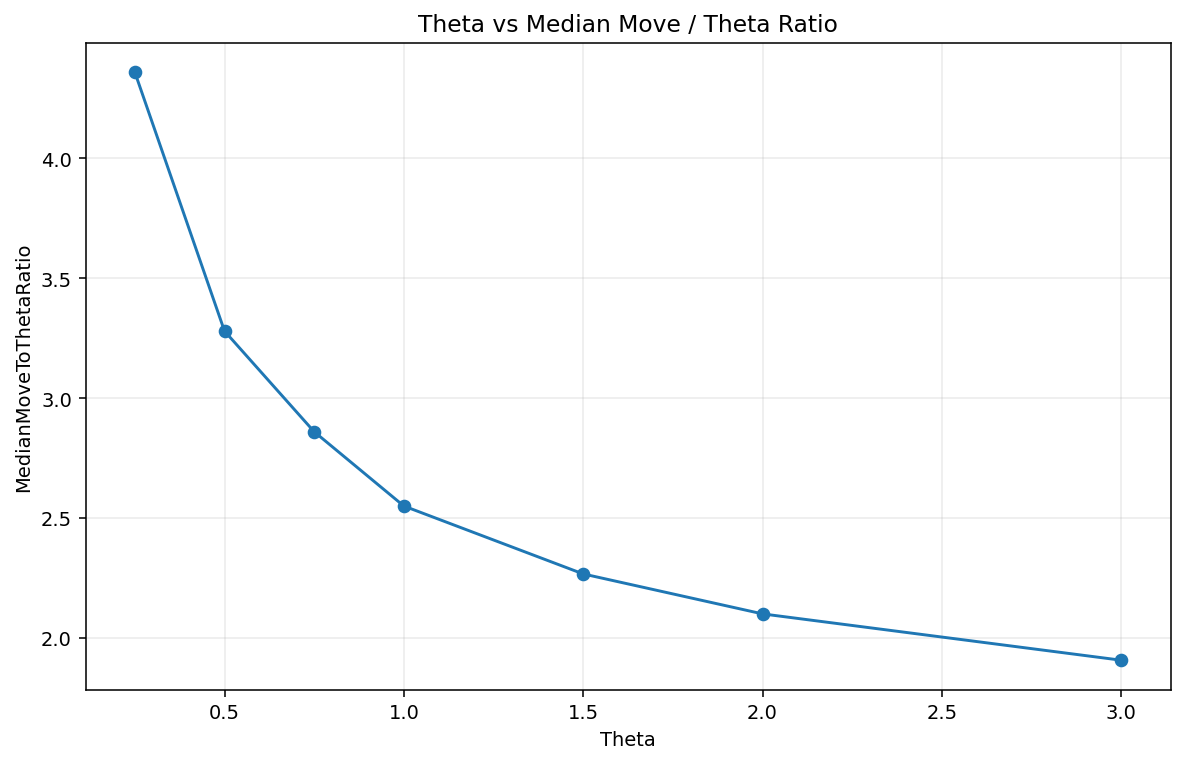

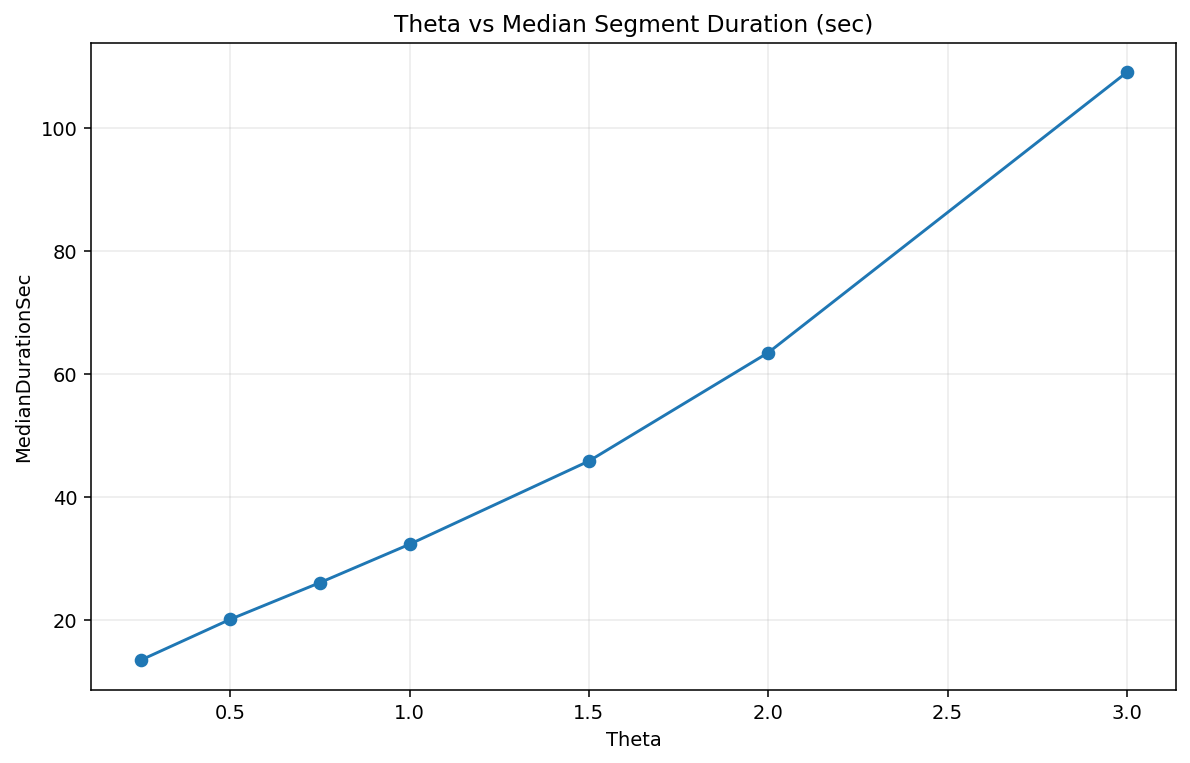

In [22]:
#1-19 Sweep Fixed Theta Grid On KAL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

if "BuildDirectionalChangeSegments" not in globals():
    raise RuntimeError("BuildDirectionalChangeSegments is not defined. Please run cell #1-9 first.")

RequiredColumns = ["id", "timestamp_dt", "kal"]
MissingColumns = [Col for Col in RequiredColumns if Col not in Df.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in Df: {MissingColumns}")

BaseDf = (
    Df.sort_values(["timestamp_dt", "id"])
      .reset_index(drop=True)
      .copy()
)

ThetaGrid = [0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00]

SummaryRows = []

for Theta in ThetaGrid:
    SegDf, OpenState = BuildDirectionalChangeSegments(
        Frame=BaseDf,
        PriceColumn="kal",
        Threshold=Theta
    )

    if len(SegDf) == 0:
        SummaryRows.append({
            "Theta": Theta,
            "SegmentCount": 0,
            "MeanTicksPerSegment": np.nan,
            "MedianAbsMove": np.nan,
            "MedianMoveToThetaRatio": np.nan,
            "MedianDurationSec": np.nan,
            "MedianConfirmLagPctSec": np.nan,
            "UpPct": np.nan,
            "DownPct": np.nan,
        })
        continue

    SegDf = SegDf.copy()
    SegDf["MoveToThetaRatio"] = SegDf["AbsMove"] / Theta
    SegDf["ConfirmLagPctSec"] = (
        SegDf["ConfirmLagSec"] / SegDf["TotalSecToConfirm"].replace(0, np.nan) * 100
    )

    SummaryRows.append({
        "Theta": Theta,
        "SegmentCount": int(len(SegDf)),
        "MeanTicksPerSegment": round(len(BaseDf) / len(SegDf), 2),
        "MedianAbsMove": round(SegDf["AbsMove"].median(), 4),
        "MedianMoveToThetaRatio": round(SegDf["MoveToThetaRatio"].median(), 4),
        "MedianDurationSec": round(SegDf["DurationSec"].median(), 4),
        "MedianConfirmLagPctSec": round(SegDf["ConfirmLagPctSec"].median(), 2),
        "UpPct": round((SegDf["Direction"].eq("up").mean() * 100), 2),
        "DownPct": round((SegDf["Direction"].eq("down").mean() * 100), 2),
    })

ThetaSweepDf = pd.DataFrame(SummaryRows)

print("Fixed-theta sweep summary:")
display(ThetaSweepDf)

plt.figure(figsize=(10, 6), dpi=140)
plt.plot(ThetaSweepDf["Theta"], ThetaSweepDf["SegmentCount"], marker="o")
plt.title("Theta vs Segment Count")
plt.xlabel("Theta")
plt.ylabel("SegmentCount")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 6), dpi=140)
plt.plot(ThetaSweepDf["Theta"], ThetaSweepDf["MeanTicksPerSegment"], marker="o")
plt.title("Theta vs Mean Ticks Per Segment")
plt.xlabel("Theta")
plt.ylabel("MeanTicksPerSegment")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 6), dpi=140)
plt.plot(ThetaSweepDf["Theta"], ThetaSweepDf["MedianMoveToThetaRatio"], marker="o")
plt.title("Theta vs Median Move / Theta Ratio")
plt.xlabel("Theta")
plt.ylabel("MedianMoveToThetaRatio")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 6), dpi=140)
plt.plot(ThetaSweepDf["Theta"], ThetaSweepDf["MedianDurationSec"], marker="o")
plt.title("Theta vs Median Segment Duration (sec)")
plt.xlabel("Theta")
plt.ylabel("MedianDurationSec")
plt.grid(alpha=0.25)
plt.show()

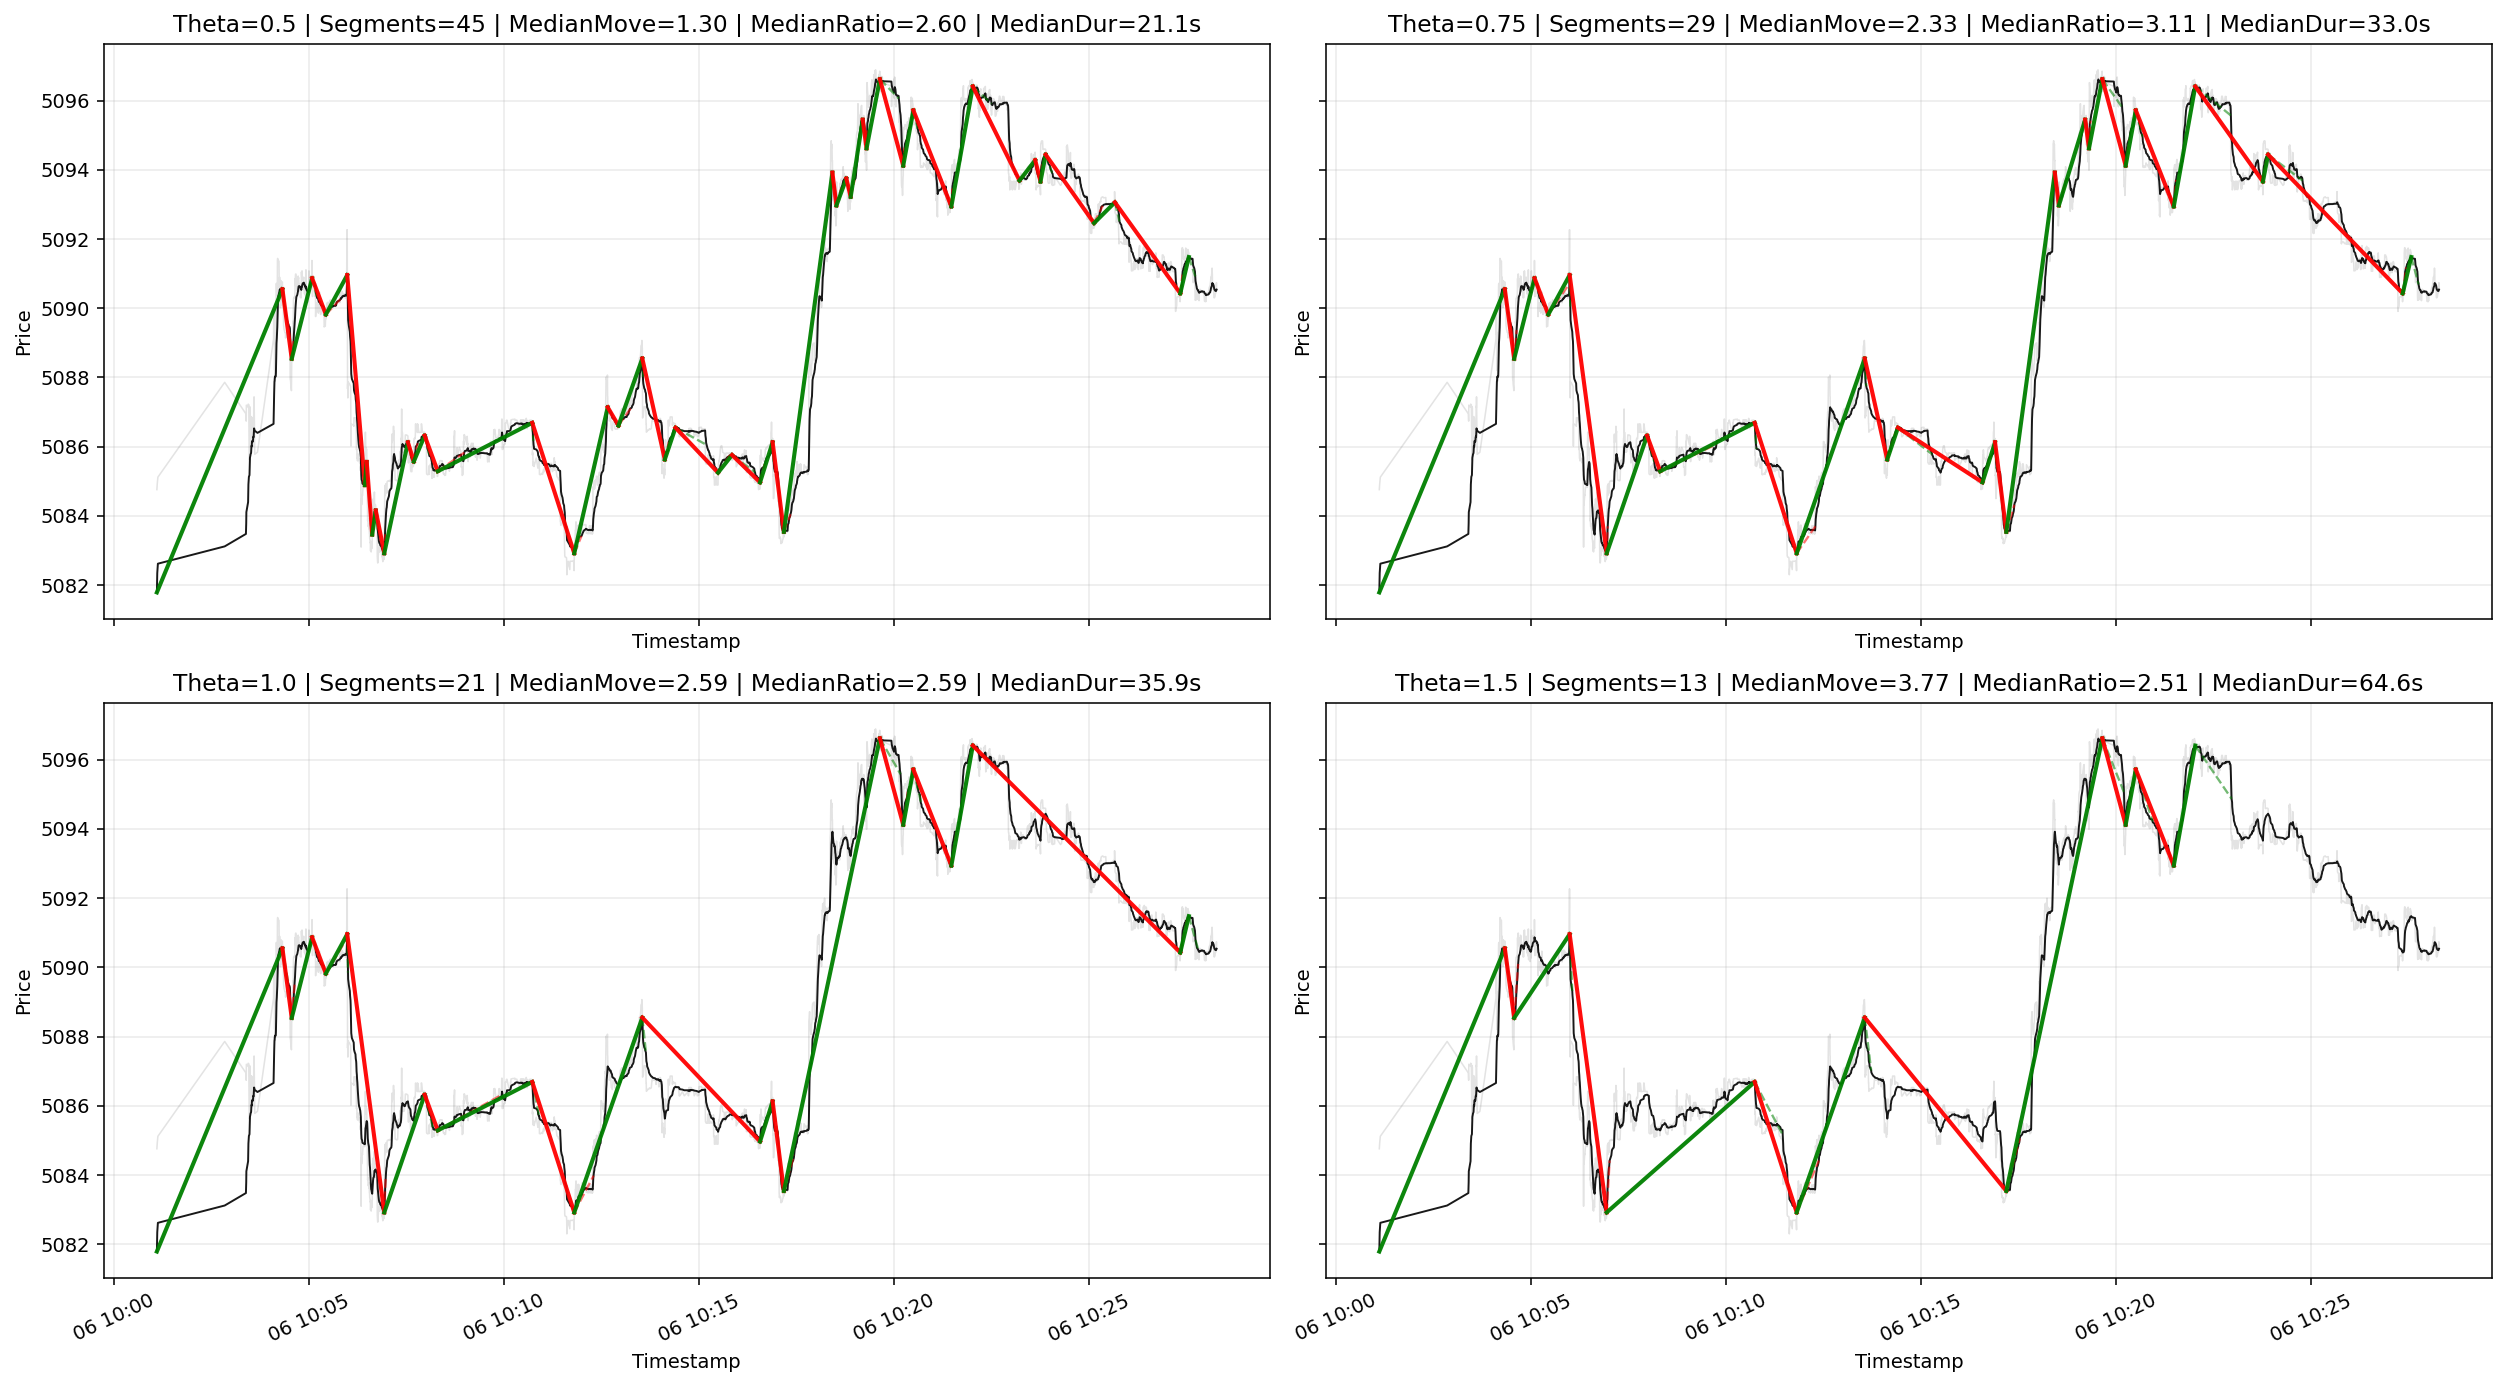

In [23]:
#1-20 Compare Candidate Thetas On The Same Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

if "BuildDirectionalChangeSegments" not in globals():
    raise RuntimeError("BuildDirectionalChangeSegments is not defined. Please run cell #1-9 first.")

RequiredColumns = ["id", "timestamp_dt", "kal", "mid"]
MissingColumns = [Col for Col in RequiredColumns if Col not in Df.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in Df: {MissingColumns}")

BaseDf = (
    Df.sort_values(["timestamp_dt", "id"])
      .reset_index(drop=True)
      .copy()
)

WindowStartRow = 0
WindowRowCount = 3000
WindowEndRow = min(WindowStartRow + WindowRowCount, len(BaseDf))

PlotDf = BaseDf.iloc[WindowStartRow:WindowEndRow].copy()

ThetaList = [0.50, 0.75, 1.00, 1.50]

fig, axes = plt.subplots(2, 2, figsize=(18, 10), dpi=140, sharex=True, sharey=True)
axes = axes.flatten()

for Ax, Theta in zip(axes, ThetaList):
    SegDf, _ = BuildDirectionalChangeSegments(
        Frame=BaseDf,
        PriceColumn="kal",
        Threshold=Theta
    )

    PlotSegDf = SegDf.loc[
        (SegDf["StartRow"] >= WindowStartRow) &
        (SegDf["ConfirmRow"] < WindowEndRow)
    ].copy()

    PlotSegDf["MoveToThetaRatio"] = PlotSegDf["AbsMove"] / Theta

    MedianRatio = PlotSegDf["MoveToThetaRatio"].median() if len(PlotSegDf) > 0 else np.nan
    MedianAbsMove = PlotSegDf["AbsMove"].median() if len(PlotSegDf) > 0 else np.nan
    MedianDurationSec = PlotSegDf["DurationSec"].median() if len(PlotSegDf) > 0 else np.nan

    Ax.plot(
        PlotDf["timestamp_dt"],
        PlotDf["mid"],
        linewidth=0.8,
        alpha=0.22,
        color="gray"
    )

    Ax.plot(
        PlotDf["timestamp_dt"],
        PlotDf["kal"],
        linewidth=1.0,
        alpha=0.9,
        color="black"
    )

    for _, Seg in PlotSegDf.iterrows():
        Color = "green" if Seg["Direction"] == "up" else "red"

        Ax.plot(
            [Seg["StartTime"], Seg["EndTime"]],
            [Seg["StartPrice"], Seg["EndPrice"]],
            color=Color,
            linewidth=2.1,
            alpha=0.95
        )

        Ax.plot(
            [Seg["EndTime"], Seg["ConfirmTime"]],
            [Seg["EndPrice"], Seg["ConfirmPrice"]],
            color=Color,
            linewidth=1.2,
            linestyle="--",
            alpha=0.55
        )

    Ax.set_title(
        f"Theta={Theta} | Segments={len(PlotSegDf)} | "
        f"MedianMove={MedianAbsMove:.2f} | "
        f"MedianRatio={MedianRatio:.2f} | "
        f"MedianDur={MedianDurationSec:.1f}s"
    )
    Ax.grid(alpha=0.25)
    Ax.tick_params(axis="x", rotation=25)

for Ax in axes:
    Ax.set_xlabel("Timestamp")
    Ax.set_ylabel("Price")

plt.tight_layout()
plt.show()

In [24]:
#1-21 Set Working Fixed-Theta Baseline To 0.75

import pandas as pd
import numpy as np

if "Df" not in globals():
    raise RuntimeError("Df is not defined. Please run the earlier cells first.")

if "BuildDirectionalChangeSegments" not in globals():
    raise RuntimeError("BuildDirectionalChangeSegments is not defined. Please run cell #1-9 first.")

RequiredColumns = [
    "id", "timestamp_dt", "bid", "ask", "kal", "mid", "spread", "k2"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in Df.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in Df: {MissingColumns}")

BaseDf = (
    Df.sort_values(["timestamp_dt", "id"])
      .reset_index(drop=True)
      .copy()
)

WorkingTheta = 0.75
WorkingPriceColumn = "kal"

DcSegmentsDf, DcOpenState = BuildDirectionalChangeSegments(
    Frame=BaseDf,
    PriceColumn=WorkingPriceColumn,
    Threshold=WorkingTheta
)

if DcSegmentsDf.empty:
    raise RuntimeError(f"No DC segments were produced for theta={WorkingTheta}.")

DcSegmentsDf = DcSegmentsDf.copy()
DcSegmentsDf["ExcessMove"] = (DcSegmentsDf["AbsMove"] - WorkingTheta).clip(lower=0)
DcSegmentsDf["MoveToThetaRatio"] = DcSegmentsDf["AbsMove"] / WorkingTheta
DcSegmentsDf["MovePerSec"] = DcSegmentsDf["AbsMove"] / DcSegmentsDf["DurationSec"].replace(0, np.nan)
DcSegmentsDf["MovePerTick"] = DcSegmentsDf["AbsMove"] / DcSegmentsDf["DurationTicks"].replace(0, np.nan)
DcSegmentsDf["ConfirmLagPctSec"] = (
    DcSegmentsDf["ConfirmLagSec"] / DcSegmentsDf["TotalSecToConfirm"].replace(0, np.nan) * 100
)
DcSegmentsDf["ConfirmLagPctTicks"] = (
    DcSegmentsDf["ConfirmLagTicks"] / DcSegmentsDf["TotalTicksToConfirm"].replace(0, np.nan) * 100
)

DcObjectsDf = DcSegmentsDf.copy()
DcObjectsDf["SignedMove"] = np.where(
    DcObjectsDf["Direction"].eq("up"),
    DcObjectsDf["AbsMove"],
    -DcObjectsDf["AbsMove"]
)

DcObjectsDf["StartTimeDt"] = pd.to_datetime(DcObjectsDf["StartTime"], errors="coerce")
DcObjectsDf["EndTimeDt"] = pd.to_datetime(DcObjectsDf["EndTime"], errors="coerce")
DcObjectsDf["StartHour"] = DcObjectsDf["StartTimeDt"].dt.hour
DcObjectsDf["EndHour"] = DcObjectsDf["EndTimeDt"].dt.hour

DurationP33 = DcObjectsDf["DurationSec"].quantile(0.33)
DurationP66 = DcObjectsDf["DurationSec"].quantile(0.66)
MoveP33 = DcObjectsDf["AbsMove"].quantile(0.33)
MoveP66 = DcObjectsDf["AbsMove"].quantile(0.66)

def DurationFamily(Value: float) -> str:
    if Value <= DurationP33:
        return "short"
    if Value <= DurationP66:
        return "medium"
    return "long"

def MoveFamily(Value: float) -> str:
    if Value <= MoveP33:
        return "small"
    if Value <= MoveP66:
        return "medium"
    return "large"

DcObjectsDf["DurationFamily"] = DcObjectsDf["DurationSec"].apply(DurationFamily)
DcObjectsDf["MoveFamily"] = DcObjectsDf["AbsMove"].apply(MoveFamily)
DcObjectsDf["StructuralFamily"] = DcObjectsDf["MoveFamily"] + "_" + DcObjectsDf["DurationFamily"]

TransitionDf = DcObjectsDf.sort_values("SegmentId").reset_index(drop=True).copy()
TransitionDf["NextSegmentId"] = TransitionDf["SegmentId"].shift(-1)
TransitionDf["NextDirection"] = TransitionDf["Direction"].shift(-1)
TransitionDf["NextStructuralFamily"] = TransitionDf["StructuralFamily"].shift(-1)
TransitionDf["NextAbsMove"] = TransitionDf["AbsMove"].shift(-1)
TransitionDf["NextDurationSec"] = TransitionDf["DurationSec"].shift(-1)
TransitionDf["NextMovePerSec"] = TransitionDf["MovePerSec"].shift(-1)
TransitionDf["NextConfirmLagPctSec"] = TransitionDf["ConfirmLagPctSec"].shift(-1)
TransitionDf["NextMoveVsCurrentMove"] = (
    TransitionDf["NextAbsMove"] / TransitionDf["AbsMove"].replace(0, np.nan)
)
TransitionDf["NextDurationVsCurrentDuration"] = (
    TransitionDf["NextDurationSec"] / TransitionDf["DurationSec"].replace(0, np.nan)
)
TransitionDf = TransitionDf.iloc[:-1].copy()

WorkingDcSummary = pd.DataFrame([{
    "WorkingTheta": WorkingTheta,
    "PriceColumn": WorkingPriceColumn,
    "SegmentCount": int(len(DcSegmentsDf)),
    "MeanTicksPerSegment": round(len(BaseDf) / len(DcSegmentsDf), 2),
    "MedianAbsMove": round(DcSegmentsDf["AbsMove"].median(), 4),
    "MedianMoveToThetaRatio": round(DcSegmentsDf["MoveToThetaRatio"].median(), 4),
    "MedianDurationSec": round(DcSegmentsDf["DurationSec"].median(), 4),
    "MedianConfirmLagPctSec": round(DcSegmentsDf["ConfirmLagPctSec"].median(), 2),
    "OpenStateDirection": DcOpenState["CurrentDirection"],
    "OpenStatePivotRow": DcOpenState["PivotRow"],
    "OpenStateExtremeRow": DcOpenState["ExtremeRow"],
}])

FamilyCountsDf = (
    DcObjectsDf["StructuralFamily"]
    .value_counts()
    .rename_axis("StructuralFamily")
    .reset_index(name="Count")
)

print("Working fixed-theta baseline has been reset.")
display(WorkingDcSummary)

print("Structural family counts under working theta:")
display(FamilyCountsDf)

print("First 15 working DC objects:")
display(
    DcObjectsDf[
        [
            "SegmentId", "Direction", "StartTime", "EndTime",
            "AbsMove", "MoveToThetaRatio", "DurationSec",
            "ConfirmLagPctSec", "StructuralFamily"
        ]
    ].head(15)
)

Working fixed-theta baseline has been reset.


,WorkingTheta,PriceColumn,SegmentCount,MeanTicksPerSegment,MedianAbsMove,MedianMoveToThetaRatio,MedianDurationSec,MedianConfirmLagPctSec,OpenStateDirection,OpenStatePivotRow,OpenStateExtremeRow
0,0.75,kal,2114,110.0,2.145,2.86,26.0235,22.78,1,232239,232440


Structural family counts under working theta:


,StructuralFamily,Count
0,small_short,409
1,large_long,407
2,medium_medium,260
3,large_medium,236
4,medium_long,221
5,medium_short,215
6,small_medium,201
7,small_long,91
8,large_short,74


First 15 working DC objects:


,SegmentId,Direction,StartTime,EndTime,AbsMove,MoveToThetaRatio,DurationSec,ConfirmLagPctSec,StructuralFamily
0,1,up,2026-03-06 10:01:06.437000+11:00,2026-03-06 10:04:19.566000+11:00,8.76,11.680000,193.129,3.019940,large_long
1,2,down,2026-03-06 10:04:19.566000+11:00,2026-03-06 10:04:33.904000+11:00,2.01,2.680000,14.338,20.933054,medium_short
2,3,up,2026-03-06 10:04:33.904000+11:00,2026-03-06 10:05:05.250000+11:00,2.33,3.106667,31.346,29.467621,medium_medium
3,4,down,2026-03-06 10:05:05.250000+11:00,2026-03-06 10:05:26.390000+11:00,1.05,1.400000,21.140,60.557494,small_medium
4,5,up,2026-03-06 10:05:26.390000+11:00,2026-03-06 10:05:59.291000+11:00,1.14,1.520000,32.901,2.754707,small_medium
5,6,down,2026-03-06 10:05:59.291000+11:00,2026-03-06 10:06:56.254000+11:00,8.04,10.720000,56.963,2.768627,large_long
6,7,up,2026-03-06 10:06:56.254000+11:00,2026-03-06 10:07:58.405000+11:00,3.40,4.533333,62.151,14.980438,large_long
7,8,down,2026-03-06 10:07:58.405000+11:00,2026-03-06 10:08:18.497000+11:00,1.03,1.373333,20.092,81.139054,small_medium
8,9,up,2026-03-06 10:08:18.497000+11:00,2026-03-06 10:10:43.950000+11:00,1.40,1.866667,145.453,1.813825,small_long
9,10,down,2026-03-06 10:10:43.950000+11:00,2026-03-06 10:11:48.526000+11:00,3.77,5.026667,64.576,30.831932,large_long


In [25]:
#1-22 Test Structural-Family Stability Across Chronological Phases

import pandas as pd
import numpy as np

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-21 first.")

ObjDf = DcObjectsDf.copy()

RequiredColumns = [
    "SegmentId", "StructuralFamily", "StartTimeDt",
    "AbsMove", "DurationSec", "MovePerSec", "ConfirmLagPctSec"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in ObjDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

ObjDf = ObjDf.sort_values(["StartTimeDt", "SegmentId"]).reset_index(drop=True).copy()
ObjDf["ChronoPhase"] = pd.qcut(
    ObjDf.index,
    q=4,
    labels=["P1", "P2", "P3", "P4"]
)

PhaseSummaryDf = (
    ObjDf.groupby("ChronoPhase", observed=False)
    .agg(
        ObjectCount=("SegmentId", "count"),
        MedianAbsMove=("AbsMove", "median"),
        MedianDurationSec=("DurationSec", "median"),
        MedianMovePerSec=("MovePerSec", "median"),
        MedianConfirmLagPctSec=("ConfirmLagPctSec", "median"),
    )
    .round(4)
    .reset_index()
)

FamilyPhaseCountPivot = (
    ObjDf.groupby(["StructuralFamily", "ChronoPhase"], observed=False)
    .size()
    .unstack("ChronoPhase")
    .reindex(FamilyOrder)
    .fillna(0)
    .astype(int)
)

FamilyPhasePctPivot = (
    FamilyPhaseCountPivot.div(FamilyPhaseCountPivot.sum(axis=0).replace(0, np.nan), axis=1) * 100
).round(2)

FamilyPhaseMetricDf = (
    ObjDf.groupby(["StructuralFamily", "ChronoPhase"], observed=False)
    .agg(
        Count=("SegmentId", "count"),
        MedianAbsMove=("AbsMove", "median"),
        MedianDurationSec=("DurationSec", "median"),
        MedianMovePerSec=("MovePerSec", "median"),
        MedianConfirmLagPctSec=("ConfirmLagPctSec", "median"),
    )
    .reset_index()
)

GlobalFamilyMetricDf = (
    ObjDf.groupby("StructuralFamily", observed=False)
    .agg(
        TotalCount=("SegmentId", "count"),
        GlobalMedianAbsMove=("AbsMove", "median"),
        GlobalMedianDurationSec=("DurationSec", "median"),
        GlobalMedianMovePerSec=("MovePerSec", "median"),
        GlobalMedianConfirmLagPctSec=("ConfirmLagPctSec", "median"),
    )
    .reindex(FamilyOrder)
    .reset_index()
)

MinSupportPerPhase = 15
StabilityRows = []

for Family in FamilyOrder:
    FamilyPhaseSlice = FamilyPhaseMetricDf.loc[
        (FamilyPhaseMetricDf["StructuralFamily"] == Family) &
        (FamilyPhaseMetricDf["Count"] >= MinSupportPerPhase)
    ].copy()

    GlobalRow = GlobalFamilyMetricDf.loc[GlobalFamilyMetricDf["StructuralFamily"] == Family].iloc[0]

    if len(FamilyPhaseSlice) == 0:
        StabilityRows.append({
            "StructuralFamily": Family,
            "TotalCount": int(GlobalRow["TotalCount"]),
            "SupportedPhases": 0,
            "MinPhaseCount": 0,
            "MaxPhaseCount": 0,
            "GlobalMedianAbsMove": np.nan,
            "AbsMoveMaxMinRatio": np.nan,
            "DurationMaxMinRatio": np.nan,
            "SpeedMaxMinRatio": np.nan,
            "ConfirmLagMaxMinRatio": np.nan,
        })
        continue

    AbsSeries = FamilyPhaseSlice["MedianAbsMove"]
    DurSeries = FamilyPhaseSlice["MedianDurationSec"]
    SpeedSeries = FamilyPhaseSlice["MedianMovePerSec"]
    LagSeries = FamilyPhaseSlice["MedianConfirmLagPctSec"]

    StabilityRows.append({
        "StructuralFamily": Family,
        "TotalCount": int(GlobalRow["TotalCount"]),
        "SupportedPhases": int(len(FamilyPhaseSlice)),
        "MinPhaseCount": int(FamilyPhaseSlice["Count"].min()),
        "MaxPhaseCount": int(FamilyPhaseSlice["Count"].max()),
        "GlobalMedianAbsMove": round(float(GlobalRow["GlobalMedianAbsMove"]), 4),
        "AbsMoveMaxMinRatio": round(float(AbsSeries.max() / AbsSeries.min()), 4) if AbsSeries.min() > 0 else np.nan,
        "DurationMaxMinRatio": round(float(DurSeries.max() / DurSeries.min()), 4) if DurSeries.min() > 0 else np.nan,
        "SpeedMaxMinRatio": round(float(SpeedSeries.max() / SpeedSeries.min()), 4) if SpeedSeries.min() > 0 else np.nan,
        "ConfirmLagMaxMinRatio": round(float(LagSeries.max() / LagSeries.min()), 4) if LagSeries.min() > 0 else np.nan,
    })

FamilyStabilityDf = pd.DataFrame(StabilityRows).sort_values(
    ["AbsMoveMaxMinRatio", "DurationMaxMinRatio", "SpeedMaxMinRatio"],
    ascending=[True, True, True]
).reset_index(drop=True)

AbsMovePhasePivot = (
    FamilyPhaseMetricDf.pivot(index="StructuralFamily", columns="ChronoPhase", values="MedianAbsMove")
    .reindex(FamilyOrder)
    .round(4)
)

DurationPhasePivot = (
    FamilyPhaseMetricDf.pivot(index="StructuralFamily", columns="ChronoPhase", values="MedianDurationSec")
    .reindex(FamilyOrder)
    .round(4)
)

SpeedPhasePivot = (
    FamilyPhaseMetricDf.pivot(index="StructuralFamily", columns="ChronoPhase", values="MedianMovePerSec")
    .reindex(FamilyOrder)
    .round(4)
)

print(f"Working theta: {WorkingTheta}")
print(f"Minimum support per family-phase for stability ratios: {MinSupportPerPhase}")
print()

print("Chronological phase summary:")
display(PhaseSummaryDf)

print("Structural-family composition by chronological phase (% within phase):")
display(FamilyPhasePctPivot)

print("Family stability summary:")
display(FamilyStabilityDf)

print("Median AbsMove by family and phase:")
display(AbsMovePhasePivot)

print("Median DurationSec by family and phase:")
display(DurationPhasePivot)

print("Median MovePerSec by family and phase:")
display(SpeedPhasePivot)

Working theta: 0.75
Minimum support per family-phase for stability ratios: 15

Chronological phase summary:


,ChronoPhase,ObjectCount,MedianAbsMove,MedianDurationSec,MedianMovePerSec,MedianConfirmLagPctSec
0,P1,529,2.150,31.3460,0.0677,22.7911
1,P2,528,2.150,36.5495,0.0617,22.9526
2,P3,528,2.435,15.4520,0.1703,21.8416
3,P4,529,1.980,27.2360,0.0719,23.8161


Structural-family composition by chronological phase (% within phase):


ChronoPhase,P1,P2,P3,P4
StructuralFamily,,,,
small_short,13.99,15.53,28.22,19.66
small_medium,12.10,10.80,2.65,12.48
small_long,6.24,7.01,0.00,3.97
medium_short,9.83,3.98,18.56,8.32
medium_medium,10.59,15.53,8.33,14.74
medium_long,13.04,14.58,0.95,13.23
large_short,2.65,0.76,8.90,1.70
large_medium,8.88,6.44,22.92,6.43
large_long,22.68,25.38,9.47,19.47


Family stability summary:


...

ChronoPhase,P1,P2,P3,P4
StructuralFamily,,,,
small_short,1.040,1.075,1.130,1.040
small_medium,1.155,1.180,1.330,1.155
small_long,1.180,1.330,NaN,1.390
medium_short,1.940,2.040,2.125,1.890
medium_medium,2.015,2.040,2.145,2.095
medium_long,2.180,2.290,2.470,2.200
large_short,3.420,3.070,3.610,3.620
large_medium,4.390,3.575,4.540,3.470
large_long,4.725,4.290,6.660,4.010


Median DurationSec by family and phase:


ChronoPhase,P1,P2,P3,P4
StructuralFamily,,,,
small_short,11.0100,11.2705,7.0220,10.2495
small_medium,25.9410,24.6150,21.4570,23.2575
small_long,51.3720,51.8100,NaN,48.8240
medium_short,11.9575,12.8930,10.3505,12.9885
medium_medium,24.8605,27.9965,21.4580,25.6080
medium_long,59.3760,59.7410,43.8930,57.3295
large_short,15.5565,13.8215,14.2400,14.1370
large_medium,28.6100,26.2615,26.0900,29.4665
large_long,75.4360,75.7780,51.1460,65.6790


Median MovePerSec by family and phase:


ChronoPhase,P1,P2,P3,P4
StructuralFamily,,,,
small_short,0.1033,0.0950,0.1509,0.0976
small_medium,0.0454,0.0462,0.0600,0.0470
small_long,0.0216,0.0236,NaN,0.0248
medium_short,0.1688,0.1476,0.2205,0.1489
medium_medium,0.0768,0.0760,0.0984,0.0846
medium_long,0.0367,0.0363,0.0470,0.0349
large_short,0.2413,0.2196,0.2646,0.2608
large_medium,0.1539,0.1417,0.1841,0.1250
large_long,0.0566,0.0572,0.1260,0.0590


In [26]:
#1-23 Test Family Stability In Phase-Relative Percentile Space

import pandas as pd
import numpy as np

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-21 first.")

ObjDf = DcObjectsDf.copy()

RequiredColumns = [
    "SegmentId", "StructuralFamily", "StartTimeDt",
    "AbsMove", "DurationSec", "MovePerSec", "ConfirmLagPctSec"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in ObjDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

ObjDf = ObjDf.sort_values(["StartTimeDt", "SegmentId"]).reset_index(drop=True).copy()

if "ChronoPhase" not in ObjDf.columns:
    ObjDf["ChronoPhase"] = pd.qcut(
        ObjDf.index,
        q=4,
        labels=["P1", "P2", "P3", "P4"]
    )

# Phase-relative percentile ranks
ObjDf["AbsMovePctInPhase"] = (
    ObjDf.groupby("ChronoPhase", observed=False)["AbsMove"]
         .rank(method="average", pct=True)
)

ObjDf["DurationPctInPhase"] = (
    ObjDf.groupby("ChronoPhase", observed=False)["DurationSec"]
         .rank(method="average", pct=True)
)

ObjDf["SpeedPctInPhase"] = (
    ObjDf.groupby("ChronoPhase", observed=False)["MovePerSec"]
         .rank(method="average", pct=True)
)

ObjDf["ConfirmLagPctInPhase"] = (
    ObjDf.groupby("ChronoPhase", observed=False)["ConfirmLagPctSec"]
         .rank(method="average", pct=True)
)

PhaseRelativeMetricDf = (
    ObjDf.groupby(["StructuralFamily", "ChronoPhase"], observed=False)
    .agg(
        Count=("SegmentId", "count"),
        MedianAbsMovePctInPhase=("AbsMovePctInPhase", "median"),
        MedianDurationPctInPhase=("DurationPctInPhase", "median"),
        MedianSpeedPctInPhase=("SpeedPctInPhase", "median"),
        MedianConfirmLagPctInPhase=("ConfirmLagPctInPhase", "median"),
    )
    .reset_index()
)

MinSupportPerPhase = 15
StabilityRows = []

for Family in FamilyOrder:
    SliceDf = PhaseRelativeMetricDf.loc[
        (PhaseRelativeMetricDf["StructuralFamily"] == Family) &
        (PhaseRelativeMetricDf["Count"] >= MinSupportPerPhase)
    ].copy()

    if len(SliceDf) == 0:
        StabilityRows.append({
            "StructuralFamily": Family,
            "SupportedPhases": 0,
            "MedianAbsMovePctRange": np.nan,
            "MedianDurationPctRange": np.nan,
            "MedianSpeedPctRange": np.nan,
            "MedianConfirmLagPctRange": np.nan,
        })
        continue

    StabilityRows.append({
        "StructuralFamily": Family,
        "SupportedPhases": int(len(SliceDf)),
        "MedianAbsMovePctRange": round(
            float(SliceDf["MedianAbsMovePctInPhase"].max() - SliceDf["MedianAbsMovePctInPhase"].min()), 4
        ),
        "MedianDurationPctRange": round(
            float(SliceDf["MedianDurationPctInPhase"].max() - SliceDf["MedianDurationPctInPhase"].min()), 4
        ),
        "MedianSpeedPctRange": round(
            float(SliceDf["MedianSpeedPctInPhase"].max() - SliceDf["MedianSpeedPctInPhase"].min()), 4
        ),
        "MedianConfirmLagPctRange": round(
            float(SliceDf["MedianConfirmLagPctInPhase"].max() - SliceDf["MedianConfirmLagPctInPhase"].min()), 4
        ),
    })

PhaseRelativeStabilityDf = (
    pd.DataFrame(StabilityRows)
    .sort_values(
        ["MedianAbsMovePctRange", "MedianDurationPctRange", "MedianSpeedPctRange"],
        ascending=[True, True, True]
    )
    .reset_index(drop=True)
)

AbsMovePctPivot = (
    PhaseRelativeMetricDf.pivot(
        index="StructuralFamily",
        columns="ChronoPhase",
        values="MedianAbsMovePctInPhase"
    )
    .reindex(FamilyOrder)
    .round(4)
)

DurationPctPivot = (
    PhaseRelativeMetricDf.pivot(
        index="StructuralFamily",
        columns="ChronoPhase",
        values="MedianDurationPctInPhase"
    )
    .reindex(FamilyOrder)
    .round(4)
)

SpeedPctPivot = (
    PhaseRelativeMetricDf.pivot(
        index="StructuralFamily",
        columns="ChronoPhase",
        values="MedianSpeedPctInPhase"
    )
    .reindex(FamilyOrder)
    .round(4)
)

print(f"Working theta: {WorkingTheta}")
print(f"Minimum support per family-phase for relative-stability ranges: {MinSupportPerPhase}")
print()

print("Phase-relative family stability summary:")
display(PhaseRelativeStabilityDf)

print("Median AbsMove percentile within phase:")
display(AbsMovePctPivot)

print("Median Duration percentile within phase:")
display(DurationPctPivot)

print("Median MovePerSec percentile within phase:")
display(SpeedPctPivot)

Working theta: 0.75
Minimum support per family-phase for relative-stability ranges: 15

Phase-relative family stability summary:


,StructuralFamily,SupportedPhases,MedianAbsMovePctRange,MedianDurationPctRange,MedianSpeedPctRange,MedianConfirmLagPctRange
0,large_short,1,0.0000,0.0000,0.0000,0.0000
1,small_short,4,0.0182,0.0975,0.3447,0.0903
2,small_medium,3,0.0209,0.0835,0.0488,0.1153
3,medium_short,4,0.0327,0.2093,0.2491,0.1216
4,large_medium,4,0.0392,0.3807,0.3438,0.2945
5,large_long,4,0.0508,0.1345,0.1449,0.1553
6,medium_long,3,0.0595,0.0639,0.0671,0.0803
7,medium_medium,4,0.0889,0.2841,0.4612,0.1259
8,small_long,3,0.0955,0.0611,0.0171,0.1428


Median AbsMove percentile within phase:


ChronoPhase,P1,P2,P3,P4
StructuralFamily,,,,
small_short,0.1295,0.1406,0.1477,0.1465
small_medium,0.1857,0.1790,0.2211,0.1999
small_long,0.2060,0.2348,NaN,0.3015
medium_short,0.4556,0.4782,0.4455,0.4745
medium_medium,0.4745,0.4782,0.4508,0.5397
medium_long,0.5113,0.5426,0.5028,0.5709
large_short,0.7221,0.7131,0.6960,0.8346
large_medium,0.8185,0.7794,0.7879,0.8147
large_long,0.8459,0.8570,0.8968,0.8847


Median Duration percentile within phase:


ChronoPhase,P1,P2,P3,P4
StructuralFamily,,,,
small_short,0.1125,0.0900,0.1875,0.1163
small_medium,0.4112,0.3466,0.6752,0.4301
small_long,0.6900,0.6648,NaN,0.7259
medium_short,0.1380,0.1136,0.3229,0.1862
medium_medium,0.4017,0.3930,0.6771,0.4716
medium_long,0.7561,0.7197,0.9205,0.7836
large_short,0.2108,0.1316,0.4583,0.2212
large_medium,0.4631,0.3731,0.7538,0.5284
large_long,0.8422,0.8153,0.9498,0.8374


Median MovePerSec percentile within phase:


ChronoPhase,P1,P2,P3,P4
StructuralFamily,,,,
small_short,0.6720,0.7614,0.4167,0.6853
small_medium,0.3006,0.3106,0.0312,0.2618
small_long,0.0681,0.0720,NaN,0.0548
medium_short,0.8648,0.9167,0.6676,0.8875
medium_medium,0.5671,0.6364,0.1752,0.6002
medium_long,0.2004,0.1970,0.0133,0.1333
large_short,0.9405,0.9801,0.8125,0.9849
large_medium,0.8355,0.9025,0.5587,0.8100
large_long,0.4130,0.4527,0.3078,0.4026


In [27]:
#1-24 Test Hybrid Vocabulary: Absolute Move Family × Phase-Relative Duration Family

import pandas as pd
import numpy as np

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-21 first.")

ObjDf = DcObjectsDf.copy()

RequiredColumns = ["SegmentId", "StartTimeDt", "MoveFamily", "StructuralFamily", "DurationSec"]
MissingColumns = [Col for Col in RequiredColumns if Col not in ObjDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

ObjDf = ObjDf.sort_values(["StartTimeDt", "SegmentId"]).reset_index(drop=True).copy()

if "ChronoPhase" not in ObjDf.columns:
    ObjDf["ChronoPhase"] = pd.qcut(
        ObjDf.index,
        q=4,
        labels=["P1", "P2", "P3", "P4"]
    )

# Phase-relative duration percentile
ObjDf["DurationPctInPhase"] = (
    ObjDf.groupby("ChronoPhase", observed=False)["DurationSec"]
         .rank(method="average", pct=True)
)

# Phase-relative duration family
ObjDf["DurationRelFamily"] = pd.cut(
    ObjDf["DurationPctInPhase"],
    bins=[0.0, 1/3, 2/3, 1.0],
    labels=["short", "medium", "long"],
    include_lowest=True
).astype(str)

ObjDf["HybridStructuralFamily"] = ObjDf["MoveFamily"].astype(str) + "_" + ObjDf["DurationRelFamily"].astype(str)

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

MinSupportPerPhase = 15

def BuildPhaseCountSummary(Frame: pd.DataFrame, FamilyColumn: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    CountPivot = (
        Frame.groupby([FamilyColumn, "ChronoPhase"], observed=False)
             .size()
             .unstack("ChronoPhase")
             .reindex(FamilyOrder)
             .fillna(0)
             .astype(int)
    )

    PctPivot = (
        CountPivot.div(CountPivot.sum(axis=0).replace(0, np.nan), axis=1) * 100
    ).round(2)

    Rows = []
    for Family in FamilyOrder:
        Counts = CountPivot.loc[Family]
        Supported = Counts[Counts >= MinSupportPerPhase]

        if len(Supported) == 0:
            Rows.append({
                "Family": Family,
                "TotalCount": int(Counts.sum()),
                "SupportedPhases": 0,
                "MinPhaseCount": 0,
                "MaxPhaseCount": 0,
                "MaxMinCountRatio": np.nan
            })
            continue

        Rows.append({
            "Family": Family,
            "TotalCount": int(Counts.sum()),
            "SupportedPhases": int(len(Supported)),
            "MinPhaseCount": int(Supported.min()),
            "MaxPhaseCount": int(Supported.max()),
            "MaxMinCountRatio": round(float(Supported.max() / Supported.min()), 4)
        })

    SummaryDf = pd.DataFrame(Rows).sort_values(
        ["MaxMinCountRatio", "TotalCount"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return CountPivot, PctPivot, SummaryDf

CurrentCountPivot, CurrentPctPivot, CurrentStabilityDf = BuildPhaseCountSummary(ObjDf, "StructuralFamily")
HybridCountPivot, HybridPctPivot, HybridStabilityDf = BuildPhaseCountSummary(ObjDf, "HybridStructuralFamily")

CurrentSupported = CurrentStabilityDf.loc[CurrentStabilityDf["SupportedPhases"] >= 3, "MaxMinCountRatio"].dropna()
HybridSupported = HybridStabilityDf.loc[HybridStabilityDf["SupportedPhases"] >= 3, "MaxMinCountRatio"].dropna()

ComparisonDf = pd.DataFrame([{
    "MinSupportPerPhase": MinSupportPerPhase,
    "CurrentFamilies_SupportedGe3": int(len(CurrentSupported)),
    "HybridFamilies_SupportedGe3": int(len(HybridSupported)),
    "Current_MedianMaxMinCountRatio": round(float(CurrentSupported.median()), 4) if len(CurrentSupported) else np.nan,
    "Hybrid_MedianMaxMinCountRatio": round(float(HybridSupported.median()), 4) if len(HybridSupported) else np.nan,
    "Current_MeanMaxMinCountRatio": round(float(CurrentSupported.mean()), 4) if len(CurrentSupported) else np.nan,
    "Hybrid_MeanMaxMinCountRatio": round(float(HybridSupported.mean()), 4) if len(HybridSupported) else np.nan,
}])

HybridFamilyCountsDf = (
    ObjDf["HybridStructuralFamily"]
    .value_counts()
    .rename_axis("HybridStructuralFamily")
    .reset_index(name="Count")
)

print("Current vs hybrid phase-balance comparison:")
display(ComparisonDf)

print("Current-family phase stability:")
display(CurrentStabilityDf)

print("Hybrid-family phase stability:")
display(HybridStabilityDf)

print("Hybrid family counts:")
display(HybridFamilyCountsDf)

print("Hybrid family composition by chronological phase (% within phase):")
display(HybridPctPivot)

Current vs hybrid phase-balance comparison:


,MinSupportPerPhase,CurrentFamilies_SupportedGe3,HybridFamilies_SupportedGe3,Current_MedianMaxMinCountRatio,Hybrid_MedianMaxMinCountRatio,Current_MeanMaxMinCountRatio,Hybrid_MeanMaxMinCountRatio
0,15,8,8,1.9385,1.4088,2.3523,1.4899


Current-family phase stability:


,Family,TotalCount,SupportedPhases,MinPhaseCount,MaxPhaseCount,MaxMinCountRatio
0,large_short,74,1,47,47,1.0000
1,medium_long,221,3,69,77,1.1159
2,small_medium,201,3,57,66,1.1579
3,small_long,91,3,21,37,1.7619
4,medium_medium,260,4,44,82,1.8636
5,small_short,409,4,74,149,2.0135
6,large_long,407,4,50,134,2.6800
7,large_medium,236,4,34,121,3.5588
8,medium_short,215,4,21,98,4.6667


Hybrid-family phase stability:


,Family,TotalCount,SupportedPhases,MinPhaseCount,MaxPhaseCount,MaxMinCountRatio
0,large_short,59,2,19,20,1.0526
1,small_long,64,3,18,20,1.1111
2,small_short,427,4,92,114,1.2391
3,medium_medium,289,4,63,84,1.3333
4,medium_short,218,4,48,65,1.3542
5,small_medium,210,4,41,60,1.4634
6,large_long,453,4,95,140,1.4737
7,large_medium,205,4,41,68,1.6585
8,medium_long,189,4,28,64,2.2857


Hybrid family counts:


,HybridStructuralFamily,Count
0,large_long,453
1,small_short,427
2,medium_medium,289
3,medium_short,218
4,small_medium,210
5,large_medium,205
6,medium_long,189
7,small_long,64
8,large_short,59


Hybrid family composition by chronological phase (% within phase):


ChronoPhase,P1,P2,P3,P4
HybridStructuralFamily,,,,
small_short,17.39,20.45,21.59,21.36
small_medium,11.15,9.47,7.77,11.34
small_long,3.78,3.41,1.52,3.40
medium_short,12.29,9.09,9.85,10.02
medium_medium,11.91,15.91,12.69,14.18
medium_long,9.26,9.09,5.30,12.10
large_short,3.59,3.79,1.89,1.89
large_medium,10.21,7.95,12.88,7.75
large_long,20.42,20.83,26.52,17.96


In [28]:
#1-25 Compare Current vs Hybrid Transition-Behavior Stability Across Phases

import pandas as pd
import numpy as np

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-21 first.")

ObjDf = DcObjectsDf.copy()

RequiredColumns = [
    "SegmentId", "StartTimeDt", "AbsMove", "DurationSec", "MovePerSec",
    "MoveFamily", "StructuralFamily"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in ObjDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

ObjDf = ObjDf.sort_values(["SegmentId"]).reset_index(drop=True).copy()

if "ChronoPhase" not in ObjDf.columns:
    ObjDf = ObjDf.sort_values(["StartTimeDt", "SegmentId"]).reset_index(drop=True)
    ObjDf["ChronoPhase"] = pd.qcut(
        ObjDf.index,
        q=4,
        labels=["P1", "P2", "P3", "P4"]
    )
    ObjDf = ObjDf.sort_values(["SegmentId"]).reset_index(drop=True)

if "HybridStructuralFamily" not in ObjDf.columns:
    ObjDf = ObjDf.sort_values(["StartTimeDt", "SegmentId"]).reset_index(drop=True)
    ObjDf["DurationPctInPhase"] = (
        ObjDf.groupby("ChronoPhase", observed=False)["DurationSec"]
             .rank(method="average", pct=True)
    )
    ObjDf["DurationRelFamily"] = pd.cut(
        ObjDf["DurationPctInPhase"],
        bins=[0.0, 1/3, 2/3, 1.0],
        labels=["short", "medium", "long"],
        include_lowest=True
    ).astype(str)
    ObjDf["HybridStructuralFamily"] = ObjDf["MoveFamily"].astype(str) + "_" + ObjDf["DurationRelFamily"].astype(str)
    ObjDf = ObjDf.sort_values(["SegmentId"]).reset_index(drop=True)

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

MinSupportPerFamilyPhase = 10

def BuildTransitionStability(Frame: pd.DataFrame, FamilyColumn: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    WorkDf = Frame.copy()

    TransDf = WorkDf[[
        "SegmentId", "ChronoPhase", FamilyColumn,
        "AbsMove", "DurationSec", "MovePerSec"
    ]].copy()

    TransDf["NextAbsMove"] = TransDf["AbsMove"].shift(-1)
    TransDf["NextDurationSec"] = TransDf["DurationSec"].shift(-1)
    TransDf["NextMovePerSec"] = TransDf["MovePerSec"].shift(-1)
    TransDf = TransDf.iloc[:-1].copy()

    TransDf["NextMoveVsCurrent"] = TransDf["NextAbsMove"] / TransDf["AbsMove"].replace(0, np.nan)
    TransDf["NextDurationVsCurrent"] = TransDf["NextDurationSec"] / TransDf["DurationSec"].replace(0, np.nan)
    TransDf["NextSpeedVsCurrent"] = TransDf["NextMovePerSec"] / TransDf["MovePerSec"].replace(0, np.nan)

    PhaseMetricDf = (
        TransDf.groupby([FamilyColumn, "ChronoPhase"], observed=False)
        .agg(
            Count=("SegmentId", "count"),
            MedianNextMoveVsCurrent=("NextMoveVsCurrent", "median"),
            MedianNextDurationVsCurrent=("NextDurationVsCurrent", "median"),
            MedianNextSpeedVsCurrent=("NextSpeedVsCurrent", "median"),
        )
        .reset_index()
    )

    StabilityRows = []

    for Family in FamilyOrder:
        SliceDf = PhaseMetricDf.loc[
            (PhaseMetricDf[FamilyColumn] == Family) &
            (PhaseMetricDf["Count"] >= MinSupportPerFamilyPhase)
        ].copy()

        TotalCount = int(TransDf.loc[TransDf[FamilyColumn] == Family].shape[0])

        if len(SliceDf) == 0:
            StabilityRows.append({
                "Family": Family,
                "TotalTransitions": TotalCount,
                "SupportedPhases": 0,
                "MoveRatioRange": np.nan,
                "DurationRatioRange": np.nan,
                "SpeedRatioRange": np.nan,
            })
            continue

        StabilityRows.append({
            "Family": Family,
            "TotalTransitions": TotalCount,
            "SupportedPhases": int(len(SliceDf)),
            "MoveRatioRange": round(
                float(SliceDf["MedianNextMoveVsCurrent"].max() - SliceDf["MedianNextMoveVsCurrent"].min()), 4
            ),
            "DurationRatioRange": round(
                float(SliceDf["MedianNextDurationVsCurrent"].max() - SliceDf["MedianNextDurationVsCurrent"].min()), 4
            ),
            "SpeedRatioRange": round(
                float(SliceDf["MedianNextSpeedVsCurrent"].max() - SliceDf["MedianNextSpeedVsCurrent"].min()), 4
            ),
        })

    StabilityDf = pd.DataFrame(StabilityRows).sort_values(
        ["MoveRatioRange", "DurationRatioRange", "SpeedRatioRange"],
        ascending=[True, True, True]
    ).reset_index(drop=True)

    MovePivot = (
        PhaseMetricDf.pivot(index=FamilyColumn, columns="ChronoPhase", values="MedianNextMoveVsCurrent")
        .reindex(FamilyOrder)
        .round(4)
    )

    return TransDf, PhaseMetricDf, StabilityDf, MovePivot

CurrentTransitionDf, CurrentPhaseMetricDf, CurrentTransitionStabilityDf, CurrentMovePivot = BuildTransitionStability(
    ObjDf, "StructuralFamily"
)

HybridTransitionDf, HybridPhaseMetricDf, HybridTransitionStabilityDf, HybridMovePivot = BuildTransitionStability(
    ObjDf, "HybridStructuralFamily"
)

CurrentSupported = CurrentTransitionStabilityDf.loc[
    CurrentTransitionStabilityDf["SupportedPhases"] >= 3
].copy()

HybridSupported = HybridTransitionStabilityDf.loc[
    HybridTransitionStabilityDf["SupportedPhases"] >= 3
].copy()

ComparisonDf = pd.DataFrame([{
    "MinSupportPerFamilyPhase": MinSupportPerFamilyPhase,
    "CurrentFamilies_SupportedGe3": int(len(CurrentSupported)),
    "HybridFamilies_SupportedGe3": int(len(HybridSupported)),
    "Current_MedianMoveRatioRange": round(float(CurrentSupported["MoveRatioRange"].median()), 4) if len(CurrentSupported) else np.nan,
    "Hybrid_MedianMoveRatioRange": round(float(HybridSupported["MoveRatioRange"].median()), 4) if len(HybridSupported) else np.nan,
    "Current_MedianDurationRatioRange": round(float(CurrentSupported["DurationRatioRange"].median()), 4) if len(CurrentSupported) else np.nan,
    "Hybrid_MedianDurationRatioRange": round(float(HybridSupported["DurationRatioRange"].median()), 4) if len(HybridSupported) else np.nan,
    "Current_MedianSpeedRatioRange": round(float(CurrentSupported["SpeedRatioRange"].median()), 4) if len(CurrentSupported) else np.nan,
    "Hybrid_MedianSpeedRatioRange": round(float(HybridSupported["SpeedRatioRange"].median()), 4) if len(HybridSupported) else np.nan,
}])

print("Current vs hybrid transition-behavior stability:")
display(ComparisonDf)

print("Current-family transition stability across phases:")
display(CurrentTransitionStabilityDf)

print("Hybrid-family transition stability across phases:")
display(HybridTransitionStabilityDf)

print("Current-family median next-move/current-move ratio by phase:")
display(CurrentMovePivot)

print("Hybrid-family median next-move/current-move ratio by phase:")
display(HybridMovePivot)

Current vs hybrid transition-behavior stability:


,MinSupportPerFamilyPhase,CurrentFamilies_SupportedGe3,HybridFamilies_SupportedGe3,Current_MedianMoveRatioRange,Hybrid_MedianMoveRatioRange,Current_MedianDurationRatioRange,Hybrid_MedianDurationRatioRange,Current_MedianSpeedRatioRange,Hybrid_MedianSpeedRatioRange
0,10,8,9,0.3115,0.2913,0.5817,0.3221,0.5154,0.2956


Current-family transition stability across phases:


,Family,TotalTransitions,SupportedPhases,MoveRatioRange,DurationRatioRange,SpeedRatioRange
0,medium_medium,260,4,0.0412,0.7739,0.7573
1,large_medium,236,4,0.0830,0.3895,0.5618
2,large_long,407,4,0.1921,0.1589,0.2923
3,large_short,74,2,0.2201,0.6423,0.2107
4,medium_long,221,3,0.2751,0.1829,0.1060
5,medium_short,215,4,0.3480,1.4740,0.2530
6,small_short,409,4,0.5362,1.0466,0.4690
7,small_medium,201,4,0.6655,1.0488,1.0609
8,small_long,90,3,0.9530,0.2429,0.7350


Hybrid-family transition stability across phases:


,Family,TotalTransitions,SupportedPhases,MoveRatioRange,DurationRatioRange,SpeedRatioRange
0,large_long,453,4,0.1190,0.0950,0.2956
1,medium_medium,289,4,0.2063,0.2646,0.1060
2,large_short,59,4,0.2156,0.6429,0.1513
3,large_medium,205,4,0.2733,0.1449,0.2295
4,medium_long,189,4,0.2913,0.3221,0.4175
5,small_medium,210,4,0.3957,0.4566,0.3977
6,medium_short,218,4,0.4668,1.0611,0.0912
7,small_short,427,4,0.7261,0.4975,0.3339
8,small_long,63,3,0.9440,0.2889,0.5833


Current-family median next-move/current-move ratio by phase:


ChronoPhase,P1,P2,P3,P4
StructuralFamily,,,,
small_short,1.9072,2.0996,2.3833,1.8471
small_medium,1.7633,1.9660,1.3004,1.5609
small_long,2.6116,1.6585,NaN,1.8518
medium_short,1.1268,1.4259,1.1013,1.0779
medium_medium,1.0364,1.0776,1.0413,1.0396
medium_long,0.9744,0.6992,0.7189,0.8675
large_short,0.5373,0.6357,0.7574,0.4708
large_medium,0.5781,0.5077,0.4951,0.5180
large_long,0.3988,0.5058,0.3137,0.4312


Hybrid-family median next-move/current-move ratio by phase:


ChronoPhase,P1,P2,P3,P4
HybridStructuralFamily,,,,
small_short,1.7755,2.1200,2.5017,1.8276
small_medium,1.9388,1.7822,1.9236,1.5431
small_long,2.6522,1.7082,1.4724,1.9091
medium_short,1.1657,1.5128,1.1365,1.0460
medium_medium,0.9744,0.8503,1.0566,0.9442
medium_long,0.9680,0.6768,0.8532,0.8854
large_short,0.5318,0.6357,0.5507,0.4201
large_medium,0.5689,0.4880,0.7613,0.5260
large_long,0.3928,0.5118,0.4165,0.4079


Hybrid working vocabulary summary:


,WorkingTheta,HybridObjectCount,HybridTransitionCount,MinSupport,MedianAbsMove,MedianDurationSec,MedianMovePerSec
0,0.75,2114,2113,25,2.145,26.0235,0.0838


Hybrid family counts:


,HybridStructuralFamily,Count
0,large_long,453
1,small_short,427
2,medium_medium,289
3,medium_short,218
4,small_medium,210
5,large_medium,205
6,medium_long,189
7,small_long,64
8,large_short,59


Top supported preferred hybrid transitions (count >= 25):


,HybridStructuralFamily,NextHybridStructuralFamily,LiftVsBaseline,ObservedCount
0,medium_short,large_medium,1.796688,38.0
1,small_medium,medium_long,1.597128,30.0
2,large_medium,medium_short,1.513001,32.0
3,medium_short,medium_short,1.467238,33.0
4,large_medium,large_medium,1.407829,28.0
5,small_medium,small_medium,1.245760,26.0
6,medium_medium,small_short,1.198593,70.0
7,small_short,large_medium,1.158668,48.0
8,small_short,medium_short,1.157671,51.0
9,small_short,small_medium,1.154645,49.0


Top supported underrepresented hybrid transitions (count >= 25):


,HybridStructuralFamily,NextHybridStructuralFamily,LiftVsBaseline,ObservedCount
0,small_short,large_long,0.832045,76.0
1,large_long,medium_short,0.834467,39.0
2,large_medium,large_long,0.866544,38.0
3,medium_long,small_short,0.890202,34.0
4,small_short,medium_long,0.890202,34.0
5,small_short,medium_medium,0.907506,53.0
6,medium_short,small_short,0.907978,40.0
7,medium_medium,medium_short,0.939081,28.0
8,small_medium,small_short,0.942567,40.0
9,large_long,large_medium,0.955645,42.0


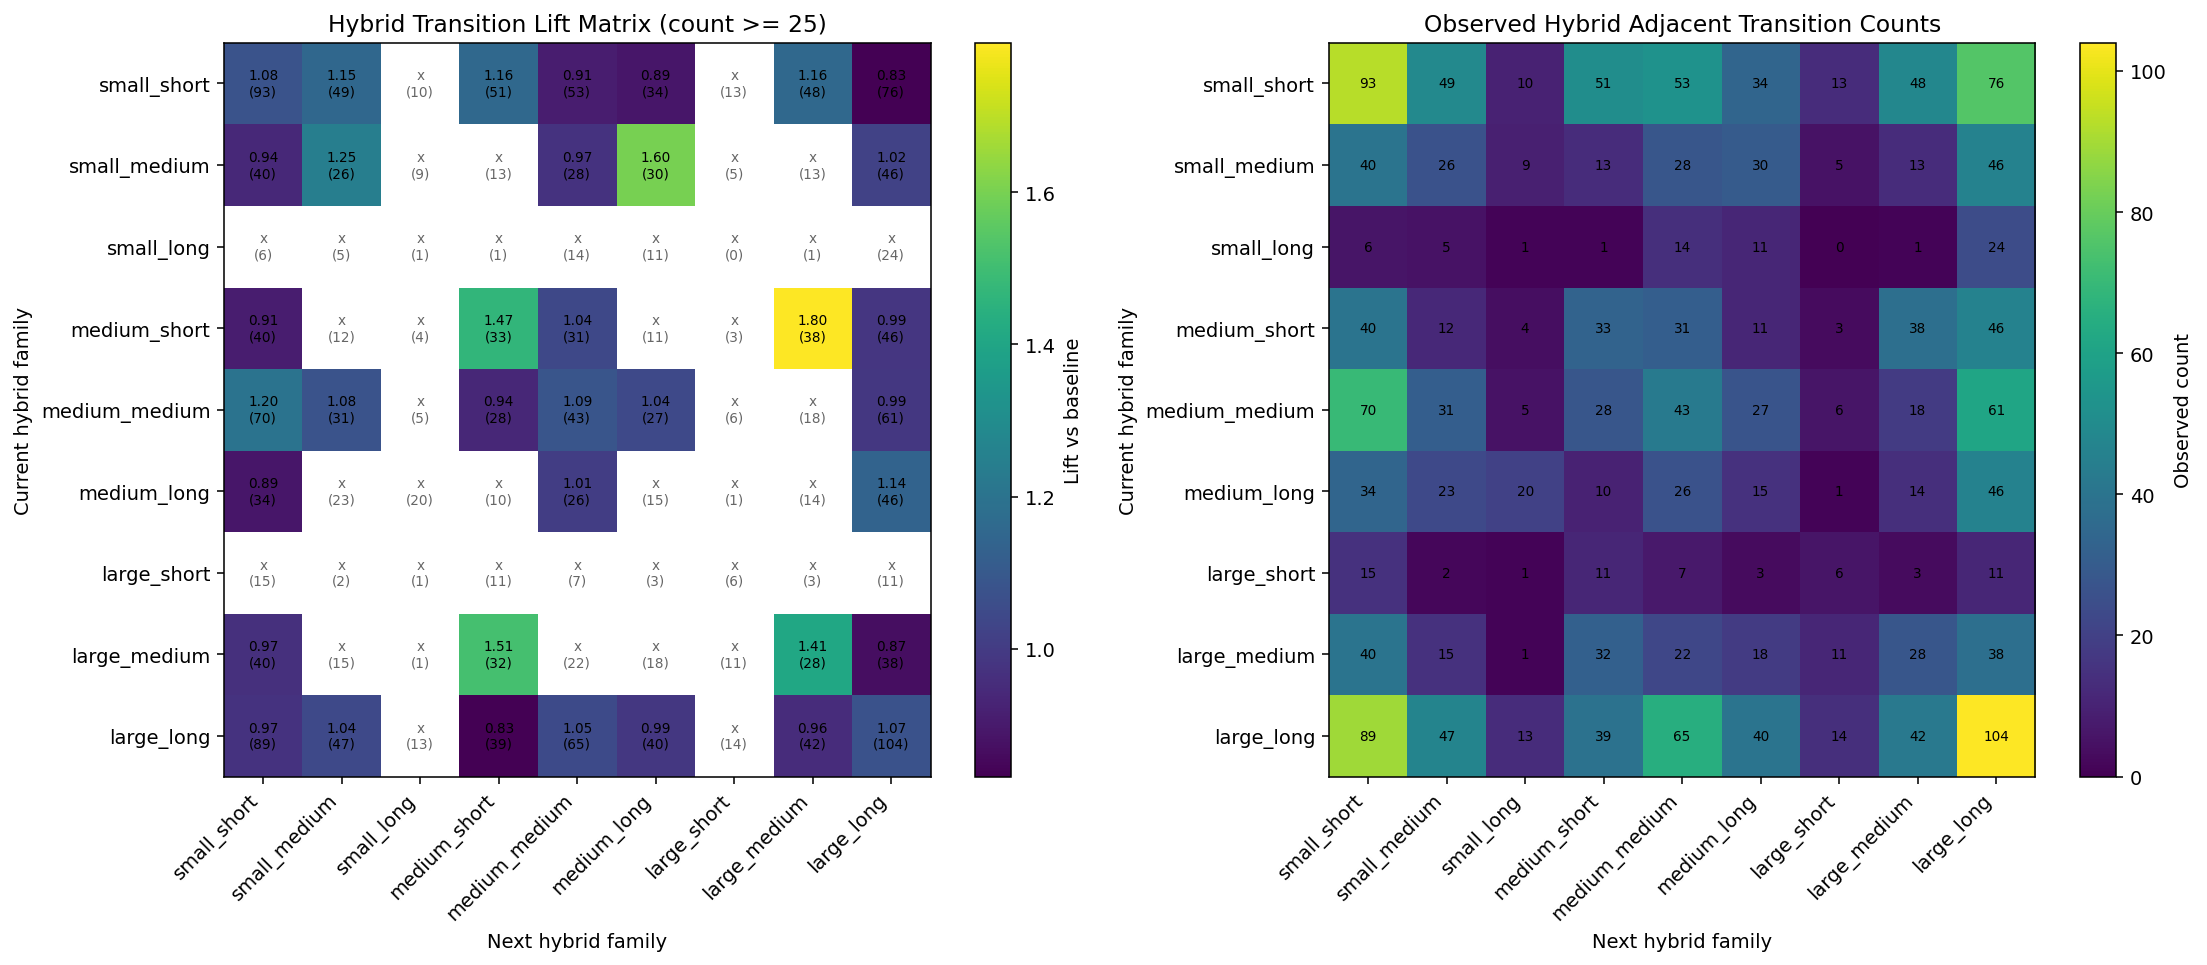

In [30]:
#1-26 Canonicalize Hybrid Vocabulary and Build Supported Hybrid Transition Lift Map

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-21 first.")

HybridObjectsDf = DcObjectsDf.copy()

RequiredColumns = [
    "SegmentId", "StartTimeDt", "MoveFamily", "AbsMove", "DurationSec", "MovePerSec"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in HybridObjectsDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

HybridObjectsDf = HybridObjectsDf.sort_values(["StartTimeDt", "SegmentId"]).reset_index(drop=True).copy()

if "ChronoPhase" not in HybridObjectsDf.columns:
    HybridObjectsDf["ChronoPhase"] = pd.qcut(
        HybridObjectsDf.index,
        q=4,
        labels=["P1", "P2", "P3", "P4"]
    )

HybridObjectsDf["DurationPctInPhase"] = (
    HybridObjectsDf.groupby("ChronoPhase", observed=False)["DurationSec"]
    .rank(method="average", pct=True)
)

HybridObjectsDf["DurationRelFamily"] = pd.cut(
    HybridObjectsDf["DurationPctInPhase"],
    bins=[0.0, 1/3, 2/3, 1.0],
    labels=["short", "medium", "long"],
    include_lowest=True
).astype(str)

HybridObjectsDf["HybridStructuralFamily"] = (
    HybridObjectsDf["MoveFamily"].astype(str) + "_" + HybridObjectsDf["DurationRelFamily"].astype(str)
)

FamilyOrder = [
    "small_short", "small_medium", "small_long",
    "medium_short", "medium_medium", "medium_long",
    "large_short", "large_medium", "large_long"
]

HybridFamilyCountsDf = (
    HybridObjectsDf["HybridStructuralFamily"]
    .value_counts()
    .rename_axis("HybridStructuralFamily")
    .reset_index(name="Count")
)

HybridTransitionDf = HybridObjectsDf.sort_values("SegmentId").reset_index(drop=True).copy()
HybridTransitionDf["NextSegmentId"] = HybridTransitionDf["SegmentId"].shift(-1)
HybridTransitionDf["NextHybridStructuralFamily"] = HybridTransitionDf["HybridStructuralFamily"].shift(-1)
HybridTransitionDf["NextAbsMove"] = HybridTransitionDf["AbsMove"].shift(-1)
HybridTransitionDf["NextDurationSec"] = HybridTransitionDf["DurationSec"].shift(-1)
HybridTransitionDf["NextMovePerSec"] = HybridTransitionDf["MovePerSec"].shift(-1)
HybridTransitionDf["NextMoveVsCurrent"] = (
    HybridTransitionDf["NextAbsMove"] / HybridTransitionDf["AbsMove"].replace(0, np.nan)
)
HybridTransitionDf["NextDurationVsCurrent"] = (
    HybridTransitionDf["NextDurationSec"] / HybridTransitionDf["DurationSec"].replace(0, np.nan)
)
HybridTransitionDf["NextSpeedVsCurrent"] = (
    HybridTransitionDf["NextMovePerSec"] / HybridTransitionDf["MovePerSec"].replace(0, np.nan)
)
HybridTransitionDf = HybridTransitionDf.iloc[:-1].copy()

ObservedCounts = (
    HybridTransitionDf.groupby(["HybridStructuralFamily", "NextHybridStructuralFamily"])
    .size()
    .rename("ObservedCount")
    .reset_index()
)

ObservedPivot = (
    ObservedCounts.pivot(
        index="HybridStructuralFamily",
        columns="NextHybridStructuralFamily",
        values="ObservedCount"
    )
    .reindex(index=FamilyOrder, columns=FamilyOrder)
    .fillna(0)
)

RowTotals = ObservedPivot.sum(axis=1)

BaselineNextProb = (
    HybridTransitionDf["NextHybridStructuralFamily"]
    .value_counts(normalize=True)
    .reindex(FamilyOrder)
    .fillna(0)
)

ExpectedPivot = pd.DataFrame(
    index=FamilyOrder,
    columns=FamilyOrder,
    data=0.0
)

for CurrentFamily in FamilyOrder:
    ExpectedPivot.loc[CurrentFamily, :] = RowTotals.get(CurrentFamily, 0) * BaselineNextProb.values

LiftPivot = ObservedPivot / ExpectedPivot.replace(0, np.nan)
LiftPivot = LiftPivot.replace([np.inf, -np.inf], np.nan)

MinSupport = 25
SupportedMask = ObservedPivot >= MinSupport
LiftSupported = LiftPivot.where(SupportedMask)

LiftLong = (
    LiftSupported.reset_index()
    .melt(id_vars="HybridStructuralFamily", var_name="NextHybridStructuralFamily", value_name="LiftVsBaseline")
)

CountLong = (
    ObservedPivot.reset_index()
    .melt(id_vars="HybridStructuralFamily", var_name="NextHybridStructuralFamily", value_name="ObservedCount")
)

SummaryLong = LiftLong.merge(
    CountLong,
    on=["HybridStructuralFamily", "NextHybridStructuralFamily"],
    how="left"
)

TopSupportedPreferred = (
    SummaryLong.loc[SummaryLong["ObservedCount"] >= MinSupport]
    .sort_values(["LiftVsBaseline", "ObservedCount"], ascending=[False, False])
    .head(15)
    .reset_index(drop=True)
)

TopSupportedAvoided = (
    SummaryLong.loc[SummaryLong["ObservedCount"] >= MinSupport]
    .sort_values(["LiftVsBaseline", "ObservedCount"], ascending=[True, False])
    .head(15)
    .reset_index(drop=True)
)

HybridSummaryDf = pd.DataFrame([{
    "WorkingTheta": WorkingTheta if "WorkingTheta" in globals() else np.nan,
    "HybridObjectCount": int(len(HybridObjectsDf)),
    "HybridTransitionCount": int(len(HybridTransitionDf)),
    "MinSupport": MinSupport,
    "MedianAbsMove": round(HybridObjectsDf["AbsMove"].median(), 4),
    "MedianDurationSec": round(HybridObjectsDf["DurationSec"].median(), 4),
    "MedianMovePerSec": round(HybridObjectsDf["MovePerSec"].median(), 4),
}])

print("Hybrid working vocabulary summary:")
display(HybridSummaryDf)

print("Hybrid family counts:")
display(HybridFamilyCountsDf)

print(f"Top supported preferred hybrid transitions (count >= {MinSupport}):")
display(TopSupportedPreferred)

print(f"Top supported underrepresented hybrid transitions (count >= {MinSupport}):")
display(TopSupportedAvoided)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=140)

HeatLift = LiftSupported.reindex(index=FamilyOrder, columns=FamilyOrder).astype(float)
Im0 = axes[0].imshow(HeatLift, aspect="auto", interpolation="nearest")

axes[0].set_title(f"Hybrid Transition Lift Matrix (count >= {MinSupport})")
axes[0].set_xlabel("Next hybrid family")
axes[0].set_ylabel("Current hybrid family")
axes[0].set_xticks(range(len(FamilyOrder)))
axes[0].set_xticklabels(FamilyOrder, rotation=45, ha="right")
axes[0].set_yticks(range(len(FamilyOrder)))
axes[0].set_yticklabels(FamilyOrder)

for i in range(len(FamilyOrder)):
    for j in range(len(FamilyOrder)):
        CountValue = int(ObservedPivot.iloc[i, j])
        LiftValue = HeatLift.iloc[i, j]
        if pd.notna(LiftValue):
            axes[0].text(j, i, f"{LiftValue:.2f}\n({CountValue})", ha="center", va="center", fontsize=7)
        else:
            axes[0].text(j, i, f"x\n({CountValue})", ha="center", va="center", fontsize=7, alpha=0.6)

Cbar0 = plt.colorbar(Im0, ax=axes[0])
Cbar0.set_label("Lift vs baseline")

HeatCount = ObservedPivot.reindex(index=FamilyOrder, columns=FamilyOrder).astype(float)
Im1 = axes[1].imshow(HeatCount, aspect="auto", interpolation="nearest")

axes[1].set_title("Observed Hybrid Adjacent Transition Counts")
axes[1].set_xlabel("Next hybrid family")
axes[1].set_ylabel("Current hybrid family")
axes[1].set_xticks(range(len(FamilyOrder)))
axes[1].set_xticklabels(FamilyOrder, rotation=45, ha="right")
axes[1].set_yticks(range(len(FamilyOrder)))
axes[1].set_yticklabels(FamilyOrder)

for i in range(len(FamilyOrder)):
    for j in range(len(FamilyOrder)):
        axes[1].text(j, i, f"{int(HeatCount.iloc[i, j])}", ha="center", va="center", fontsize=7)

Cbar1 = plt.colorbar(Im1, ax=axes[1])
Cbar1.set_label("Observed count")

plt.tight_layout()
plt.show()

In [31]:
#1-27 Test Top Hybrid Transition Motifs Across Chronological Phases

import pandas as pd
import numpy as np

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-21 first.")

ObjDf = DcObjectsDf.copy()

RequiredColumns = [
    "SegmentId", "StartTimeDt", "MoveFamily",
    "AbsMove", "DurationSec", "MovePerSec"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in ObjDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

ObjDf = ObjDf.sort_values(["StartTimeDt", "SegmentId"]).reset_index(drop=True).copy()

if "ChronoPhase" not in ObjDf.columns:
    ObjDf["ChronoPhase"] = pd.qcut(
        ObjDf.index,
        q=4,
        labels=["P1", "P2", "P3", "P4"]
    )

# Rebuild hybrid vocabulary deterministically
ObjDf["DurationPctInPhase"] = (
    ObjDf.groupby("ChronoPhase", observed=False)["DurationSec"]
         .rank(method="average", pct=True)
)

ObjDf["DurationRelFamily"] = pd.cut(
    ObjDf["DurationPctInPhase"],
    bins=[0.0, 1/3, 2/3, 1.0],
    labels=["short", "medium", "long"],
    include_lowest=True
).astype(str)

ObjDf["HybridStructuralFamily"] = (
    ObjDf["MoveFamily"].astype(str) + "_" + ObjDf["DurationRelFamily"].astype(str)
)

# Build adjacent hybrid transitions
HybridTransitionDf = ObjDf.sort_values("SegmentId").reset_index(drop=True).copy()
HybridTransitionDf["NextHybridStructuralFamily"] = HybridTransitionDf["HybridStructuralFamily"].shift(-1)
HybridTransitionDf["NextAbsMove"] = HybridTransitionDf["AbsMove"].shift(-1)
HybridTransitionDf["NextDurationSec"] = HybridTransitionDf["DurationSec"].shift(-1)
HybridTransitionDf["NextMovePerSec"] = HybridTransitionDf["MovePerSec"].shift(-1)
HybridTransitionDf = HybridTransitionDf.iloc[:-1].copy()

HybridTransitionDf["NextMoveVsCurrent"] = (
    HybridTransitionDf["NextAbsMove"] / HybridTransitionDf["AbsMove"].replace(0, np.nan)
)
HybridTransitionDf["NextDurationVsCurrent"] = (
    HybridTransitionDf["NextDurationSec"] / HybridTransitionDf["DurationSec"].replace(0, np.nan)
)
HybridTransitionDf["NextSpeedVsCurrent"] = (
    HybridTransitionDf["NextMovePerSec"] / HybridTransitionDf["MovePerSec"].replace(0, np.nan)
)

# Full-sample supported preferred transitions
ObservedCounts = (
    HybridTransitionDf.groupby(["HybridStructuralFamily", "NextHybridStructuralFamily"])
    .size()
    .rename("ObservedCount")
    .reset_index()
)

ObservedPivot = (
    ObservedCounts.pivot(
        index="HybridStructuralFamily",
        columns="NextHybridStructuralFamily",
        values="ObservedCount"
    ).fillna(0)
)

RowTotals = ObservedPivot.sum(axis=1)
BaselineNextProb = (
    HybridTransitionDf["NextHybridStructuralFamily"]
    .value_counts(normalize=True)
)

ExpectedPivot = pd.DataFrame(index=ObservedPivot.index, columns=ObservedPivot.columns, data=0.0)
for CurrentFamily in ObservedPivot.index:
    ExpectedPivot.loc[CurrentFamily, :] = RowTotals.get(CurrentFamily, 0) * BaselineNextProb.reindex(ObservedPivot.columns).fillna(0).values

LiftPivot = ObservedPivot / ExpectedPivot.replace(0, np.nan)
LiftLong = (
    LiftPivot.reset_index()
    .melt(id_vars="HybridStructuralFamily", var_name="NextHybridStructuralFamily", value_name="LiftVsBaseline")
    .merge(
        ObservedPivot.reset_index().melt(
            id_vars="HybridStructuralFamily",
            var_name="NextHybridStructuralFamily",
            value_name="ObservedCount"
        ),
        on=["HybridStructuralFamily", "NextHybridStructuralFamily"],
        how="left"
    )
)

TopMotifsDf = (
    LiftLong.loc[
        (LiftLong["ObservedCount"] >= 25) &
        (LiftLong["LiftVsBaseline"] > 1.05)
    ]
    .sort_values(["LiftVsBaseline", "ObservedCount"], ascending=[False, False])
    .head(8)
    .reset_index(drop=True)
)

if TopMotifsDf.empty:
    raise RuntimeError("No supported preferred hybrid motifs found under current filters.")

SelectedMotifs = TopMotifsDf[["HybridStructuralFamily", "NextHybridStructuralFamily"]].copy()

# Phase-specific lift for selected motifs
PhaseRows = []

for _, Motif in SelectedMotifs.iterrows():
    CurrentFamily = Motif["HybridStructuralFamily"]
    NextFamily = Motif["NextHybridStructuralFamily"]

    for Phase in ["P1", "P2", "P3", "P4"]:
        PhaseDf = HybridTransitionDf.loc[HybridTransitionDf["ChronoPhase"] == Phase].copy()
        if len(PhaseDf) == 0:
            continue

        CurrentPhaseCount = int((PhaseDf["HybridStructuralFamily"] == CurrentFamily).sum())
        Observed = int(((PhaseDf["HybridStructuralFamily"] == CurrentFamily) & (PhaseDf["NextHybridStructuralFamily"] == NextFamily)).sum())
        BaselineProb = float((PhaseDf["NextHybridStructuralFamily"] == NextFamily).mean())

        Expected = CurrentPhaseCount * BaselineProb if CurrentPhaseCount > 0 else np.nan
        Lift = (Observed / Expected) if (Expected is not None and Expected > 0) else np.nan

        SliceDf = PhaseDf.loc[
            (PhaseDf["HybridStructuralFamily"] == CurrentFamily) &
            (PhaseDf["NextHybridStructuralFamily"] == NextFamily)
        ]

        PhaseRows.append({
            "Motif": f"{CurrentFamily} -> {NextFamily}",
            "ChronoPhase": Phase,
            "CurrentPhaseCount": CurrentPhaseCount,
            "ObservedCount": Observed,
            "ExpectedCount": round(Expected, 4) if pd.notna(Expected) else np.nan,
            "LiftVsPhaseBaseline": round(Lift, 4) if pd.notna(Lift) else np.nan,
            "MedianNextMoveVsCurrent": round(float(SliceDf["NextMoveVsCurrent"].median()), 4) if len(SliceDf) else np.nan,
            "MedianNextDurationVsCurrent": round(float(SliceDf["NextDurationVsCurrent"].median()), 4) if len(SliceDf) else np.nan,
            "MedianNextSpeedVsCurrent": round(float(SliceDf["NextSpeedVsCurrent"].median()), 4) if len(SliceDf) else np.nan,
        })

MotifPhaseDf = pd.DataFrame(PhaseRows)

LiftPivotByPhase = (
    MotifPhaseDf.pivot(index="Motif", columns="ChronoPhase", values="LiftVsPhaseBaseline")
    .round(4)
)

ObservedPivotByPhase = (
    MotifPhaseDf.pivot(index="Motif", columns="ChronoPhase", values="ObservedCount")
    .fillna(0)
    .astype(int)
)

StabilitySummaryRows = []
for Motif, SliceDf in MotifPhaseDf.groupby("Motif"):
    SupportedSlice = SliceDf.loc[SliceDf["ObservedCount"] >= 5].copy()

    StabilitySummaryRows.append({
        "Motif": Motif,
        "SupportedPhasesObsGe5": int(len(SupportedSlice)),
        "TotalObservedCount": int(SliceDf["ObservedCount"].sum()),
        "LiftRange_ObsGe5": round(float(SupportedSlice["LiftVsPhaseBaseline"].max() - SupportedSlice["LiftVsPhaseBaseline"].min()), 4) if len(SupportedSlice) >= 2 else np.nan,
        "MoveRatioRange_ObsGe5": round(float(SupportedSlice["MedianNextMoveVsCurrent"].max() - SupportedSlice["MedianNextMoveVsCurrent"].min()), 4) if len(SupportedSlice) >= 2 else np.nan,
        "DurationRatioRange_ObsGe5": round(float(SupportedSlice["MedianNextDurationVsCurrent"].max() - SupportedSlice["MedianNextDurationVsCurrent"].min()), 4) if len(SupportedSlice) >= 2 else np.nan,
        "SpeedRatioRange_ObsGe5": round(float(SupportedSlice["MedianNextSpeedVsCurrent"].max() - SupportedSlice["MedianNextSpeedVsCurrent"].min()), 4) if len(SupportedSlice) >= 2 else np.nan,
    })

MotifStabilityDf = (
    pd.DataFrame(StabilitySummaryRows)
    .sort_values(["LiftRange_ObsGe5", "TotalObservedCount"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Top supported preferred hybrid motifs selected from full sample:")
display(TopMotifsDf)

print("Observed motif counts by phase:")
display(ObservedPivotByPhase)

print("Phase-specific motif lift vs within-phase baseline:")
display(LiftPivotByPhase)

print("Motif phase-stability summary:")
display(MotifStabilityDf)

print("Detailed motif-by-phase behavior:")
display(MotifPhaseDf.sort_values(["Motif", "ChronoPhase"]).reset_index(drop=True))

Top supported preferred hybrid motifs selected from full sample:


,HybridStructuralFamily,NextHybridStructuralFamily,LiftVsBaseline,ObservedCount
0,medium_short,large_medium,1.796688,38.0
1,small_medium,medium_long,1.597128,30.0
2,large_medium,medium_short,1.513001,32.0
3,medium_short,medium_short,1.467238,33.0
4,large_medium,large_medium,1.407829,28.0
5,small_medium,small_medium,1.245760,26.0
6,medium_medium,small_short,1.198593,70.0
7,small_short,large_medium,1.158668,48.0


Observed motif counts by phase:


ChronoPhase,P1,P2,P3,P4
Motif,,,,
large_medium -> large_medium,12,1,12,3
large_medium -> medium_short,7,6,9,10
medium_medium -> small_short,14,24,14,18
medium_short -> large_medium,10,10,10,8
medium_short -> medium_short,14,3,11,5
small_medium -> medium_long,8,11,2,9
small_medium -> small_medium,6,6,6,8
small_short -> large_medium,9,9,21,9


Phase-specific motif lift vs within-phase baseline:


ChronoPhase,P1,P2,P3,P4
Motif,,,,
large_medium -> large_medium,2.1374,0.3066,1.3702,0.9423
large_medium -> medium_short,1.0550,1.5714,1.3439,2.4298
medium_medium -> small_short,1.2778,1.3840,0.9764,1.1214
medium_short -> large_medium,1.4797,2.6829,1.4932,1.9439
medium_short -> medium_short,1.7529,0.6875,2.1479,0.9398
small_medium -> medium_long,1.4639,2.4200,0.9199,1.2375
small_medium -> small_medium,0.9118,1.2672,1.8846,1.1733
small_short -> large_medium,0.9409,1.0732,1.4303,1.0257


Motif phase-stability summary:


,Motif,SupportedPhasesObsGe5,TotalObservedCount,LiftRange_ObsGe5,MoveRatioRange_ObsGe5,DurationRatioRange_ObsGe5,SpeedRatioRange_ObsGe5
0,medium_medium -> small_short,4,70,0.4076,0.0391,0.0649,0.2671
1,small_short -> large_medium,4,48,0.4894,0.8796,0.7510,0.3333
2,large_medium -> large_medium,2,28,0.7672,0.0382,0.1692,0.1718
3,small_medium -> small_medium,4,26,0.9728,0.2392,0.4513,0.2471
4,small_medium -> medium_long,3,30,1.1825,0.5168,0.9879,0.3205
5,medium_short -> large_medium,4,38,1.2032,0.5055,0.9838,0.3814
6,medium_short -> medium_short,3,33,1.2081,0.0909,0.2076,0.2850
7,large_medium -> medium_short,4,32,1.3748,0.0894,0.1596,0.3892


Detailed motif-by-phase behavior:


,Motif,ChronoPhase,CurrentPhaseCount,ObservedCount,ExpectedCount,LiftVsPhaseBaseline,MedianNextMoveVsCurrent,MedianNextDurationVsCurrent,MedianNextSpeedVsCurrent
0,large_medium -> large_medium,P1,54,12,5.6144,2.1374,1.0470,0.8937,1.2027
1,large_medium -> large_medium,P2,42,1,3.2614,0.3066,1.0330,0.5991,1.7241
2,large_medium -> large_medium,P3,68,12,8.7576,1.3702,1.0088,1.0629,1.0309
3,large_medium -> large_medium,P4,41,3,3.1837,0.9423,0.8770,0.9326,0.9404
4,large_medium -> medium_short,P1,54,7,6.6352,1.0550,0.4713,0.3919,1.2058
5,large_medium -> medium_short,P2,42,6,3.8182,1.5714,0.5410,0.5515,0.9350
6,large_medium -> medium_short,P3,68,9,6.6970,1.3439,0.5607,0.3975,1.3242
7,large_medium -> medium_short,P4,41,10,4.1155,2.4298,0.5545,0.4622,1.1381
8,medium_medium -> small_short,P1,63,14,10.9565,1.2778,0.4897,0.4184,1.1219
9,medium_medium -> small_short,P2,84,24,17.3409,1.3840,0.5288,0.4134,1.3890


In [32]:
#1-28 Build Hybrid Motif Registry and Stable-vs-Regime Shortlists

import pandas as pd
import numpy as np

if "DcObjectsDf" not in globals():
    raise RuntimeError("DcObjectsDf is not defined. Please run cell #1-21 first.")

ObjDf = DcObjectsDf.copy()

RequiredColumns = [
    "SegmentId", "StartTimeDt", "MoveFamily",
    "AbsMove", "DurationSec", "MovePerSec"
]
MissingColumns = [Col for Col in RequiredColumns if Col not in ObjDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in DcObjectsDf: {MissingColumns}")

ObjDf = ObjDf.sort_values(["StartTimeDt", "SegmentId"]).reset_index(drop=True).copy()

if "ChronoPhase" not in ObjDf.columns:
    ObjDf["ChronoPhase"] = pd.qcut(
        ObjDf.index,
        q=4,
        labels=["P1", "P2", "P3", "P4"]
    )

# Rebuild hybrid vocabulary deterministically
ObjDf["DurationPctInPhase"] = (
    ObjDf.groupby("ChronoPhase", observed=False)["DurationSec"]
         .rank(method="average", pct=True)
)

ObjDf["DurationRelFamily"] = pd.cut(
    ObjDf["DurationPctInPhase"],
    bins=[0.0, 1/3, 2/3, 1.0],
    labels=["short", "medium", "long"],
    include_lowest=True
).astype(str)

ObjDf["HybridStructuralFamily"] = (
    ObjDf["MoveFamily"].astype(str) + "_" + ObjDf["DurationRelFamily"].astype(str)
)

# Adjacent transitions
HybridTransitionDf = ObjDf.sort_values("SegmentId").reset_index(drop=True).copy()
HybridTransitionDf["NextHybridStructuralFamily"] = HybridTransitionDf["HybridStructuralFamily"].shift(-1)
HybridTransitionDf["NextAbsMove"] = HybridTransitionDf["AbsMove"].shift(-1)
HybridTransitionDf["NextDurationSec"] = HybridTransitionDf["DurationSec"].shift(-1)
HybridTransitionDf["NextMovePerSec"] = HybridTransitionDf["MovePerSec"].shift(-1)
HybridTransitionDf = HybridTransitionDf.iloc[:-1].copy()

HybridTransitionDf["Motif"] = (
    HybridTransitionDf["HybridStructuralFamily"] + " -> " + HybridTransitionDf["NextHybridStructuralFamily"]
)

HybridTransitionDf["NextMoveVsCurrent"] = (
    HybridTransitionDf["NextAbsMove"] / HybridTransitionDf["AbsMove"].replace(0, np.nan)
)
HybridTransitionDf["NextDurationVsCurrent"] = (
    HybridTransitionDf["NextDurationSec"] / HybridTransitionDf["DurationSec"].replace(0, np.nan)
)
HybridTransitionDf["NextSpeedVsCurrent"] = (
    HybridTransitionDf["NextMovePerSec"] / HybridTransitionDf["MovePerSec"].replace(0, np.nan)
)

MinTotalObs = 20
MinPhaseObs = 5

# Full-sample lift
ObservedCounts = (
    HybridTransitionDf.groupby(["HybridStructuralFamily", "NextHybridStructuralFamily"])
    .size()
    .rename("ObservedCount")
    .reset_index()
)

ObservedPivot = (
    ObservedCounts.pivot(
        index="HybridStructuralFamily",
        columns="NextHybridStructuralFamily",
        values="ObservedCount"
    )
    .fillna(0)
)

RowTotals = ObservedPivot.sum(axis=1)
BaselineNextProb = HybridTransitionDf["NextHybridStructuralFamily"].value_counts(normalize=True)

ExpectedPivot = pd.DataFrame(index=ObservedPivot.index, columns=ObservedPivot.columns, data=0.0)
for CurrentFamily in ObservedPivot.index:
    ExpectedPivot.loc[CurrentFamily, :] = (
        RowTotals.get(CurrentFamily, 0) *
        BaselineNextProb.reindex(ObservedPivot.columns).fillna(0).values
    )

LiftPivot = ObservedPivot / ExpectedPivot.replace(0, np.nan)

FullSampleLong = (
    LiftPivot.reset_index()
    .melt(id_vars="HybridStructuralFamily", var_name="NextHybridStructuralFamily", value_name="FullSampleLift")
    .merge(
        ObservedPivot.reset_index().melt(
            id_vars="HybridStructuralFamily",
            var_name="NextHybridStructuralFamily",
            value_name="TotalObservedCount"
        ),
        on=["HybridStructuralFamily", "NextHybridStructuralFamily"],
        how="left"
    )
)

FullSampleLong["Motif"] = (
    FullSampleLong["HybridStructuralFamily"] + " -> " + FullSampleLong["NextHybridStructuralFamily"]
)

# Phase-specific rows
PhaseRows = []

for Phase in ["P1", "P2", "P3", "P4"]:
    PhaseDf = HybridTransitionDf.loc[HybridTransitionDf["ChronoPhase"] == Phase].copy()
    if len(PhaseDf) == 0:
        continue

    PhaseNextProb = PhaseDf["NextHybridStructuralFamily"].value_counts(normalize=True)

    CurrentCounts = (
        PhaseDf["HybridStructuralFamily"]
        .value_counts()
        .rename("CurrentPhaseCount")
        .to_dict()
    )

    Obs = (
        PhaseDf.groupby(["HybridStructuralFamily", "NextHybridStructuralFamily"])
        .size()
        .rename("ObservedCount")
        .reset_index()
    )

    for _, Row in Obs.iterrows():
        CurrentFamily = Row["HybridStructuralFamily"]
        NextFamily = Row["NextHybridStructuralFamily"]
        Observed = int(Row["ObservedCount"])
        CurrentPhaseCount = int(CurrentCounts.get(CurrentFamily, 0))
        BaselineProb = float(PhaseNextProb.get(NextFamily, 0.0))
        Expected = CurrentPhaseCount * BaselineProb if CurrentPhaseCount > 0 else np.nan
        Lift = (Observed / Expected) if pd.notna(Expected) and Expected > 0 else np.nan

        SliceDf = PhaseDf.loc[
            (PhaseDf["HybridStructuralFamily"] == CurrentFamily) &
            (PhaseDf["NextHybridStructuralFamily"] == NextFamily)
        ]

        PhaseRows.append({
            "Motif": f"{CurrentFamily} -> {NextFamily}",
            "ChronoPhase": Phase,
            "ObservedCount": Observed,
            "LiftVsPhaseBaseline": Lift,
            "MedianNextMoveVsCurrent": SliceDf["NextMoveVsCurrent"].median(),
            "MedianNextDurationVsCurrent": SliceDf["NextDurationVsCurrent"].median(),
            "MedianNextSpeedVsCurrent": SliceDf["NextSpeedVsCurrent"].median(),
        })

MotifPhaseDf = pd.DataFrame(PhaseRows)

RegistryRows = []

for Motif, SliceDf in MotifPhaseDf.groupby("Motif"):
    TotalObservedCount = int(SliceDf["ObservedCount"].sum())
    SupportedSlice = SliceDf.loc[SliceDf["ObservedCount"] >= MinPhaseObs].copy()

    FullLift = FullSampleLong.loc[FullSampleLong["Motif"] == Motif, "FullSampleLift"]
    FullLiftValue = float(FullLift.iloc[0]) if len(FullLift) else np.nan

    RegistryRows.append({
        "Motif": Motif,
        "TotalObservedCount": TotalObservedCount,
        "FullSampleLift": round(FullLiftValue, 4) if pd.notna(FullLiftValue) else np.nan,
        "SupportedPhasesObsGe5": int(len(SupportedSlice)),
        "LiftRange_ObsGe5": round(float(SupportedSlice["LiftVsPhaseBaseline"].max() - SupportedSlice["LiftVsPhaseBaseline"].min()), 4) if len(SupportedSlice) >= 2 else np.nan,
        "MoveRatioRange_ObsGe5": round(float(SupportedSlice["MedianNextMoveVsCurrent"].max() - SupportedSlice["MedianNextMoveVsCurrent"].min()), 4) if len(SupportedSlice) >= 2 else np.nan,
        "DurationRatioRange_ObsGe5": round(float(SupportedSlice["MedianNextDurationVsCurrent"].max() - SupportedSlice["MedianNextDurationVsCurrent"].min()), 4) if len(SupportedSlice) >= 2 else np.nan,
        "SpeedRatioRange_ObsGe5": round(float(SupportedSlice["MedianNextSpeedVsCurrent"].max() - SupportedSlice["MedianNextSpeedVsCurrent"].min()), 4) if len(SupportedSlice) >= 2 else np.nan,
        "MedianMoveRatio_ObsGe5": round(float(SupportedSlice["MedianNextMoveVsCurrent"].median()), 4) if len(SupportedSlice) else np.nan,
        "MedianDurationRatio_ObsGe5": round(float(SupportedSlice["MedianNextDurationVsCurrent"].median()), 4) if len(SupportedSlice) else np.nan,
        "MedianSpeedRatio_ObsGe5": round(float(SupportedSlice["MedianNextSpeedVsCurrent"].median()), 4) if len(SupportedSlice) else np.nan,
    })

MotifRegistryDf = pd.DataFrame(RegistryRows)

MotifRegistryDf = MotifRegistryDf.loc[
    MotifRegistryDf["TotalObservedCount"] >= MinTotalObs
].copy()

StableMotifsDf = (
    MotifRegistryDf.loc[
        (MotifRegistryDf["SupportedPhasesObsGe5"] >= 4) &
        (MotifRegistryDf["FullSampleLift"] > 1.05)
    ]
    .sort_values(
        ["LiftRange_ObsGe5", "MoveRatioRange_ObsGe5", "TotalObservedCount"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

RegimeSkewedMotifsDf = (
    MotifRegistryDf.loc[
        (MotifRegistryDf["SupportedPhasesObsGe5"] >= 3) &
        (MotifRegistryDf["FullSampleLift"] > 1.05)
    ]
    .sort_values(
        ["LiftRange_ObsGe5", "TotalObservedCount"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print(f"Motif registry filters: MinTotalObs={MinTotalObs}, MinPhaseObs={MinPhaseObs}")
print()

print("Stable hybrid motifs shortlist:")
display(StableMotifsDf.head(15))

print("Regime-skewed hybrid motifs shortlist:")
display(RegimeSkewedMotifsDf.head(15))

print("Full hybrid motif registry:")
display(MotifRegistryDf.sort_values(["FullSampleLift", "TotalObservedCount"], ascending=[False, False]).reset_index(drop=True))

Motif registry filters: MinTotalObs=20, MinPhaseObs=5

Stable hybrid motifs shortlist:


,Motif,TotalObservedCount,FullSampleLift,SupportedPhasesObsGe5,LiftRange_ObsGe5,MoveRatioRange_ObsGe5,DurationRatioRange_ObsGe5,SpeedRatioRange_ObsGe5,MedianMoveRatio_ObsGe5,MedianDurationRatio_ObsGe5,MedianSpeedRatio_ObsGe5
0,large_long -> large_long,104,1.0732,4,0.3443,0.4867,0.0110,0.2037,1.0742,1.1260,0.9622
1,small_short -> small_medium,49,1.1546,4,0.3477,0.1790,0.3606,0.1882,1.0887,2.1717,0.4163
2,medium_medium -> small_short,70,1.1986,4,0.4077,0.0391,0.0649,0.2671,0.4928,0.4159,1.2708
3,small_short -> small_short,93,1.0778,4,0.4633,0.1823,0.4259,0.5544,1.0236,0.9556,1.0313
4,small_short -> large_medium,48,1.1587,4,0.4894,0.8795,0.7510,0.3333,3.8208,3.0040,1.1043
5,medium_medium -> medium_medium,43,1.0879,4,0.6296,0.2328,0.3266,0.2860,1.0232,0.9486,1.1615
6,medium_medium -> small_medium,31,1.0793,4,0.6537,0.1710,0.2893,0.2979,0.5222,0.8571,0.5745
7,small_short -> medium_short,51,1.1577,4,0.8753,0.1183,0.5315,1.0055,2.0617,1.3907,1.6272
8,small_medium -> small_medium,26,1.2458,4,0.9728,0.2393,0.4513,0.2471,0.9406,1.0668,0.8483
9,medium_short -> large_medium,38,1.7967,4,1.2032,0.5055,0.9837,0.3814,1.9760,2.3655,0.9310


Regime-skewed hybrid motifs shortlist:


,Motif,TotalObservedCount,FullSampleLift,SupportedPhasesObsGe5,LiftRange_ObsGe5,MoveRatioRange_ObsGe5,DurationRatioRange_ObsGe5,SpeedRatioRange_ObsGe5,MedianMoveRatio_ObsGe5,MedianDurationRatio_ObsGe5,MedianSpeedRatio_ObsGe5
0,medium_long -> small_long,20,3.4937,3,1.4869,0.3893,0.1972,0.1560,0.5690,0.8594,0.5524
1,large_medium -> medium_short,32,1.5130,4,1.3748,0.0894,0.1596,0.3892,0.5477,0.4298,1.1720
2,medium_short -> medium_short,33,1.4672,3,1.2081,0.0909,0.2076,0.2850,0.9974,1.0299,0.8788
3,medium_short -> large_medium,38,1.7967,4,1.2032,0.5055,0.9837,0.3814,1.9760,2.3655,0.9310
4,small_medium -> medium_long,30,1.5971,3,1.1825,0.5167,0.9879,0.3205,1.9750,2.3701,0.9045
5,small_medium -> small_medium,26,1.2458,4,0.9728,0.2393,0.4513,0.2471,0.9406,1.0668,0.8483
6,small_short -> medium_short,51,1.1577,4,0.8753,0.1183,0.5315,1.0055,2.0617,1.3907,1.6272
7,medium_long -> small_medium,23,1.2245,3,0.7975,0.1358,0.0941,0.5264,0.5056,0.4312,1.5247
8,medium_medium -> small_medium,31,1.0793,4,0.6537,0.1710,0.2893,0.2979,0.5222,0.8571,0.5745
9,medium_medium -> medium_medium,43,1.0879,4,0.6296,0.2328,0.3266,0.2860,1.0232,0.9486,1.1615


Full hybrid motif registry:


,Motif,TotalObservedCount,FullSampleLift,SupportedPhasesObsGe5,LiftRange_ObsGe5,MoveRatioRange_ObsGe5,DurationRatioRange_ObsGe5,SpeedRatioRange_ObsGe5,MedianMoveRatio_ObsGe5,MedianDurationRatio_ObsGe5,MedianSpeedRatio_ObsGe5
0,medium_long -> small_long,20,3.4937,3,1.4869,0.3893,0.1972,0.1560,0.5690,0.8594,0.5524
1,medium_short -> large_medium,38,1.7967,4,1.2032,0.5055,0.9837,0.3814,1.9760,2.3655,0.9310
2,small_long -> large_long,24,1.7809,3,0.2632,0.8793,0.2714,0.8300,3.5881,1.5485,1.9869
3,small_medium -> medium_long,30,1.5971,3,1.1825,0.5167,0.9879,0.3205,1.9750,2.3701,0.9045
4,large_medium -> medium_short,32,1.5130,4,1.3748,0.0894,0.1596,0.3892,0.5477,0.4298,1.1720
5,medium_short -> medium_short,33,1.4672,3,1.2081,0.0909,0.2076,0.2850,0.9974,1.0299,0.8788
6,large_medium -> large_medium,28,1.4078,2,0.7671,0.0382,0.1692,0.1718,1.0279,0.9783,1.1168
7,small_medium -> small_medium,26,1.2458,4,0.9728,0.2393,0.4513,0.2471,0.9406,1.0668,0.8483
8,medium_long -> small_medium,23,1.2245,3,0.7975,0.1358,0.0941,0.5264,0.5056,0.4312,1.5247
9,medium_medium -> small_short,70,1.1986,4,0.4077,0.0391,0.0649,0.2671,0.4928,0.4159,1.2708


Phase two

In [33]:
#2-1 Reconstruct canonical Phase One state for Phase Two

from pathlib import Path
import numpy as np
import pandas as pd

CsvPath = Path("../logs/260307.csv")
PriceColumn = "kal"
WorkingTheta = 0.75
PhaseLabels = ["P1", "P2", "P3", "P4"]

if not CsvPath.exists():
    raise FileNotFoundError(f"Validated source file not found: {CsvPath.resolve()}")

RequiredColumns = ["id", "symbol", "timestamp", "bid", "ask", "kal", "mid", "spread", "k2"]

def ParseMixedTimestamp(ts_series: pd.Series) -> pd.Series:
    s = ts_series.astype(str).str.strip()
    s = s.str.replace(r"([+-]\d{2})$", r"\g<1>00", regex=True)  # +11 -> +1100
    ts = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S.%f%z", errors="coerce")
    MissingMask = ts.isna()
    if MissingMask.any():
        ts.loc[MissingMask] = pd.to_datetime(
            s.loc[MissingMask],
            format="%Y-%m-%d %H:%M:%S%z",
            errors="coerce",
        )
    return ts

def TercileFamilyFromPct(PctSeries: pd.Series, Labels: list[str]) -> pd.Categorical:
    return pd.cut(
        PctSeries,
        bins=[0.0, 1/3, 2/3, 1.0],
        labels=Labels,
        include_lowest=True,
        ordered=True,
    )

def BuildDcSegments(TickDf: pd.DataFrame, PriceCol: str, Theta: float) -> pd.DataFrame:
    Prices = TickDf[PriceCol].to_numpy(dtype=float)
    Timestamps = TickDf["timestamp_dt"].to_numpy()
    RowIds = TickDf.index.to_numpy()

    Segments = []

    RunMinPrice = Prices[0]
    RunMinIdx = 0
    RunMaxPrice = Prices[0]
    RunMaxIdx = 0

    Mode = None            # None / "up" / "down"
    StartIdx = None
    ExtremeIdx = None
    ExtremePrice = None

    for i in range(1, len(Prices)):
        p = Prices[i]

        if Mode is None:
            if p < RunMinPrice:
                RunMinPrice = p
                RunMinIdx = i
            if p > RunMaxPrice:
                RunMaxPrice = p
                RunMaxIdx = i

            if p >= RunMinPrice + Theta:
                Mode = "up"
                StartIdx = RunMinIdx
                ExtremeIdx = i
                ExtremePrice = p
            elif p <= RunMaxPrice - Theta:
                Mode = "down"
                StartIdx = RunMaxIdx
                ExtremeIdx = i
                ExtremePrice = p
            continue

        if Mode == "up":
            if p >= ExtremePrice:
                ExtremePrice = p
                ExtremeIdx = i
            elif p <= ExtremePrice - Theta:
                Segments.append(
                    {
                        "Direction": "up",
                        "StartPos": int(StartIdx),
                        "EndPos": int(ExtremeIdx),
                        "ConfirmPos": int(i),
                    }
                )
                Mode = "down"
                StartIdx = ExtremeIdx
                ExtremeIdx = i
                ExtremePrice = p

        elif Mode == "down":
            if p <= ExtremePrice:
                ExtremePrice = p
                ExtremeIdx = i
            elif p >= ExtremePrice + Theta:
                Segments.append(
                    {
                        "Direction": "down",
                        "StartPos": int(StartIdx),
                        "EndPos": int(ExtremeIdx),
                        "ConfirmPos": int(i),
                    }
                )
                Mode = "up"
                StartIdx = ExtremeIdx
                ExtremeIdx = i
                ExtremePrice = p

    if not Segments:
        raise ValueError(f"No confirmed DC segments were built for theta={Theta} on {PriceCol}.")

    SegDf = pd.DataFrame(Segments)
    SegDf.insert(0, "SegmentId", np.arange(1, len(SegDf) + 1))

    SegDf["StartTickId"] = TickDf.iloc[SegDf["StartPos"].to_numpy()]["id"].to_numpy()
    SegDf["EndTickId"] = TickDf.iloc[SegDf["EndPos"].to_numpy()]["id"].to_numpy()
    SegDf["ConfirmTickId"] = TickDf.iloc[SegDf["ConfirmPos"].to_numpy()]["id"].to_numpy()

    SegDf["StartTs"] = TickDf.iloc[SegDf["StartPos"].to_numpy()]["timestamp_dt"].to_numpy()
    SegDf["EndTs"] = TickDf.iloc[SegDf["EndPos"].to_numpy()]["timestamp_dt"].to_numpy()
    SegDf["ConfirmTs"] = TickDf.iloc[SegDf["ConfirmPos"].to_numpy()]["timestamp_dt"].to_numpy()

    SegDf["StartPrice"] = TickDf.iloc[SegDf["StartPos"].to_numpy()][PriceCol].to_numpy()
    SegDf["EndPrice"] = TickDf.iloc[SegDf["EndPos"].to_numpy()][PriceCol].to_numpy()
    SegDf["ConfirmPrice"] = TickDf.iloc[SegDf["ConfirmPos"].to_numpy()][PriceCol].to_numpy()

    SegDf["TicksInSegment"] = SegDf["EndPos"] - SegDf["StartPos"] + 1
    SegDf["AbsMove"] = (SegDf["EndPrice"] - SegDf["StartPrice"]).abs()
    SegDf["SignedMove"] = SegDf["EndPrice"] - SegDf["StartPrice"]
    SegDf["MoveToThetaRatio"] = SegDf["AbsMove"] / Theta
    SegDf["DurationSec"] = (SegDf["EndTs"] - SegDf["StartTs"]).dt.total_seconds()
    SegDf["ConfirmLagSec"] = (SegDf["ConfirmTs"] - SegDf["EndTs"]).dt.total_seconds()
    SegDf["ConfirmLagPctSec"] = np.where(
        SegDf["DurationSec"] > 0,
        100.0 * SegDf["ConfirmLagSec"] / SegDf["DurationSec"],
        np.nan,
    )

    return SegDf

# ----- load + clean ticks -----
TicksDf = pd.read_csv(CsvPath)

MissingColumns = [c for c in RequiredColumns if c not in TicksDf.columns]
if MissingColumns:
    raise ValueError(f"Missing required columns in {CsvPath.name}: {MissingColumns}")

for Col in ["id", "bid", "ask", "kal", "mid", "spread", "k2"]:
    TicksDf[Col] = pd.to_numeric(TicksDf[Col], errors="coerce")

if TicksDf["symbol"].dropna().nunique() != 1 or TicksDf["symbol"].dropna().iloc[0] != "XAUUSD":
    raise ValueError(f"Expected only symbol XAUUSD, found: {TicksDf['symbol'].dropna().unique().tolist()}")

TicksDf["timestamp_dt"] = ParseMixedTimestamp(TicksDf["timestamp"])
ParseFailures = int(TicksDf["timestamp_dt"].isna().sum())
if ParseFailures > 0:
    FailedExampleRows = TicksDf.loc[TicksDf["timestamp_dt"].isna(), ["id", "timestamp"]].head(5)
    raise ValueError(f"Timestamp parsing failed for {ParseFailures} rows.\nSample failures:\n{FailedExampleRows}")

TicksDf = (
    TicksDf.sort_values(["timestamp_dt", "id"], kind="mergesort")
           .reset_index(drop=True)
           .copy()
)

if not TicksDf["timestamp_dt"].is_monotonic_increasing:
    raise ValueError("timestamp_dt is not monotonic increasing after sorting.")

DuplicateTimestampCount = int(TicksDf["timestamp_dt"].duplicated().sum())

# ----- rebuild fixed-theta DC backbone -----
DcSegmentsDf = BuildDcSegments(TicksDf, PriceCol=PriceColumn, Theta=WorkingTheta)

# ----- rebuild hybrid vocabulary -----
HybridObjectsDf = DcSegmentsDf.copy()

# 4 chronological phases over segment order
PhaseCode = pd.qcut(
    np.arange(len(HybridObjectsDf)),
    q=4,
    labels=PhaseLabels,
)
HybridObjectsDf["Phase"] = pd.Categorical(PhaseCode, categories=PhaseLabels, ordered=True)

# absolute move family = full-sample percentile terciles
HybridObjectsDf["MovePctFull"] = HybridObjectsDf["AbsMove"].rank(method="average", pct=True)
HybridObjectsDf["MoveFamily"] = TercileFamilyFromPct(
    HybridObjectsDf["MovePctFull"],
    ["small", "medium", "large"],
)

# phase-relative duration family = within-phase percentile terciles
HybridObjectsDf["DurationPctInPhase"] = (
    HybridObjectsDf.groupby("Phase", observed=False)["DurationSec"]
    .rank(method="average", pct=True)
)
HybridObjectsDf["DurationRelFamily"] = TercileFamilyFromPct(
    HybridObjectsDf["DurationPctInPhase"],
    ["short", "medium", "long"],
)

if HybridObjectsDf[["MoveFamily", "DurationRelFamily"]].isna().any().any():
    raise ValueError("Hybrid vocabulary assignment produced missing family labels.")

HybridObjectsDf["HybridStructuralFamily"] = (
    HybridObjectsDf["MoveFamily"].astype(str)
    + "_"
    + HybridObjectsDf["DurationRelFamily"].astype(str)
)

# ----- rebuild adjacent hybrid transition table -----
Left = HybridObjectsDf.iloc[:-1].reset_index(drop=True).copy()
Right = HybridObjectsDf.iloc[1:].reset_index(drop=True).copy()

HybridTransitionsDf = pd.DataFrame(
    {
        "FromSegmentId": Left["SegmentId"],
        "ToSegmentId": Right["SegmentId"],
        "Phase": Left["Phase"].astype(str),
        "FromFamily": Left["HybridStructuralFamily"],
        "ToFamily": Right["HybridStructuralFamily"],
        "Motif": Left["HybridStructuralFamily"] + " -> " + Right["HybridStructuralFamily"],
        "FromDirection": Left["Direction"],
        "ToDirection": Right["Direction"],
        "FromAbsMove": Left["AbsMove"],
        "ToAbsMove": Right["AbsMove"],
        "FromDurationSec": Left["DurationSec"],
        "ToDurationSec": Right["DurationSec"],
    }
)

# add "what came after the motif" hook for Phase Two
HybridTransitionsDf["NextObjectFamily"] = Right["HybridStructuralFamily"].shift(-1)
HybridTransitionsDf["NextObjectDirection"] = Right["Direction"].shift(-1)

# ----- compact proof-of-reconstruction summary -----
SummaryDf = pd.DataFrame(
    {
        "Metric": [
            "CsvPath",
            "TickRows",
            "TickColumns",
            "ParsedTimestampFailures",
            "DuplicateTimestamps",
            "PriceColumn",
            "Theta",
            "SegmentCount",
            "TransitionCount",
            "MeanTicksPerSegment",
            "MedianAbsMove",
            "MedianMoveToThetaRatio",
            "MedianDurationSec",
            "MedianConfirmLagPctSec",
        ],
        "Value": [
            str(CsvPath),
            int(len(TicksDf)),
            int(TicksDf.shape[1]),
            ParseFailures,
            DuplicateTimestampCount,
            PriceColumn,
            WorkingTheta,
            int(len(HybridObjectsDf)),
            int(len(HybridTransitionsDf)),
            round(float(HybridObjectsDf["TicksInSegment"].mean()), 2),
            round(float(HybridObjectsDf["AbsMove"].median()), 4),
            round(float(HybridObjectsDf["MoveToThetaRatio"].median()), 4),
            round(float(HybridObjectsDf["DurationSec"].median()), 4),
            round(float(HybridObjectsDf["ConfirmLagPctSec"].median()), 4),
        ],
    }
)

FamilyCountsDf = (
    HybridObjectsDf["HybridStructuralFamily"]
    .value_counts()
    .rename_axis("HybridStructuralFamily")
    .reset_index(name="Count")
)

TopMotifsDf = (
    HybridTransitionsDf["Motif"]
    .value_counts()
    .rename_axis("Motif")
    .reset_index(name="Count")
    .head(10)
)

print("Canonical reconstruction complete.")
display(SummaryDf)
display(FamilyCountsDf.head(12))
display(TopMotifsDf)

# expose canonical objects for next cells
CanonicalCsvPath = CsvPath
CanonicalPriceColumn = PriceColumn
CanonicalTheta = WorkingTheta

Canonical reconstruction complete.


,Metric,Value
0,CsvPath,..\logs\260307.csv
1,TickRows,232537
2,TickColumns,10
3,ParsedTimestampFailures,0
4,DuplicateTimestamps,0
5,PriceColumn,kal
6,Theta,0.75
7,SegmentCount,2114
8,TransitionCount,2113
9,MeanTicksPerSegment,110.86


,HybridStructuralFamily,Count
0,large_long,448
1,small_short,427
2,medium_medium,289
3,medium_short,221
4,small_medium,212
5,large_medium,203
6,medium_long,194
7,small_long,64
8,large_short,56


,Motif,Count
0,large_long -> large_long,102
1,small_short -> small_short,93
2,large_long -> small_short,89
3,small_short -> large_long,76
4,medium_medium -> small_short,69
5,large_long -> medium_medium,64
6,medium_medium -> large_long,61
7,small_short -> medium_medium,54
8,small_short -> medium_short,51
9,small_short -> small_medium,49


In [34]:
#2-2 Build first motif registry with lift, phase coverage, next-object behavior, and preliminary class

import numpy as np
import pandas as pd

RequiredObjects = ["HybridObjectsDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing canonical objects: {MissingObjects}. "
        "Please run #2-1 first to reconstruct the working state."
    )

MoveRankMap = {"small": 1, "medium": 2, "large": 3}
DurRankMap = {"short": 1, "medium": 2, "long": 3}
PhaseOrder = ["P1", "P2", "P3", "P4"]

def SplitHybridFamily(FamilySeries: pd.Series, Prefix: str) -> pd.DataFrame:
    Parts = FamilySeries.astype(str).str.split("_", n=1, expand=True)
    Parts.columns = [f"{Prefix}MoveFamily", f"{Prefix}DurationFamily"]
    return Parts

def NormalizedEntropy(x: pd.Series) -> float:
    Counts = x.value_counts(dropna=True)
    if len(Counts) <= 1:
        return 0.0
    P = Counts / Counts.sum()
    return float(-(P * np.log(P)).sum() / np.log(len(Counts)))

def TopValueAndShare(x: pd.Series) -> tuple[str, float]:
    Counts = x.value_counts(dropna=True)
    if Counts.empty:
        return (np.nan, np.nan)
    TopLabel = Counts.index[0]
    TopShare = float(Counts.iloc[0] / Counts.sum())
    return (TopLabel, TopShare)

def PreliminaryMotifClass(Row: pd.Series) -> str:
    if Row["TotalObservedCount"] < 20:
        return "Weak/Background"
    if Row["SupportedPhasesObsGe5"] < 2:
        return "Weak/Background"
    if Row["PhaseDominanceShare"] >= 0.55 and Row["SupportedPhasesObsGe5"] < 4:
        return "RegimeSkewed"

    FromMove = Row["FromMoveFamily"]
    ToMove = Row["ToMoveFamily"]
    FromDur = Row["FromDurationFamily"]
    ToDur = Row["ToDurationFamily"]

    FromMoveRank = MoveRankMap[FromMove]
    ToMoveRank = MoveRankMap[ToMove]
    FromDurRank = DurRankMap[FromDur]
    ToDurRank = DurRankMap[ToDur]

    if Row["FromFamily"] == Row["ToFamily"] and FromMove == "large":
        return "Continuation"

    if (ToMoveRank < FromMoveRank) or ((ToDurRank < FromDurRank) and (ToMoveRank <= FromMoveRank)):
        return "CompressionReset"

    if FromMove == "small" and ToMoveRank >= FromMoveRank and (
        ToDurRank > FromDurRank or Row["NextMedianMoveRank"] >= 2.0
    ):
        return "SmallExpansion"

    if (ToMoveRank > FromMoveRank) and (FromMove in {"medium", "large"}):
        return "ExpansionHandoff"

    if Row["PhaseDominanceShare"] >= 0.45 and Row["SupportedPhasesObsGe5"] < 4:
        return "RegimeSkewed"

    return "Weak/Background"

TransitionsDf = HybridTransitionsDf.copy()

FromParts = SplitHybridFamily(TransitionsDf["FromFamily"], "From")
ToParts = SplitHybridFamily(TransitionsDf["ToFamily"], "To")
TransitionsDf = pd.concat([TransitionsDf, FromParts, ToParts], axis=1)

if TransitionsDf[["FromMoveFamily", "FromDurationFamily", "ToMoveFamily", "ToDurationFamily"]].isna().any().any():
    raise ValueError("Could not split motif families into move/duration components.")

TotalTransitions = len(TransitionsDf)

FromProb = TransitionsDf["FromFamily"].value_counts(normalize=True)
ToProb = TransitionsDf["ToFamily"].value_counts(normalize=True)
MotifProb = TransitionsDf["Motif"].value_counts(normalize=True)

PhaseCountsWide = (
    TransitionsDf.groupby(["Motif", "Phase"]).size()
    .unstack(fill_value=0)
    .reindex(columns=PhaseOrder, fill_value=0)
)

RegistryCore = (
    TransitionsDf.groupby(["Motif", "FromFamily", "ToFamily"], as_index=False)
    .agg(
        TotalObservedCount=("Motif", "size"),
        PhaseCoverage=("Phase", "nunique"),
    )
)

Registry = RegistryCore.merge(
    PhaseCountsWide.reset_index(),
    on="Motif",
    how="left",
)

Registry["SupportedPhasesObsGe5"] = Registry[PhaseOrder].ge(5).sum(axis=1)
Registry["PhaseDominanceShare"] = Registry[PhaseOrder].max(axis=1) / Registry["TotalObservedCount"]

Registry["FromProb"] = Registry["FromFamily"].map(FromProb)
Registry["ToProb"] = Registry["ToFamily"].map(ToProb)
Registry["MotifProb"] = Registry["Motif"].map(MotifProb)
Registry["FullSampleLift"] = Registry["MotifProb"] / (Registry["FromProb"] * Registry["ToProb"])

# next-object behavior
NextValidDf = TransitionsDf.dropna(subset=["NextObjectFamily"]).copy()

NextSummary = (
    NextValidDf.groupby("Motif")
    .agg(
        NextObservedCount=("NextObjectFamily", "size"),
        NextUniqueFamilies=("NextObjectFamily", pd.Series.nunique),
        NextEntropy=("NextObjectFamily", NormalizedEntropy),
    )
    .reset_index()
)

TopNextRows = []
for Motif, G in NextValidDf.groupby("Motif"):
    TopFamily, TopShare = TopValueAndShare(G["NextObjectFamily"])
    NextParts = SplitHybridFamily(G["NextObjectFamily"], "Next")
    NextMoveRanks = NextParts["NextMoveFamily"].map(MoveRankMap)
    NextDurRanks = NextParts["NextDurationFamily"].map(DurRankMap)

    TopNextRows.append(
        {
            "Motif": Motif,
            "NextTopFamily": TopFamily,
            "NextTopShare": TopShare,
            "NextMedianMoveRank": float(np.nanmedian(NextMoveRanks)),
            "NextMedianDurationRank": float(np.nanmedian(NextDurRanks)),
        }
    )

TopNextDf = pd.DataFrame(TopNextRows)

Registry = (
    Registry.merge(NextSummary, on="Motif", how="left")
            .merge(TopNextDf, on="Motif", how="left")
)

Registry[["FromMoveFamily", "FromDurationFamily"]] = SplitHybridFamily(Registry["FromFamily"], "From")
Registry[["ToMoveFamily", "ToDurationFamily"]] = SplitHybridFamily(Registry["ToFamily"], "To")

Registry["PreliminaryMotifClass"] = Registry.apply(PreliminaryMotifClass, axis=1)

Registry["RegistryConfidence"] = np.select(
    [
        (Registry["TotalObservedCount"] >= 40) & (Registry["SupportedPhasesObsGe5"] >= 4),
        (Registry["TotalObservedCount"] >= 25) & (Registry["SupportedPhasesObsGe5"] >= 3),
    ],
    ["High", "Medium"],
    default="Low",
)

Registry = Registry.sort_values(
    ["SupportedPhasesObsGe5", "TotalObservedCount", "FullSampleLift"],
    ascending=[False, False, False],
    kind="mergesort",
).reset_index(drop=True)

MotifRegistryDf = Registry.copy()

DisplayCols = [
    "Motif",
    "PreliminaryMotifClass",
    "RegistryConfidence",
    "TotalObservedCount",
    "PhaseCoverage",
    "SupportedPhasesObsGe5",
    "P1", "P2", "P3", "P4",
    "PhaseDominanceShare",
    "FullSampleLift",
    "NextTopFamily",
    "NextTopShare",
    "NextUniqueFamilies",
    "NextEntropy",
]

print("First motif registry built.")
print(f"Motifs in registry: {len(MotifRegistryDf)}")
print(f"Motifs with next-object evidence: {int(MotifRegistryDf['NextObservedCount'].fillna(0).gt(0).sum())}")

display(MotifRegistryDf[DisplayCols].head(25))
display(
    MotifRegistryDf["PreliminaryMotifClass"]
    .value_counts()
    .rename_axis("PreliminaryMotifClass")
    .reset_index(name="Count")
)

First motif registry built.
Motifs in registry: 80
Motifs with next-object evidence: 80


,Motif,PreliminaryMotifClass,RegistryConfidence,TotalObservedCount,PhaseCoverage,SupportedPhasesObsGe5,P1,P2,P3,P4,PhaseDominanceShare,FullSampleLift,NextTopFamily,NextTopShare,NextUniqueFamilies,NextEntropy
0,large_long -> large_long,Continuation,High,102,4,4,20,27,40,15,0.392157,1.076252,large_long,0.294118,9,0.883543
1,small_short -> small_short,SmallExpansion,High,93,4,4,19,18,31,25,0.333333,1.077772,large_long,0.236559,9,0.900473
2,large_long -> small_short,CompressionReset,High,89,4,4,19,21,28,21,0.314607,0.983068,small_short,0.292135,9,0.905696
3,small_short -> large_long,SmallExpansion,High,76,4,4,11,19,31,15,0.407895,0.841352,small_short,0.236842,9,0.894333
4,medium_medium -> small_short,CompressionReset,High,69,4,4,13,24,14,18,0.347826,1.181470,small_medium,0.173913,8,0.964737
5,large_long -> medium_medium,CompressionReset,High,64,4,4,13,18,20,13,0.312500,1.044488,large_long,0.234375,9,0.909361
6,medium_medium -> large_long,ExpansionHandoff,High,61,4,4,12,16,16,17,0.278689,0.997755,small_short,0.262295,9,0.891699
7,small_short -> medium_medium,SmallExpansion,High,54,4,4,9,20,9,16,0.370370,0.924629,small_short,0.203704,9,0.907912
8,small_short -> medium_short,SmallExpansion,High,51,4,4,14,13,7,17,0.333333,1.141956,large_long,0.294118,8,0.877842
9,small_short -> small_medium,SmallExpansion,High,49,4,4,14,12,9,14,0.285714,1.143752,small_short,0.224490,9,0.896986


,PreliminaryMotifClass,Count
0,Weak/Background,43
1,CompressionReset,18
2,SmallExpansion,12
3,ExpansionHandoff,4
4,Continuation,2
5,RegimeSkewed,1


In [35]:
#2-3 Audit successor behavior of preliminary motif classes

import numpy as np
import pandas as pd

RequiredObjects = ["MotifRegistryDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 and #2-2 first."
    )

def NormalizedEntropy(ValueSeries: pd.Series) -> float:
    Counts = ValueSeries.value_counts(dropna=True)
    if len(Counts) <= 1:
        return 0.0
    P = Counts / Counts.sum()
    return float(-(P * np.log(P)).sum() / np.log(len(Counts)))

TransitionsWithClassDf = HybridTransitionsDf.merge(
    MotifRegistryDf[["Motif", "PreliminaryMotifClass", "RegistryConfidence", "TotalObservedCount", "FullSampleLift"]],
    on="Motif",
    how="left",
    validate="many_to_one",
)

SuccessorDf = TransitionsWithClassDf.dropna(subset=["NextObjectFamily", "PreliminaryMotifClass"]).copy()

if SuccessorDf.empty:
    raise ValueError("No successor rows available after merging motif classes.")

GlobalNextProb = SuccessorDf["NextObjectFamily"].value_counts(normalize=True).rename("GlobalNextProb")

ClassNextDf = (
    SuccessorDf.groupby(["PreliminaryMotifClass", "NextObjectFamily"], as_index=False)
    .agg(
        ObsCount=("NextObjectFamily", "size"),
        UniqueMotifs=("Motif", "nunique"),
    )
)

ClassTotalsDf = (
    SuccessorDf.groupby("PreliminaryMotifClass", as_index=False)
    .agg(
        TotalNextObs=("NextObjectFamily", "size"),
        ClassUniqueMotifs=("Motif", "nunique"),
        ClassNextEntropy=("NextObjectFamily", NormalizedEntropy),
        MedianMotifSupport=("TotalObservedCount", "median"),
        MedianMotifLift=("FullSampleLift", "median"),
    )
)

ClassNextDf["GlobalNextProb"] = ClassNextDf["NextObjectFamily"].map(GlobalNextProb)
ClassNextDf = ClassNextDf.merge(ClassTotalsDf[["PreliminaryMotifClass", "TotalNextObs"]], on="PreliminaryMotifClass", how="left")
ClassNextDf["WithinClassShare"] = ClassNextDf["ObsCount"] / ClassNextDf["TotalNextObs"]
ClassNextDf["SuccessorLiftVsGlobal"] = ClassNextDf["WithinClassShare"] / ClassNextDf["GlobalNextProb"]

TopSuccessorDf = (
    ClassNextDf.sort_values(
        ["PreliminaryMotifClass", "WithinClassShare", "SuccessorLiftVsGlobal", "ObsCount"],
        ascending=[True, False, False, False],
        kind="mergesort",
    )
    .groupby("PreliminaryMotifClass", as_index=False)
    .head(3)
    .reset_index(drop=True)
)

Top1SuccessorDf = (
    TopSuccessorDf.groupby("PreliminaryMotifClass", as_index=False)
    .first()[["PreliminaryMotifClass", "NextObjectFamily", "WithinClassShare", "SuccessorLiftVsGlobal"]]
    .rename(
        columns={
            "NextObjectFamily": "TopNextFamily",
            "WithinClassShare": "TopNextShare",
            "SuccessorLiftVsGlobal": "TopNextLiftVsGlobal",
        }
    )
)

ClassSuccessorSummaryDf = (
    ClassTotalsDf.merge(Top1SuccessorDf, on="PreliminaryMotifClass", how="left")
    .sort_values(["TotalNextObs", "ClassUniqueMotifs"], ascending=[False, False], kind="mergesort")
    .reset_index(drop=True)
)

KeyNextFamilies = (
    SuccessorDf["NextObjectFamily"]
    .value_counts()
    .head(9)
    .index
    .tolist()
)

ClassNextShareMatrixDf = (
    ClassNextDf.loc[ClassNextDf["NextObjectFamily"].isin(KeyNextFamilies), ["PreliminaryMotifClass", "NextObjectFamily", "WithinClassShare"]]
    .pivot(index="PreliminaryMotifClass", columns="NextObjectFamily", values="WithinClassShare")
    .fillna(0.0)
    .reset_index()
)

ClassSuccessorRegistryDf = ClassNextDf.sort_values(
    ["PreliminaryMotifClass", "WithinClassShare", "SuccessorLiftVsGlobal"],
    ascending=[True, False, False],
    kind="mergesort",
).reset_index(drop=True)

print("Preliminary motif-class successor audit complete.")
print(f"Classes observed: {ClassSuccessorSummaryDf['PreliminaryMotifClass'].nunique()}")
print(f"Successor families observed: {SuccessorDf['NextObjectFamily'].nunique()}")

display(ClassSuccessorSummaryDf)
display(TopSuccessorDf)
display(ClassNextShareMatrixDf)

Preliminary motif-class successor audit complete.
Classes observed: 6
Successor families observed: 9


,PreliminaryMotifClass,TotalNextObs,ClassUniqueMotifs,ClassNextEntropy,MedianMotifSupport,MedianMotifLift,TopNextFamily,TopNextShare,TopNextLiftVsGlobal
0,CompressionReset,730,18,0.931448,41.0,0.983068,small_short,0.204110,1.009554
1,SmallExpansion,559,12,0.919857,49.0,1.077772,large_long,0.228980,1.081894
2,Weak/Background,467,43,0.932743,14.0,1.010682,large_long,0.211991,1.001624
3,ExpansionHandoff,190,4,0.909480,47.0,1.005304,small_short,0.226316,1.119389
4,Continuation,129,2,0.900280,102.0,1.076252,large_long,0.271318,1.281931
5,RegimeSkewed,37,1,0.849467,37.0,0.861584,small_short,0.297297,1.470473


,PreliminaryMotifClass,NextObjectFamily,ObsCount,UniqueMotifs,GlobalNextProb,TotalNextObs,WithinClassShare,SuccessorLiftVsGlobal
0,CompressionReset,small_short,149,18,0.202178,730,0.204110,1.009554
1,CompressionReset,large_long,135,18,0.211648,730,0.184932,0.873770
2,CompressionReset,medium_medium,92,17,0.136837,730,0.126027,0.921003
3,Continuation,large_long,35,2,0.211648,129,0.271318,1.281931
4,Continuation,small_short,21,2,0.202178,129,0.162791,0.805185
5,Continuation,large_medium,19,2,0.096117,129,0.147287,1.532363
6,ExpansionHandoff,small_short,43,4,0.202178,190,0.226316,1.119389
7,ExpansionHandoff,large_long,39,4,0.211648,190,0.205263,0.969834
8,ExpansionHandoff,medium_medium,24,4,0.136837,190,0.126316,0.923111
9,RegimeSkewed,small_short,11,1,0.202178,37,0.297297,1.470473


NextObjectFamily,PreliminaryMotifClass,large_long,large_medium,large_short,medium_long,medium_medium,medium_short,small_long,small_medium,small_short
0,CompressionReset,0.184932,0.098630,0.017808,0.106849,0.126027,0.115068,0.034247,0.112329,0.204110
1,Continuation,0.271318,0.147287,0.046512,0.046512,0.131783,0.077519,0.015504,0.100775,0.162791
2,ExpansionHandoff,0.205263,0.073684,0.026316,0.110526,0.126316,0.121053,0.015789,0.094737,0.226316
3,RegimeSkewed,0.297297,0.081081,0.027027,0.000000,0.189189,0.054054,0.000000,0.054054,0.297297
4,SmallExpansion,0.228980,0.101968,0.026834,0.087657,0.134168,0.101968,0.025045,0.096601,0.196780
5,Weak/Background,0.211991,0.081370,0.034261,0.085653,0.158458,0.094218,0.042827,0.092077,0.199143


In [36]:
#2-4 Measure how structurally distinct each preliminary motif class really is

import numpy as np
import pandas as pd

RequiredObjects = ["MotifRegistryDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 and #2-2 first."
    )

def KLDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(P.astype(float), Eps, None)
    Q = np.clip(Q.astype(float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    return float(np.sum(P * np.log(P / Q)))

def JSDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(P.astype(float), Eps, None)
    Q = np.clip(Q.astype(float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)
    return float(0.5 * KLDivergence(P, M, Eps=Eps) + 0.5 * KLDivergence(Q, M, Eps=Eps))

TransitionsWithClassDf = HybridTransitionsDf.merge(
    MotifRegistryDf[["Motif", "PreliminaryMotifClass", "RegistryConfidence", "TotalObservedCount"]],
    on="Motif",
    how="left",
    validate="many_to_one",
)

AuditDf = TransitionsWithClassDf.dropna(subset=["PreliminaryMotifClass", "NextObjectFamily"]).copy()
if AuditDf.empty:
    raise ValueError("No successor rows available for distinctiveness audit.")

AllNextFamilies = sorted(AuditDf["NextObjectFamily"].dropna().unique().tolist())
AllClasses = sorted(AuditDf["PreliminaryMotifClass"].dropna().unique().tolist())

GlobalProb = (
    AuditDf["NextObjectFamily"]
    .value_counts(normalize=True)
    .reindex(AllNextFamilies, fill_value=0.0)
)

ClassProbWideDf = (
    AuditDf.groupby(["PreliminaryMotifClass", "NextObjectFamily"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=AllClasses, columns=AllNextFamilies, fill_value=0)
)

ClassProbWideDf = ClassProbWideDf.div(ClassProbWideDf.sum(axis=1), axis=0)

ClassSummaryRows = []
ClassLiftRows = []

for ClassName in AllClasses:
    ClassMask = AuditDf["PreliminaryMotifClass"] == ClassName
    ClassObs = int(ClassMask.sum())
    ClassMotifs = int(AuditDf.loc[ClassMask, "Motif"].nunique())

    P = ClassProbWideDf.loc[ClassName].to_numpy(dtype=float)
    Q = GlobalProb.to_numpy(dtype=float)

    JsVsGlobal = JSDivergence(P, Q)
    KlVsGlobal = KLDivergence(P, Q)

    LiftSeries = pd.Series(P / np.where(Q > 0, Q, np.nan), index=AllNextFamilies)
    ShareSeries = pd.Series(P, index=AllNextFamilies)
    DeltaSeries = ShareSeries - GlobalProb

    TopEnriched = LiftSeries.sort_values(ascending=False).head(3)
    TopDepleted = LiftSeries.sort_values(ascending=True).head(3)

    TopShareFamily = ShareSeries.sort_values(ascending=False).index[0]
    TopShare = float(ShareSeries.sort_values(ascending=False).iloc[0])

    if (ClassObs >= 100) and (JsVsGlobal >= 0.015):
        DistinctnessTier = "Distinct"
    elif (ClassObs >= 100) and (JsVsGlobal >= 0.008):
        DistinctnessTier = "Moderately Distinct"
    else:
        DistinctnessTier = "Near-Background"

    ClassSummaryRows.append(
        {
            "PreliminaryMotifClass": ClassName,
            "TotalNextObs": ClassObs,
            "UniqueMotifs": ClassMotifs,
            "JSDvsGlobal": JsVsGlobal,
            "KLvsGlobal": KlVsGlobal,
            "TopShareFamily": TopShareFamily,
            "TopShare": TopShare,
            "TopEnrichedFamily": TopEnriched.index[0],
            "TopEnrichedLift": float(TopEnriched.iloc[0]),
            "TopEnrichedDeltaShare": float(DeltaSeries.loc[TopEnriched.index[0]]),
            "TopDepletedFamily": TopDepleted.index[0],
            "TopDepletedLift": float(TopDepleted.iloc[0]),
            "TopDepletedDeltaShare": float(DeltaSeries.loc[TopDepleted.index[0]]),
            "DistinctnessTier": DistinctnessTier,
        }
    )

    for RankNo, (Fam, LiftVal) in enumerate(TopEnriched.items(), start=1):
        ClassLiftRows.append(
            {
                "PreliminaryMotifClass": ClassName,
                "Rank": RankNo,
                "Direction": "Enriched",
                "NextObjectFamily": Fam,
                "ClassShare": float(ShareSeries.loc[Fam]),
                "GlobalShare": float(GlobalProb.loc[Fam]),
                "LiftVsGlobal": float(LiftVal),
                "DeltaShare": float(DeltaSeries.loc[Fam]),
            }
        )

    for RankNo, (Fam, LiftVal) in enumerate(TopDepleted.items(), start=1):
        ClassLiftRows.append(
            {
                "PreliminaryMotifClass": ClassName,
                "Rank": RankNo,
                "Direction": "Depleted",
                "NextObjectFamily": Fam,
                "ClassShare": float(ShareSeries.loc[Fam]),
                "GlobalShare": float(GlobalProb.loc[Fam]),
                "LiftVsGlobal": float(LiftVal),
                "DeltaShare": float(DeltaSeries.loc[Fam]),
            }
        )

ClassDistinctivenessDf = pd.DataFrame(ClassSummaryRows).sort_values(
    ["JSDvsGlobal", "TotalNextObs"],
    ascending=[False, False],
    kind="mergesort",
).reset_index(drop=True)

ClassSuccessorSignatureDf = pd.DataFrame(ClassLiftRows).sort_values(
    ["PreliminaryMotifClass", "Direction", "Rank"],
    ascending=[True, True, True],
    kind="mergesort",
).reset_index(drop=True)

PairwiseRows = []
for LeftClass in AllClasses:
    for RightClass in AllClasses:
        P = ClassProbWideDf.loc[LeftClass].to_numpy(dtype=float)
        Q = ClassProbWideDf.loc[RightClass].to_numpy(dtype=float)
        PairwiseRows.append(
            {
                "LeftClass": LeftClass,
                "RightClass": RightClass,
                "PairwiseJSD": JSDivergence(P, Q),
            }
        )

PairwiseClassDistanceDf = pd.DataFrame(PairwiseRows)
PairwiseClassDistanceMatrixDf = (
    PairwiseClassDistanceDf.pivot(index="LeftClass", columns="RightClass", values="PairwiseJSD")
    .reindex(index=AllClasses, columns=AllClasses)
    .reset_index()
)

print("Class distinctiveness audit complete.")
print(f"Classes audited: {len(AllClasses)}")
print(f"Successor families compared: {len(AllNextFamilies)}")

display(ClassDistinctivenessDf)
display(ClassSuccessorSignatureDf)
display(PairwiseClassDistanceMatrixDf)

Class distinctiveness audit complete.
Classes audited: 6
Successor families compared: 9


,PreliminaryMotifClass,TotalNextObs,UniqueMotifs,JSDvsGlobal,KLvsGlobal,TopShareFamily,TopShare,TopEnrichedFamily,TopEnrichedLift,TopEnrichedDeltaShare,TopDepletedFamily,TopDepletedLift,TopDepletedDeltaShare,DistinctnessTier
0,RegimeSkewed,37,1,0.060511,0.194752,large_long,0.297297,small_short,1.470473,0.095119,medium_long,0.000000,-0.091856,Near-Background
1,Continuation,129,2,0.013015,0.051606,large_long,0.271318,large_short,1.754153,0.019996,medium_long,0.506353,-0.045344,Moderately Distinct
2,ExpansionHandoff,190,4,0.003164,0.012212,small_short,0.226316,medium_long,1.203256,0.018670,small_long,0.521053,-0.014514,Near-Background
3,Weak/Background,467,43,0.001763,0.007226,large_long,0.211991,small_long,1.413276,0.012524,large_medium,0.846573,-0.014747,Near-Background
4,CompressionReset,730,18,0.001649,0.006505,small_short,0.204110,medium_long,1.163226,0.014993,large_short,0.671624,-0.008707,Near-Background
5,SmallExpansion,559,12,0.000413,0.001644,large_long,0.228980,large_long,1.081894,0.017333,small_long,0.826476,-0.005258,Near-Background


,PreliminaryMotifClass,Rank,Direction,NextObjectFamily,ClassShare,GlobalShare,LiftVsGlobal,DeltaShare
0,CompressionReset,1,Depleted,large_short,0.017808,0.026515,0.671624,-0.008707
1,CompressionReset,2,Depleted,large_long,0.184932,0.211648,0.873770,-0.026716
2,CompressionReset,3,Depleted,medium_medium,0.126027,0.136837,0.921003,-0.010810
3,CompressionReset,1,Enriched,medium_long,0.106849,0.091856,1.163226,0.014993
4,CompressionReset,2,Enriched,small_long,0.034247,0.030303,1.130137,0.003944
5,CompressionReset,3,Enriched,small_medium,0.112329,0.100379,1.119049,0.011950
6,Continuation,1,Depleted,medium_long,0.046512,0.091856,0.506353,-0.045344
7,Continuation,2,Depleted,small_long,0.015504,0.030303,0.511628,-0.014799
8,Continuation,3,Depleted,medium_short,0.077519,0.104167,0.744186,-0.026647
9,Continuation,1,Enriched,large_short,0.046512,0.026515,1.754153,0.019996


RightClass,LeftClass,CompressionReset,Continuation,ExpansionHandoff,RegimeSkewed,SmallExpansion,Weak/Background
0,CompressionReset,0.000000,0.020959,0.004041,0.074795,0.003071,0.004986
1,Continuation,0.020959,0.000000,0.021766,0.045152,0.009744,0.015413
2,ExpansionHandoff,0.004041,0.021766,0.000000,0.063064,0.003647,0.006604
3,RegimeSkewed,0.074795,0.045152,0.063064,0.000000,0.056164,0.059151
4,SmallExpansion,0.003071,0.009744,0.003647,0.056164,0.000000,0.002766
5,Weak/Background,0.004986,0.015413,0.006604,0.059151,0.002766,0.000000


In [37]:
#2-5 Discover empirical motif groups from successor-signature similarity

import numpy as np
import pandas as pd

RequiredObjects = ["MotifRegistryDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 and #2-2 first."
    )

def KLDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    return float(np.sum(P * np.log(P / Q)))

def JSDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)
    return float(0.5 * KLDivergence(P, M, Eps=Eps) + 0.5 * KLDivergence(Q, M, Eps=Eps))

# focus on motifs that are actually credible enough to help define Phase Two grammar
SupportedMotifsDf = (
    MotifRegistryDf.loc[
        (MotifRegistryDf["TotalObservedCount"] >= 25) &
        (MotifRegistryDf["SupportedPhasesObsGe5"] >= 4)
    ,
        [
            "Motif",
            "FromFamily",
            "ToFamily",
            "PreliminaryMotifClass",
            "RegistryConfidence",
            "TotalObservedCount",
            "FullSampleLift",
            "SupportedPhasesObsGe5",
        ]
    ]
    .copy()
)

if SupportedMotifsDf.empty:
    raise ValueError("No supported motifs found under the current support/phase thresholds.")

TransitionsAuditDf = HybridTransitionsDf.merge(
    SupportedMotifsDf,
    on="Motif",
    how="inner",
    validate="many_to_one",
)

TransitionsAuditDf = TransitionsAuditDf.dropna(subset=["NextObjectFamily"]).copy()
if TransitionsAuditDf.empty:
    raise ValueError("Supported motifs exist, but no next-object rows were available.")

AllNextFamilies = sorted(TransitionsAuditDf["NextObjectFamily"].dropna().unique().tolist())
AllSupportedMotifs = SupportedMotifsDf["Motif"].tolist()

GlobalNextProb = (
    TransitionsAuditDf["NextObjectFamily"]
    .value_counts(normalize=True)
    .reindex(AllNextFamilies, fill_value=0.0)
)

MotifNextCountsWideDf = (
    TransitionsAuditDf.groupby(["Motif", "NextObjectFamily"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=AllSupportedMotifs, columns=AllNextFamilies, fill_value=0)
)

MotifNextProbWideDf = MotifNextCountsWideDf.div(MotifNextCountsWideDf.sum(axis=1), axis=0)

MotifSignatureRows = []
PairwiseRows = []

for MotifName in AllSupportedMotifs:
    P = MotifNextProbWideDf.loc[MotifName].to_numpy(dtype=float)
    JsVsGlobal = JSDivergence(P, GlobalNextProb.to_numpy(dtype=float))

    ShareSeries = pd.Series(P, index=AllNextFamilies)
    LiftSeries = ShareSeries / np.where(GlobalNextProb.to_numpy(dtype=float) > 0, GlobalNextProb.to_numpy(dtype=float), np.nan)
    LiftSeries = pd.Series(LiftSeries, index=AllNextFamilies)

    TopNextFamily = ShareSeries.sort_values(ascending=False).index[0]
    TopNextShare = float(ShareSeries.sort_values(ascending=False).iloc[0])

    TopEnrichedFamily = LiftSeries.sort_values(ascending=False).index[0]
    TopEnrichedLift = float(LiftSeries.sort_values(ascending=False).iloc[0])

    MotifSignatureRows.append(
        {
            "Motif": MotifName,
            "JSDvsGlobal": JsVsGlobal,
            "TopNextFamily": TopNextFamily,
            "TopNextShare": TopNextShare,
            "TopEnrichedFamily": TopEnrichedFamily,
            "TopEnrichedLift": TopEnrichedLift,
        }
    )

for LeftMotif in AllSupportedMotifs:
    P = MotifNextProbWideDf.loc[LeftMotif].to_numpy(dtype=float)
    for RightMotif in AllSupportedMotifs:
        Q = MotifNextProbWideDf.loc[RightMotif].to_numpy(dtype=float)
        PairwiseRows.append(
            {
                "LeftMotif": LeftMotif,
                "RightMotif": RightMotif,
                "PairwiseJSD": JSDivergence(P, Q),
            }
        )

PairwiseMotifDistanceDf = pd.DataFrame(PairwiseRows)

NearestRows = []
for MotifName in AllSupportedMotifs:
    G = PairwiseMotifDistanceDf.loc[
        (PairwiseMotifDistanceDf["LeftMotif"] == MotifName) &
        (PairwiseMotifDistanceDf["RightMotif"] != MotifName)
    ].copy()

    G = G.sort_values("PairwiseJSD", ascending=True, kind="mergesort").reset_index(drop=True)
    if G.empty:
        continue

    NearestRows.append(
        {
            "Motif": MotifName,
            "NearestMotif": G.loc[0, "RightMotif"],
            "NearestDistance": float(G.loc[0, "PairwiseJSD"]),
            "SecondNearestMotif": G.loc[1, "RightMotif"] if len(G) > 1 else np.nan,
            "SecondNearestDistance": float(G.loc[1, "PairwiseJSD"]) if len(G) > 1 else np.nan,
        }
    )

NearestMotifDf = pd.DataFrame(NearestRows)

# conservative graph threshold from the lower tail of off-diagonal motif distances
UpperTriangleDistances = PairwiseMotifDistanceDf.loc[
    PairwiseMotifDistanceDf["LeftMotif"] < PairwiseMotifDistanceDf["RightMotif"],
    "PairwiseJSD",
].to_numpy()

if len(UpperTriangleDistances) == 0:
    raise ValueError("Could not form motif pairwise distances.")

SimilarityThreshold = float(np.quantile(UpperTriangleDistances, 0.20))

EdgeDf = PairwiseMotifDistanceDf.loc[
    (PairwiseMotifDistanceDf["LeftMotif"] != PairwiseMotifDistanceDf["RightMotif"]) &
    (PairwiseMotifDistanceDf["PairwiseJSD"] <= SimilarityThreshold)
].copy()

# connected components over motifs using conservative similarity edges
Adjacency = {MotifName: set() for MotifName in AllSupportedMotifs}
for _, Row in EdgeDf.iterrows():
    LeftMotif = Row["LeftMotif"]
    RightMotif = Row["RightMotif"]
    Adjacency[LeftMotif].add(RightMotif)
    Adjacency[RightMotif].add(LeftMotif)

Visited = set()
ComponentMap = {}
CurrentGroupId = 0

for MotifName in AllSupportedMotifs:
    if MotifName in Visited:
        continue
    CurrentGroupId += 1
    Stack = [MotifName]
    ComponentMembers = []
    while Stack:
        Node = Stack.pop()
        if Node in Visited:
            continue
        Visited.add(Node)
        ComponentMembers.append(Node)
        Stack.extend(sorted(Adjacency[Node] - Visited))
    for Member in ComponentMembers:
        ComponentMap[Member] = CurrentGroupId

EmpiricalMotifSignatureDf = (
    SupportedMotifsDf.merge(pd.DataFrame(MotifSignatureRows), on="Motif", how="left")
                     .merge(NearestMotifDf, on="Motif", how="left")
                     .copy()
)
EmpiricalMotifSignatureDf["EmpiricalGroupId"] = EmpiricalMotifSignatureDf["Motif"].map(ComponentMap)

EmpiricalMotifGroupDf = (
    EmpiricalMotifSignatureDf.groupby("EmpiricalGroupId", as_index=False)
    .agg(
        GroupMotifCount=("Motif", "nunique"),
        GroupTotalSupport=("TotalObservedCount", "sum"),
        DominantPreliminaryClass=("PreliminaryMotifClass", lambda s: s.value_counts().index[0]),
        MeanJSDvsGlobal=("JSDvsGlobal", "mean"),
        MedianNearestDistance=("NearestDistance", "median"),
        Members=("Motif", lambda s: " | ".join(s)),
    )
    .sort_values(["GroupMotifCount", "GroupTotalSupport"], ascending=[False, False], kind="mergesort")
    .reset_index(drop=True)
)

EmpiricalMotifSignatureDf = EmpiricalMotifSignatureDf.sort_values(
    ["EmpiricalGroupId", "NearestDistance", "TotalObservedCount"],
    ascending=[True, True, False],
    kind="mergesort",
).reset_index(drop=True)

print("Empirical motif-signature grouping complete.")
print(f"Supported motifs audited: {len(AllSupportedMotifs)}")
print(f"Next-object families used: {len(AllNextFamilies)}")
print(f"Similarity threshold (20th pct of pairwise JSD): {SimilarityThreshold:.6f}")
print(f"Empirical groups formed: {EmpiricalMotifSignatureDf['EmpiricalGroupId'].nunique()}")

display(EmpiricalMotifGroupDf)
display(
    EmpiricalMotifSignatureDf[
        [
            "EmpiricalGroupId",
            "Motif",
            "PreliminaryMotifClass",
            "RegistryConfidence",
            "TotalObservedCount",
            "FullSampleLift",
            "JSDvsGlobal",
            "TopNextFamily",
            "TopNextShare",
            "TopEnrichedFamily",
            "TopEnrichedLift",
            "NearestMotif",
            "NearestDistance",
            "SecondNearestMotif",
            "SecondNearestDistance",
        ]
    ]
)

Empirical motif-signature grouping complete.
Supported motifs audited: 26
Next-object families used: 9
Similarity threshold (20th pct of pairwise JSD): 0.032575
Empirical groups formed: 3


,EmpiricalGroupId,GroupMotifCount,GroupTotalSupport,DominantPreliminaryClass,MeanJSDvsGlobal,MedianNearestDistance,Members
0,1,24,1272,CompressionReset,0.027717,0.018487,large_long -> large_long | small_short -> smal...
1,2,1,28,Weak/Background,0.110714,0.065262,medium_medium -> medium_long
2,3,1,27,SmallExpansion,0.087760,0.070372,small_medium -> small_medium


,EmpiricalGroupId,Motif,PreliminaryMotifClass,RegistryConfidence,TotalObservedCount,FullSampleLift,JSDvsGlobal,TopNextFamily,TopNextShare,TopEnrichedFamily,TopEnrichedLift,NearestMotif,NearestDistance,SecondNearestMotif,SecondNearestDistance
0,1,large_long -> large_long,Continuation,High,102,1.076252,0.010350,large_long,0.294118,large_long,1.388947,small_short -> small_short,0.006503,large_medium -> small_short,0.013445
1,1,small_short -> small_short,SmallExpansion,High,93,1.077772,0.009472,large_long,0.236559,large_short,1.968113,large_long -> large_long,0.006503,large_medium -> small_short,0.010592
2,1,medium_medium -> large_long,ExpansionHandoff,High,61,0.997755,0.014125,small_short,0.262295,medium_long,1.925141,small_short -> small_medium,0.008883,small_short -> large_long,0.009840
3,1,small_short -> small_medium,SmallExpansion,High,49,1.143752,0.012543,small_short,0.224490,medium_long,1.677623,medium_medium -> large_long,0.008883,large_long -> medium_medium,0.011299
4,1,small_short -> large_long,SmallExpansion,High,76,0.841352,0.010442,small_short,0.236842,medium_long,1.236143,medium_medium -> large_long,0.009840,small_short -> medium_medium,0.013921
5,1,large_medium -> small_short,CompressionReset,High,40,0.975070,0.019992,large_long,0.225000,large_medium,2.010606,small_short -> small_short,0.010592,large_long -> large_long,0.013445
6,1,large_long -> medium_medium,CompressionReset,High,64,1.044488,0.008215,large_long,0.234375,large_short,1.429957,small_short -> small_medium,0.011299,medium_short -> large_long,0.014037
7,1,medium_medium -> medium_medium,Weak/Background,High,43,1.087858,0.042869,small_short,0.348837,small_short,1.708144,large_medium -> medium_short,0.012282,small_short -> large_medium,0.039745
8,1,large_medium -> medium_short,CompressionReset,Medium,32,1.507166,0.036001,small_short,0.281250,large_medium,1.570786,medium_medium -> medium_medium,0.012282,small_short -> large_medium,0.024950
9,1,small_short -> medium_medium,SmallExpansion,High,54,0.924629,0.012043,small_short,0.203704,small_medium,1.614355,small_short -> large_long,0.013921,large_long -> small_short,0.020811


In [38]:
#2-6 Build local reciprocal motif cores to avoid giant-component percolation

import numpy as np
import pandas as pd

RequiredObjects = ["MotifRegistryDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 and #2-2 first."
    )

def KLDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    return float(np.sum(P * np.log(P / Q)))

def JSDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)
    return float(0.5 * KLDivergence(P, M, Eps=Eps) + 0.5 * KLDivergence(Q, M, Eps=Eps))

# same supported motif scope as previous step
SupportedMotifsDf = (
    MotifRegistryDf.loc[
        (MotifRegistryDf["TotalObservedCount"] >= 25) &
        (MotifRegistryDf["SupportedPhasesObsGe5"] >= 4),
        [
            "Motif",
            "FromFamily",
            "ToFamily",
            "PreliminaryMotifClass",
            "RegistryConfidence",
            "TotalObservedCount",
            "FullSampleLift",
            "SupportedPhasesObsGe5",
        ],
    ]
    .copy()
)

if SupportedMotifsDf.empty:
    raise ValueError("No supported motifs found under the current support/phase thresholds.")

AuditDf = HybridTransitionsDf.merge(
    SupportedMotifsDf,
    on="Motif",
    how="inner",
    validate="many_to_one",
).dropna(subset=["NextObjectFamily"]).copy()

if AuditDf.empty:
    raise ValueError("Supported motifs exist, but no next-object rows were available.")

MotifList = SupportedMotifsDf["Motif"].tolist()
NextFamilies = sorted(AuditDf["NextObjectFamily"].dropna().unique().tolist())

GlobalNextProb = (
    AuditDf["NextObjectFamily"]
    .value_counts(normalize=True)
    .reindex(NextFamilies, fill_value=0.0)
)

MotifNextCountsWideDf = (
    AuditDf.groupby(["Motif", "NextObjectFamily"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=MotifList, columns=NextFamilies, fill_value=0)
)

MotifNextProbWideDf = MotifNextCountsWideDf.div(MotifNextCountsWideDf.sum(axis=1), axis=0)

MotifSignatureRows = []
for MotifName in MotifList:
    P = MotifNextProbWideDf.loc[MotifName].to_numpy(dtype=float)
    ShareSeries = pd.Series(P, index=NextFamilies)
    LiftSeries = ShareSeries / np.where(GlobalNextProb.to_numpy(dtype=float) > 0, GlobalNextProb.to_numpy(dtype=float), np.nan)
    LiftSeries = pd.Series(LiftSeries, index=NextFamilies)

    MotifSignatureRows.append(
        {
            "Motif": MotifName,
            "JSDvsGlobal": JSDivergence(P, GlobalNextProb.to_numpy(dtype=float)),
            "TopNextFamily": ShareSeries.sort_values(ascending=False).index[0],
            "TopNextShare": float(ShareSeries.sort_values(ascending=False).iloc[0]),
            "TopEnrichedFamily": LiftSeries.sort_values(ascending=False).index[0],
            "TopEnrichedLift": float(LiftSeries.sort_values(ascending=False).iloc[0]),
        }
    )

MotifSignatureDf = pd.DataFrame(MotifSignatureRows)

# full pairwise distance matrix
PairwiseRows = []
for LeftMotif in MotifList:
    P = MotifNextProbWideDf.loc[LeftMotif].to_numpy(dtype=float)
    for RightMotif in MotifList:
        Q = MotifNextProbWideDf.loc[RightMotif].to_numpy(dtype=float)
        PairwiseRows.append(
            {
                "LeftMotif": LeftMotif,
                "RightMotif": RightMotif,
                "PairwiseJSD": JSDivergence(P, Q),
            }
        )

PairwiseDf = pd.DataFrame(PairwiseRows)

NearestRows = []
for MotifName in MotifList:
    G = PairwiseDf.loc[
        (PairwiseDf["LeftMotif"] == MotifName) &
        (PairwiseDf["RightMotif"] != MotifName)
    ].sort_values("PairwiseJSD", ascending=True, kind="mergesort").reset_index(drop=True)

    if G.empty:
        continue

    NearestRows.append(
        {
            "Motif": MotifName,
            "NearestMotif": G.loc[0, "RightMotif"],
            "NearestDistance": float(G.loc[0, "PairwiseJSD"]),
            "SecondNearestMotif": G.loc[1, "RightMotif"] if len(G) > 1 else np.nan,
            "SecondNearestDistance": float(G.loc[1, "PairwiseJSD"]) if len(G) > 1 else np.nan,
        }
    )

NearestDf = pd.DataFrame(NearestRows)
if NearestDf.empty:
    raise ValueError("Could not compute nearest-neighbor motif relationships.")

ReciprocalThreshold = float(np.quantile(NearestDf["NearestDistance"], 0.50))
DistinctiveSingletonCut = float(np.quantile(MotifSignatureDf["JSDvsGlobal"], 0.80))

NearestMap = dict(zip(NearestDf["Motif"], NearestDf["NearestMotif"]))
DistanceMap = dict(zip(NearestDf["Motif"], NearestDf["NearestDistance"]))

ReciprocalEdges = []
SeenPairs = set()

for LeftMotif, RightMotif in NearestMap.items():
    if pd.isna(RightMotif):
        continue
    if RightMotif not in NearestMap:
        continue
    if NearestMap.get(RightMotif) != LeftMotif:
        continue

    PairKey = tuple(sorted([LeftMotif, RightMotif]))
    if PairKey in SeenPairs:
        continue

    EdgeDistance = float(
        PairwiseDf.loc[
            (PairwiseDf["LeftMotif"] == LeftMotif) &
            (PairwiseDf["RightMotif"] == RightMotif),
            "PairwiseJSD",
        ].iloc[0]
    )

    if EdgeDistance <= ReciprocalThreshold:
        ReciprocalEdges.append(
            {
                "MotifA": PairKey[0],
                "MotifB": PairKey[1],
                "PairwiseJSD": EdgeDistance,
            }
        )
        SeenPairs.add(PairKey)

ReciprocalEdgeDf = pd.DataFrame(ReciprocalEdges)

Adjacency = {MotifName: set() for MotifName in MotifList}
if not ReciprocalEdgeDf.empty:
    for _, Row in ReciprocalEdgeDf.iterrows():
        Adjacency[Row["MotifA"]].add(Row["MotifB"])
        Adjacency[Row["MotifB"]].add(Row["MotifA"])

Visited = set()
GroupAssignments = {}
CurrentGroupId = 0

for MotifName in MotifList:
    if MotifName in Visited:
        continue

    Stack = [MotifName]
    Members = []

    while Stack:
        Node = Stack.pop()
        if Node in Visited:
            continue
        Visited.add(Node)
        Members.append(Node)
        Stack.extend(sorted(Adjacency[Node] - Visited))

    CurrentGroupId += 1
    for Member in Members:
        GroupAssignments[Member] = CurrentGroupId

LocalCoreDf = (
    SupportedMotifsDf.merge(MotifSignatureDf, on="Motif", how="left")
                     .merge(NearestDf, on="Motif", how="left")
                     .copy()
)
LocalCoreDf["LocalCoreId"] = LocalCoreDf["Motif"].map(GroupAssignments)
LocalCoreDf["CoreSize"] = LocalCoreDf["LocalCoreId"].map(
    LocalCoreDf["LocalCoreId"].value_counts()
)

def PrototypeKind(Row: pd.Series) -> str:
    if Row["CoreSize"] >= 2:
        return "ReciprocalCore"
    if Row["JSDvsGlobal"] >= DistinctiveSingletonCut:
        return "DistinctiveSingleton"
    return "BackgroundSingleton"

LocalCoreDf["PrototypeKind"] = LocalCoreDf.apply(PrototypeKind, axis=1)

# summarize local cores
GroupRows = []
for GroupId, G in LocalCoreDf.groupby("LocalCoreId", sort=True):
    Members = G["Motif"].tolist()
    if len(Members) >= 2:
        InternalDistances = []
        for i in range(len(Members)):
            for j in range(i + 1, len(Members)):
                d = float(
                    PairwiseDf.loc[
                        (PairwiseDf["LeftMotif"] == Members[i]) &
                        (PairwiseDf["RightMotif"] == Members[j]),
                        "PairwiseJSD",
                    ].iloc[0]
                )
                InternalDistances.append(d)
        MeanInternalDistance = float(np.mean(InternalDistances)) if InternalDistances else np.nan
    else:
        MeanInternalDistance = np.nan

    ClassCounts = G["PreliminaryMotifClass"].value_counts()
    DominantClass = ClassCounts.index[0]
    MixedClassFlag = "Mixed" if len(ClassCounts) > 1 else "Pure"

    TopNextCounts = G["TopNextFamily"].value_counts()
    DominantTopNext = TopNextCounts.index[0]

    GroupRows.append(
        {
            "LocalCoreId": GroupId,
            "CoreSize": int(len(G)),
            "PrototypeKind": G["PrototypeKind"].iloc[0] if len(G["PrototypeKind"].unique()) == 1 else "Mixed",
            "DominantPreliminaryClass": DominantClass,
            "ClassPurity": MixedClassFlag,
            "GroupTotalSupport": int(G["TotalObservedCount"].sum()),
            "MeanJSDvsGlobal": float(G["JSDvsGlobal"].mean()),
            "MedianNearestDistance": float(G["NearestDistance"].median()),
            "MeanInternalDistance": MeanInternalDistance,
            "DominantTopNextFamily": DominantTopNext,
            "Members": " | ".join(Members),
        }
    )

LocalCoreSummaryDf = pd.DataFrame(GroupRows).sort_values(
    ["CoreSize", "GroupTotalSupport", "MeanJSDvsGlobal"],
    ascending=[False, False, False],
    kind="mergesort",
).reset_index(drop=True)

LocalCoreDf = LocalCoreDf.sort_values(
    ["LocalCoreId", "CoreSize", "NearestDistance", "TotalObservedCount"],
    ascending=[True, False, True, False],
    kind="mergesort",
).reset_index(drop=True)

print("Local reciprocal motif-core extraction complete.")
print(f"Supported motifs audited: {len(MotifList)}")
print(f"Reciprocal-edge threshold (median nearest distance): {ReciprocalThreshold:.6f}")
print(f"Distinctive singleton cut (80th pct JSD vs global): {DistinctiveSingletonCut:.6f}")
print(f"Reciprocal edges retained: {len(ReciprocalEdgeDf)}")
print(f"Local cores formed: {LocalCoreDf['LocalCoreId'].nunique()}")

display(LocalCoreSummaryDf)
display(
    LocalCoreDf[
        [
            "LocalCoreId",
            "PrototypeKind",
            "CoreSize",
            "Motif",
            "PreliminaryMotifClass",
            "RegistryConfidence",
            "TotalObservedCount",
            "FullSampleLift",
            "JSDvsGlobal",
            "TopNextFamily",
            "TopNextShare",
            "TopEnrichedFamily",
            "TopEnrichedLift",
            "NearestMotif",
            "NearestDistance",
            "SecondNearestMotif",
            "SecondNearestDistance",
        ]
    ]
)
display(ReciprocalEdgeDf.sort_values("PairwiseJSD", ascending=True, kind="mergesort").reset_index(drop=True))

Local reciprocal motif-core extraction complete.
Supported motifs audited: 26
Reciprocal-edge threshold (median nearest distance): 0.018958
Distinctive singleton cut (80th pct JSD vs global): 0.046991
Reciprocal edges retained: 3
Local cores formed: 23


,LocalCoreId,CoreSize,PrototypeKind,DominantPreliminaryClass,ClassPurity,GroupTotalSupport,MeanJSDvsGlobal,MedianNearestDistance,MeanInternalDistance,DominantTopNextFamily,Members
0,1,2,ReciprocalCore,Continuation,Mixed,195,0.009911,0.006503,0.006503,large_long,large_long -> large_long | small_short -> smal...
1,6,2,ReciprocalCore,ExpansionHandoff,Mixed,110,0.013334,0.008883,0.008883,small_short,medium_medium -> large_long | small_short -> s...
2,13,2,ReciprocalCore,Weak/Background,Mixed,75,0.039435,0.012282,0.012282,small_short,medium_medium -> medium_medium | large_medium ...
3,2,1,BackgroundSingleton,CompressionReset,Pure,89,0.014660,0.020811,NaN,small_short,large_long -> small_short
4,3,1,BackgroundSingleton,SmallExpansion,Pure,76,0.010442,0.009840,NaN,small_short,small_short -> large_long
5,4,1,BackgroundSingleton,CompressionReset,Pure,69,0.024918,0.022818,NaN,medium_medium,medium_medium -> small_short
6,5,1,BackgroundSingleton,CompressionReset,Pure,64,0.008215,0.011299,NaN,large_long,large_long -> medium_medium
7,7,1,BackgroundSingleton,SmallExpansion,Pure,54,0.012043,0.013921,NaN,small_short,small_short -> medium_medium
8,8,1,DistinctiveSingleton,SmallExpansion,Pure,51,0.055200,0.024263,NaN,large_long,small_short -> medium_short
9,9,1,BackgroundSingleton,SmallExpansion,Pure,47,0.026682,0.023515,NaN,large_long,small_short -> large_medium


,LocalCoreId,PrototypeKind,CoreSize,Motif,PreliminaryMotifClass,RegistryConfidence,TotalObservedCount,FullSampleLift,JSDvsGlobal,TopNextFamily,TopNextShare,TopEnrichedFamily,TopEnrichedLift,NearestMotif,NearestDistance,SecondNearestMotif,SecondNearestDistance
0,1,ReciprocalCore,2,large_long -> large_long,Continuation,High,102,1.076252,0.010350,large_long,0.294118,large_long,1.388947,small_short -> small_short,0.006503,large_medium -> small_short,0.013445
1,1,ReciprocalCore,2,small_short -> small_short,SmallExpansion,High,93,1.077772,0.009472,large_long,0.236559,large_short,1.968113,large_long -> large_long,0.006503,large_medium -> small_short,0.010592
2,2,BackgroundSingleton,1,large_long -> small_short,CompressionReset,High,89,0.983068,0.014660,small_short,0.292135,small_short,1.430490,small_short -> medium_medium,0.020811,medium_medium -> large_long,0.021334
3,3,BackgroundSingleton,1,small_short -> large_long,SmallExpansion,High,76,0.841352,0.010442,small_short,0.236842,medium_long,1.236143,medium_medium -> large_long,0.009840,small_short -> medium_medium,0.013921
4,4,BackgroundSingleton,1,medium_medium -> small_short,CompressionReset,High,69,1.181470,0.024918,medium_medium,0.173913,small_medium,1.684545,small_short -> medium_medium,0.022818,medium_medium -> small_medium,0.027785
5,5,BackgroundSingleton,1,large_long -> medium_medium,CompressionReset,High,64,1.044488,0.008215,large_long,0.234375,large_short,1.429957,small_short -> small_medium,0.011299,medium_short -> large_long,0.014037
6,6,ReciprocalCore,2,medium_medium -> large_long,ExpansionHandoff,High,61,0.997755,0.014125,small_short,0.262295,medium_long,1.925141,small_short -> small_medium,0.008883,small_short -> large_long,0.009840
7,6,ReciprocalCore,2,small_short -> small_medium,SmallExpansion,High,49,1.143752,0.012543,small_short,0.224490,medium_long,1.677623,medium_medium -> large_long,0.008883,large_long -> medium_medium,0.011299
8,7,BackgroundSingleton,1,small_short -> medium_medium,SmallExpansion,High,54,0.924629,0.012043,small_short,0.203704,small_medium,1.614355,small_short -> large_long,0.013921,large_long -> small_short,0.020811
9,8,DistinctiveSingleton,1,small_short -> medium_short,SmallExpansion,High,51,1.141956,0.055200,large_long,0.294118,large_short,1.794456,large_medium -> small_short,0.024263,small_short -> small_short,0.030006


,MotifA,MotifB,PairwiseJSD
0,large_long -> large_long,small_short -> small_short,0.006503
1,medium_medium -> large_long,small_short -> small_medium,0.008883
2,large_medium -> medium_short,medium_medium -> medium_medium,0.012282


In [39]:
#2-7 Build a provisional refined motif taxonomy from cores + distinctive singletons

import numpy as np
import pandas as pd

RequiredObjects = ["MotifRegistryDf", "HybridTransitionsDf", "LocalCoreDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-6 first."
    )

def KLDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    return float(np.sum(P * np.log(P / Q)))

def JSDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)
    return float(0.5 * KLDivergence(P, M, Eps=Eps) + 0.5 * KLDivergence(Q, M, Eps=Eps))

# supported motif scope from #2-6
SupportedMotifInfoDf = (
    LocalCoreDf[
        [
            "Motif",
            "PrototypeKind",
            "LocalCoreId",
            "CoreSize",
            "PreliminaryMotifClass",
            "RegistryConfidence",
            "TotalObservedCount",
            "FullSampleLift",
            "JSDvsGlobal",
            "TopNextFamily",
            "TopNextShare",
            "TopEnrichedFamily",
            "TopEnrichedLift",
        ]
    ]
    .copy()
)

# explicit, transparent refinement:
# - reciprocal cores become named prototype families
# - distinctive singletons become standalone prototype families
# - remaining supported motifs fall back to generic buckets
NamedPrototypeMap = {
    # reciprocal cores
    "large_long -> large_long": "PersistentLoopCore",
    "small_short -> small_short": "PersistentLoopCore",

    "medium_medium -> large_long": "ResumeBridgeCore",
    "small_short -> small_medium": "ResumeBridgeCore",

    "medium_medium -> medium_medium": "MidBandResetCore",
    "large_medium -> medium_short": "MidBandResetCore",

    # distinctive singletons
    "small_short -> medium_short": "ProbeExpansion",
    "large_long -> medium_long": "SlowLargeContinuation",
    "medium_short -> large_medium": "ImpulseHandoff",
    "medium_medium -> small_medium": "CompressionDrift",
    "medium_medium -> medium_long": "LongDurationDrift",
    "small_medium -> small_medium": "SmallBalancePersistence",
}

GenericFallbackMap = {
    "CompressionReset": "GenericCompressionReset",
    "SmallExpansion": "GenericSmallExpansion",
    "ExpansionHandoff": "GenericExpansionHandoff",
    "Continuation": "GenericContinuation",
    "Weak/Background": "GenericBackground",
    "RegimeSkewed": "GenericRegimeSkewed",
}

SupportedMotifInfoDf["RefinedMotifClass"] = SupportedMotifInfoDf["Motif"].map(NamedPrototypeMap)
SupportedMotifInfoDf["RefinedMotifClass"] = SupportedMotifInfoDf["RefinedMotifClass"].fillna(
    SupportedMotifInfoDf["PreliminaryMotifClass"].map(GenericFallbackMap)
)

SupportedMotifInfoDf["RefinementSource"] = np.where(
    SupportedMotifInfoDf["Motif"].isin(NamedPrototypeMap),
    np.where(
        SupportedMotifInfoDf["PrototypeKind"].eq("ReciprocalCore"),
        "ReciprocalCore",
        "DistinctiveSingleton",
    ),
    "GenericFallback",
)

# merge back to transitions and audit successor behavior at refined-class level
SupportedTransitionsDf = HybridTransitionsDf.merge(
    SupportedMotifInfoDf[
        [
            "Motif",
            "RefinedMotifClass",
            "RefinementSource",
            "PrototypeKind",
            "PreliminaryMotifClass",
            "TotalObservedCount",
            "FullSampleLift",
        ]
    ],
    on="Motif",
    how="inner",
    validate="many_to_one",
).dropna(subset=["NextObjectFamily"]).copy()

if SupportedTransitionsDf.empty:
    raise ValueError("No supported transition rows with next-object evidence were found.")

NextFamilies = sorted(SupportedTransitionsDf["NextObjectFamily"].dropna().unique().tolist())
GlobalNextProb = (
    SupportedTransitionsDf["NextObjectFamily"]
    .value_counts(normalize=True)
    .reindex(NextFamilies, fill_value=0.0)
)

RefinedRows = []
TopNextRows = []

for RefinedClass, G in SupportedTransitionsDf.groupby("RefinedMotifClass", sort=False):
    Counts = (
        G["NextObjectFamily"]
        .value_counts()
        .reindex(NextFamilies, fill_value=0)
    )
    P = (Counts / Counts.sum()).to_numpy(dtype=float)
    Q = GlobalNextProb.to_numpy(dtype=float)

    ShareSeries = pd.Series(P, index=NextFamilies)
    LiftSeries = pd.Series(
        P / np.where(Q > 0, Q, np.nan),
        index=NextFamilies,
    )

    Top3 = ShareSeries.sort_values(ascending=False).head(3)

    RefinedRows.append(
        {
            "RefinedMotifClass": RefinedClass,
            "RefinementSourceMix": " | ".join(sorted(G["RefinementSource"].unique())),
            "MemberMotifCount": int(G["Motif"].nunique()),
            "TotalNextObs": int(len(G)),
            "MemberTotalSupport": int(G["TotalObservedCount"].drop_duplicates().sum()),
            "DominantPreliminaryClass": G["PreliminaryMotifClass"].value_counts().index[0],
            "MedianMotifSupport": float(G[["Motif", "TotalObservedCount"]].drop_duplicates()["TotalObservedCount"].median()),
            "MedianMotifLift": float(G[["Motif", "FullSampleLift"]].drop_duplicates()["FullSampleLift"].median()),
            "JSDvsSupportedGlobal": JSDivergence(P, Q),
            "TopNextFamily": Top3.index[0],
            "TopNextShare": float(Top3.iloc[0]),
            "TopEnrichedFamily": LiftSeries.sort_values(ascending=False).index[0],
            "TopEnrichedLift": float(LiftSeries.sort_values(ascending=False).iloc[0]),
            "Members": " | ".join(
                SupportedMotifInfoDf.loc[
                    SupportedMotifInfoDf["RefinedMotifClass"] == RefinedClass,
                    "Motif"
                ].tolist()
            ),
        }
    )

    for RankNo, (Fam, ShareVal) in enumerate(Top3.items(), start=1):
        TopNextRows.append(
            {
                "RefinedMotifClass": RefinedClass,
                "Rank": RankNo,
                "NextObjectFamily": Fam,
                "ClassShare": float(ShareVal),
                "GlobalShare": float(GlobalNextProb.loc[Fam]),
                "LiftVsSupportedGlobal": float(ShareVal / GlobalNextProb.loc[Fam]),
            }
        )

RefinedMotifClassRegistryDf = pd.DataFrame(RefinedRows).sort_values(
    ["JSDvsSupportedGlobal", "MemberMotifCount", "TotalNextObs"],
    ascending=[False, False, False],
    kind="mergesort",
).reset_index(drop=True)

RefinedMotifClassTopNextDf = pd.DataFrame(TopNextRows).sort_values(
    ["RefinedMotifClass", "Rank"],
    ascending=[True, True],
    kind="mergesort",
).reset_index(drop=True)

RefinedMotifAssignmentDf = SupportedMotifInfoDf.sort_values(
    ["RefinedMotifClass", "TotalObservedCount", "Motif"],
    ascending=[True, False, True],
    kind="mergesort",
).reset_index(drop=True)

print("Provisional refined motif taxonomy built.")
print(f"Supported motifs classified: {RefinedMotifAssignmentDf['Motif'].nunique()}")
print(f"Refined motif classes: {RefinedMotifClassRegistryDf['RefinedMotifClass'].nunique()}")

display(RefinedMotifClassRegistryDf)
display(RefinedMotifClassTopNextDf)
display(
    RefinedMotifAssignmentDf[
        [
            "RefinedMotifClass",
            "RefinementSource",
            "PrototypeKind",
            "Motif",
            "PreliminaryMotifClass",
            "RegistryConfidence",
            "TotalObservedCount",
            "FullSampleLift",
            "JSDvsGlobal",
            "TopNextFamily",
            "TopNextShare",
            "TopEnrichedFamily",
            "TopEnrichedLift",
        ]
    ]
)

Provisional refined motif taxonomy built.
Supported motifs classified: 26
Refined motif classes: 13


,RefinedMotifClass,RefinementSourceMix,MemberMotifCount,TotalNextObs,MemberTotalSupport,DominantPreliminaryClass,MedianMotifSupport,MedianMotifLift,JSDvsSupportedGlobal,TopNextFamily,TopNextShare,TopEnrichedFamily,TopEnrichedLift,Members
0,LongDurationDrift,DistinctiveSingleton,1,28,28,Weak/Background,28.0,1.055256,0.110714,large_long,0.357143,small_long,4.860806,medium_medium -> medium_long
1,SmallBalancePersistence,DistinctiveSingleton,1,27,27,SmallExpansion,27.0,1.269380,0.087760,large_long,0.481481,large_long,2.273758,small_medium -> small_medium
2,ImpulseHandoff,DistinctiveSingleton,1,37,37,ExpansionHandoff,37.0,1.742661,0.059872,large_long,0.243243,large_short,2.473439,medium_short -> large_medium
3,ProbeExpansion,DistinctiveSingleton,1,51,51,SmallExpansion,51.0,1.141956,0.055200,large_long,0.294118,large_short,1.794456,small_short -> medium_short
4,CompressionDrift,DistinctiveSingleton,1,30,30,CompressionReset,30.0,1.034635,0.048530,medium_medium,0.233333,small_long,2.268376,medium_medium -> small_medium
5,SlowLargeContinuation,DistinctiveSingleton,1,41,41,CompressionReset,41.0,0.996790,0.046991,large_long,0.317073,small_long,4.149468,large_long -> medium_long
6,MidBandResetCore,ReciprocalCore,2,75,75,Weak/Background,37.5,1.297512,0.036646,small_short,0.320000,small_short,1.566937,medium_medium -> medium_medium | large_medium ...
7,GenericExpansionHandoff,GenericFallback,1,47,47,ExpansionHandoff,47.0,1.005304,0.025957,large_long,0.234043,medium_medium,1.568558,medium_short -> large_long
8,GenericBackground,GenericFallback,1,32,32,Weak/Background,32.0,1.058667,0.023634,medium_medium,0.218750,medium_medium,1.612674,medium_short -> medium_medium
9,ResumeBridgeCore,ReciprocalCore,2,110,110,ExpansionHandoff,55.0,1.070754,0.010946,small_short,0.245455,medium_long,1.814883,medium_medium -> large_long | small_short -> s...


,RefinedMotifClass,Rank,NextObjectFamily,ClassShare,GlobalShare,LiftVsSupportedGlobal
0,CompressionDrift,1,medium_medium,0.233333,0.135644,1.720185
1,CompressionDrift,2,medium_short,0.166667,0.109269,1.525287
2,CompressionDrift,3,small_medium,0.166667,0.103240,1.614355
3,GenericBackground,1,medium_medium,0.218750,0.135644,1.612674
4,GenericBackground,2,small_short,0.218750,0.204220,1.071149
5,GenericBackground,3,large_long,0.187500,0.211756,0.885454
6,GenericCompressionReset,1,small_short,0.201389,0.204220,0.986137
7,GenericCompressionReset,2,large_long,0.159722,0.211756,0.754275
8,GenericCompressionReset,3,medium_medium,0.150463,0.135644,1.109246
9,GenericExpansionHandoff,1,large_long,0.234043,0.211756,1.105247


,RefinedMotifClass,RefinementSource,PrototypeKind,Motif,PreliminaryMotifClass,RegistryConfidence,TotalObservedCount,FullSampleLift,JSDvsGlobal,TopNextFamily,TopNextShare,TopEnrichedFamily,TopEnrichedLift
0,CompressionDrift,DistinctiveSingleton,DistinctiveSingleton,medium_medium -> small_medium,CompressionReset,Medium,30,1.034635,0.048530,medium_medium,0.233333,small_long,2.268376
1,GenericBackground,GenericFallback,BackgroundSingleton,medium_short -> medium_medium,Weak/Background,Medium,32,1.058667,0.023634,medium_medium,0.218750,medium_medium,1.612674
2,GenericCompressionReset,GenericFallback,BackgroundSingleton,large_long -> small_short,CompressionReset,High,89,0.983068,0.014660,small_short,0.292135,small_short,1.430490
3,GenericCompressionReset,GenericFallback,BackgroundSingleton,medium_medium -> small_short,CompressionReset,High,69,1.181470,0.024918,medium_medium,0.173913,small_medium,1.684545
4,GenericCompressionReset,GenericFallback,BackgroundSingleton,large_long -> medium_medium,CompressionReset,High,64,1.044488,0.008215,large_long,0.234375,large_short,1.429957
5,GenericCompressionReset,GenericFallback,BackgroundSingleton,large_long -> small_medium,CompressionReset,High,46,1.023395,0.037662,medium_long,0.217391,small_long,2.958751
6,GenericCompressionReset,GenericFallback,BackgroundSingleton,large_long -> large_medium,CompressionReset,High,42,0.975831,0.030527,small_short,0.214286,medium_short,1.743186
7,GenericCompressionReset,GenericFallback,BackgroundSingleton,large_long -> medium_short,CompressionReset,High,41,0.875010,0.028395,medium_medium,0.219512,medium_medium,1.618293
8,GenericCompressionReset,GenericFallback,BackgroundSingleton,small_medium -> small_short,CompressionReset,High,41,0.957017,0.037969,small_short,0.292683,medium_medium,1.438482
9,GenericCompressionReset,GenericFallback,BackgroundSingleton,large_medium -> small_short,CompressionReset,High,40,0.975070,0.019992,large_long,0.225000,large_medium,2.010606


In [40]:
#2-8 Build refined motif-class syntax registry from consecutive motif occurrences

import numpy as np
import pandas as pd

RequiredObjects = ["RefinedMotifAssignmentDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-7 first."
    )

def NormalizedEntropy(ValueSeries: pd.Series) -> float:
    Counts = ValueSeries.value_counts(dropna=True)
    if len(Counts) <= 1:
        return 0.0
    P = Counts / Counts.sum()
    return float(-(P * np.log(P)).sum() / np.log(len(Counts)))

def KLDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    return float(np.sum(P * np.log(P / Q)))

def JSDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)
    return float(0.5 * KLDivergence(P, M, Eps=Eps) + 0.5 * KLDivergence(Q, M, Eps=Eps))

PhaseOrder = ["P1", "P2", "P3", "P4"]

RefinedClassMap = dict(
    zip(
        RefinedMotifAssignmentDf["Motif"].astype(str),
        RefinedMotifAssignmentDf["RefinedMotifClass"].astype(str),
    )
)

OccurrenceDf = HybridTransitionsDf.reset_index(drop=True).copy()
OccurrenceDf["OccurrenceId"] = np.arange(1, len(OccurrenceDf) + 1)
OccurrenceDf["RefinedMotifClass"] = OccurrenceDf["Motif"].map(RefinedClassMap)

OccurrenceDf["NextOccurrenceId"] = OccurrenceDf["OccurrenceId"].shift(-1)
OccurrenceDf["NextMotif"] = OccurrenceDf["Motif"].shift(-1)
OccurrenceDf["NextPhase"] = OccurrenceDf["Phase"].shift(-1)
OccurrenceDf["NextRefinedMotifClass"] = OccurrenceDf["RefinedMotifClass"].shift(-1)

DirectClassSequenceDf = OccurrenceDf.dropna(
    subset=["RefinedMotifClass", "NextRefinedMotifClass"]
).copy()

if DirectClassSequenceDf.empty:
    raise ValueError("No direct consecutive refined-class sequences were available.")

AllRefinedClasses = sorted(
    pd.unique(
        pd.concat(
            [
                DirectClassSequenceDf["RefinedMotifClass"],
                DirectClassSequenceDf["NextRefinedMotifClass"],
            ],
            ignore_index=True,
        ).dropna()
    ).tolist()
)

GlobalNextClassProb = (
    DirectClassSequenceDf["NextRefinedMotifClass"]
    .value_counts(normalize=True)
    .reindex(AllRefinedClasses, fill_value=0.0)
)

# ----- per-class successor behavior -----
ClassSuccessorRows = []
for CurrentClass, G in DirectClassSequenceDf.groupby("RefinedMotifClass", sort=False):
    Counts = (
        G["NextRefinedMotifClass"]
        .value_counts()
        .reindex(AllRefinedClasses, fill_value=0)
    )
    P = (Counts / Counts.sum()).to_numpy(dtype=float)
    Q = GlobalNextClassProb.to_numpy(dtype=float)

    ShareSeries = pd.Series(P, index=AllRefinedClasses)
    LiftSeries = pd.Series(
        P / np.where(Q > 0, Q, np.nan),
        index=AllRefinedClasses,
    ).sort_values(ascending=False)

    TopNextClass = ShareSeries.sort_values(ascending=False).index[0]
    TopNextShare = float(ShareSeries.sort_values(ascending=False).iloc[0])

    if (len(G) >= 60) and (JSDivergence(P, Q) >= 0.03):
        SyntaxDistinctness = "Distinct"
    elif (len(G) >= 30) and (JSDivergence(P, Q) >= 0.015):
        SyntaxDistinctness = "Moderate"
    elif len(G) >= 20:
        SyntaxDistinctness = "Supported but Generic"
    else:
        SyntaxDistinctness = "Exploratory"

    ClassSuccessorRows.append(
        {
            "RefinedMotifClass": CurrentClass,
            "DirectNextObs": int(len(G)),
            "UniqueNextClasses": int(G["NextRefinedMotifClass"].nunique()),
            "NextClassEntropy": float(NormalizedEntropy(G["NextRefinedMotifClass"])),
            "JSDvsGlobalNextClass": float(JSDivergence(P, Q)),
            "TopNextClass": TopNextClass,
            "TopNextShare": TopNextShare,
            "TopNextLiftVsGlobal": float(TopNextShare / GlobalNextClassProb.loc[TopNextClass]),
            "MostEnrichedNextClass": LiftSeries.index[0],
            "MostEnrichedLift": float(LiftSeries.iloc[0]),
            "SyntaxDistinctness": SyntaxDistinctness,
        }
    )

RefinedClassSuccessorSummaryDf = pd.DataFrame(ClassSuccessorRows).sort_values(
    ["JSDvsGlobalNextClass", "DirectNextObs"],
    ascending=[False, False],
    kind="mergesort",
).reset_index(drop=True)

# ----- pairwise class-to-class syntax registry -----
PairCountsWideDf = (
    DirectClassSequenceDf.groupby(["RefinedMotifClass", "NextRefinedMotifClass", "Phase"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PhaseOrder, fill_value=0)
    .reset_index()
)

PairCoreDf = (
    DirectClassSequenceDf.groupby(["RefinedMotifClass", "NextRefinedMotifClass"], as_index=False)
    .agg(
        TotalObservedCount=("NextRefinedMotifClass", "size"),
        PhaseCoverage=("Phase", "nunique"),
    )
)

RefinedClassSyntaxRegistryDf = PairCoreDf.merge(
    PairCountsWideDf,
    on=["RefinedMotifClass", "NextRefinedMotifClass"],
    how="left",
)

CurrentClassTotals = (
    DirectClassSequenceDf["RefinedMotifClass"]
    .value_counts()
    .rename("CurrentClassTotal")
)

RefinedClassSyntaxRegistryDf["CurrentClassTotal"] = RefinedClassSyntaxRegistryDf["RefinedMotifClass"].map(CurrentClassTotals)
RefinedClassSyntaxRegistryDf["WithinCurrentShare"] = (
    RefinedClassSyntaxRegistryDf["TotalObservedCount"] / RefinedClassSyntaxRegistryDf["CurrentClassTotal"]
)
RefinedClassSyntaxRegistryDf["GlobalNextClassProb"] = RefinedClassSyntaxRegistryDf["NextRefinedMotifClass"].map(GlobalNextClassProb)
RefinedClassSyntaxRegistryDf["LiftVsGlobalNextClass"] = (
    RefinedClassSyntaxRegistryDf["WithinCurrentShare"] / RefinedClassSyntaxRegistryDf["GlobalNextClassProb"]
)
RefinedClassSyntaxRegistryDf["SupportedPhasesObsGe3"] = (
    RefinedClassSyntaxRegistryDf[PhaseOrder].ge(3).sum(axis=1)
)

RefinedClassSyntaxRegistryDf["SyntaxLinkStrength"] = np.select(
    [
        (RefinedClassSyntaxRegistryDf["TotalObservedCount"] >= 15) &
        (RefinedClassSyntaxRegistryDf["SupportedPhasesObsGe3"] >= 3) &
        (RefinedClassSyntaxRegistryDf["LiftVsGlobalNextClass"] >= 1.20),
        (RefinedClassSyntaxRegistryDf["TotalObservedCount"] >= 8) &
        (RefinedClassSyntaxRegistryDf["SupportedPhasesObsGe3"] >= 2),
    ],
    ["Strong", "Moderate"],
    default="Weak",
)

RefinedClassSyntaxRegistryDf = RefinedClassSyntaxRegistryDf.sort_values(
    ["SyntaxLinkStrength", "TotalObservedCount", "LiftVsGlobalNextClass", "WithinCurrentShare"],
    ascending=[True, False, False, False],
    kind="mergesort",
).reset_index(drop=True)

# ----- phase profile matrix for current class occurrences -----
ClassPhaseProfileDf = (
    DirectClassSequenceDf.groupby(["RefinedMotifClass", "Phase"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PhaseOrder, fill_value=0)
)

ClassPhaseProfileDf = (
    ClassPhaseProfileDf.div(ClassPhaseProfileDf.sum(axis=1), axis=0)
    .reset_index()
)

print("Refined motif-class syntax registry built.")
print(f"Total motif occurrences: {len(OccurrenceDf)}")
print(f"Classified motif occurrences: {int(OccurrenceDf['RefinedMotifClass'].notna().sum())}")
print(f"Direct consecutive classified class sequences: {len(DirectClassSequenceDf)}")
print(f"Refined classes in syntax graph: {len(AllRefinedClasses)}")

display(RefinedClassSuccessorSummaryDf)
display(
    RefinedClassSyntaxRegistryDf[
        [
            "RefinedMotifClass",
            "NextRefinedMotifClass",
            "SyntaxLinkStrength",
            "TotalObservedCount",
            "PhaseCoverage",
            "SupportedPhasesObsGe3",
            "P1", "P2", "P3", "P4",
            "WithinCurrentShare",
            "LiftVsGlobalNextClass",
        ]
    ].head(30)
)
display(ClassPhaseProfileDf)

Refined motif-class syntax registry built.
Total motif occurrences: 2113
Classified motif occurrences: 1327
Direct consecutive classified class sequences: 954
Refined classes in syntax graph: 13


,RefinedMotifClass,DirectNextObs,UniqueNextClasses,NextClassEntropy,JSDvsGlobalNextClass,TopNextClass,TopNextShare,TopNextLiftVsGlobal,MostEnrichedNextClass,MostEnrichedLift,SyntaxDistinctness
0,ProbeExpansion,29,3,0.930476,0.562510,GenericExpansionHandoff,0.517241,15.917686,GenericExpansionHandoff,15.917686,Supported but Generic
1,ImpulseHandoff,18,2,1.000000,0.327058,GenericCompressionReset,0.500000,1.558824,MidBandResetCore,8.833333,Exploratory
2,CompressionDrift,10,3,0.937231,0.304177,SmallBalancePersistence,0.500000,26.500000,SmallBalancePersistence,26.500000,Exploratory
3,GenericBackground,24,5,0.919250,0.262424,GenericCompressionReset,0.291667,0.909314,LongDurationDrift,5.678571,Supported but Generic
4,SmallBalancePersistence,20,3,0.779930,0.250325,GenericSmallExpansion,0.650000,3.503390,SmallBalancePersistence,5.300000,Supported but Generic
5,MidBandResetCore,50,8,0.887808,0.221373,GenericCompressionReset,0.300000,0.935294,ImpulseHandoff,5.021053,Moderate
6,GenericExpansionHandoff,44,3,0.763996,0.211459,GenericCompressionReset,0.659091,2.054813,SlowLargeContinuation,2.550802,Moderate
7,ResumeBridgeCore,85,5,0.766796,0.140798,GenericCompressionReset,0.588235,1.833910,SlowLargeContinuation,3.301038,Distinct
8,GenericSmallExpansion,173,7,0.715215,0.140404,GenericCompressionReset,0.572254,1.784087,CompressionDrift,2.612108,Distinct
9,PersistentLoopCore,181,6,0.819030,0.079111,GenericCompressionReset,0.342541,1.067923,PersistentLoopCore,1.792761,Distinct


,RefinedMotifClass,NextRefinedMotifClass,SyntaxLinkStrength,TotalObservedCount,PhaseCoverage,SupportedPhasesObsGe3,P1,P2,P3,P4,WithinCurrentShare,LiftVsGlobalNextClass
0,PersistentLoopCore,GenericCompressionReset,Moderate,62,4,4,13,14,25,10,0.342541,1.067923
1,GenericCompressionReset,PersistentLoopCore,Moderate,54,4,4,11,13,20,10,0.168750,1.095153
2,GenericCompressionReset,GenericCompressionReset,Moderate,27,4,4,5,13,3,6,0.084375,0.263051
3,GenericSmallExpansion,PersistentLoopCore,Moderate,22,3,3,5,6,11,0,0.127168,0.825292
4,GenericCompressionReset,MidBandResetCore,Moderate,20,4,4,4,5,7,4,0.062500,1.104167
5,ProbeExpansion,GenericExpansionHandoff,Moderate,15,4,2,2,5,1,7,0.517241,15.917686
6,MidBandResetCore,GenericCompressionReset,Moderate,15,4,3,1,4,6,4,0.300000,0.935294
7,SmallBalancePersistence,GenericSmallExpansion,Moderate,13,4,3,4,1,5,3,0.650000,3.503390
8,MidBandResetCore,ResumeBridgeCore,Moderate,11,4,2,3,4,2,2,0.220000,2.559512
9,GenericExpansionHandoff,PersistentLoopCore,Moderate,11,4,3,1,3,3,4,0.250000,1.622449


Phase,RefinedMotifClass,P1,P2,P3,P4
0,CompressionDrift,0.300000,0.100000,0.300000,0.300000
1,GenericBackground,0.250000,0.291667,0.291667,0.166667
2,GenericCompressionReset,0.212500,0.275000,0.284375,0.228125
3,GenericExpansionHandoff,0.204545,0.340909,0.181818,0.272727
4,GenericSmallExpansion,0.202312,0.265896,0.306358,0.225434
5,ImpulseHandoff,0.277778,0.333333,0.055556,0.333333
6,MidBandResetCore,0.200000,0.320000,0.280000,0.200000
7,PersistentLoopCore,0.193370,0.209945,0.381215,0.215470
8,ProbeExpansion,0.206897,0.310345,0.137931,0.344828
9,ResumeBridgeCore,0.270588,0.258824,0.223529,0.247059


In [41]:
#2-9 Build second-order syntax registry (A -> B -> C) and measure whether A changes what follows B

import numpy as np
import pandas as pd

RequiredObjects = ["RefinedMotifAssignmentDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-8 first."
    )

PhaseOrder = ["P1", "P2", "P3", "P4"]

def NormalizedEntropy(ValueSeries: pd.Series) -> float:
    Counts = ValueSeries.value_counts(dropna=True)
    if len(Counts) <= 1:
        return 0.0
    P = Counts / Counts.sum()
    return float(-(P * np.log(P)).sum() / np.log(len(Counts)))

# ----- reconstruct classified occurrence sequence -----
RefinedClassMap = dict(
    zip(
        RefinedMotifAssignmentDf["Motif"].astype(str),
        RefinedMotifAssignmentDf["RefinedMotifClass"].astype(str),
    )
)

OccurrenceDf = HybridTransitionsDf.reset_index(drop=True).copy()
OccurrenceDf["OccurrenceId"] = np.arange(1, len(OccurrenceDf) + 1)
OccurrenceDf["ClassA"] = OccurrenceDf["Motif"].map(RefinedClassMap)
OccurrenceDf["ClassB"] = OccurrenceDf["ClassA"].shift(-1)
OccurrenceDf["ClassC"] = OccurrenceDf["ClassA"].shift(-2)

OccurrenceDf["MotifB"] = OccurrenceDf["Motif"].shift(-1)
OccurrenceDf["MotifC"] = OccurrenceDf["Motif"].shift(-2)
OccurrenceDf["PhaseA"] = OccurrenceDf["Phase"]

DirectPairDf = (
    OccurrenceDf.loc[:, ["OccurrenceId", "PhaseA", "ClassA", "ClassB"]]
    .dropna(subset=["ClassA", "ClassB"])
    .copy()
)

TriadOccurrenceDf = (
    OccurrenceDf.loc[:, ["OccurrenceId", "PhaseA", "ClassA", "ClassB", "ClassC", "Motif", "MotifB", "MotifC"]]
    .dropna(subset=["ClassA", "ClassB", "ClassC"])
    .copy()
)

if TriadOccurrenceDf.empty:
    raise ValueError("No classified A -> B -> C triads were available.")

# ----- baseline: what usually follows B? -----
BaselinePairCountsDf = (
    DirectPairDf.groupby(["ClassA", "ClassB"])
    .size()
    .rename("Count")
    .reset_index()
    .rename(columns={"ClassA": "BClass", "ClassB": "CClass"})
)

BaselineTotalsDf = (
    BaselinePairCountsDf.groupby("BClass", as_index=False)["Count"]
    .sum()
    .rename(columns={"Count": "BTotal"})
)

BaselinePairCountsDf = BaselinePairCountsDf.merge(BaselineTotalsDf, on="BClass", how="left")
BaselinePairCountsDf["BaselineP_C_given_B"] = BaselinePairCountsDf["Count"] / BaselinePairCountsDf["BTotal"]

BaselineProbMap = {
    (Row["BClass"], Row["CClass"]): Row["BaselineP_C_given_B"]
    for _, Row in BaselinePairCountsDf.iterrows()
}

# ----- full triad registry -----
TriadPhaseWideDf = (
    TriadOccurrenceDf.groupby(["ClassA", "ClassB", "ClassC", "PhaseA"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PhaseOrder, fill_value=0)
    .reset_index()
)

TriadCoreDf = (
    TriadOccurrenceDf.groupby(["ClassA", "ClassB", "ClassC"], as_index=False)
    .agg(
        TotalObservedCount=("ClassC", "size"),
        PhaseCoverage=("PhaseA", "nunique"),
    )
)

ABTotalsDf = (
    TriadOccurrenceDf.groupby(["ClassA", "ClassB"], as_index=False)
    .agg(
        ABTotal=("ClassC", "size"),
        ABUniqueC=("ClassC", "nunique"),
        ABEntropy=("ClassC", NormalizedEntropy),
    )
)

RefinedClassTriadRegistryDf = (
    TriadCoreDf.merge(TriadPhaseWideDf, on=["ClassA", "ClassB", "ClassC"], how="left")
               .merge(ABTotalsDf, on=["ClassA", "ClassB"], how="left")
)

RefinedClassTriadRegistryDf["WithinABShare"] = (
    RefinedClassTriadRegistryDf["TotalObservedCount"] / RefinedClassTriadRegistryDf["ABTotal"]
)

RefinedClassTriadRegistryDf["BaselineP_C_given_B"] = [
    BaselineProbMap.get((BClass, CClass), np.nan)
    for BClass, CClass in zip(
        RefinedClassTriadRegistryDf["ClassB"],
        RefinedClassTriadRegistryDf["ClassC"],
    )
]

RefinedClassTriadRegistryDf["SecondOrderLiftVsB"] = (
    RefinedClassTriadRegistryDf["WithinABShare"] / RefinedClassTriadRegistryDf["BaselineP_C_given_B"]
)

RefinedClassTriadRegistryDf["SupportedPhasesObsGe2"] = (
    RefinedClassTriadRegistryDf[PhaseOrder].ge(2).sum(axis=1)
)

RefinedClassTriadRegistryDf["TriadStrength"] = np.select(
    [
        (RefinedClassTriadRegistryDf["TotalObservedCount"] >= 8) &
        (RefinedClassTriadRegistryDf["SupportedPhasesObsGe2"] >= 3) &
        (RefinedClassTriadRegistryDf["SecondOrderLiftVsB"] >= 1.25),
        (RefinedClassTriadRegistryDf["TotalObservedCount"] >= 5) &
        (RefinedClassTriadRegistryDf["SupportedPhasesObsGe2"] >= 2) &
        (RefinedClassTriadRegistryDf["SecondOrderLiftVsB"] >= 1.10),
    ],
    ["Strong", "Moderate"],
    default="Weak",
)

RefinedClassTriadRegistryDf["Triad"] = (
    RefinedClassTriadRegistryDf["ClassA"]
    + " -> "
    + RefinedClassTriadRegistryDf["ClassB"]
    + " -> "
    + RefinedClassTriadRegistryDf["ClassC"]
)

RefinedClassTriadRegistryDf = RefinedClassTriadRegistryDf.sort_values(
    ["TriadStrength", "TotalObservedCount", "SecondOrderLiftVsB", "WithinABShare"],
    ascending=[True, False, False, False],
    kind="mergesort",
).reset_index(drop=True)

# ----- AB-pair summary: does A materially change what comes after B? -----
PairSummaryRows = []
for (ClassA, ClassB), G in TriadOccurrenceDf.groupby(["ClassA", "ClassB"], sort=False):
    Counts = G["ClassC"].value_counts()
    Shares = Counts / Counts.sum()

    TopClassC = Shares.index[0]
    TopShare = float(Shares.iloc[0])
    BaselineProb = BaselineProbMap.get((ClassB, TopClassC), np.nan)
    TopLiftVsB = float(TopShare / BaselineProb) if pd.notna(BaselineProb) and BaselineProb > 0 else np.nan

    PairSummaryRows.append(
        {
            "ClassA": ClassA,
            "ClassB": ClassB,
            "ABObservedCount": int(len(G)),
            "UniqueNextClasses": int(G["ClassC"].nunique()),
            "NextClassEntropy": float(NormalizedEntropy(G["ClassC"])),
            "PhaseCoverage": int(G["PhaseA"].nunique()),
            "TopClassC": TopClassC,
            "TopClassCShare": TopShare,
            "TopClassCLiftVsB": TopLiftVsB,
        }
    )

RefinedClassPairContinuationDf = pd.DataFrame(PairSummaryRows).sort_values(
    ["TopClassCLiftVsB", "ABObservedCount"],
    ascending=[False, False],
    kind="mergesort",
).reset_index(drop=True)

print("Second-order syntax registry built.")
print(f"Classified triad occurrences: {len(TriadOccurrenceDf)}")
print(f"Unique A->B->C triads: {RefinedClassTriadRegistryDf['Triad'].nunique()}")
print(f"AB contexts tested: {len(RefinedClassPairContinuationDf)}")

display(
    RefinedClassPairContinuationDf[
        [
            "ClassA",
            "ClassB",
            "ABObservedCount",
            "UniqueNextClasses",
            "NextClassEntropy",
            "PhaseCoverage",
            "TopClassC",
            "TopClassCShare",
            "TopClassCLiftVsB",
        ]
    ].head(25)
)

display(
    RefinedClassTriadRegistryDf[
        [
            "TriadStrength",
            "Triad",
            "TotalObservedCount",
            "ABTotal",
            "PhaseCoverage",
            "SupportedPhasesObsGe2",
            "P1", "P2", "P3", "P4",
            "WithinABShare",
            "BaselineP_C_given_B",
            "SecondOrderLiftVsB",
        ]
    ].head(30)
)

Second-order syntax registry built.
Classified triad occurrences: 685
Unique A->B->C triads: 171
AB contexts tested: 48


,ClassA,ClassB,ABObservedCount,UniqueNextClasses,NextClassEntropy,PhaseCoverage,TopClassC,TopClassCShare,TopClassCLiftVsB
0,GenericBackground,MidBandResetCore,7,4,0.975106,2,MidBandResetCore,0.285714,7.142857
1,ImpulseHandoff,MidBandResetCore,4,1,0.000000,2,GenericExpansionHandoff,1.000000,6.250000
2,SmallBalancePersistence,GenericCompressionReset,3,2,0.918296,3,ResumeBridgeCore,0.666667,4.444444
3,MidBandResetCore,GenericBackground,1,1,0.000000,1,ResumeBridgeCore,1.000000,4.000000
4,MidBandResetCore,MidBandResetCore,1,1,0.000000,1,GenericCompressionReset,1.000000,3.333333
5,GenericSmallExpansion,CompressionDrift,4,2,1.000000,4,GenericSmallExpansion,0.500000,2.500000
6,GenericCompressionReset,PersistentLoopCore,47,4,0.728945,4,GenericSmallExpansion,0.617021,2.427845
7,GenericSmallExpansion,PersistentLoopCore,22,3,0.591371,3,GenericCompressionReset,0.772727,2.255865
8,CompressionDrift,GenericCompressionReset,3,3,1.000000,2,ResumeBridgeCore,0.333333,2.222222
9,ProbeExpansion,GenericBackground,5,3,0.864974,3,GenericCompressionReset,0.600000,2.057143


,TriadStrength,Triad,TotalObservedCount,ABTotal,PhaseCoverage,SupportedPhasesObsGe2,P1,P2,P3,P4,WithinABShare,BaselineP_C_given_B,SecondOrderLiftVsB
0,Moderate,GenericCompressionReset -> GenericCompressionR...,10,24,4,2,1,5,3,1,0.416667,0.331250,1.257862
1,Moderate,GenericCompressionReset -> ResumeBridgeCore ->...,9,33,4,2,4,3,1,1,0.272727,0.117647,2.318182
2,Moderate,ResumeBridgeCore -> PersistentLoopCore -> Gene...,7,10,4,3,1,2,2,2,0.700000,0.342541,2.043548
3,Moderate,GenericCompressionReset -> GenericCompressionR...,7,24,3,2,2,4,0,1,0.291667,0.150000,1.944444
4,Moderate,ResumeBridgeCore -> GenericSmallExpansion -> G...,7,10,4,2,2,3,1,1,0.700000,0.572254,1.223232
5,Moderate,GenericSmallExpansion -> GenericCompressionRes...,7,74,3,2,1,4,0,2,0.094595,0.078125,1.210811
6,Moderate,PersistentLoopCore -> GenericCompressionReset ...,7,39,4,2,2,1,3,1,0.179487,0.150000,1.196581
7,Moderate,GenericSmallExpansion -> GenericCompressionRes...,7,74,4,2,1,3,1,2,0.094595,0.084375,1.121121
8,Moderate,GenericExpansionHandoff -> PersistentLoopCore ...,6,9,3,3,0,2,2,2,0.666667,0.342541,1.946237
9,Moderate,GenericCompressionReset -> GenericSmallExpansi...,6,76,3,2,2,3,1,0,0.078947,0.052023,1.517544


In [42]:
#2-10 Quantify how much second-order context (A -> B) adds beyond first-order B alone

import numpy as np
import pandas as pd

RequiredObjects = ["RefinedMotifAssignmentDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-9 first."
    )

def NormalizedEntropyFromCounts(Counts: pd.Series) -> float:
    Counts = Counts[Counts > 0]
    if len(Counts) <= 1:
        return 0.0
    P = Counts / Counts.sum()
    return float(-(P * np.log(P)).sum() / np.log(len(P)))

def KLDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    return float(np.sum(P * np.log(P / Q)))

def JSDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)
    return float(0.5 * KLDivergence(P, M, Eps=Eps) + 0.5 * KLDivergence(Q, M, Eps=Eps))

# ----- reconstruct classified occurrence sequence -----
RefinedClassMap = dict(
    zip(
        RefinedMotifAssignmentDf["Motif"].astype(str),
        RefinedMotifAssignmentDf["RefinedMotifClass"].astype(str),
    )
)

OccurrenceDf = HybridTransitionsDf.reset_index(drop=True).copy()
OccurrenceDf["RefinedClass"] = OccurrenceDf["Motif"].map(RefinedClassMap)

DirectPairDf = pd.DataFrame(
    {
        "BClass": OccurrenceDf["RefinedClass"],
        "CClass": OccurrenceDf["RefinedClass"].shift(-1),
    }
).dropna().copy()

TriadDf = pd.DataFrame(
    {
        "AClass": OccurrenceDf["RefinedClass"],
        "BClass": OccurrenceDf["RefinedClass"].shift(-1),
        "CClass": OccurrenceDf["RefinedClass"].shift(-2),
    }
).dropna().copy()

if DirectPairDf.empty or TriadDf.empty:
    raise ValueError("Could not reconstruct classified B->C and A->B->C sequences.")

AllClasses = sorted(
    pd.unique(
        pd.concat(
            [DirectPairDf["BClass"], DirectPairDf["CClass"], TriadDf["AClass"], TriadDf["BClass"], TriadDf["CClass"]],
            ignore_index=True,
        )
    ).tolist()
)

# ----- first-order baseline: B -> C -----
BaselineRows = []
BaselineDistMap = {}
for BClass, G in DirectPairDf.groupby("BClass", sort=False):
    Counts = G["CClass"].value_counts().reindex(AllClasses, fill_value=0)
    Probs = Counts / Counts.sum()

    TopNextClass = Probs.sort_values(ascending=False).index[0]
    TopNextShare = float(Probs.sort_values(ascending=False).iloc[0])

    BaselineRows.append(
        {
            "BClass": BClass,
            "BObservedCount": int(len(G)),
            "BaselineUniqueNextClasses": int((Counts > 0).sum()),
            "BaselineEntropy": float(NormalizedEntropyFromCounts(Counts)),
            "BaselineTopNextClass": TopNextClass,
            "BaselineTopNextShare": TopNextShare,
        }
    )
    BaselineDistMap[BClass] = Probs

FirstOrderBaselineDf = pd.DataFrame(BaselineRows).sort_values(
    ["BObservedCount", "BaselineTopNextShare"],
    ascending=[False, False],
    kind="mergesort",
).reset_index(drop=True)

# ----- second-order contexts: A -> B -> C -----
ContextRows = []
for (AClass, BClass), G in TriadDf.groupby(["AClass", "BClass"], sort=False):
    CountsAB = G["CClass"].value_counts().reindex(AllClasses, fill_value=0)
    ProbsAB = CountsAB / CountsAB.sum()

    BaselineProbs = BaselineDistMap[BClass].reindex(AllClasses, fill_value=0.0)

    TopNextClassAB = ProbsAB.sort_values(ascending=False).index[0]
    TopNextShareAB = float(ProbsAB.sort_values(ascending=False).iloc[0])

    BaselineTopNextClass = BaselineProbs.sort_values(ascending=False).index[0]
    BaselineTopNextShare = float(BaselineProbs.sort_values(ascending=False).iloc[0])

    EntropyAB = float(NormalizedEntropyFromCounts(CountsAB))
    EntropyB = float(FirstOrderBaselineDf.loc[FirstOrderBaselineDf["BClass"] == BClass, "BaselineEntropy"].iloc[0])

    ContextRows.append(
        {
            "AClass": AClass,
            "BClass": BClass,
            "ABObservedCount": int(len(G)),
            "ABUniqueNextClasses": int((CountsAB > 0).sum()),
            "ABEntropy": EntropyAB,
            "BaselineEntropy_B": EntropyB,
            "EntropyReduction": EntropyB - EntropyAB,
            "BaselineTopNextClass_B": BaselineTopNextClass,
            "BaselineTopNextShare_B": BaselineTopNextShare,
            "TopNextClass_AB": TopNextClassAB,
            "TopNextShare_AB": TopNextShareAB,
            "TopShareUplift": TopNextShareAB - BaselineTopNextShare,
            "TopShareLiftVsB": (TopNextShareAB / BaselineTopNextShare) if BaselineTopNextShare > 0 else np.nan,
            "TopClassChanged": bool(TopNextClassAB != BaselineTopNextClass),
            "JSD_AB_vs_B": float(JSDivergence(ProbsAB.to_numpy(dtype=float), BaselineProbs.to_numpy(dtype=float))),
        }
    )

SecondOrderAddedValueDf = pd.DataFrame(ContextRows).sort_values(
    ["EntropyReduction", "JSD_AB_vs_B", "ABObservedCount"],
    ascending=[False, False, False],
    kind="mergesort",
).reset_index(drop=True)

# ----- support-aware labeling -----
SecondOrderAddedValueDf["SupportTier"] = np.select(
    [
        SecondOrderAddedValueDf["ABObservedCount"] >= 20,
        SecondOrderAddedValueDf["ABObservedCount"] >= 10,
        SecondOrderAddedValueDf["ABObservedCount"] >= 5,
    ],
    ["High", "Medium", "Low"],
    default="Tiny",
)

SecondOrderAddedValueDf["AddedValueFlag"] = np.select(
    [
        (SecondOrderAddedValueDf["ABObservedCount"] >= 10) &
        (SecondOrderAddedValueDf["EntropyReduction"] >= 0.10),
        (SecondOrderAddedValueDf["ABObservedCount"] >= 5) &
        (SecondOrderAddedValueDf["EntropyReduction"] >= 0.05),
    ],
    ["Strong", "Moderate"],
    default="Weak",
)

# ----- aggregate proof that second-order matters or not -----
SupportedContextDf = SecondOrderAddedValueDf.loc[
    SecondOrderAddedValueDf["ABObservedCount"] >= 5
].copy()

if SupportedContextDf.empty:
    raise ValueError("No supported A->B contexts with at least 5 observations were found.")

WeightedEntropyReduction = np.average(
    SupportedContextDf["EntropyReduction"],
    weights=SupportedContextDf["ABObservedCount"],
)

WeightedJSD = np.average(
    SupportedContextDf["JSD_AB_vs_B"],
    weights=SupportedContextDf["ABObservedCount"],
)

SummaryDf = pd.DataFrame(
    {
        "Metric": [
            "Classified_B_to_C_Observations",
            "Classified_A_to_B_to_C_Observations",
            "AB_Contexts_Total",
            "AB_Contexts_Supported_ge_5",
            "AB_Contexts_StrongAddedValue",
            "AB_Contexts_ModerateOrBetter",
            "Pct_SupportedContexts_TopClassChanged",
            "Weighted_EntropyReduction_ge5",
            "Weighted_JSD_AB_vs_B_ge5",
        ],
        "Value": [
            int(len(DirectPairDf)),
            int(len(TriadDf)),
            int(len(SecondOrderAddedValueDf)),
            int(len(SupportedContextDf)),
            int((SupportedContextDf["AddedValueFlag"] == "Strong").sum()),
            int(SupportedContextDf["AddedValueFlag"].isin(["Strong", "Moderate"]).sum()),
            round(float(SupportedContextDf["TopClassChanged"].mean() * 100), 2),
            round(float(WeightedEntropyReduction), 4),
            round(float(WeightedJSD), 4),
        ],
    }
)

print("Second-order added-value audit complete.")
display(SummaryDf)
display(
    SecondOrderAddedValueDf[
        [
            "AClass",
            "BClass",
            "SupportTier",
            "AddedValueFlag",
            "ABObservedCount",
            "ABUniqueNextClasses",
            "BaselineEntropy_B",
            "ABEntropy",
            "EntropyReduction",
            "BaselineTopNextClass_B",
            "TopNextClass_AB",
            "TopClassChanged",
            "BaselineTopNextShare_B",
            "TopNextShare_AB",
            "TopShareUplift",
            "TopShareLiftVsB",
            "JSD_AB_vs_B",
        ]
    ].head(30)
)
display(FirstOrderBaselineDf)

Second-order added-value audit complete.


,Metric,Value
0,Classified_B_to_C_Observations,954.0000
1,Classified_A_to_B_to_C_Observations,685.0000
2,AB_Contexts_Total,48.0000
3,AB_Contexts_Supported_ge_5,30.0000
4,AB_Contexts_StrongAddedValue,2.0000
5,AB_Contexts_ModerateOrBetter,4.0000
6,Pct_SupportedContexts_TopClassChanged,10.0000
7,Weighted_EntropyReduction_ge5,-0.0224
8,Weighted_JSD_AB_vs_B_ge5,0.0642


,AClass,BClass,SupportTier,AddedValueFlag,ABObservedCount,ABUniqueNextClasses,BaselineEntropy_B,ABEntropy,EntropyReduction,BaselineTopNextClass_B,TopNextClass_AB,TopClassChanged,BaselineTopNextShare_B,TopNextShare_AB,TopShareUplift,TopShareLiftVsB,JSD_AB_vs_B
0,MidBandResetCore,ImpulseHandoff,Tiny,Weak,2,1,1.000000,0.000000,1.000000,GenericCompressionReset,MidBandResetCore,True,0.500000,1.000000,0.500000,2.000000,0.215762
1,GenericCompressionReset,ImpulseHandoff,Tiny,Weak,2,1,1.000000,0.000000,1.000000,GenericCompressionReset,GenericCompressionReset,False,0.500000,1.000000,0.500000,2.000000,0.215762
2,MidBandResetCore,GenericBackground,Tiny,Weak,1,1,0.919250,0.000000,0.919250,GenericCompressionReset,ResumeBridgeCore,True,0.291667,1.000000,0.708333,3.428571,0.380396
3,ImpulseHandoff,MidBandResetCore,Tiny,Weak,4,1,0.887808,0.000000,0.887808,GenericCompressionReset,GenericExpansionHandoff,True,0.300000,1.000000,0.700000,3.333333,0.460457
4,MidBandResetCore,MidBandResetCore,Tiny,Weak,1,1,0.887808,0.000000,0.887808,GenericCompressionReset,GenericCompressionReset,False,0.300000,1.000000,0.700000,3.333333,0.342014
5,SmallBalancePersistence,SmallBalancePersistence,Tiny,Weak,1,1,0.779930,0.000000,0.779930,GenericSmallExpansion,GenericSmallExpansion,False,0.650000,1.000000,0.350000,1.538462,0.140003
6,GenericSmallExpansion,PersistentLoopCore,High,Strong,22,3,0.819030,0.591371,0.227659,GenericCompressionReset,GenericCompressionReset,False,0.342541,0.772727,0.430186,2.255865,0.171124
7,MidBandResetCore,ResumeBridgeCore,Medium,Strong,11,3,0.766796,0.546295,0.220502,GenericCompressionReset,GenericCompressionReset,False,0.588235,0.818182,0.229947,1.390909,0.072320
8,GenericCompressionReset,PersistentLoopCore,High,Moderate,47,4,0.819030,0.728945,0.090085,GenericCompressionReset,GenericSmallExpansion,True,0.342541,0.617021,0.274480,1.801304,0.175157
9,ProbeExpansion,GenericBackground,Low,Moderate,5,3,0.919250,0.864974,0.054276,GenericCompressionReset,GenericCompressionReset,False,0.291667,0.600000,0.308333,2.057143,0.090665


,BClass,BObservedCount,BaselineUniqueNextClasses,BaselineEntropy,BaselineTopNextClass,BaselineTopNextShare
0,GenericCompressionReset,320,12,0.809717,GenericSmallExpansion,0.331250
1,PersistentLoopCore,181,6,0.819030,GenericCompressionReset,0.342541
2,GenericSmallExpansion,173,7,0.715215,GenericCompressionReset,0.572254
3,ResumeBridgeCore,85,5,0.766796,GenericCompressionReset,0.588235
4,MidBandResetCore,50,8,0.887808,GenericCompressionReset,0.300000
5,GenericExpansionHandoff,44,3,0.763996,GenericCompressionReset,0.659091
6,ProbeExpansion,29,3,0.930476,GenericExpansionHandoff,0.517241
7,GenericBackground,24,5,0.919250,GenericCompressionReset,0.291667
8,SmallBalancePersistence,20,3,0.779930,GenericSmallExpansion,0.650000
9,ImpulseHandoff,18,2,1.000000,GenericCompressionReset,0.500000


In [46]:
#2-11 Build minimal usable grammar: first-order sufficient classes vs second-order exception contexts

import numpy as np
import pandas as pd

RequiredObjects = ["RefinedMotifAssignmentDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-10 first."
    )

def NormalizedEntropyFromCounts(Counts: pd.Series) -> float:
    Counts = Counts[Counts > 0]
    if len(Counts) <= 1:
        return 0.0
    P = Counts / Counts.sum()
    return float(-(P * np.log(P)).sum() / np.log(len(P)))

def KLDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    return float(np.sum(P * np.log(P / Q)))

def JSDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)
    return float(0.5 * KLDivergence(P, M, Eps=Eps) + 0.5 * KLDivergence(Q, M, Eps=Eps))

# ----- reconstruct refined class sequence -----
RefinedClassMap = dict(
    zip(
        RefinedMotifAssignmentDf["Motif"].astype(str),
        RefinedMotifAssignmentDf["RefinedMotifClass"].astype(str),
    )
)

OccurrenceDf = HybridTransitionsDf.reset_index(drop=True).copy()
OccurrenceDf["RefinedClass"] = OccurrenceDf["Motif"].map(RefinedClassMap)

DirectPairDf = pd.DataFrame(
    {
        "BClass": OccurrenceDf["RefinedClass"],
        "CClass": OccurrenceDf["RefinedClass"].shift(-1),
    }
).dropna().copy()

TriadDf = pd.DataFrame(
    {
        "AClass": OccurrenceDf["RefinedClass"],
        "BClass": OccurrenceDf["RefinedClass"].shift(-1),
        "CClass": OccurrenceDf["RefinedClass"].shift(-2),
    }
).dropna().copy()

if DirectPairDf.empty or TriadDf.empty:
    raise ValueError("Could not reconstruct classified pair/triad sequences.")

AllClasses = sorted(
    pd.unique(
        pd.concat(
            [DirectPairDf["BClass"], DirectPairDf["CClass"], TriadDf["AClass"], TriadDf["BClass"], TriadDf["CClass"]],
            ignore_index=True,
        )
    ).tolist()
)

# ----- first-order baseline B -> C -----
BaselineRows = []
BaselineDistMap = {}

for BClass, G in DirectPairDf.groupby("BClass", sort=False):
    Counts = G["CClass"].value_counts().reindex(AllClasses, fill_value=0)
    Probs = Counts / Counts.sum()

    TopNextClass = Probs.sort_values(ascending=False).index[0]
    TopNextShare = float(Probs.sort_values(ascending=False).iloc[0])

    BaselineRows.append(
        {
            "BClass": BClass,
            "BObservedCount": int(len(G)),
            "BaselineUniqueNextClasses": int((Counts > 0).sum()),
            "BaselineEntropy": float(NormalizedEntropyFromCounts(Counts)),
            "BaselineTopNextClass": TopNextClass,
            "BaselineTopNextShare": TopNextShare,
        }
    )
    BaselineDistMap[BClass] = Probs

FirstOrderBaselineDf = pd.DataFrame(BaselineRows)

# ----- second-order AB context audit -----
ContextRows = []
for (AClass, BClass), G in TriadDf.groupby(["AClass", "BClass"], sort=False):
    CountsAB = G["CClass"].value_counts().reindex(AllClasses, fill_value=0)
    ProbsAB = CountsAB / CountsAB.sum()

    BaselineProbs = BaselineDistMap[BClass].reindex(AllClasses, fill_value=0.0)

    EntropyAB = float(NormalizedEntropyFromCounts(CountsAB))
    EntropyB = float(FirstOrderBaselineDf.loc[FirstOrderBaselineDf["BClass"] == BClass, "BaselineEntropy"].iloc[0])

    TopNextClassAB = ProbsAB.sort_values(ascending=False).index[0]
    TopNextShareAB = float(ProbsAB.sort_values(ascending=False).iloc[0])

    BaselineTopNextClass = BaselineProbs.sort_values(ascending=False).index[0]
    BaselineTopNextShare = float(BaselineProbs.sort_values(ascending=False).iloc[0])

    ContextRows.append(
        {
            "AClass": AClass,
            "BClass": BClass,
            "ABObservedCount": int(len(G)),
            "ABUniqueNextClasses": int((CountsAB > 0).sum()),
            "BaselineEntropy_B": EntropyB,
            "ABEntropy": EntropyAB,
            "EntropyReduction": EntropyB - EntropyAB,
            "BaselineTopNextClass_B": BaselineTopNextClass,
            "TopNextClass_AB": TopNextClassAB,
            "TopClassChanged": bool(TopNextClassAB != BaselineTopNextClass),
            "BaselineTopNextShare_B": BaselineTopNextShare,
            "TopNextShare_AB": TopNextShareAB,
            "TopShareUplift": TopNextShareAB - BaselineTopNextShare,
            "TopShareLiftVsB": (TopNextShareAB / BaselineTopNextShare) if BaselineTopNextShare > 0 else np.nan,
            "JSD_AB_vs_B": float(JSDivergence(ProbsAB.to_numpy(dtype=float), BaselineProbs.to_numpy(dtype=float))),
        }
    )

SecondOrderAuditDf = pd.DataFrame(ContextRows)

SecondOrderAuditDf["SupportTier"] = np.select(
    [
        SecondOrderAuditDf["ABObservedCount"] >= 20,
        SecondOrderAuditDf["ABObservedCount"] >= 10,
        SecondOrderAuditDf["ABObservedCount"] >= 5,
    ],
    ["High", "Medium", "Low"],
    default="Tiny",
)

SecondOrderAuditDf["AddedValueFlag"] = np.select(
    [
        (SecondOrderAuditDf["ABObservedCount"] >= 10) &
        (SecondOrderAuditDf["EntropyReduction"] >= 0.10),
        (SecondOrderAuditDf["ABObservedCount"] >= 5) &
        (SecondOrderAuditDf["EntropyReduction"] >= 0.05),
    ],
    ["Strong", "Moderate"],
    default="Weak",
)

# IMPORTANT FIX:
# Create ExceptionTier on the master audit table first,
# so downstream group slices (SupportedG) also contain it.
SupportedMask = SecondOrderAuditDf["ABObservedCount"] >= 5

SecondOrderAuditDf["ExceptionTier"] = np.select(
    [
        SupportedMask &
        (SecondOrderAuditDf["AddedValueFlag"] == "Strong") &
        (SecondOrderAuditDf["JSD_AB_vs_B"] >= 0.05),

        SupportedMask & (
            SecondOrderAuditDf["AddedValueFlag"].isin(["Strong", "Moderate"]) |
            (SecondOrderAuditDf["TopClassChanged"] & (SecondOrderAuditDf["JSD_AB_vs_B"] >= 0.05))
        ),
    ],
    ["CoreException", "CandidateException"],
    default="NoException",
)

# ----- minimal second-order exception registry -----
SecondOrderExceptionRegistryDf = (
    SecondOrderAuditDf.loc[SupportedMask].copy()
    .sort_values(
        ["ExceptionTier", "EntropyReduction", "JSD_AB_vs_B", "ABObservedCount"],
        ascending=[True, False, False, False],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

# ----- class-level adequacy: is B mostly first-order sufficient? -----
AdequacyRows = []

for BClass, G in SecondOrderAuditDf.groupby("BClass", sort=False):
    SupportedG = G.loc[G["ABObservedCount"] >= 5].copy()

    BaselineRow = FirstOrderBaselineDf.loc[FirstOrderBaselineDf["BClass"] == BClass].iloc[0]

    if len(SupportedG) > 0:
        WeightedEntropyReduction = float(np.average(SupportedG["EntropyReduction"], weights=SupportedG["ABObservedCount"]))
        WeightedJSD = float(np.average(SupportedG["JSD_AB_vs_B"], weights=SupportedG["ABObservedCount"]))
        TopClassChangedPct = float(SupportedG["TopClassChanged"].mean() * 100.0)
        CoreExceptionCount = int((SupportedG["ExceptionTier"] == "CoreException").sum())
        CandidateExceptionCount = int(
            SupportedG["ExceptionTier"].isin(["CoreException", "CandidateException"]).sum()
        )
        SupportedContextCount = int(len(SupportedG))
        SupportedContextObs = int(SupportedG["ABObservedCount"].sum())
    else:
        WeightedEntropyReduction = np.nan
        WeightedJSD = np.nan
        TopClassChangedPct = np.nan
        CoreExceptionCount = 0
        CandidateExceptionCount = 0
        SupportedContextCount = 0
        SupportedContextObs = 0

    if (SupportedContextCount == 0) or (
        (pd.isna(WeightedEntropyReduction) or WeightedEntropyReduction <= 0.02) and
        (CoreExceptionCount == 0) and
        (CandidateExceptionCount <= 1)
    ):
        MarkovAdequacyTier = "MostlyFirstOrder"
    elif (CoreExceptionCount >= 1) or (
        pd.notna(WeightedEntropyReduction) and (WeightedEntropyReduction >= 0.05)
    ):
        MarkovAdequacyTier = "SelectiveSecondOrder"
    else:
        MarkovAdequacyTier = "Borderline"

    AdequacyRows.append(
        {
            "BClass": BClass,
            "BObservedCount": int(BaselineRow["BObservedCount"]),
            "BaselineEntropy": float(BaselineRow["BaselineEntropy"]),
            "BaselineTopNextClass": BaselineRow["BaselineTopNextClass"],
            "BaselineTopNextShare": float(BaselineRow["BaselineTopNextShare"]),
            "SupportedABContextCount_ge5": SupportedContextCount,
            "SupportedABContextObs_ge5": SupportedContextObs,
            "CoreExceptionCount": CoreExceptionCount,
            "CandidateExceptionCount": CandidateExceptionCount,
            "TopClassChangedPct_ge5": TopClassChangedPct,
            "WeightedEntropyReduction_ge5": WeightedEntropyReduction,
            "WeightedJSD_ge5": WeightedJSD,
            "MarkovAdequacyTier": MarkovAdequacyTier,
        }
    )

MinimalGrammarAdequacyDf = pd.DataFrame(AdequacyRows).sort_values(
    ["MarkovAdequacyTier", "WeightedEntropyReduction_ge5", "BObservedCount"],
    ascending=[True, False, False],
    kind="mergesort",
).reset_index(drop=True)

# ----- compact project-level summary -----
ProjectSummaryDf = pd.DataFrame(
    {
        "Metric": [
            "RefinedClassesWithBaseline",
            "ABContextsTotal",
            "ABContextsSupported_ge5",
            "CoreExceptions",
            "CandidateExceptions",
            "MostlyFirstOrderClasses",
            "SelectiveSecondOrderClasses",
            "BorderlineClasses",
        ],
        "Value": [
            int(len(FirstOrderBaselineDf)),
            int(len(SecondOrderAuditDf)),
            int(SupportedMask.sum()),
            int((SecondOrderExceptionRegistryDf["ExceptionTier"] == "CoreException").sum()),
            int(SecondOrderExceptionRegistryDf["ExceptionTier"].isin(["CoreException", "CandidateException"]).sum()),
            int((MinimalGrammarAdequacyDf["MarkovAdequacyTier"] == "MostlyFirstOrder").sum()),
            int((MinimalGrammarAdequacyDf["MarkovAdequacyTier"] == "SelectiveSecondOrder").sum()),
            int((MinimalGrammarAdequacyDf["MarkovAdequacyTier"] == "Borderline").sum()),
        ],
    }
)

print("Minimal usable grammar registry built.")
display(ProjectSummaryDf)
display(MinimalGrammarAdequacyDf)
display(
    SecondOrderExceptionRegistryDf.loc[
        SecondOrderExceptionRegistryDf["ExceptionTier"].isin(["CoreException", "CandidateException"]),
        [
            "ExceptionTier",
            "AClass",
            "BClass",
            "SupportTier",
            "AddedValueFlag",
            "ABObservedCount",
            "EntropyReduction",
            "JSD_AB_vs_B",
            "BaselineTopNextClass_B",
            "TopNextClass_AB",
            "TopClassChanged",
            "BaselineTopNextShare_B",
            "TopNextShare_AB",
            "TopShareLiftVsB",
        ]
    ].reset_index(drop=True)
)

Minimal usable grammar registry built.


,Metric,Value
0,RefinedClassesWithBaseline,11
1,ABContextsTotal,48
2,ABContextsSupported_ge5,30
3,CoreExceptions,2
4,CandidateExceptions,5
5,MostlyFirstOrderClasses,8
6,SelectiveSecondOrderClasses,2
7,BorderlineClasses,1


,BClass,BObservedCount,BaselineEntropy,BaselineTopNextClass,BaselineTopNextShare,SupportedABContextCount_ge5,SupportedABContextObs_ge5,CoreExceptionCount,CandidateExceptionCount,TopClassChangedPct_ge5,WeightedEntropyReduction_ge5,WeightedJSD_ge5,MarkovAdequacyTier
0,GenericBackground,24,0.919250,GenericCompressionReset,0.291667,2,13,0,2,50.0,0.015255,0.068269,Borderline
1,ProbeExpansion,29,0.930476,GenericExpansionHandoff,0.517241,1,14,0,0,0.0,-0.011259,0.005178,MostlyFirstOrder
2,GenericSmallExpansion,173,0.715215,GenericCompressionReset,0.572254,4,131,0,0,0.0,-0.039412,0.023895,MostlyFirstOrder
3,MidBandResetCore,50,0.887808,GenericCompressionReset,0.300000,3,28,0,0,0.0,-0.041641,0.116147,MostlyFirstOrder
4,GenericCompressionReset,320,0.809717,GenericSmallExpansion,0.331250,8,226,0,0,0.0,-0.053556,0.059238,MostlyFirstOrder
5,GenericExpansionHandoff,44,0.763996,GenericCompressionReset,0.659091,3,29,0,0,0.0,-0.074256,0.022573,MostlyFirstOrder
6,SmallBalancePersistence,20,0.779930,GenericSmallExpansion,0.650000,0,0,0,0,NaN,NaN,NaN,MostlyFirstOrder
7,ImpulseHandoff,18,1.000000,GenericCompressionReset,0.500000,0,0,0,0,NaN,NaN,NaN,MostlyFirstOrder
8,CompressionDrift,10,0.937231,SmallBalancePersistence,0.500000,0,0,0,0,NaN,NaN,NaN,MostlyFirstOrder
9,PersistentLoopCore,181,0.819030,GenericCompressionReset,0.342541,5,135,1,2,40.0,0.059643,0.121287,SelectiveSecondOrder


,ExceptionTier,AClass,BClass,SupportTier,AddedValueFlag,ABObservedCount,EntropyReduction,JSD_AB_vs_B,BaselineTopNextClass_B,TopNextClass_AB,TopClassChanged,BaselineTopNextShare_B,TopNextShare_AB,TopShareLiftVsB
0,CandidateException,GenericCompressionReset,PersistentLoopCore,High,Moderate,47,0.090085,0.175157,GenericCompressionReset,GenericSmallExpansion,True,0.342541,0.617021,1.801304
1,CandidateException,ProbeExpansion,GenericBackground,Low,Moderate,5,0.054276,0.090665,GenericCompressionReset,GenericCompressionReset,False,0.291667,0.600000,2.057143
2,CandidateException,GenericCompressionReset,GenericBackground,Low,Weak,8,-0.009134,0.054271,GenericCompressionReset,MidBandResetCore,True,0.291667,0.375000,1.285714
3,CoreException,GenericSmallExpansion,PersistentLoopCore,High,Strong,22,0.227659,0.171124,GenericCompressionReset,GenericCompressionReset,False,0.342541,0.772727,2.255865
4,CoreException,MidBandResetCore,ResumeBridgeCore,Medium,Strong,11,0.220502,0.072320,GenericCompressionReset,GenericCompressionReset,False,0.588235,0.818182,1.390909


In [47]:
#2-12 Build deployable next-class grammar policy and test baseline vs exception-aware policies

import numpy as np
import pandas as pd

RequiredObjects = ["RefinedMotifAssignmentDf", "HybridTransitionsDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-11 first."
    )

def NormalizedEntropyFromCounts(Counts: pd.Series) -> float:
    Counts = Counts[Counts > 0]
    if len(Counts) <= 1:
        return 0.0
    P = Counts / Counts.sum()
    return float(-(P * np.log(P)).sum() / np.log(len(P)))

def KLDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    return float(np.sum(P * np.log(P / Q)))

def JSDivergence(P: np.ndarray, Q: np.ndarray, Eps: float = 1e-12) -> float:
    P = np.clip(np.asarray(P, dtype=float), Eps, None)
    Q = np.clip(np.asarray(Q, dtype=float), Eps, None)
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)
    return float(0.5 * KLDivergence(P, M, Eps=Eps) + 0.5 * KLDivergence(Q, M, Eps=Eps))

# ----- reconstruct refined class sequence -----
RefinedClassMap = dict(
    zip(
        RefinedMotifAssignmentDf["Motif"].astype(str),
        RefinedMotifAssignmentDf["RefinedMotifClass"].astype(str),
    )
)

OccurrenceDf = HybridTransitionsDf.reset_index(drop=True).copy()
OccurrenceDf["RefinedClass"] = OccurrenceDf["Motif"].map(RefinedClassMap)

PairDf = pd.DataFrame(
    {
        "BClass": OccurrenceDf["RefinedClass"],
        "CClass": OccurrenceDf["RefinedClass"].shift(-1),
    }
).dropna().copy()

TriadDf = pd.DataFrame(
    {
        "AClass": OccurrenceDf["RefinedClass"],
        "BClass": OccurrenceDf["RefinedClass"].shift(-1),
        "CClass": OccurrenceDf["RefinedClass"].shift(-2),
    }
).dropna().copy()

if PairDf.empty or TriadDf.empty:
    raise ValueError("Could not reconstruct classified pair/triad sequences.")

AllClasses = sorted(
    pd.unique(
        pd.concat(
            [PairDf["BClass"], PairDf["CClass"], TriadDf["AClass"], TriadDf["BClass"], TriadDf["CClass"]],
            ignore_index=True,
        )
    ).tolist()
)

# ----- first-order baseline policy B -> default next class -----
BaselineRows = []
BaselineProbMap = {}

for BClass, G in PairDf.groupby("BClass", sort=False):
    Counts = G["CClass"].value_counts().reindex(AllClasses, fill_value=0)
    Probs = Counts / Counts.sum()
    TopNextClass = Probs.sort_values(ascending=False).index[0]
    TopNextShare = float(Probs.sort_values(ascending=False).iloc[0])

    BaselineRows.append(
        {
            "BClass": BClass,
            "BObservedCount": int(len(G)),
            "BaselineEntropy": float(NormalizedEntropyFromCounts(Counts)),
            "DefaultNextClass": TopNextClass,
            "DefaultNextShare": TopNextShare,
            "UniqueNextClasses": int((Counts > 0).sum()),
        }
    )
    BaselineProbMap[BClass] = Probs

FirstOrderPolicyDf = pd.DataFrame(BaselineRows).sort_values(
    ["BObservedCount", "DefaultNextShare"],
    ascending=[False, False],
    kind="mergesort",
).reset_index(drop=True)

BaselineDefaultMap = dict(zip(FirstOrderPolicyDf["BClass"], FirstOrderPolicyDf["DefaultNextClass"]))

# ----- second-order AB audit and exception discovery -----
ContextRows = []
for (AClass, BClass), G in TriadDf.groupby(["AClass", "BClass"], sort=False):
    CountsAB = G["CClass"].value_counts().reindex(AllClasses, fill_value=0)
    ProbsAB = CountsAB / CountsAB.sum()

    BaselineProbs = BaselineProbMap[BClass].reindex(AllClasses, fill_value=0.0)

    BaselineTopNextClass = BaselineProbs.sort_values(ascending=False).index[0]
    BaselineTopNextShare = float(BaselineProbs.sort_values(ascending=False).iloc[0])

    TopNextClassAB = ProbsAB.sort_values(ascending=False).index[0]
    TopNextShareAB = float(ProbsAB.sort_values(ascending=False).iloc[0])

    ContextRows.append(
        {
            "AClass": AClass,
            "BClass": BClass,
            "ABObservedCount": int(len(G)),
            "ABEntropy": float(NormalizedEntropyFromCounts(CountsAB)),
            "BaselineEntropy_B": float(NormalizedEntropyFromCounts(BaselineProbs * 1000)),
            "EntropyReduction": float(NormalizedEntropyFromCounts(BaselineProbs * 1000)) - float(NormalizedEntropyFromCounts(CountsAB)),
            "BaselineTopNextClass_B": BaselineTopNextClass,
            "BaselineTopNextShare_B": BaselineTopNextShare,
            "TopNextClass_AB": TopNextClassAB,
            "TopNextShare_AB": TopNextShareAB,
            "TopClassChanged": bool(TopNextClassAB != BaselineTopNextClass),
            "TopShareUplift": TopNextShareAB - BaselineTopNextShare,
            "TopShareLiftVsB": (TopNextShareAB / BaselineTopNextShare) if BaselineTopNextShare > 0 else np.nan,
            "JSD_AB_vs_B": float(JSDivergence(ProbsAB.to_numpy(dtype=float), BaselineProbs.to_numpy(dtype=float))),
        }
    )

SecondOrderAuditDf = pd.DataFrame(ContextRows)

SecondOrderAuditDf["SupportTier"] = np.select(
    [
        SecondOrderAuditDf["ABObservedCount"] >= 20,
        SecondOrderAuditDf["ABObservedCount"] >= 10,
        SecondOrderAuditDf["ABObservedCount"] >= 5,
    ],
    ["High", "Medium", "Low"],
    default="Tiny",
)

SecondOrderAuditDf["AddedValueFlag"] = np.select(
    [
        (SecondOrderAuditDf["ABObservedCount"] >= 10) &
        (SecondOrderAuditDf["EntropyReduction"] >= 0.10),
        (SecondOrderAuditDf["ABObservedCount"] >= 5) &
        (SecondOrderAuditDf["EntropyReduction"] >= 0.05),
    ],
    ["Strong", "Moderate"],
    default="Weak",
)

SupportedMask = SecondOrderAuditDf["ABObservedCount"] >= 5

SecondOrderAuditDf["ExceptionTier"] = np.select(
    [
        SupportedMask &
        (SecondOrderAuditDf["AddedValueFlag"] == "Strong") &
        (SecondOrderAuditDf["JSD_AB_vs_B"] >= 0.05),

        SupportedMask & (
            SecondOrderAuditDf["AddedValueFlag"].isin(["Strong", "Moderate"]) |
            (SecondOrderAuditDf["TopClassChanged"] & (SecondOrderAuditDf["JSD_AB_vs_B"] >= 0.05))
        ),
    ],
    ["CoreException", "CandidateException"],
    default="NoException",
)

GrammarOverrideRegistryDf = (
    SecondOrderAuditDf.loc[
        SecondOrderAuditDf["ExceptionTier"].isin(["CoreException", "CandidateException"])
    ].copy()
    .sort_values(
        ["ExceptionTier", "ABObservedCount", "EntropyReduction", "JSD_AB_vs_B"],
        ascending=[True, False, False, False],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

# deployable override maps
CoreOverrideMap = {
    (Row["AClass"], Row["BClass"]): Row["TopNextClass_AB"]
    for _, Row in GrammarOverrideRegistryDf.loc[
        GrammarOverrideRegistryDf["ExceptionTier"] == "CoreException"
    ].iterrows()
}

CorePlusChangedCandidateMap = {
    (Row["AClass"], Row["BClass"]): Row["TopNextClass_AB"]
    for _, Row in GrammarOverrideRegistryDf.loc[
        (GrammarOverrideRegistryDf["ExceptionTier"] == "CoreException") |
        (
            (GrammarOverrideRegistryDf["ExceptionTier"] == "CandidateException") &
            (GrammarOverrideRegistryDf["TopClassChanged"])
        )
    ].iterrows()
}

# ----- evaluate deployable policies on actual triads -----
EvalDf = TriadDf.copy()
EvalDf["BaselinePred"] = EvalDf["BClass"].map(BaselineDefaultMap)

EvalDf["CoreOverridePred"] = [
    CoreOverrideMap.get((AClass, BClass), BaselineDefaultMap.get(BClass))
    for AClass, BClass in zip(EvalDf["AClass"], EvalDf["BClass"])
]
EvalDf["CoreOverrideUsed"] = [
    (AClass, BClass) in CoreOverrideMap
    for AClass, BClass in zip(EvalDf["AClass"], EvalDf["BClass"])
]

EvalDf["CorePlusCandidatePred"] = [
    CorePlusChangedCandidateMap.get((AClass, BClass), BaselineDefaultMap.get(BClass))
    for AClass, BClass in zip(EvalDf["AClass"], EvalDf["BClass"])
]
EvalDf["CorePlusCandidateUsed"] = [
    (AClass, BClass) in CorePlusChangedCandidateMap
    for AClass, BClass in zip(EvalDf["AClass"], EvalDf["BClass"])
]

PolicyEvalRows = []
for PolicyName, PredCol, UsedCol in [
    ("BaselineFirstOrder", "BaselinePred", None),
    ("CoreOverridePolicy", "CoreOverridePred", "CoreOverrideUsed"),
    ("CorePlusChangedCandidatePolicy", "CorePlusCandidatePred", "CorePlusCandidateUsed"),
]:
    HitMask = EvalDf[PredCol] == EvalDf["CClass"]
    Accuracy = float(HitMask.mean())

    if UsedCol is None:
        OverrideUsedCount = 0
        OverrideUsedPct = 0.0
        OverrideHitRate = np.nan
    else:
        OverrideMask = EvalDf[UsedCol]
        OverrideUsedCount = int(OverrideMask.sum())
        OverrideUsedPct = float(OverrideMask.mean() * 100.0)
        OverrideHitRate = float(HitMask.loc[OverrideMask].mean()) if OverrideMask.any() else np.nan

    PolicyEvalRows.append(
        {
            "Policy": PolicyName,
            "TriadCount": int(len(EvalDf)),
            "CorrectPredictions": int(HitMask.sum()),
            "AccuracyPct": round(Accuracy * 100.0, 2),
            "OverrideUsedCount": OverrideUsedCount,
            "OverrideUsedPct": round(OverrideUsedPct, 2),
            "OverrideHitRatePct": round(OverrideHitRate * 100.0, 2) if pd.notna(OverrideHitRate) else np.nan,
        }
    )

GrammarPolicyEvaluationDf = pd.DataFrame(PolicyEvalRows)

# ----- compact usable grammar tables -----
DeployableFirstOrderGrammarDf = FirstOrderPolicyDf.copy()

DeployableExceptionGrammarDf = GrammarOverrideRegistryDf[
    [
        "ExceptionTier",
        "AClass",
        "BClass",
        "SupportTier",
        "AddedValueFlag",
        "ABObservedCount",
        "EntropyReduction",
        "JSD_AB_vs_B",
        "BaselineTopNextClass_B",
        "TopNextClass_AB",
        "TopClassChanged",
        "BaselineTopNextShare_B",
        "TopNextShare_AB",
        "TopShareLiftVsB",
    ]
].copy()

print("Deployable grammar policy built and evaluated.")
display(GrammarPolicyEvaluationDf)
display(DeployableFirstOrderGrammarDf)
display(DeployableExceptionGrammarDf)

Deployable grammar policy built and evaluated.


,Policy,TriadCount,CorrectPredictions,AccuracyPct,OverrideUsedCount,OverrideUsedPct,OverrideHitRatePct
0,BaselineFirstOrder,685,287,41.90,0,0.00,NaN
1,CoreOverridePolicy,685,287,41.90,33,4.82,78.79
2,CorePlusChangedCandidatePolicy,685,318,46.42,88,12.85,65.91


,BClass,BObservedCount,BaselineEntropy,DefaultNextClass,DefaultNextShare,UniqueNextClasses
0,GenericCompressionReset,320,0.809717,GenericSmallExpansion,0.331250,12
1,PersistentLoopCore,181,0.819030,GenericCompressionReset,0.342541,6
2,GenericSmallExpansion,173,0.715215,GenericCompressionReset,0.572254,7
3,ResumeBridgeCore,85,0.766796,GenericCompressionReset,0.588235,5
4,MidBandResetCore,50,0.887808,GenericCompressionReset,0.300000,8
5,GenericExpansionHandoff,44,0.763996,GenericCompressionReset,0.659091,3
6,ProbeExpansion,29,0.930476,GenericExpansionHandoff,0.517241,3
7,GenericBackground,24,0.919250,GenericCompressionReset,0.291667,5
8,SmallBalancePersistence,20,0.779930,GenericSmallExpansion,0.650000,3
9,ImpulseHandoff,18,1.000000,GenericCompressionReset,0.500000,2


,ExceptionTier,AClass,BClass,SupportTier,AddedValueFlag,ABObservedCount,EntropyReduction,JSD_AB_vs_B,BaselineTopNextClass_B,TopNextClass_AB,TopClassChanged,BaselineTopNextShare_B,TopNextShare_AB,TopShareLiftVsB
0,CandidateException,GenericCompressionReset,PersistentLoopCore,High,Moderate,47,0.090085,0.175157,GenericCompressionReset,GenericSmallExpansion,True,0.342541,0.617021,1.801304
1,CandidateException,GenericCompressionReset,GenericBackground,Low,Weak,8,-0.009134,0.054271,GenericCompressionReset,MidBandResetCore,True,0.291667,0.375000,1.285714
2,CandidateException,ProbeExpansion,GenericBackground,Low,Moderate,5,0.054276,0.090665,GenericCompressionReset,GenericCompressionReset,False,0.291667,0.600000,2.057143
3,CoreException,GenericSmallExpansion,PersistentLoopCore,High,Strong,22,0.227659,0.171124,GenericCompressionReset,GenericCompressionReset,False,0.342541,0.772727,2.255865
4,CoreException,MidBandResetCore,ResumeBridgeCore,Medium,Strong,11,0.220502,0.072320,GenericCompressionReset,GenericCompressionReset,False,0.588235,0.818182,1.390909


In [48]:
#2-13 Causal top-10%-confidence trade replay with TP/SL charts

from pathlib import Path
from collections import defaultdict
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

RequiredObjects = ["TicksDf", "HybridObjectsDf", "HybridTransitionsDf", "RefinedMotifAssignmentDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-12 first."
    )

# -----------------------------
# knobs
# -----------------------------
MinSupportB = 5
MinSupportAB = 5
TopFraction = 0.10               # select top 10% by decision-time confidence
TpDistance = float(CanonicalTheta if "CanonicalTheta" in globals() else 0.75)
SlDistance = float(CanonicalTheta if "CanonicalTheta" in globals() else 0.75)
PreSeconds = 5
PostSeconds = 2
DisplayFiguresInline = False     # False keeps notebook fast; figures are still saved
PlotFolder = Path("./phase2_top10_trade_plots")
PlotFolder.mkdir(parents=True, exist_ok=True)

# -----------------------------
# rebuild classified motif occurrences
# decision time = confirm time of current ToSegment
# label = direction of next segment after current ToSegment
# -----------------------------
RefinedClassMap = dict(
    zip(
        RefinedMotifAssignmentDf["Motif"].astype(str),
        RefinedMotifAssignmentDf["RefinedMotifClass"].astype(str),
    )
)

OccurrenceDf = HybridTransitionsDf.reset_index(drop=True).copy()
OccurrenceDf["BClass"] = OccurrenceDf["Motif"].map(RefinedClassMap)
OccurrenceDf["AClass"] = OccurrenceDf["BClass"].shift(1)

SegmentMetaCols = ["SegmentId", "ConfirmTs", "ConfirmPrice", "Direction", "StartTs", "EndTs", "StartPrice", "EndPrice"]
SegmentMetaDf = HybridObjectsDf[SegmentMetaCols].copy()

CurrentSegMetaDf = SegmentMetaDf.rename(
    columns={
        "SegmentId": "ToSegmentId",
        "ConfirmTs": "DecisionTs",
        "ConfirmPrice": "DecisionConfirmPrice",
        "Direction": "CurrentSegmentDirection",
        "StartTs": "CurrentStartTs",
        "EndTs": "CurrentEndTs",
        "StartPrice": "CurrentStartPrice",
        "EndPrice": "CurrentEndPrice",
    }
)

NextSegMetaDf = SegmentMetaDf.rename(
    columns={
        "SegmentId": "NextSegmentId",
        "ConfirmTs": "NextConfirmTs",
        "ConfirmPrice": "NextConfirmPrice",
        "Direction": "NextDirection",
        "StartTs": "NextStartTs",
        "EndTs": "NextEndTs",
        "StartPrice": "NextStartPrice",
        "EndPrice": "NextEndPrice",
    }
)

OccurrenceDf["NextSegmentId"] = OccurrenceDf["ToSegmentId"] + 1

OccurrenceDf = (
    OccurrenceDf.merge(CurrentSegMetaDf, on="ToSegmentId", how="left")
                .merge(NextSegMetaDf, on="NextSegmentId", how="left")
)

OccurrenceDf = OccurrenceDf.dropna(
    subset=["BClass", "DecisionTs", "NextSegmentId", "NextDirection", "NextStartTs", "NextEndTs"]
).copy()

OccurrenceDf = OccurrenceDf.sort_values(
    ["DecisionTs", "ToSegmentId"],
    ascending=[True, True],
    kind="mergesort",
).reset_index(drop=True)

if OccurrenceDf.empty:
    raise ValueError("No classified motif occurrences with next-segment labels were available.")

# -----------------------------
# causal scoring: at decision time, use only prior resolved contexts
# fallback hierarchy: AB context if supported, otherwise B context, otherwise no trade
# predicted side = majority next-segment direction seen so far
# score = Laplace-smoothed majority share
# -----------------------------
BStats = defaultdict(lambda: {"up": 0, "down": 0})
ABStats = defaultdict(lambda: {"up": 0, "down": 0})

DecisionRows = []

for _, Row in OccurrenceDf.iterrows():
    AClass = Row["AClass"]
    BClass = Row["BClass"]
    ActualNextDirection = str(Row["NextDirection"]).lower()

    BUp = BStats[BClass]["up"]
    BDn = BStats[BClass]["down"]
    BTotal = BUp + BDn

    ABKey = (AClass, BClass)
    ABUp = ABStats[ABKey]["up"]
    ABDn = ABStats[ABKey]["down"]
    ABTotal = ABUp + ABDn

    ContextLevel = None
    SupportUsed = 0
    UpCount = 0
    DnCount = 0

    if pd.notna(AClass) and (ABTotal >= MinSupportAB):
        ContextLevel = "AB"
        SupportUsed = ABTotal
        UpCount = ABUp
        DnCount = ABDn
    elif BTotal >= MinSupportB:
        ContextLevel = "B"
        SupportUsed = BTotal
        UpCount = BUp
        DnCount = BDn

    SignalAvailable = ContextLevel is not None

    if SignalAvailable:
        PredictedDirection = "up" if UpCount >= DnCount else "down"
        Score = (max(UpCount, DnCount) + 1.0) / (SupportUsed + 2.0)   # causal confidence
        DirectionHit = PredictedDirection == ActualNextDirection
    else:
        PredictedDirection = np.nan
        Score = np.nan
        DirectionHit = np.nan

    DecisionRows.append(
        {
            "DecisionTs": Row["DecisionTs"],
            "ToSegmentId": int(Row["ToSegmentId"]),
            "NextSegmentId": int(Row["NextSegmentId"]),
            "AClass": AClass,
            "BClass": BClass,
            "ContextLevel": ContextLevel,
            "SupportUsed": SupportUsed,
            "Score": Score,
            "PredictedDirection": PredictedDirection,
            "ActualNextDirection": ActualNextDirection,
            "DirectionHit": DirectionHit,
            "SignalAvailable": SignalAvailable,
        }
    )

    # update stats AFTER scoring this decision
    if ActualNextDirection not in {"up", "down"}:
        continue

    BStats[BClass][ActualNextDirection] += 1
    if pd.notna(AClass):
        ABStats[ABKey][ActualNextDirection] += 1

DecisionTradeDf = pd.DataFrame(DecisionRows).sort_values(
    ["DecisionTs", "ToSegmentId"],
    ascending=[True, True],
    kind="mergesort",
).reset_index(drop=True)

EligibleDf = DecisionTradeDf.loc[DecisionTradeDf["SignalAvailable"]].copy()
if EligibleDf.empty:
    raise ValueError("No eligible causal trade decisions were produced under the current support thresholds.")

SelectCount = max(1, int(math.ceil(len(EligibleDf) * TopFraction)))

SelectedPoolDf = EligibleDf.sort_values(
    ["Score", "SupportUsed", "DecisionTs"],
    ascending=[False, False, True],
    kind="mergesort",
).head(SelectCount).copy()

# -----------------------------
# tick-level trade simulation
# entry uses next tick after decision time
# long: buy at ask, exit at bid
# short: sell at bid, exit at ask
# -----------------------------
TickTimeSer = TicksDf["timestamp_dt"]
TickMidArr = TicksDf["mid"].to_numpy(dtype=float)
TickBidArr = TicksDf["bid"].to_numpy(dtype=float)
TickAskArr = TicksDf["ask"].to_numpy(dtype=float)

def SimulateTrade(DecisionTs, Side, TpDistance, SlDistance):
    EntryIdx = int(TickTimeSer.searchsorted(DecisionTs, side="right"))
    if EntryIdx >= len(TicksDf):
        return None

    EntryTs = TickTimeSer.iloc[EntryIdx]

    if Side == "up":
        EntryPrice = float(TickAskArr[EntryIdx])
        TpLevel = EntryPrice + TpDistance
        SlLevel = EntryPrice - SlDistance

        ExitIdx = None
        ExitReason = "EOD"
        ExitPrice = float(TickBidArr[-1])

        for i in range(EntryIdx, len(TicksDf)):
            BidNow = float(TickBidArr[i])
            if BidNow >= TpLevel:
                ExitIdx = i
                ExitReason = "TP"
                ExitPrice = BidNow
                break
            if BidNow <= SlLevel:
                ExitIdx = i
                ExitReason = "SL"
                ExitPrice = BidNow
                break

        if ExitIdx is None:
            ExitIdx = len(TicksDf) - 1

        PnL = ExitPrice - EntryPrice

    elif Side == "down":
        EntryPrice = float(TickBidArr[EntryIdx])
        TpLevel = EntryPrice - TpDistance
        SlLevel = EntryPrice + SlDistance

        ExitIdx = None
        ExitReason = "EOD"
        ExitPrice = float(TickAskArr[-1])

        for i in range(EntryIdx, len(TicksDf)):
            AskNow = float(TickAskArr[i])
            if AskNow <= TpLevel:
                ExitIdx = i
                ExitReason = "TP"
                ExitPrice = AskNow
                break
            if AskNow >= SlLevel:
                ExitIdx = i
                ExitReason = "SL"
                ExitPrice = AskNow
                break

        if ExitIdx is None:
            ExitIdx = len(TicksDf) - 1

        PnL = EntryPrice - ExitPrice

    else:
        return None

    ExitTs = TickTimeSer.iloc[ExitIdx]

    return {
        "EntryIdx": EntryIdx,
        "EntryTs": EntryTs,
        "EntryPrice": EntryPrice,
        "TpLevel": TpLevel,
        "SlLevel": SlLevel,
        "ExitIdx": int(ExitIdx),
        "ExitTs": ExitTs,
        "ExitPrice": ExitPrice,
        "ExitReason": ExitReason,
        "PnL": float(PnL),
    }

SimRows = []
for _, Row in SelectedPoolDf.iterrows():
    TradeSim = SimulateTrade(
        DecisionTs=Row["DecisionTs"],
        Side=Row["PredictedDirection"],
        TpDistance=TpDistance,
        SlDistance=SlDistance,
    )
    if TradeSim is None:
        continue

    SimRows.append(
        {
            **Row.to_dict(),
            **TradeSim,
        }
    )

SelectedSimDf = pd.DataFrame(SimRows)
if SelectedSimDf.empty:
    raise ValueError("Selected pool produced no simulated trades.")

# one trade at a time
SelectedSimDf = SelectedSimDf.sort_values(
    ["EntryTs", "Score", "SupportUsed"],
    ascending=[True, False, False],
    kind="mergesort",
).reset_index(drop=True)

ExecutedRows = []
LastExitTs = None

for _, Row in SelectedSimDf.iterrows():
    if (LastExitTs is None) or (Row["EntryTs"] > LastExitTs):
        ExecutedRows.append(Row.to_dict())
        LastExitTs = Row["ExitTs"]

ExecutedTradeDf = pd.DataFrame(ExecutedRows)
if ExecutedTradeDf.empty:
    raise ValueError("After enforcing one-trade-at-a-time, no trades remained.")

ExecutedTradeDf = ExecutedTradeDf.sort_values(
    ["EntryTs", "Score"],
    ascending=[True, False],
    kind="mergesort",
).reset_index(drop=True)

ExecutedTradeDf.insert(0, "TradeNo", np.arange(1, len(ExecutedTradeDf) + 1))

# -----------------------------
# plots
# -----------------------------
PlotFiles = []

for _, Row in ExecutedTradeDf.iterrows():
    WindowStartTs = Row["EntryTs"] - pd.Timedelta(seconds=PreSeconds)
    WindowEndTs = Row["ExitTs"] + pd.Timedelta(seconds=PostSeconds)

    PlotMask = (TicksDf["timestamp_dt"] >= WindowStartTs) & (TicksDf["timestamp_dt"] <= WindowEndTs)
    PlotDf = TicksDf.loc[PlotMask, ["timestamp_dt", "mid", "bid", "ask"]].copy()

    if PlotDf.empty:
        continue

    Fig, Ax = plt.subplots(figsize=(13, 5), dpi=140)

    Ax.plot(PlotDf["timestamp_dt"], PlotDf["mid"], linewidth=1.2, label="mid")

    EntryTs = Row["EntryTs"]
    ExitTs = Row["ExitTs"]
    EntryPrice = float(Row["EntryPrice"])
    TpLevel = float(Row["TpLevel"])
    SlLevel = float(Row["SlLevel"])
    ExitPrice = float(Row["ExitPrice"])
    Side = Row["PredictedDirection"]

    X0 = mdates.date2num(pd.Timestamp(EntryTs).to_pydatetime())
    X1 = mdates.date2num(pd.Timestamp(ExitTs).to_pydatetime())
    Width = max(X1 - X0, 1e-9)

    # TP / SL rectangles
    TpY0 = min(EntryPrice, TpLevel)
    TpH = abs(TpLevel - EntryPrice)
    SlY0 = min(EntryPrice, SlLevel)
    SlH = abs(SlLevel - EntryPrice)

    TpRect = Rectangle((X0, TpY0), Width, TpH, facecolor="green", edgecolor="green", alpha=0.16)
    SlRect = Rectangle((X0, SlY0), Width, SlH, facecolor="red", edgecolor="red", alpha=0.16)

    Ax.add_patch(TpRect)
    Ax.add_patch(SlRect)

    Ax.axvline(EntryTs, linestyle="--", linewidth=1.0, color="black")
    Ax.axvline(ExitTs, linestyle="--", linewidth=1.0, color="gray")
    Ax.axhline(EntryPrice, linestyle=":", linewidth=1.0, color="black")

    Ax.scatter([EntryTs], [EntryPrice], s=35, marker="o", zorder=5)
    Ax.scatter([ExitTs], [ExitPrice], s=45, marker="X", zorder=6)

    Title = (
        f"Trade {int(Row['TradeNo'])} | {Side.upper()} | {Row['ExitReason']} | "
        f"PnL={Row['PnL']:.4f} | Score={Row['Score']:.3f} | "
        f"{Row['AClass']} -> {Row['BClass']}"
    )
    Ax.set_title(Title)
    Ax.set_ylabel("Price")
    Ax.set_xlabel("Time")
    Ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    Ax.grid(alpha=0.25)
    Ax.legend(loc="upper left")

    SafeEntryStamp = pd.Timestamp(Row["EntryTs"]).strftime("%H%M%S")
    FileName = (
        f"{int(Row['TradeNo']):03d}_"
        f"{Side}_"
        f"{Row['ExitReason']}_"
        f"{SafeEntryStamp}.png"
    )
    FilePath = PlotFolder / FileName
    Fig.tight_layout()
    Fig.savefig(FilePath, bbox_inches="tight")
    PlotFiles.append(str(FilePath))

    if DisplayFiguresInline:
        plt.show()
    else:
        plt.close(Fig)

ExecutedTradeDf["PlotFile"] = PlotFiles[:len(ExecutedTradeDf)]

# -----------------------------
# summaries
# -----------------------------
DayLabel = str(TicksDf["timestamp_dt"].dt.date.iloc[0]) if "timestamp_dt" in TicksDf.columns else "unknown_day"

TradeDaySummaryDf = pd.DataFrame(
    {
        "Metric": [
            "Day",
            "EligibleSignals",
            "Top10pctSelectedPool",
            "ExecutedTrades_NoOverlap",
            "DirectionHitRatePct_Executed",
            "TPCount",
            "SLCount",
            "EODCount",
            "NetPnL_PriceUnits",
            "AvgPnL_PriceUnits",
            "MedianPnL_PriceUnits",
            "WinRatePct",
        ],
        "Value": [
            DayLabel,
            int(len(EligibleDf)),
            int(len(SelectedPoolDf)),
            int(len(ExecutedTradeDf)),
            round(float(ExecutedTradeDf["DirectionHit"].mean() * 100.0), 2),
            int((ExecutedTradeDf["ExitReason"] == "TP").sum()),
            int((ExecutedTradeDf["ExitReason"] == "SL").sum()),
            int((ExecutedTradeDf["ExitReason"] == "EOD").sum()),
            round(float(ExecutedTradeDf["PnL"].sum()), 4),
            round(float(ExecutedTradeDf["PnL"].mean()), 4),
            round(float(ExecutedTradeDf["PnL"].median()), 4),
            round(float((ExecutedTradeDf["PnL"] > 0).mean() * 100.0), 2),
        ],
    }
)

TradeManifestDf = ExecutedTradeDf[
    [
        "TradeNo",
        "DecisionTs",
        "EntryTs",
        "ExitTs",
        "AClass",
        "BClass",
        "ContextLevel",
        "SupportUsed",
        "Score",
        "PredictedDirection",
        "ActualNextDirection",
        "DirectionHit",
        "EntryPrice",
        "TpLevel",
        "SlLevel",
        "ExitPrice",
        "ExitReason",
        "PnL",
        "PlotFile",
    ]
].copy()

print("Causal top-10% trade replay complete.")
print(f"Plots saved to: {PlotFolder.resolve()}")
display(TradeDaySummaryDf)
display(TradeManifestDf)

Causal top-10% trade replay complete.
Plots saved to: E:\ctrade\cTrade\cTrade\analysis\phase2_top10_trade_plots


,Metric,Value
0,Day,2026-03-06
1,EligibleSignals,1262
2,Top10pctSelectedPool,127
3,ExecutedTrades_NoOverlap,127
4,DirectionHitRatePct_Executed,51.18
5,TPCount,38
6,SLCount,89
7,EODCount,0
8,NetPnL_PriceUnits,-51.65
9,AvgPnL_PriceUnits,-0.4067


,TradeNo,DecisionTs,EntryTs,ExitTs,AClass,BClass,ContextLevel,SupportUsed,Score,PredictedDirection,ActualNextDirection,DirectionHit,EntryPrice,TpLevel,SlLevel,ExitPrice,ExitReason,PnL,PlotFile
0,1,2026-03-06 10:19:20.447000+11:00,2026-03-06 10:19:20.660000+11:00,2026-03-06 10:20:07.754000+11:00,GenericSmallExpansion,GenericCompressionReset,B,5,0.714286,up,up,True,5096.26,5097.01,5095.51,5095.22,SL,-1.04,phase2_top10_trade_plots\001_up_SL_101920.png
1,2,2026-03-06 10:27:45.225000+11:00,2026-03-06 10:27:45.457000+11:00,2026-03-06 10:28:40.076000+11:00,GenericSmallExpansion,GenericCompressionReset,B,6,0.750000,up,down,False,5090.46,5091.21,5089.71,5091.52,TP,1.06,phase2_top10_trade_plots\002_up_TP_102745.png
2,3,2026-03-06 12:25:47.589000+11:00,2026-03-06 12:25:47.817000+11:00,2026-03-06 12:26:01.694000+11:00,GenericSmallExpansion,MidBandResetCore,B,5,0.714286,up,down,False,5080.87,5081.62,5080.12,5081.86,TP,0.99,phase2_top10_trade_plots\003_up_TP_122547.png
3,4,2026-03-06 12:31:56.296000+11:00,2026-03-06 12:31:56.528000+11:00,2026-03-06 12:31:57.199000+11:00,GenericCompressionReset,ResumeBridgeCore,AB,5,0.714286,up,down,False,5089.35,5090.10,5088.60,5088.58,SL,-0.77,phase2_top10_trade_plots\004_up_SL_123156.png
4,5,2026-03-06 12:38:45.574000+11:00,2026-03-06 12:38:45.796000+11:00,2026-03-06 12:38:46.964000+11:00,NaN,MidBandResetCore,B,8,0.700000,up,down,False,5105.69,5106.44,5104.94,5107.09,TP,1.40,phase2_top10_trade_plots\005_up_TP_123845.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,123,2026-03-07 08:01:39.553000+11:00,2026-03-07 08:01:39.768000+11:00,2026-03-07 08:01:44.582000+11:00,ResumeBridgeCore,GenericCompressionReset,AB,49,0.705882,up,up,True,5155.43,5156.18,5154.68,5156.28,TP,0.85,phase2_top10_trade_plots\123_up_TP_080139.png
123,124,2026-03-07 08:13:41.827000+11:00,2026-03-07 08:13:42.701000+11:00,2026-03-07 08:13:53.238000+11:00,GenericCompressionReset,GenericBackground,AB,8,0.700000,up,down,False,5166.28,5167.03,5165.53,5165.34,SL,-0.94,phase2_top10_trade_plots\124_up_SL_081342.png
124,125,2026-03-07 08:17:56.705000+11:00,2026-03-07 08:17:56.935000+11:00,2026-03-07 08:18:03.781000+11:00,SmallBalancePersistence,GenericSmallExpansion,AB,11,0.692308,up,down,False,5167.60,5168.35,5166.85,5168.38,TP,0.78,phase2_top10_trade_plots\125_up_TP_081756.png
125,126,2026-03-07 08:27:55.377000+11:00,2026-03-07 08:27:55.595000+11:00,2026-03-07 08:27:58.147000+11:00,GenericCompressionReset,SmallBalancePersistence,AB,5,0.714286,down,up,False,5167.31,5166.56,5168.06,5168.54,SL,-1.23,phase2_top10_trade_plots\126_down_SL_082755.png


In [49]:
#2-14 Compare causal trade replay for top 10%, top 5%, and top 1% trusted signals

from collections import defaultdict
import math
import numpy as np
import pandas as pd

RequiredObjects = ["TicksDf", "HybridObjectsDf", "HybridTransitionsDf", "RefinedMotifAssignmentDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-13 first."
    )

# -------------------------------------------------
# same core settings as #2-13
# -------------------------------------------------
MinSupportB = 5
MinSupportAB = 5
TpDistance = float(CanonicalTheta if "CanonicalTheta" in globals() else 0.75)
SlDistance = float(CanonicalTheta if "CanonicalTheta" in globals() else 0.75)
TrustFractions = [0.10, 0.05, 0.01]   # includes prior 10% baseline for direct comparison

# -------------------------------------------------
# rebuild classified causal decision stream
# -------------------------------------------------
RefinedClassMap = dict(
    zip(
        RefinedMotifAssignmentDf["Motif"].astype(str),
        RefinedMotifAssignmentDf["RefinedMotifClass"].astype(str),
    )
)

OccurrenceDf = HybridTransitionsDf.reset_index(drop=True).copy()
OccurrenceDf["BClass"] = OccurrenceDf["Motif"].map(RefinedClassMap)
OccurrenceDf["AClass"] = OccurrenceDf["BClass"].shift(1)

SegmentMetaCols = ["SegmentId", "ConfirmTs", "ConfirmPrice", "Direction", "StartTs", "EndTs", "StartPrice", "EndPrice"]
SegmentMetaDf = HybridObjectsDf[SegmentMetaCols].copy()

CurrentSegMetaDf = SegmentMetaDf.rename(
    columns={
        "SegmentId": "ToSegmentId",
        "ConfirmTs": "DecisionTs",
        "ConfirmPrice": "DecisionConfirmPrice",
        "Direction": "CurrentSegmentDirection",
        "StartTs": "CurrentStartTs",
        "EndTs": "CurrentEndTs",
        "StartPrice": "CurrentStartPrice",
        "EndPrice": "CurrentEndPrice",
    }
)

NextSegMetaDf = SegmentMetaDf.rename(
    columns={
        "SegmentId": "NextSegmentId",
        "ConfirmTs": "NextConfirmTs",
        "ConfirmPrice": "NextConfirmPrice",
        "Direction": "NextDirection",
        "StartTs": "NextStartTs",
        "EndTs": "NextEndTs",
        "StartPrice": "NextStartPrice",
        "EndPrice": "NextEndPrice",
    }
)

OccurrenceDf["NextSegmentId"] = OccurrenceDf["ToSegmentId"] + 1

OccurrenceDf = (
    OccurrenceDf.merge(CurrentSegMetaDf, on="ToSegmentId", how="left")
                .merge(NextSegMetaDf, on="NextSegmentId", how="left")
)

OccurrenceDf = OccurrenceDf.dropna(
    subset=["BClass", "DecisionTs", "NextSegmentId", "NextDirection", "NextStartTs", "NextEndTs"]
).copy()

OccurrenceDf = OccurrenceDf.sort_values(
    ["DecisionTs", "ToSegmentId"],
    ascending=[True, True],
    kind="mergesort",
).reset_index(drop=True)

if OccurrenceDf.empty:
    raise ValueError("No classified motif occurrences with next-segment labels were available.")

BStats = defaultdict(lambda: {"up": 0, "down": 0})
ABStats = defaultdict(lambda: {"up": 0, "down": 0})

DecisionRows = []

for _, Row in OccurrenceDf.iterrows():
    AClass = Row["AClass"]
    BClass = Row["BClass"]
    ActualNextDirection = str(Row["NextDirection"]).lower()

    BUp = BStats[BClass]["up"]
    BDn = BStats[BClass]["down"]
    BTotal = BUp + BDn

    ABKey = (AClass, BClass)
    ABUp = ABStats[ABKey]["up"]
    ABDn = ABStats[ABKey]["down"]
    ABTotal = ABUp + ABDn

    ContextLevel = None
    SupportUsed = 0
    UpCount = 0
    DnCount = 0

    if pd.notna(AClass) and (ABTotal >= MinSupportAB):
        ContextLevel = "AB"
        SupportUsed = ABTotal
        UpCount = ABUp
        DnCount = ABDn
    elif BTotal >= MinSupportB:
        ContextLevel = "B"
        SupportUsed = BTotal
        UpCount = BUp
        DnCount = BDn

    SignalAvailable = ContextLevel is not None

    if SignalAvailable:
        PredictedDirection = "up" if UpCount >= DnCount else "down"
        Score = (max(UpCount, DnCount) + 1.0) / (SupportUsed + 2.0)   # same causal confidence
        DirectionHit = PredictedDirection == ActualNextDirection
    else:
        PredictedDirection = np.nan
        Score = np.nan
        DirectionHit = np.nan

    DecisionRows.append(
        {
            "DecisionTs": Row["DecisionTs"],
            "ToSegmentId": int(Row["ToSegmentId"]),
            "NextSegmentId": int(Row["NextSegmentId"]),
            "AClass": AClass,
            "BClass": BClass,
            "ContextLevel": ContextLevel,
            "SupportUsed": SupportUsed,
            "Score": Score,
            "PredictedDirection": PredictedDirection,
            "ActualNextDirection": ActualNextDirection,
            "DirectionHit": DirectionHit,
            "SignalAvailable": SignalAvailable,
        }
    )

    if ActualNextDirection in {"up", "down"}:
        BStats[BClass][ActualNextDirection] += 1
        if pd.notna(AClass):
            ABStats[ABKey][ActualNextDirection] += 1

DecisionTradeDf = pd.DataFrame(DecisionRows).sort_values(
    ["DecisionTs", "ToSegmentId"],
    ascending=[True, True],
    kind="mergesort",
).reset_index(drop=True)

EligibleDf = DecisionTradeDf.loc[DecisionTradeDf["SignalAvailable"]].copy()
if EligibleDf.empty:
    raise ValueError("No eligible causal trade decisions were produced under the current support thresholds.")

EligibleRankedDf = EligibleDf.sort_values(
    ["Score", "SupportUsed", "DecisionTs"],
    ascending=[False, False, True],
    kind="mergesort",
).reset_index(drop=True)

TickTimeSer = TicksDf["timestamp_dt"]
TickBidArr = TicksDf["bid"].to_numpy(dtype=float)
TickAskArr = TicksDf["ask"].to_numpy(dtype=float)

def SimulateTrade(DecisionTs, Side, TpDistance, SlDistance):
    EntryIdx = int(TickTimeSer.searchsorted(DecisionTs, side="right"))
    if EntryIdx >= len(TicksDf):
        return None

    EntryTs = TickTimeSer.iloc[EntryIdx]

    if Side == "up":
        EntryPrice = float(TickAskArr[EntryIdx])
        TpLevel = EntryPrice + TpDistance
        SlLevel = EntryPrice - SlDistance

        ExitIdx = None
        ExitReason = "EOD"
        ExitPrice = float(TickBidArr[-1])

        for i in range(EntryIdx, len(TicksDf)):
            BidNow = float(TickBidArr[i])
            if BidNow >= TpLevel:
                ExitIdx = i
                ExitReason = "TP"
                ExitPrice = BidNow
                break
            if BidNow <= SlLevel:
                ExitIdx = i
                ExitReason = "SL"
                ExitPrice = BidNow
                break

        if ExitIdx is None:
            ExitIdx = len(TicksDf) - 1

        PnL = ExitPrice - EntryPrice

    elif Side == "down":
        EntryPrice = float(TickBidArr[EntryIdx])
        TpLevel = EntryPrice - TpDistance
        SlLevel = EntryPrice + SlDistance

        ExitIdx = None
        ExitReason = "EOD"
        ExitPrice = float(TickAskArr[-1])

        for i in range(EntryIdx, len(TicksDf)):
            AskNow = float(TickAskArr[i])
            if AskNow <= TpLevel:
                ExitIdx = i
                ExitReason = "TP"
                ExitPrice = AskNow
                break
            if AskNow >= SlLevel:
                ExitIdx = i
                ExitReason = "SL"
                ExitPrice = AskNow
                break

        if ExitIdx is None:
            ExitIdx = len(TicksDf) - 1

        PnL = EntryPrice - ExitPrice

    else:
        return None

    ExitTs = TickTimeSer.iloc[ExitIdx]

    return {
        "EntryIdx": EntryIdx,
        "EntryTs": EntryTs,
        "EntryPrice": EntryPrice,
        "TpLevel": TpLevel,
        "SlLevel": SlLevel,
        "ExitIdx": int(ExitIdx),
        "ExitTs": ExitTs,
        "ExitPrice": ExitPrice,
        "ExitReason": ExitReason,
        "PnL": float(PnL),
    }

SummaryRows = []
DetailFrames = []

for TrustFraction in TrustFractions:
    SelectCount = max(1, int(math.ceil(len(EligibleRankedDf) * TrustFraction)))
    SelectedPoolDf = EligibleRankedDf.head(SelectCount).copy()

    SimRows = []
    for _, Row in SelectedPoolDf.iterrows():
        TradeSim = SimulateTrade(
            DecisionTs=Row["DecisionTs"],
            Side=Row["PredictedDirection"],
            TpDistance=TpDistance,
            SlDistance=SlDistance,
        )
        if TradeSim is None:
            continue

        SimRows.append(
            {
                **Row.to_dict(),
                **TradeSim,
            }
        )

    SelectedSimDf = pd.DataFrame(SimRows)
    if SelectedSimDf.empty:
        SummaryRows.append(
            {
                "TrustPct": int(round(TrustFraction * 100)),
                "EligibleSignals": int(len(EligibleDf)),
                "SelectedPoolSize": int(len(SelectedPoolDf)),
                "ExecutedTrades_NoOverlap": 0,
                "MinScoreInPool": np.nan,
                "MeanScoreInPool": np.nan,
                "DirectionHitRatePct_Executed": np.nan,
                "TPCount": 0,
                "SLCount": 0,
                "EODCount": 0,
                "NetPnL_PriceUnits": np.nan,
                "AvgPnL_PriceUnits": np.nan,
                "MedianPnL_PriceUnits": np.nan,
                "WinRatePct": np.nan,
                "CoverageStart": np.nan,
                "CoverageEnd": np.nan,
            }
        )
        continue

    SelectedSimDf = SelectedSimDf.sort_values(
        ["EntryTs", "Score", "SupportUsed"],
        ascending=[True, False, False],
        kind="mergesort",
    ).reset_index(drop=True)

    ExecutedRows = []
    LastExitTs = None

    for _, Row in SelectedSimDf.iterrows():
        if (LastExitTs is None) or (Row["EntryTs"] > LastExitTs):
            ExecutedRows.append(Row.to_dict())
            LastExitTs = Row["ExitTs"]

    ExecutedTradeDf = pd.DataFrame(ExecutedRows).sort_values(
        ["EntryTs", "Score"],
        ascending=[True, False],
        kind="mergesort",
    ).reset_index(drop=True)

    ExecutedTradeDf.insert(0, "TradeNo", np.arange(1, len(ExecutedTradeDf) + 1))
    ExecutedTradeDf.insert(1, "TrustPct", int(round(TrustFraction * 100)))

    SummaryRows.append(
        {
            "TrustPct": int(round(TrustFraction * 100)),
            "EligibleSignals": int(len(EligibleDf)),
            "SelectedPoolSize": int(len(SelectedPoolDf)),
            "ExecutedTrades_NoOverlap": int(len(ExecutedTradeDf)),
            "MinScoreInPool": round(float(SelectedPoolDf["Score"].min()), 4),
            "MeanScoreInPool": round(float(SelectedPoolDf["Score"].mean()), 4),
            "DirectionHitRatePct_Executed": round(float(ExecutedTradeDf["DirectionHit"].mean() * 100.0), 2),
            "TPCount": int((ExecutedTradeDf["ExitReason"] == "TP").sum()),
            "SLCount": int((ExecutedTradeDf["ExitReason"] == "SL").sum()),
            "EODCount": int((ExecutedTradeDf["ExitReason"] == "EOD").sum()),
            "NetPnL_PriceUnits": round(float(ExecutedTradeDf["PnL"].sum()), 4),
            "AvgPnL_PriceUnits": round(float(ExecutedTradeDf["PnL"].mean()), 4),
            "MedianPnL_PriceUnits": round(float(ExecutedTradeDf["PnL"].median()), 4),
            "WinRatePct": round(float((ExecutedTradeDf["PnL"] > 0).mean() * 100.0), 2),
            "CoverageStart": ExecutedTradeDf["EntryTs"].min(),
            "CoverageEnd": ExecutedTradeDf["ExitTs"].max(),
        }
    )

    DetailFrames.append(
        ExecutedTradeDf[
            [
                "TrustPct",
                "TradeNo",
                "DecisionTs",
                "EntryTs",
                "ExitTs",
                "AClass",
                "BClass",
                "ContextLevel",
                "SupportUsed",
                "Score",
                "PredictedDirection",
                "ActualNextDirection",
                "DirectionHit",
                "EntryPrice",
                "TpLevel",
                "SlLevel",
                "ExitPrice",
                "ExitReason",
                "PnL",
            ]
        ].copy()
    )

TrustComparisonDf = pd.DataFrame(SummaryRows).sort_values("TrustPct", ascending=False).reset_index(drop=True)
TrustTradeManifestDf = pd.concat(DetailFrames, ignore_index=True) if DetailFrames else pd.DataFrame()

print("Causal trust-level comparison complete.")
display(TrustComparisonDf)
display(
    TrustTradeManifestDf.sort_values(["TrustPct", "EntryTs"], ascending=[False, True], kind="mergesort")
)

Causal trust-level comparison complete.


,TrustPct,EligibleSignals,SelectedPoolSize,ExecutedTrades_NoOverlap,MinScoreInPool,MeanScoreInPool,DirectionHitRatePct_Executed,TPCount,SLCount,EODCount,NetPnL_PriceUnits,AvgPnL_PriceUnits,MedianPnL_PriceUnits,WinRatePct,CoverageStart,CoverageEnd
0,10,1262,127,127,0.6667,0.7231,51.18,38,89,0,-51.65,-0.4067,-0.80,29.92,2026-03-06 10:19:20.660000+11:00,2026-03-07 08:33:25.736000+11:00
1,5,1262,64,64,0.7143,0.7560,46.88,13,51,0,-39.29,-0.6139,-0.84,20.31,2026-03-06 10:19:20.660000+11:00,2026-03-07 08:01:23.257000+11:00
2,1,1262,13,13,0.7857,0.8479,61.54,2,11,0,-9.08,-0.6985,-0.83,15.38,2026-03-06 16:34:29.805000+11:00,2026-03-07 08:01:23.257000+11:00


,TrustPct,TradeNo,DecisionTs,EntryTs,ExitTs,AClass,BClass,ContextLevel,SupportUsed,Score,PredictedDirection,ActualNextDirection,DirectionHit,EntryPrice,TpLevel,SlLevel,ExitPrice,ExitReason,PnL
0,10,1,2026-03-06 10:19:20.447000+11:00,2026-03-06 10:19:20.660000+11:00,2026-03-06 10:20:07.754000+11:00,GenericSmallExpansion,GenericCompressionReset,B,5,0.714286,up,up,True,5096.26,5097.01,5095.51,5095.22,SL,-1.04
1,10,2,2026-03-06 10:27:45.225000+11:00,2026-03-06 10:27:45.457000+11:00,2026-03-06 10:28:40.076000+11:00,GenericSmallExpansion,GenericCompressionReset,B,6,0.750000,up,down,False,5090.46,5091.21,5089.71,5091.52,TP,1.06
2,10,3,2026-03-06 12:25:47.589000+11:00,2026-03-06 12:25:47.817000+11:00,2026-03-06 12:26:01.694000+11:00,GenericSmallExpansion,MidBandResetCore,B,5,0.714286,up,down,False,5080.87,5081.62,5080.12,5081.86,TP,0.99
3,10,4,2026-03-06 12:31:56.296000+11:00,2026-03-06 12:31:56.528000+11:00,2026-03-06 12:31:57.199000+11:00,GenericCompressionReset,ResumeBridgeCore,AB,5,0.714286,up,down,False,5089.35,5090.10,5088.60,5088.58,SL,-0.77
4,10,5,2026-03-06 12:38:45.574000+11:00,2026-03-06 12:38:45.796000+11:00,2026-03-06 12:38:46.964000+11:00,NaN,MidBandResetCore,B,8,0.700000,up,down,False,5105.69,5106.44,5104.94,5107.09,TP,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,1,9,2026-03-06 22:10:27.696000+11:00,2026-03-06 22:10:28.153000+11:00,2026-03-06 22:10:34.201000+11:00,PersistentLoopCore,GenericSmallExpansion,AB,12,0.785714,down,down,True,5086.49,5085.74,5087.24,5087.26,SL,-0.77
200,1,10,2026-03-06 23:04:33.050000+11:00,2026-03-06 23:04:33.279000+11:00,2026-03-06 23:04:46.001000+11:00,PersistentLoopCore,GenericSmallExpansion,AB,13,0.800000,down,down,True,5083.71,5082.96,5084.46,5082.93,TP,0.78
201,1,11,2026-03-06 23:39:14.487000+11:00,2026-03-06 23:39:14.716000+11:00,2026-03-06 23:39:17.970000+11:00,PersistentLoopCore,GenericSmallExpansion,AB,14,0.812500,down,up,False,5092.86,5092.11,5093.61,5094.25,SL,-1.39
202,1,12,2026-03-07 02:06:59.468000+11:00,2026-03-07 02:06:59.695000+11:00,2026-03-07 02:07:02.135000+11:00,GenericCompressionReset,MidBandResetCore,AB,13,0.800000,up,down,False,5157.07,5157.82,5156.32,5156.30,SL,-0.77


In [50]:
#2-15 MFE/MAE + TP/SL sweep for top 10%, 5%, and 1% trusted causal signals

from collections import defaultdict
import itertools
import math
import numpy as np
import pandas as pd

RequiredObjects = ["TicksDf", "HybridObjectsDf", "HybridTransitionsDf", "RefinedMotifAssignmentDf"]
MissingObjects = [Name for Name in RequiredObjects if Name not in globals()]
if MissingObjects:
    raise RuntimeError(
        f"Missing required objects: {MissingObjects}. "
        "Please run #2-1 through #2-14 first."
    )

# -------------------------------------------------
# knobs
# -------------------------------------------------
MinSupportB = 5
MinSupportAB = 5
TrustFractions = [0.10, 0.05, 0.01]
TpGrid = [0.40, 0.60, 0.80, 1.00]
SlGrid = [0.60, 0.80, 1.00, 1.20]

# -------------------------------------------------
# rebuild classified causal decision stream
# -------------------------------------------------
RefinedClassMap = dict(
    zip(
        RefinedMotifAssignmentDf["Motif"].astype(str),
        RefinedMotifAssignmentDf["RefinedMotifClass"].astype(str),
    )
)

OccurrenceDf = HybridTransitionsDf.reset_index(drop=True).copy()
OccurrenceDf["BClass"] = OccurrenceDf["Motif"].map(RefinedClassMap)
OccurrenceDf["AClass"] = OccurrenceDf["BClass"].shift(1)

SegmentMetaCols = ["SegmentId", "ConfirmTs", "ConfirmPrice", "Direction", "StartTs", "EndTs", "StartPrice", "EndPrice"]
SegmentMetaDf = HybridObjectsDf[SegmentMetaCols].copy()

CurrentSegMetaDf = SegmentMetaDf.rename(
    columns={
        "SegmentId": "ToSegmentId",
        "ConfirmTs": "DecisionTs",
        "ConfirmPrice": "DecisionConfirmPrice",
        "Direction": "CurrentSegmentDirection",
        "StartTs": "CurrentStartTs",
        "EndTs": "CurrentEndTs",
        "StartPrice": "CurrentStartPrice",
        "EndPrice": "CurrentEndPrice",
    }
)

NextSegMetaDf = SegmentMetaDf.rename(
    columns={
        "SegmentId": "NextSegmentId",
        "ConfirmTs": "NextConfirmTs",
        "ConfirmPrice": "NextConfirmPrice",
        "Direction": "NextDirection",
        "StartTs": "NextStartTs",
        "EndTs": "NextEndTs",
        "StartPrice": "NextStartPrice",
        "EndPrice": "NextEndPrice",
    }
)

OccurrenceDf["NextSegmentId"] = OccurrenceDf["ToSegmentId"] + 1

OccurrenceDf = (
    OccurrenceDf.merge(CurrentSegMetaDf, on="ToSegmentId", how="left")
                .merge(NextSegMetaDf, on="NextSegmentId", how="left")
)

OccurrenceDf = OccurrenceDf.dropna(
    subset=["BClass", "DecisionTs", "NextSegmentId", "NextDirection", "NextStartTs", "NextEndTs"]
).copy()

OccurrenceDf = OccurrenceDf.sort_values(
    ["DecisionTs", "ToSegmentId"],
    ascending=[True, True],
    kind="mergesort",
).reset_index(drop=True)

if OccurrenceDf.empty:
    raise ValueError("No classified motif occurrences with next-segment labels were available.")

BStats = defaultdict(lambda: {"up": 0, "down": 0})
ABStats = defaultdict(lambda: {"up": 0, "down": 0})

DecisionRows = []

for _, Row in OccurrenceDf.iterrows():
    AClass = Row["AClass"]
    BClass = Row["BClass"]
    ActualNextDirection = str(Row["NextDirection"]).lower()

    BUp = BStats[BClass]["up"]
    BDn = BStats[BClass]["down"]
    BTotal = BUp + BDn

    ABKey = (AClass, BClass)
    ABUp = ABStats[ABKey]["up"]
    ABDn = ABStats[ABKey]["down"]
    ABTotal = ABUp + ABDn

    ContextLevel = None
    SupportUsed = 0
    UpCount = 0
    DnCount = 0

    if pd.notna(AClass) and (ABTotal >= MinSupportAB):
        ContextLevel = "AB"
        SupportUsed = ABTotal
        UpCount = ABUp
        DnCount = ABDn
    elif BTotal >= MinSupportB:
        ContextLevel = "B"
        SupportUsed = BTotal
        UpCount = BUp
        DnCount = BDn

    SignalAvailable = ContextLevel is not None

    if SignalAvailable:
        PredictedDirection = "up" if UpCount >= DnCount else "down"
        Score = (max(UpCount, DnCount) + 1.0) / (SupportUsed + 2.0)   # causal confidence
        DirectionHit = PredictedDirection == ActualNextDirection
    else:
        PredictedDirection = np.nan
        Score = np.nan
        DirectionHit = np.nan

    DecisionRows.append(
        {
            "DecisionTs": Row["DecisionTs"],
            "ToSegmentId": int(Row["ToSegmentId"]),
            "NextSegmentId": int(Row["NextSegmentId"]),
            "AClass": AClass,
            "BClass": BClass,
            "ContextLevel": ContextLevel,
            "SupportUsed": SupportUsed,
            "Score": Score,
            "PredictedDirection": PredictedDirection,
            "ActualNextDirection": ActualNextDirection,
            "DirectionHit": DirectionHit,
            "SignalAvailable": SignalAvailable,
        }
    )

    if ActualNextDirection in {"up", "down"}:
        BStats[BClass][ActualNextDirection] += 1
        if pd.notna(AClass):
            ABStats[ABKey][ActualNextDirection] += 1

DecisionTradeDf = pd.DataFrame(DecisionRows).sort_values(
    ["DecisionTs", "ToSegmentId"],
    ascending=[True, True],
    kind="mergesort",
).reset_index(drop=True)

EligibleDf = DecisionTradeDf.loc[DecisionTradeDf["SignalAvailable"]].copy()
if EligibleDf.empty:
    raise ValueError("No eligible causal trade decisions were produced under the current support thresholds.")

EligibleRankedDf = EligibleDf.sort_values(
    ["Score", "SupportUsed", "DecisionTs"],
    ascending=[False, False, True],
    kind="mergesort",
).reset_index(drop=True)

# -------------------------------------------------
# tick arrays
# -------------------------------------------------
TickTimeSer = TicksDf["timestamp_dt"].reset_index(drop=True)
TickBidArr = TicksDf["bid"].to_numpy(dtype=float)
TickAskArr = TicksDf["ask"].to_numpy(dtype=float)

def SimulateTrade(DecisionTs, Side, TpDistance, SlDistance):
    EntryIdx = int(TickTimeSer.searchsorted(DecisionTs, side="right"))
    if EntryIdx >= len(TickTimeSer):
        return None

    EntryTs = TickTimeSer.iloc[EntryIdx]

    if Side == "up":
        EntryPrice = float(TickAskArr[EntryIdx])
        TpLevel = EntryPrice + TpDistance
        SlLevel = EntryPrice - SlDistance

        ExitIdx = None
        ExitReason = "EOD"
        ExitPrice = float(TickBidArr[-1])

        RunningBid = TickBidArr[EntryIdx:]
        FavorablePath = RunningBid - EntryPrice
        AdversePath = EntryPrice - RunningBid

        for offset, BidNow in enumerate(RunningBid):
            i = EntryIdx + offset
            if BidNow >= TpLevel:
                ExitIdx = i
                ExitReason = "TP"
                ExitPrice = float(BidNow)
                break
            if BidNow <= SlLevel:
                ExitIdx = i
                ExitReason = "SL"
                ExitPrice = float(BidNow)
                break

        if ExitIdx is None:
            ExitIdx = len(TickTimeSer) - 1

        HorizonLen = (ExitIdx - EntryIdx) + 1
        MFE = float(np.max(FavorablePath[:HorizonLen]))
        MAE = float(np.max(AdversePath[:HorizonLen]))
        PnL = ExitPrice - EntryPrice

    elif Side == "down":
        EntryPrice = float(TickBidArr[EntryIdx])
        TpLevel = EntryPrice - TpDistance
        SlLevel = EntryPrice + SlDistance

        ExitIdx = None
        ExitReason = "EOD"
        ExitPrice = float(TickAskArr[-1])

        RunningAsk = TickAskArr[EntryIdx:]
        FavorablePath = EntryPrice - RunningAsk
        AdversePath = RunningAsk - EntryPrice

        for offset, AskNow in enumerate(RunningAsk):
            i = EntryIdx + offset
            if AskNow <= TpLevel:
                ExitIdx = i
                ExitReason = "TP"
                ExitPrice = float(AskNow)
                break
            if AskNow >= SlLevel:
                ExitIdx = i
                ExitReason = "SL"
                ExitPrice = float(AskNow)
                break

        if ExitIdx is None:
            ExitIdx = len(TickTimeSer) - 1

        HorizonLen = (ExitIdx - EntryIdx) + 1
        MFE = float(np.max(FavorablePath[:HorizonLen]))
        MAE = float(np.max(AdversePath[:HorizonLen]))
        PnL = EntryPrice - ExitPrice

    else:
        return None

    ExitTs = TickTimeSer.iloc[ExitIdx]
    HoldSec = float((ExitTs - EntryTs).total_seconds())

    return {
        "EntryIdx": EntryIdx,
        "EntryTs": EntryTs,
        "EntryPrice": EntryPrice,
        "TpLevel": TpLevel,
        "SlLevel": SlLevel,
        "ExitIdx": int(ExitIdx),
        "ExitTs": ExitTs,
        "ExitPrice": ExitPrice,
        "ExitReason": ExitReason,
        "PnL": float(PnL),
        "MFE": MFE,
        "MAE": MAE,
        "HoldSec": HoldSec,
    }

SweepSummaryRows = []
BestTradeFrames = []

for TrustFraction in TrustFractions:
    SelectCount = max(1, int(math.ceil(len(EligibleRankedDf) * TrustFraction)))
    SelectedPoolDf = EligibleRankedDf.head(SelectCount).copy()

    for TpDistance, SlDistance in itertools.product(TpGrid, SlGrid):
        SimRows = []

        for _, Row in SelectedPoolDf.iterrows():
            TradeSim = SimulateTrade(
                DecisionTs=Row["DecisionTs"],
                Side=Row["PredictedDirection"],
                TpDistance=TpDistance,
                SlDistance=SlDistance,
            )
            if TradeSim is None:
                continue

            SimRows.append(
                {
                    **Row.to_dict(),
                    **TradeSim,
                }
            )

        SelectedSimDf = pd.DataFrame(SimRows)

        if SelectedSimDf.empty:
            SweepSummaryRows.append(
                {
                    "TrustPct": int(round(TrustFraction * 100)),
                    "TpDistance": TpDistance,
                    "SlDistance": SlDistance,
                    "SelectedPoolSize": int(len(SelectedPoolDf)),
                    "ExecutedTrades_NoOverlap": 0,
                    "MeanScoreInPool": np.nan,
                    "DirectionHitRatePct_Executed": np.nan,
                    "TPCount": 0,
                    "SLCount": 0,
                    "EODCount": 0,
                    "NetPnL_PriceUnits": np.nan,
                    "AvgPnL_PriceUnits": np.nan,
                    "MedianPnL_PriceUnits": np.nan,
                    "WinRatePct": np.nan,
                    "ProfitFactor": np.nan,
                    "AvgMFE": np.nan,
                    "MedianMFE": np.nan,
                    "AvgMAE": np.nan,
                    "MedianMAE": np.nan,
                    "AvgHoldSec": np.nan,
                    "MedianHoldSec": np.nan,
                    "CoverageStart": np.nan,
                    "CoverageEnd": np.nan,
                }
            )
            continue

        SelectedSimDf = SelectedSimDf.sort_values(
            ["EntryTs", "Score", "SupportUsed"],
            ascending=[True, False, False],
            kind="mergesort",
        ).reset_index(drop=True)

        ExecutedRows = []
        LastExitTs = None

        for _, Row in SelectedSimDf.iterrows():
            if (LastExitTs is None) or (Row["EntryTs"] > LastExitTs):
                ExecutedRows.append(Row.to_dict())
                LastExitTs = Row["ExitTs"]

        ExecutedTradeDf = pd.DataFrame(ExecutedRows)
        if ExecutedTradeDf.empty:
            continue

        ExecutedTradeDf = ExecutedTradeDf.sort_values(
            ["EntryTs", "Score"],
            ascending=[True, False],
            kind="mergesort",
        ).reset_index(drop=True)

        PosPnL = ExecutedTradeDf.loc[ExecutedTradeDf["PnL"] > 0, "PnL"].sum()
        NegPnLAbs = -ExecutedTradeDf.loc[ExecutedTradeDf["PnL"] < 0, "PnL"].sum()
        ProfitFactor = float(PosPnL / NegPnLAbs) if NegPnLAbs > 0 else np.nan

        SweepSummaryRows.append(
            {
                "TrustPct": int(round(TrustFraction * 100)),
                "TpDistance": TpDistance,
                "SlDistance": SlDistance,
                "SelectedPoolSize": int(len(SelectedPoolDf)),
                "ExecutedTrades_NoOverlap": int(len(ExecutedTradeDf)),
                "MeanScoreInPool": round(float(SelectedPoolDf["Score"].mean()), 4),
                "DirectionHitRatePct_Executed": round(float(ExecutedTradeDf["DirectionHit"].mean() * 100.0), 2),
                "TPCount": int((ExecutedTradeDf["ExitReason"] == "TP").sum()),
                "SLCount": int((ExecutedTradeDf["ExitReason"] == "SL").sum()),
                "EODCount": int((ExecutedTradeDf["ExitReason"] == "EOD").sum()),
                "NetPnL_PriceUnits": round(float(ExecutedTradeDf["PnL"].sum()), 4),
                "AvgPnL_PriceUnits": round(float(ExecutedTradeDf["PnL"].mean()), 4),
                "MedianPnL_PriceUnits": round(float(ExecutedTradeDf["PnL"].median()), 4),
                "WinRatePct": round(float((ExecutedTradeDf["PnL"] > 0).mean() * 100.0), 2),
                "ProfitFactor": round(ProfitFactor, 4) if pd.notna(ProfitFactor) else np.nan,
                "AvgMFE": round(float(ExecutedTradeDf["MFE"].mean()), 4),
                "MedianMFE": round(float(ExecutedTradeDf["MFE"].median()), 4),
                "AvgMAE": round(float(ExecutedTradeDf["MAE"].mean()), 4),
                "MedianMAE": round(float(ExecutedTradeDf["MAE"].median()), 4),
                "AvgHoldSec": round(float(ExecutedTradeDf["HoldSec"].mean()), 4),
                "MedianHoldSec": round(float(ExecutedTradeDf["HoldSec"].median()), 4),
                "CoverageStart": ExecutedTradeDf["EntryTs"].min(),
                "CoverageEnd": ExecutedTradeDf["ExitTs"].max(),
            }
        )

        BestTradeFrames.append(
            ExecutedTradeDf.assign(
                TrustPct=int(round(TrustFraction * 100)),
                TpDistance=TpDistance,
                SlDistance=SlDistance,
            )
        )

SweepSummaryDf = pd.DataFrame(SweepSummaryRows)

if SweepSummaryDf.empty:
    raise ValueError("The TP/SL sweep produced no results.")

SweepSummaryDf = SweepSummaryDf.sort_values(
    ["TrustPct", "NetPnL_PriceUnits", "ProfitFactor", "WinRatePct"],
    ascending=[False, False, False, False],
    kind="mergesort",
).reset_index(drop=True)

BestByTrustDf = (
    SweepSummaryDf.sort_values(
        ["TrustPct", "NetPnL_PriceUnits", "ProfitFactor", "WinRatePct", "AvgPnL_PriceUnits"],
        ascending=[False, False, False, False, False],
        kind="mergesort",
    )
    .groupby("TrustPct", as_index=False)
    .head(1)
    .sort_values("TrustPct", ascending=False, kind="mergesort")
    .reset_index(drop=True)
)

AllSweepTradesDf = pd.concat(BestTradeFrames, ignore_index=True) if BestTradeFrames else pd.DataFrame()

BestComboTradeDf = (
    AllSweepTradesDf.merge(
        BestByTrustDf[["TrustPct", "TpDistance", "SlDistance"]],
        on=["TrustPct", "TpDistance", "SlDistance"],
        how="inner",
        validate="many_to_many",
    )
    .sort_values(["TrustPct", "EntryTs"], ascending=[False, True], kind="mergesort")
    .reset_index(drop=True)
)

print("MFE/MAE + TP/SL sweep complete.")
display(BestByTrustDf)
display(
    SweepSummaryDf[
        [
            "TrustPct",
            "TpDistance",
            "SlDistance",
            "ExecutedTrades_NoOverlap",
            "DirectionHitRatePct_Executed",
            "TPCount",
            "SLCount",
            "NetPnL_PriceUnits",
            "AvgPnL_PriceUnits",
            "WinRatePct",
            "ProfitFactor",
            "AvgMFE",
            "MedianMFE",
            "AvgMAE",
            "MedianMAE",
            "AvgHoldSec",
            "MedianHoldSec",
        ]
    ]
)
display(
    BestComboTradeDf[
        [
            "TrustPct",
            "TpDistance",
            "SlDistance",
            "DecisionTs",
            "EntryTs",
            "ExitTs",
            "AClass",
            "BClass",
            "ContextLevel",
            "SupportUsed",
            "Score",
            "PredictedDirection",
            "ActualNextDirection",
            "DirectionHit",
            "ExitReason",
            "PnL",
            "MFE",
            "MAE",
            "HoldSec",
        ]
    ]
)

MFE/MAE + TP/SL sweep complete.


,TrustPct,TpDistance,SlDistance,SelectedPoolSize,ExecutedTrades_NoOverlap,MeanScoreInPool,DirectionHitRatePct_Executed,TPCount,SLCount,EODCount,...,WinRatePct,ProfitFactor,AvgMFE,MedianMFE,AvgMAE,MedianMAE,AvgHoldSec,MedianHoldSec,CoverageStart,CoverageEnd
0,10,0.4,1.0,127,127,0.7231,51.18,58,69,0,...,45.67,0.4282,0.2367,0.21,0.8712,1.00,9.1135,4.7260,2026-03-06 10:19:20.660000+11:00,2026-03-07 08:32:29.763000+11:00
1,5,0.4,1.2,64,64,0.7560,46.88,29,35,0,...,45.31,0.3854,0.2462,0.25,1.0136,1.23,11.3462,5.6105,2026-03-06 10:19:20.660000+11:00,2026-03-07 08:01:35.889000+11:00
2,1,0.4,0.8,13,13,0.8479,61.54,5,8,0,...,38.46,0.3553,0.2162,0.16,0.8492,0.84,10.5072,4.6460,2026-03-06 16:34:29.805000+11:00,2026-03-07 08:01:23.257000+11:00


,TrustPct,TpDistance,SlDistance,ExecutedTrades_NoOverlap,DirectionHitRatePct_Executed,TPCount,SLCount,NetPnL_PriceUnits,AvgPnL_PriceUnits,WinRatePct,ProfitFactor,AvgMFE,MedianMFE,AvgMAE,MedianMAE,AvgHoldSec,MedianHoldSec
0,10,0.4,1.0,127,51.18,58,69,-47.47,-0.3738,45.67,0.4282,0.2367,0.210,0.8712,1.000,9.1135,4.7260
1,10,0.6,1.0,127,51.18,51,76,-48.44,-0.3814,40.16,0.4663,0.3168,0.210,0.9209,1.030,11.6121,5.7710
2,10,0.4,0.6,127,51.18,41,86,-49.63,-0.3908,32.28,0.3399,0.1346,0.020,0.7040,0.680,5.8122,3.1080
3,10,0.8,1.0,126,50.79,44,82,-52.23,-0.4145,34.92,0.4665,0.3817,0.205,0.9622,1.050,13.1139,6.4665
4,10,0.4,0.8,127,51.18,49,78,-53.71,-0.4229,38.58,0.3527,0.1736,0.100,0.8084,0.840,7.6019,4.2940
5,10,0.6,0.6,127,51.18,33,94,-54.16,-0.4265,25.98,0.3389,0.1825,0.020,0.7389,0.700,7.2729,3.2940
6,10,1.0,1.0,126,50.79,40,86,-54.36,-0.4314,31.75,0.4683,0.4271,0.205,0.9856,1.055,14.2739,7.5390
7,10,0.8,0.6,127,51.18,29,98,-54.89,-0.4322,22.83,0.3547,0.2254,0.020,0.7559,0.710,8.0485,3.5990
8,10,0.4,1.2,127,51.18,61,66,-55.26,-0.4351,48.03,0.4043,0.2610,0.320,0.9722,1.210,11.3409,5.1460
9,10,0.6,0.8,127,51.18,41,86,-56.66,-0.4461,32.28,0.3762,0.2431,0.100,0.8526,0.860,9.7320,4.7810


,TrustPct,TpDistance,SlDistance,DecisionTs,EntryTs,ExitTs,AClass,BClass,ContextLevel,SupportUsed,Score,PredictedDirection,ActualNextDirection,DirectionHit,ExitReason,PnL,MFE,MAE,HoldSec
0,10,0.4,1.0,2026-03-06 10:19:20.447000+11:00,2026-03-06 10:19:20.660000+11:00,2026-03-06 10:19:32.103000+11:00,GenericSmallExpansion,GenericCompressionReset,B,5,0.714286,up,up,True,TP,0.44,0.44,0.64,11.443
1,10,0.4,1.0,2026-03-06 10:27:45.225000+11:00,2026-03-06 10:27:45.457000+11:00,2026-03-06 10:28:09.446000+11:00,GenericSmallExpansion,GenericCompressionReset,B,6,0.750000,up,down,False,TP,0.45,0.45,0.40,23.989
2,10,0.4,1.0,2026-03-06 12:25:47.589000+11:00,2026-03-06 12:25:47.817000+11:00,2026-03-06 12:25:51.769000+11:00,GenericSmallExpansion,MidBandResetCore,B,5,0.714286,up,down,False,TP,0.41,0.41,0.64,3.952
3,10,0.4,1.0,2026-03-06 12:31:56.296000+11:00,2026-03-06 12:31:56.528000+11:00,2026-03-06 12:31:57.424000+11:00,GenericCompressionReset,ResumeBridgeCore,AB,5,0.714286,up,down,False,SL,-1.13,-0.30,1.13,0.896
4,10,0.4,1.0,2026-03-06 12:38:45.574000+11:00,2026-03-06 12:38:45.796000+11:00,2026-03-06 12:38:46.964000+11:00,NaN,MidBandResetCore,B,8,0.700000,up,down,False,TP,1.40,1.40,0.29,1.168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,1,0.4,0.8,2026-03-06 22:10:27.696000+11:00,2026-03-06 22:10:28.153000+11:00,2026-03-06 22:10:31.261000+11:00,PersistentLoopCore,GenericSmallExpansion,AB,12,0.785714,down,down,True,TP,0.43,0.43,0.42,3.108
200,1,0.4,0.8,2026-03-06 23:04:33.050000+11:00,2026-03-06 23:04:33.279000+11:00,2026-03-06 23:04:45.573000+11:00,PersistentLoopCore,GenericSmallExpansion,AB,13,0.800000,down,down,True,TP,0.44,0.44,0.74,12.294
201,1,0.4,0.8,2026-03-06 23:39:14.487000+11:00,2026-03-06 23:39:14.716000+11:00,2026-03-06 23:39:17.970000+11:00,PersistentLoopCore,GenericSmallExpansion,AB,14,0.812500,down,up,False,SL,-1.39,-0.05,1.39,3.254
202,1,0.4,0.8,2026-03-07 02:06:59.468000+11:00,2026-03-07 02:06:59.695000+11:00,2026-03-07 02:07:00.437000+11:00,GenericCompressionReset,MidBandResetCore,AB,13,0.800000,up,down,False,TP,0.55,0.55,0.24,0.742
